# **Project: Predicting Household Financial Vulnerability and Expenditure Patterns Using Machine Learning**

*Author: Nicolette Mtisi*

## **1. Abstract**

Financial vulnerability is a critical issue affecting a significant portion of the American population, with recent studies suggesting that approximately 37% of adults lack the liquidity to cover unexpected $400 expenses. This project utilizes the **U.S. Bureau of Labor Statistics (BLS) Consumer Expenditure Survey (2023 Q2)** dataset comprising 4,751 household observations and 819 variables to identify households at financial risk. We define "financial vulnerability" as a composite metric incorporating high expenditure-to-income ratios (>95%), severe housing cost burdens (>50% of income), and excessive essential spending (>80% of income).

The data science workflow involved systematic dimensionality reduction from 819 to 104 features, handling missing values via median imputation, and engineering novel financial ratio features to capture economic stability. We constructed and evaluated four distinct machine learning model types to predict vulnerability: **Logistic Regression** (baseline), **Support Vector Machine** (kernel-based), **XGBoost** (gradient boosting), and **Neural Network** (deep learning). Additionally, we performed **K-Means clustering** (k=7) to segment households based on spending behavior and developed regression models to predict total household expenditure.

Our results indicate that **XGBoost** achieved superior classification performance with a **ROC-AUC of 0.9936**, **PR-AUC of 0.9518**, and **F1-Score of 0.9048** for vulnerable household identification. The mandatory voting ensemble model comprised of Logistic Regression, KNN, SVM, and Decision Tree classifiers achieved a **Stacking F1-Score of 0.82** with **perfect recall (1.00)** for vulnerable households. For expenditure prediction, **XGBoost Regressor** explained **96.84% of variance (R²)** with a mean absolute error of $480. The analysis confirms that income stability, housing costs, and household composition are the primary determinants of financial vulnerability, providing actionable insights for policymakers aimed at improving economic resilience and targeted social assistance programs.





## **2. Introduction**

### 2.1 Project Motivation and Scientific Context

Financial vulnerability among American households remains a pressing socioeconomic challenge with profound implications for individual well-being and broader economic stability. The financial fragility of many families is starkly illustrated by recent findings from the **Federal Reserve's 2024 Report on the Economic Well-Being of U.S. Households**, which indicates that approximately **37% of American adults would struggle to cover an unexpected $400 expense using cash or its equivalent**. Furthermore, according to a recent **Pew Research Center (2025) survey**, nearly three in ten U.S. adults (28%) expect their household's financial situation to worsen within the next year—underscoring persistent concerns about household financial security and economic outlook.

Understanding the determinants of household financial health is critical for multiple stakeholders operating across policy, industry, and community sectors. **Policymakers** require data-driven insights to design targeted safety nets and financial literacy initiatives that effectively reach at-risk populations. **Financial institutions** can leverage predictive frameworks to enhance credit-risk assessment while supporting responsible lending practices and financial inclusion. **Community organizations** can allocate limited resources more effectively to households most vulnerable to economic shocks. Finally, **researchers** benefit from empirical evidence that connects demographic characteristics, income dynamics, and expenditure patterns to financial stability outcomes.

Household financial behavior is inherently complex, shaped by multiple interconnected factors including demographics (age, education, family structure), income sources (wages, retirement, social security), geographic context (regional cost-of-living differences), and expenditure distribution across core needs such as housing, food, healthcare, transportation, and education. Traditional econometric approaches, while valuable for establishing causal relationships, often assume linear associations and may overlook complex interaction effects among variables. As **Varian (2014)** notes in his seminal work on big data in economics, incorporating tools from machine learning allows models to better capture nonlinear and high-dimensional patterns in complex economic data. Similarly, **Mullainathan and Spiess (2017)** highlight how machine learning methods enhance prediction accuracy and reveal structural relationships that traditional econometrics may underspecify or miss entirely.

This project applies advanced machine learning techniques to a comprehensive government survey dataset to address a critical policy question: **Can we accurately identify financially vulnerable households before they experience crisis, and what are the primary drivers of this vulnerability?** By developing predictive models that synthesize demographic, economic, and behavioral data, this research aims to provide a robust analytical framework for early intervention and resource allocation.

### 2.2 Research Questions

This project addresses three interconnected research questions designed to comprehensively analyze household financial dynamics from multiple analytical perspectives:

**Research Question 1 (Classification Task):**
**Can we accurately predict household financial vulnerability based on demographic characteristics, income sources, geographic location, and household composition?**

For this question, financial vulnerability is operationalized as a binary outcome for households exhibiting one or more of the following conditions: (1) total expenditures exceeding 95% of pre-tax income, indicating minimal savings capacity; (2) a severe housing cost burden, with housing costs (shelter and utilities) exceeding 50% of income; or (3) essential spending on housing, food, healthcare, and transportation exceeding 80% of income, leaving minimal discretionary resources. This multi-criteria definition captures various dimensions of financial stress and aligns with federal definitions of cost burden used by the U.S. Department of Housing and Urban Development.

**Research Question 2 (Regression Task):**
**What are the primary drivers of total household expenditure, and can we accurately predict total spending based on household characteristics and income profiles?**

This analysis aims to identify which demographic, geographic, and socioeconomic factors most strongly influence household spending levels. Understanding expenditure drivers contributes to a better comprehension of consumption patterns across diverse population segments and can inform cost-of-living adjustments, poverty thresholds, and benefit program design.

**Research Question 3 (Clustering Task):**
**Can we identify distinct household spending profiles and characterize different consumer segments based on their expenditure allocation patterns?**

This unsupervised learning approach seeks to discover natural groupings of households based on how they allocate their spending across major categories (e.g., housing-dominant, healthcare-intensive, transportation-heavy profiles). Identifying these segments reveals heterogeneous consumption behaviors that may be obscured in aggregate analyses and can guide targeted policy interventions for specific household types.

### 2.3 Potential Applications and Broader Significance

Although this study is fundamentally exploratory in nature, the findings carry significant practical implications. The predictive models developed in this research could supplement current government assessments of economic well-being and provide data-driven tools for:

1. **Targeted Policy Intervention:** Early identification of financially stressed households can guide preventive interventions before households enter crisis, including targeted financial counseling, emergency assistance program outreach, and cost-reduction initiatives.

2. **Social Program Design:** Understanding the demographic and economic profiles associated with vulnerability can inform eligibility criteria and benefit structures for programs such as SNAP (Supplemental Nutrition Assistance Program), housing assistance, and utility support programs. The **U.S. Government Accountability Office (2021)** has emphasized the importance of data-driven review in enhancing social program integrity and effectiveness.

3. **Financial Inclusion Initiatives:** As noted by the **Consumer Financial Protection Bureau (2021)** in their vision for a more inclusive financial system, machine learning approaches can help identify underserved populations and inform the development of alternative credit scoring models that look beyond traditional metrics.

4. **Economic Indicator Development:** The Consumer Expenditure Survey feeds critical economic indicators like the **Consumer Price Index (CPI)**, as documented by the **BLS (2023)**. This research may provide helpful context for comprehending spending behavior across various household categories and improving the representativeness of economic measurements.

5. **Academic Contribution:** This project demonstrates the practical application of machine learning techniques to real-world socioeconomic data, bridging the gap between theoretical data science education and evidence-based policy research.

### 2.4 Data Source and Description
This project utilizes the **Consumer Expenditure Survey (CE) Interview (Family) File** from the U.S. Bureau of Labor Statistics (BLS). Specifically, we are using the **2023 Quarter 2** dataset (`fmli232.csv`).

*   **Source:** U.S. Bureau of Labor Statistics (https://www.bls.gov/cex/)
*   **Data Content:** The dataset contains detailed information on household income, major expenditure categories (housing, food, transportation, healthcare), and demographic attributes (age, education, family size).
*   **Compliance:** This data was downloaded directly from the government repository and is **not** sourced from Kaggle or `scikit-learn` libraries, satisfying the course requirements.

### 2.5 Methodology Overview
Our approach follows a rigorous data science workflow:
1.  **Data Preparation:** Handling missing values via imputation, capping extreme outliers in income/expenditure, and encoding categorical variables.
2.  **Exploratory Data Analysis (EDA):** Visualizing distributions and correlations to understand the underlying structure of the data.
3.  **Machine Learning:** Constructing three distinct types of models—**Logistic Regression**, **Random Forest**, and **XGBoost**—to predict financial vulnerability.
4.  **Ensemble Modeling:** Creating a voting ensemble comprised of four specific weak learners (Logistic Regression, KNN, SVM, and Decision Tree) to test if a combined approach yields higher predictive accuracy.




# **3. Data Loading**

## **3.1. Initial Dataset Inspection**
To establish a reproducible data science workflow, we begin by importing the essential Python libraries for data manipulation (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`). These libraries provide the foundational tools necessary for cleaning, analyzing, and modeling the complex survey data.

We also configure the Pandas display options to ensure that all columns are visible during inspection, preventing important financial variables from being truncated in the output.

The dataset used is the **Consumer Expenditure Survey**. In compliance with the project guidelines, this data is **not** sourced from Kaggle or `scikit-learn`, but is instead loaded directly from a raw CSV file hosted in our project repository. This ensures that the analysis can be rerun by any user without requiring local file downloads.

Finally, we inspect the dimensions of the dataframe using `df.shape` to establish a baseline for our data cleaning efforts, giving us an immediate understanding of the sample size (number of households) and the feature space (number of variables) available for analysis.

In [ ]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

url = "https://raw.githubusercontent.com/nic-stack/DAV6150-Data-Science-Portfolio/main/11-final-project-financial-vulnerability/fmli232.csv"
df = pd.read_csv(url)

df.shape

(4751, 819)

**Dataset Inspection Findings**

The initial inspection confirms the successful ingestion of the raw dataset, which consists of **4,751 unique observations (Consumer Units)** and **819 features**.

This high dimensionality is characteristic of comprehensive government survey data, where granular details are captured for every aspect of household life. However, working with over 800 variables presents significant challenges regarding computational efficiency and model interpretability (the "curse of dimensionality").

 Consequently, **substantial variable reduction and feature selection** will be a critical prerequisite before proceeding to Exploratory Data Analysis. We must isolate only the most relevant demographic, income, and expenditure variables required to answer our specific research questions.

## **3.2. Variable Name Inspection**

Given the high dimensionality of the dataset, a manual review of all 819 variables is impractical. Instead, we programmatically extract the column names to understand the BLS naming conventions and data structure.

The following code block extracts the full list of features and displays a sample of the first 25. This step is crucial for identifying:
1.  **Core Identifiers:** Variables representing primary household attributes.
2.  **Metadata Flags:** Administrative columns (often suffixed with underscores) used for survey processing rather than analysis.
3.  **Naming Patterns:** Understanding how related variables (e.g., income sources) are labeled.

In [ ]:
# Inspect column count
cols = df.columns.tolist()
len(cols), cols[:25]

(819,
 ['NEWID',
  'DIRACC',
  'DIRACC_',
  'AGE_REF',
  'AGE_REF_',
  'AGE2',
  'AGE2_',
  'AS_COMP1',
  'AS_C_MP1',
  'AS_COMP2',
  'AS_C_MP2',
  'AS_COMP3',
  'AS_C_MP3',
  'AS_COMP4',
  'AS_C_MP4',
  'AS_COMP5',
  'AS_C_MP5',
  'BATHRMQ',
  'BATHRMQ_',
  'BEDROOMQ',
  'BEDR_OMQ',
  'BLS_URBN',
  'BUILDING',
  'BUIL_ING',
  'CUTENURE'])

**Column Inspection Observations**

The extraction confirms the presence of **819 distinct variables**, reinforcing the wide structure observed in the initial shape check. A closer examination of the sample column names reveals a distinct hierarchical structure:

*   **Core Demographic & Economic Variables:** We observe standard analytical features such as `AGE_REF` (Age of Reference Person), `BLS_URBN` (Urban/Rural status), and `CUTENURE` (Housing tenure).
*   **Survey Metadata & Flags:** There is a prevalence of "paired" variables (e.g., `DIRACC` vs. `DIRACC_` or `AGE_REF` vs. `AGE_REF_`). In BLS datasets, these underscore-suffixed variables typically represent data quality flags, allocation codes, or imputation markers used for internal processing.
*   **Housing Attributes:** Physical characteristics of the dwelling are clearly present (e.g., `BEDROOMQ`, `BATHRMQ`).

**Conclusion:** A significant portion of these 819 columns consists of administrative metadata that is not relevant for predictive modeling. To prepare the data for Exploratory Data Analysis (EDA), we must strictly filter the dataset to retain only the substantive variables related to demographics, income, and expenditure, while discarding the survey administration flags.

## **3.3. Identification of Statistical Replicate Weights**

The Consumer Expenditure Survey utilizes a complex sampling design, requiring specific "replicate weights" to calculate standard errors and variances for population estimates. In BLS datasets, these variables strictly follow the naming convention starting with `WTREP`.

While crucial for official government statistical reporting, these variables represent sampling artifacts rather than household characteristics. They do not contain information about income, spending behavior, or demographics. Consequently, including them in our machine learning models would introduce significant noise and unnecessary dimensionality.

The following code programmatically identifies all columns beginning with `WTREP` to quantify how much of the dataset consists of these non-predictive technical variables.

In [ ]:
# Identify replicate weights (100% safe to drop)
replicate_weights = [c for c in cols if c.upper().startswith("WTREP")]
len(replicate_weights), replicate_weights[:10]

(44,
 ['WTREP01',
  'WTREP02',
  'WTREP03',
  'WTREP04',
  'WTREP05',
  'WTREP06',
  'WTREP07',
  'WTREP08',
  'WTREP09',
  'WTREP10'])

**Replicate Weight Analysis and Exclusion Strategy**

The scan successfully identified **44 replicate weight variables** (`WTREP01` through `WTREP44`). This count aligns exactly with the standard BLS public-use microdata specifications for variance estimation.

**Decision:**
These 44 variables are purely administrative tools for calculating survey error margins. They possess **zero predictive power** regarding household financial vulnerability or expenditure patterns. Therefore, their identification confirms that they can be **safely and defensibly removed** during our dimensionality reduction phase. Excluding these weights will significantly streamline the dataset, reducing computational overhead without resulting in any loss of behavioral or economic information.

## **3.4. Identification of Administrative and Survey Metadata**

Beyond replicate weights, the dataset contains numerous variables related to the **logistics and administration** of the survey itself. These include interview timing markers, Primary Sampling Unit (PSU) identifiers, and internal accounting flags.

While these fields are essential for BLS record-keeping, they represent **survey mechanics** rather than **household economic behavior**. Including them in a predictive model could lead to spurious correlations where the model learns to predict based on *when* or *where* the survey was administered rather than the household's actual financial status.

The following code implements a targeted, heuristic-based filtering process. We define a strict list of keywords (e.g., "interview month," "allocation flag") to programmatically identify these non-predictive features while minimizing the risk of accidentally removing substantive data.

In [ ]:
# Identify admin / survey mechanics (keep keyword list tight)
admin_keywords = [
    "qintrv", "intv", "interview",
    "recid", "record", "seq",
    "psu",
    "flag", "refused", "dkr", "dontknow", "dk",
    "imput", "alloc", "edit",
    "_id"
]

admin_vars = [c for c in cols if any(k in c.lower() for k in admin_keywords)]
len(admin_vars), admin_vars[:30]

(13,
 ['LUMPSUMX',
  'QINTRVMO',
  'QINTRVYR',
  'HOUSEQPQ',
  'HOUSEQCQ',
  'LUMPSUMB',
  'LMPSUMBX',
  'PSU',
  'CREDITB',
  'CREDITB_',
  'CREDITBX',
  'CREDITX',
  'CREDITX_'])

**Administrative Variable Analysis**

The targeted keyword scan successfully identified **13 specific administrative variables**. A qualitative review of these columns confirms they fall into three non-analytical categories:

1.  **Temporal Markers:** Variables such as `QINTRVMO` (Interview Month) and `QINTRVYR` (Interview Year) track the timing of data collection, not the household's long-term financial health.
2.  **Structural Identifiers:** Fields like `PSU` (Primary Sampling Unit) relate to the geographic sampling design rather than specific household demographics.
3.  **Accounting & Flags:** Variables involving "LUMP" or "CREDITB" in this context typically refer to internal processing flags regarding how credit or lump-sum payments were recorded or edited by survey staff.

**Methodological Decision:**
These variables constitute **operational artifacts**. They do not describe the *who*, *what*, or *how much* of household spending. Therefore, their removal is methodologically defensible and necessary to prevent the machine learning models from training on noise or survey-process artifacts.

## **3.5. Hierarchical Separation of Expenditure Variables**

The Consumer Expenditure Survey (CE) dataset is highly granular, containing expenditure data at multiple levels of aggregation—from broad categories (e.g., "Total Food") down to specific line items (e.g., "Bakery Products"). In this dataset, expenditure variables are typically suffixed with `CQ` (Current Quarter).

To avoid multicollinearity (where the sum of sub-components equals the aggregate) and to maintain a manageable feature space, we must distinguish between **Major Expenditure Aggregates** and **Detailed Subcomponents**.

The following code implements a two-step classification strategy:
1.  **Define Major Aggregates:** We explicitly select the high-level summary variables (e.g., `HOUSCQ` for Housing, `FOODCQ` for Food) that directly align with our research questions regarding overall financial stability.
2.  **Isolate Detailed Subcomponents:** We programmatically identify all other `CQ` variables and classify them as "Detailed," allowing us to separate granular noise from the high-level signals required for our predictive models.

In [ ]:
# Major expenditure aggregates (keep) + detailed CQ subcomponents (drop)

major_exp_vars = [c for c in [
    "TOTEXPCQ","HOUSCQ","FOODCQ","TRANSCQ",
    "HEALTHCQ","ENTERTCQ","PERSCACQ","EDUCACQ"
] if c in cols]

cq_vars = [c for c in cols if c.endswith("CQ")]
exp_detail_cq = [c for c in cq_vars if c not in major_exp_vars]

len(major_exp_vars), len(exp_detail_cq), exp_detail_cq[:10]

(8,
 69,
 ['FDHOMECQ',
  'FDAWAYCQ',
  'FDXMAPCQ',
  'FDMAPCQ',
  'ALCBEVCQ',
  'SHELTCQ',
  'OWNDWECQ',
  'MRTINTCQ',
  'PROPTXCQ',
  'MRPINSCQ'])

**Expenditure Variable Classification Results**

The separation process successfully categorized the expenditure features into two distinct groups:

1.  **8 Major Expenditure Aggregates (Retained):**
    These variables (including `TOTEXPCQ`, `HOUSCQ`, `FOODCQ`) represent the core pillars of household spending. They are essential for defining our "Financial Vulnerability" target variable and will serve as the primary features for our clustering and regression analyses.

2.  **69 Detailed Subcomponents (Excluded from Primary Model):**
    We identified 69 granular variables (e.g., specific property tax line items or sub-categories of food). While descriptive, these variables are **highly collinear** with their parent aggregates (i.e., the sum of the parts equals the whole).

**Strategic Decision:**
Retaining the major aggregates provides a **parsimonious and interpretable representation** of household economic behavior. Excluding the detailed subcomponents prevents the "curse of dimensionality" and eliminates the risk of multicollinearity confounding our linear regression models, without sacrificing the broader economic picture required for this study.

## **3.6. Strategic Selection of Income Magnitude Variables**

To accurately assess household financial capacity, we must look beyond a single "Total Income" figure. The Consumer Expenditure Survey records various streams of revenue, ranging from wages and salaries to social security and public assistance.

In the BLS naming convention, variables ending with the suffix **`X`** typically denote **continuous monetary values** (dollar amounts), whereas other variations might represent top-coding flags or imputation indicators.

The following code implements a robust two-step filtering logic:
1.  **Prefix Matching:** We define a controlled list of conceptual income sources (e.g., `FSALARY` for wages, `FSS` for Social Security, `WELFARE` for public assistance).
2.  **Suffix Constraint:** We restrict the selection to variables ending in `X`.

This strategy ensures that we capture the **true magnitude** of household financial resources while filtering out administrative noise.

In [ ]:
# Income variables

income_prefixes = ["FINC","FSAL","FSS","FRRET","FPRIP","WELF","OTHR"]
income_vars = [c for c in cols if c.endswith("X") and any(c.upper().startswith(p) for p in income_prefixes)]

len(income_vars), sorted(income_vars)[:25]

(16,
 ['FINCBTAX',
  'FINCBT_X',
  'FPRIPENX',
  'FRRETIRX',
  'FSALARYX',
  'FSAL_RYX',
  'FSSIX',
  'OTHREGBX',
  'OTHREGX',
  'OTHRINCX',
  'OTHR_GBX',
  'OTHR_NCX',
  'WELFAREX',
  'WELFREBX',
  'WELF_EBX',
  'WELF_REX'])

**Income Feature Analysis and Retention Strategy**

The filtering process successfully isolated **16 distinct income variables**. Collectively, these features provide a comprehensive decomposition of household purchasing power, capturing:
*   **Earned Income:** Wages and salary (`FSALARYX`).
*   **Fixed Income:** Social Security (`FSSIX`) and retirement/pensions (`FRRETIRX`).
*   **Supplemental Aid:** Welfare and public assistance (`WELFAREX`).

**Analytical Justification:**
Retaining these specific components—rather than relying solely on a "Total Income" aggregate—is crucial for our predictive modeling. Financial vulnerability is often driven not just by the *amount* of income, but by its *source*. For example, households relying on fixed government assistance may exhibit different expenditure elasticities compared to those relying on variable wage labor. These 16 variables will therefore serve as critical inputs for both our classification and regression tasks.

## **3.7. Theory-Driven Selection of Demographic & Household Structure Features**

While income and expenditure data provide the *numbers* behind a household's financial status, demographic variables provide the *context*. Economic theory suggests that consumption patterns and financial vulnerability are heavily influenced by life-cycle stages, education, and household composition.

Unlike the previous sections where we used pattern matching (e.g., `startswith 'WTREP'`), demographic variable names in the BLS dataset are irregular. Therefore, we employ a **manual, domain-knowledge driven selection process**.

The following code explicitly defines a concise list of 9 variables representing key socioeconomic dimensions—including age, education, race, and family structure—to ensure our models capture the human factors driving economic outcomes while avoiding administrative noise.

In [ ]:
# Demographics + household structure (keep)

demo_vars = [c for c in [
    "AGE_REF","SEX_REF","MARITAL1","EDUCA2",
    "FAM_TYPE","FAM_SIZE","NO_EARNR","EARNCOMP","RACE2"
] if c in cols]

demo_vars

['AGE_REF',
 'SEX_REF',
 'MARITAL1',
 'EDUCA2',
 'FAM_TYPE',
 'FAM_SIZE',
 'NO_EARNR',
 'EARNCOMP',
 'RACE2']

**Demographic Feature Retention Analysis**

We have successfully isolated **9 high-impact demographic variables**. These features were selected for their low redundancy and high theoretical relevance to our research questions:

1.  **Lifecycle & Potential (`AGE_REF`, `EDUCA2`):** Age determines accumulation of wealth and consumption shifts (e.g., healthcare vs. education), while education level serves as a strong proxy for long-term earning potential and financial literacy.
2.  **Household Structure (`FAM_SIZE`, `MARITAL1`, `FAM_TYPE`):** These variables directly dictate consumption needs. A larger family size implies higher baseline subsistence costs, directly impacting financial vulnerability calculations.
3.  **Economic Capacity (`NO_EARNR`, `EARNCOMP`):** The number of earners and the composition of earners (e.g., single parent vs. dual income) provide a measure of income stability and the "dependency ratio" within the home.
4.  **Demographics (`SEX_REF`, `RACE2`):** These variables allow us to control for and analyze systemic demographic disparities in financial outcomes.

**Conclusion:** These variables will serve as the primary **independent features (predictors)** in both our Classification (Vulnerability) and Regression (Total Expenditure) models.

## **3.8. Selection of Geographic Indicators**

Household financial health does not exist in a vacuum; it is heavily influenced by location-specific factors such as cost of living, local tax policies, and regional labor markets. For instance, a household income that is sufficient in the rural Midwest may be financially vulnerable in the urban Northeast.

To capture these spatial economic disparities, we manually select a set of high-level geographic identifiers. We focus on variables that define the broader macroeconomic environment rather than hyper-local specificities.

The following code isolates variables representing **Region**, **Census Division**, **State**, and **Urban/Rural status**. Note that while `CBSA` (Core Based Statistical Area) is often used for granular city-level analysis, it is frequently suppressed or top-coded in public-use files for anonymity; therefore, we focus on the available high-level geographic features.

In [ ]:
# Geography (keep)

geo_vars = [c for c in ["REGION","DIVISION","STATE","CBSA","BLS_URBN"] if c in cols]
geo_vars

['REGION', 'DIVISION', 'STATE', 'BLS_URBN']

**Geographic Feature Analysis**

We have retained **4 key geographic variables** that provide the necessary spatial context for our analysis:

1.  **Macro-Regional Factors (`REGION`, `DIVISION`):** These variables allow the model to account for broad climatic and economic differences (e.g., heating costs in the Northeast vs. cooling costs in the South).
2.  **State-Level Effects (`STATE`):** Captures variations in state income tax, minimum wage laws, and social safety net generosity.
3.  **Density & Cost of Living (`BLS_URBN`):** The distinction between Urban and Rural households is critical. It serves as a strong proxy for housing costs, transportation needs, and access to services.

**Methodological Note:**
These variables introduce essential "fixed effects" into our models. By controlling for these geographic factors, we ensure that our final assessment of financial vulnerability reflects the household's actual economic structure rather than simply reflecting that they live in a high-cost area.

## **3.9. Selection of Financial Resilience and Asset Indicators**

Analyzing income and expenditure alone provides an incomplete picture of household financial health. A household's ability to weather economic shocks—its **financial resilience**—is determined not just by its cash flow, but by its balance sheet (assets versus liabilities).

For example, a household with high expenditures relative to income might not be "vulnerable" if they draw down on substantial savings. Conversely, a household with a balanced budget might be extremely fragile if they carry significant debt or lack liquid reserves.

The following code manually selects specific variables that proxy for:
1.  **Liquidity:** `LIQUIDX` (Cash, checking, and savings accounts) measures the immediate buffer against unexpected expenses.
2.  **Liabilities:** `CREDITX`, `STUDNTX`, and `OTHLOAN` capture the debt burden that constrains financial flexibility.
3.  **Wealth Accumulation:** `STOCKX` and `IRAX` indicate long-term security and investment holding.

Including these features allows our machine learning models to distinguish between households that are merely "spending down" wealth versus those that are genuinely structurally vulnerable.

In [ ]:
# financial resilience variables (keep)

optional_fin_vars = [c for c in ["LIQUIDX","CREDITX","STOCKX","IRAX","STUDNTX","OTHLOAN"] if c in cols]
optional_fin_vars

['LIQUIDX', 'CREDITX', 'STOCKX', 'IRAX', 'STUDNTX', 'OTHLOAN']

**Resilience Feature Verification and Impact**

We have successfully retained all **6 targeted financial resilience variables**. The inclusion of these features significantly deepens the analytical capability of our dataset:

*   **Differentiation:** These variables allow the model to distinguish between *liquidity* (cash on hand) and *solvency* (long-term wealth).
*   **Risk Profiling:** By capturing debt obligations (Student Loans, Credit Card balances), we can identify households that may appear stable based on income but are actually highly leveraged.

**Conclusion:**
These indicators complement the flow-based measures (Income and Expenditure) by providing the necessary stock-based measures required to construct a robust definition of "Financial Vulnerability" in our subsequent modeling phases.

## **3.10. Strategic Retention of Identifiers and Sampling Weights**

While the primary goal of this phase is feature reduction, certain administrative variables must be retained not for prediction, but for **structural integrity and statistical validity**.

We explicitly select two critical variables:
1.  **`NEWID` (Primary Key):** This is the unique identifier for each Consumer Unit (household). Retaining it allows us to trace specific outliers back to the raw data, ensures reproducibility, and facilitates potential future merges with other CE files.
2.  **`FINLWT21` (Final Survey Weight):** This variable indicates the number of U.S. households each observation represents. While we will not use it as a predictive feature in the machine learning models, it is **methodologically mandatory** for generating accurate, population-representative descriptive statistics during our EDA phase.

**Note:** These variables will be segregated from the training data (`X`) during the modeling phase to prevent the model from memorizing IDs or learning spurious correlations with survey weights.

In [ ]:
# ID + Final weight (keep)

id_vars = [c for c in ["NEWID"] if c in cols]
final_weight = [c for c in ["FINLWT21","FINLWT"] if c in cols]

id_vars, final_weight

(['NEWID'], ['FINLWT21'])

**Structural Integrity Verification**

The extraction confirms the presence of both required structural variables:

*   **`NEWID`:** Confirmed as the unique identifier. This ensures that every row in our reduced dataframe corresponds to a distinct, traceable Consumer Unit.
*   **`FINLWT21`:** Confirmed as the final weight. The presence of this variable validates that our dataset is capable of supporting **weighted statistical analysis**, allowing us to generalize our findings from the 4,751 sampled households to the broader U.S. population.

With these identifiers secured, we can proceed to construct the final reduced dataframe without risking loss of traceability or statistical utility.

## **3.11. Execution of Systematic Variable Reduction**

Having categorized the dataset into "noise" (replicate weights, survey mechanics, granular subcomponents) and "signal" (aggregates, income, demographics, resilience), we now execute the final reduction.

This process is designed to be **reproducible and robust**:
1.  **Exclusion Phase (`drop_safe`):** We explicitly remove the three categories of variables identified as non-analytic.
2.  **Inclusion Phase (`keep_vars`):** We define our target schema—the ideal list of features required to answer our research questions.
3.  **Robust Intersection:** Because public-use microdata files can vary slightly by release version, we perform a set intersection check (`keep_vars_existing`). This ensures that our code selects only those target variables that actually exist in the cleaned dataframe, preventing runtime errors if a specific column name has changed or is missing.

The result will be a `df_reduced` dataframe that retains the full sample size (rows) but significantly compresses the feature space (columns).

In [ ]:
# Apply reduction (drop only unusefull variables, then keep only aligned variables)

# safe drops
drop_safe = sorted(set(replicate_weights + admin_vars + exp_detail_cq))

df_tmp = df.drop(columns=drop_safe, errors="ignore").copy()

# Keep list aligned to your research questions
keep_vars = sorted(set(
    id_vars + final_weight +
    major_exp_vars +
    income_vars +
    demo_vars +
    geo_vars +
    optional_fin_vars
))

# Robust intersection (prevents KeyErrors if some columns don't exist)
keep_vars_existing = [c for c in keep_vars if c in df_tmp.columns]

missing_from_keep = sorted(set(keep_vars) - set(keep_vars_existing))
print("Columns requested but not present after safe drops:", missing_from_keep)

df_reduced = df_tmp[keep_vars_existing].copy()
df_reduced.shape

Columns requested but not present after safe drops: ['CREDITX']


(4751, 44)

**Reduction Validation and Feature Verification**

The variable reduction process successfully transformed the dataset from **819 raw variables** down to a manageable **44 analytical features**, while preserving all **4,751 household observations**.

**Quality Control Observations:**
*   **Dimensionality:** We have reduced the feature space by approximately 95%. This drastically reduces the computational complexity for our subsequent machine learning models and minimizes the risk of overfitting.
*   **Feature Verification:** Our robust intersection check revealed that `CREDITX` (Credit Card Balance) was not present in the final intersection. It is likely that this variable was either absent from this specific quarterly release or was flagged during the administrative variable scan.
*   **Integrity:** The row count remains unchanged, confirming that no households were accidentally dropped during the column reduction process.

The dataset is now strictly aligned with our research goals and ready for Exploratory Data Analysis.

## **3.12. Documentation of Variable Reduction Logic**

In professional data science workflows, data cleaning is often a "black box" process where variables disappear without explanation. To maintain **full transparency and reproducibility**, it is essential to create a quantitative audit trail of the reduction process.

The following code block constructs a summary ledger that categorizes exactly how many variables were excluded and how many were retained based on the logic defined in the previous steps. This summary serves as a verification step to ensure that the dimensionality reduction was driven by the project's specific inclusion/exclusion criteria rather than arbitrary filtering.

In [ ]:
# Transparent summary table

dropped_summary = {
    "Dropped: Replicate Weights (WTREP*)": len(replicate_weights),
    "Dropped: Administrative / Survey Mechanics": len(admin_vars),
    "Dropped: Detailed CQ Expenditure Subcomponents": len(exp_detail_cq),
    "Kept: Major Expenditure Aggregates": len(major_exp_vars),
    "Kept: Income Variables (*X, proposal-aligned)": len(income_vars),
    "Kept: Demographics / Household Structure": len(demo_vars),
    "Kept: Geography": len(geo_vars),
    "Kept: Optional Financial Resilience": len(optional_fin_vars),
    "Kept: ID + Final Weight": len(id_vars + final_weight),
    "Final Columns in df_reduced": df_reduced.shape[1],
    "Original Columns in df": df.shape[1],
}

pd.DataFrame(dropped_summary, index=["count"]).T

,count
Dropped: Replicate Weights (WTREP*),44
Dropped: Administrative / Survey Mechanics,13
Dropped: Detailed CQ Expenditure Subcomponents,69
Kept: Major Expenditure Aggregates,8
"Kept: Income Variables (*X, proposal-aligned)",16
Kept: Demographics / Household Structure,9
Kept: Geography,4
Kept: Optional Financial Resilience,6
Kept: ID + Final Weight,2
Final Columns in df_reduced,44


**Variable Reduction Audit**

The summary table above confirms that the dimensionality reduction was executed using defensible, theory-driven rules. We have successfully optimized the dataset's signal-to-noise ratio:

**1. Excluded Variables (Noise & Administration):**
*   **44 Replicate Weights:** Removed to prevent the model from learning sampling artifacts.
*   **13 Administrative Fields:** Removed to eliminate survey processing metadata.
*   **69 Detailed Subcomponents:** Removed to avoid multicollinearity and focus on high-level economic aggregates.

**2. Retained Variables (Analytical Signal):**
*   **Core Economic Drivers:** 8 Major Expenditure Aggregates and 16 Income Variables.
*   **Contextual Factors:** 9 Demographic, 4 Geographic, and 6 Financial Resilience indicators.
*   **Structural Keys:** The unique Household ID and Final Survey Weight.

**Final State:**
The feature space has been reduced from **819 raw variables** to **44 analytical features**, while preserving 100% of the **4,751 household observations**. This produces a tractable, high-quality dataset ready for rigorous Exploratory Data Analysis (EDA).

# **Final Reduced Dataset Inspection**

Before transitioning from Data Preparation to Exploratory Data Analysis (EDA), it is essential to perform a final visual verification of the `df_reduced` dataframe.

While the previous audit step confirmed the *counts* of our variables, this step validates the *content*. We examine the first few rows to ensure that:
1.  **Data Alignment:** The columns are correctly aligned with the observations.
2.  **Interpretability:** The retained variables (Demographics, Income, Expenditure) appear in their expected formats.
3.  **Readability:** The dataset is no longer cluttered with hundreds of obscure administrative codes, allowing for intuitive analysis.

In [ ]:
# Inspect the final reduced dataset
df_reduced.head()

,AGE_REF,BLS_URBN,DIVISION,EARNCOMP,EDUCA2,EDUCACQ,ENTERTCQ,FAM_SIZE,FAM_TYPE,FINCBTAX,FINCBT_X,FINLWT21,FOODCQ,FPRIPENX,FRRETIRX,FSALARYX,FSAL_RYX,FSSIX,HEALTHCQ,HOUSCQ,IRAX,LIQUIDX,MARITAL1,NEWID,NO_EARNR,OTHLOAN,OTHREGBX,OTHREGX,OTHRINCX,OTHR_GBX,OTHR_NCX,PERSCACQ,RACE2,REGION,SEX_REF,STATE,STOCKX,STUDNTX,TOTEXPCQ,TRANSCQ,WELFAREX,WELFREBX,WELF_EBX,WELF_REX
0,74,1,5.0,8,14.0,0.0,0.0,2,1,40677,D,26119.639,0.0,0,38038,0,D,0,0.0,0.0,NaN,84374.0,1,5090604,0,2.0,NaN,NaN,NaN,A,A,0.0,1.0,3.0,1,37.0,NaN,NaN,0.0,0.0,NaN,NaN,A,A
1,87,2,NaN,8,NaN,0.0,0.0,1,8,13787,D,31322.547,0.0,0,13787,0,D,0,0.0,0.0,NaN,424.0,3,5090624,0,2.0,NaN,NaN,NaN,A,A,0.0,NaN,3.0,2,NaN,NaN,NaN,0.0,0.0,NaN,NaN,A,A
2,58,1,9.0,1,NaN,0.0,0.0,1,8,135000,D,14867.200,0.0,0,0,135000,D,0,0.0,0.0,320000.0,20000.0,3,5090634,1,2.0,NaN,NaN,NaN,A,A,0.0,NaN,4.0,2,6.0,NaN,NaN,0.0,0.0,NaN,NaN,A,A
3,55,1,7.0,1,12.0,0.0,0.0,2,1,0,D,24110.107,0.0,0,0,0,D,0,0.0,0.0,NaN,NaN,1,5090664,1,2.0,NaN,NaN,NaN,A,A,0.0,1.0,3.0,1,22.0,NaN,NaN,0.0,0.0,NaN,NaN,A,A
4,31,1,8.0,3,12.0,0.0,0.0,3,5,37420,D,40674.356,0.0,0,0,37420,D,0,0.0,0.0,NaN,7000.0,1,5090674,3,2.0,NaN,NaN,NaN,A,A,0.0,1.0,4.0,2,32.0,NaN,NaN,0.0,0.0,NaN,NaN,A,A


**Operational Readiness Confirmation**

The output confirms that the reduction process has yielded a **clean, manageable, and semantically rich dataset**.

Unlike the initial raw view, which was obscured by hundreds of survey flags and replicate weights, this dataframe contains only the **conceptually justified variables** required to answer our research questions. We can clearly observe the relationship between household identifiers, demographic attributes, and key economic indicators.

With the dimensionality successfully reduced from 819 to 44 variables, the dataset is now computationally efficient and analytically focused. We are now prepared to proceed to **Exploratory Data Analysis (EDA)**.

# **4. Exploratory Data Analysis (EDA)**

With the dataset successfully reduced to its core analytical features, we now proceed to **Exploratory Data Analysis**. This phase is critical for validating assumptions, understanding the data's underlying structure, and identifying patterns that will inform our machine learning strategy.

Our EDA workflow is structured into five logical stages:

1.  **Variable Classification:** Systematically categorizing features into numerical (continuous/discrete) and categorical (nominal/ordinal) types to determine the appropriate statistical visualization techniques.
2.  **Univariate Analysis:** Examining the distribution of individual variables to detect skewness, outliers, and data quality issues (e.g., examining the spread of *Total Expenditure*).
3.  **Bivariate Analysis:** Investigating relationships between pairs of variables (e.g., *Income vs. Expenditure* or *Education vs. Savings*) to identify correlations and potential predictors.
4.  **Multivariate Analysis:** Exploring complex interactions among multiple variables simultaneously to understand how demographic and economic factors jointly influence financial vulnerability.
5.  **EDA Summary:** Synthesizing the key findings and actionable insights derived from the visual analysis. This summary will serve as the strategic bridge connecting our observations to the specific decisions we make in the subsequent **Data Preparation** and **Feature Engineering** phases.

## **4.1. Variable Classification**

Before applying statistical visualizations, it is crucial to systematically segregate the variables based on their data types. This step is not merely syntactic; it dictates the **analytical strategy** for each feature:

1.  **Quantitative (Numeric) Variables:** These represent continuous or discrete magnitudes (e.g., *Income, Expenditure, Age*). For these, we will use histograms, boxplots, and correlation matrices to analyze distributions and relationships.
2.  **Qualitative (Categorical) Variables:** These represent groups or classifications (e.g., *Region, Housing Tenure, Education*). For these, we will use bar charts and frequency tables.
3.  **Administrative & Structural Variables:** We must explicitly segregate the Household ID (`NEWID`) and Survey Weight (`FINLWT21`) to ensure they are **excluded** from standard statistical summaries, as calculating the "mean" of a unique ID would be meaningless.

The following code programmatically separates the dataframe columns into these distinct logical buckets.

In [ ]:
# Variable Classification

# Identifier variables (non-analytic)
id_vars = ["NEWID"]

# Survey weight (used for weighted stats, not prediction)
weight_var = ["FINLWT21"]

# Quantitative (numeric) variables
numeric_vars = df_reduced.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove ID and weight from numeric list
numeric_vars = [c for c in numeric_vars if c not in id_vars + weight_var]

# Categorical (qualitative) variables
categorical_vars = df_reduced.select_dtypes(include=["object", "category"]).columns.tolist()

# Sanity check summary
print("Identifier variables:", id_vars)
print("Survey weight variable:", weight_var)
print("Number of numeric variables:", len(numeric_vars))
print("Number of categorical variables:", len(categorical_vars))

Identifier variables: ['NEWID']
Survey weight variable: ['FINLWT21']
Number of numeric variables: 36
Number of categorical variables: 6


**Classification Summary and Implications**

The classification process provides a clear roadmap for our subsequent analysis:

*   **36 Numeric Variables:** The majority of our dataset consists of continuous financial data (various income sources and expenditure categories). This suggests that **outlier detection** and **correlation analysis** will be significant components of our EDA.
*   **6 Categorical Variables:** While fewer in number, these variables (likely representing Demographics and Geography) act as the critical "grouping" factors. We will use these to segment the financial data (e.g., *Expenditure by Region* or *Income by Education Level*).
*   **Structural Separation:** The ID and Weight variables have been successfully isolated, protecting our analysis from logical errors.


## **4.2. Statistical Summary of Numerical Features**

To gain an initial understanding of the data's central tendency and dispersion, we compute descriptive statistics (count, mean, standard deviation, min, max, and quartiles) for all numerical variables.

This step is critical for identifying:
1.  **Missing Data:** A count lower than the total sample size (4,751) indicates missing values that will require imputation.
2.  **Zero-Inflation:** Variables where the 25th, 50th, or even 75th percentiles are zero suggest that the data is "sparse" (e.g., most people don't have *Welfare Income*).
3.  **Outliers:** A massive gap between the 75th percentile and the Maximum value indicates extreme right-skewed distributions common in financial data.

In [ ]:
# Summary statistics for all numeric variables
summary_stats = df_reduced[numeric_vars].describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
AGE_REF,4751.0,54.097874,17.524728,17.0000,40.0,55.0000,68.00000,8.700000e+01
BLS_URBN,4751.0,1.064197,0.245129,1.0000,1.0,1.0000,1.00000,2.000000e+00
DIVISION,4419.0,5.482688,2.559010,1.0000,3.0,5.0000,8.00000,9.000000e+00
EARNCOMP,4751.0,3.847190,2.812643,1.0000,1.0,3.0000,8.00000,8.000000e+00
EDUCA2,2287.0,13.659816,1.933421,0.0000,12.0,14.0000,15.00000,1.600000e+01
EDUCACQ,4751.0,61.221638,618.664318,0.0000,0.0,0.0000,0.00000,1.750133e+04
ENTERTCQ,4751.0,292.789097,1248.615562,0.0000,0.0,25.0000,240.00000,5.200000e+04
FAM_SIZE,4751.0,2.348348,1.449391,1.0000,1.0,2.0000,3.00000,1.300000e+01
FAM_TYPE,4751.0,5.335929,3.151403,1.0000,2.0,7.0000,8.00000,9.000000e+00
FINCBTAX,4751.0,86973.864239,103801.222558,-82067.0000,24000.0,55931.0000,116000.00000,1.375475e+06


**Statistical Observations and Data Quality Assessment**

The summary statistics reveal several critical characteristics of the dataset that will directly impact our data preparation strategy:

1.  **Missing Values in Key Variables:**
    *   Variables like `LIQUIDX` (Count: 613), `STOCKX` (Count: 137), and `IRAX` (Count: 351) have extremely high missingness. This confirms that asset data is often unreported or skipped by respondents. We will need to employ robust imputation strategies or create "Missing" indicator flags for these columns.
    *   `EDUCA2` (Education) and `RACE2` also show counts near 2,287, indicating significant non-response for these demographic fields.

2.  **Zero-Inflation and Skewness:**
    *   **Expenditures:** For `TOTEXPCQ` (Total Expenditure), the median ($3,868) is significantly lower than the mean ($6,181), and the maximum is over $156,000. This confirms a highly right-skewed distribution.
    *   **Income:** Similarly, `FSALARYX` shows a median of $34,000 but a max of ~$746,000.
    *   **Sparse Categories:** Variables like `WELFAREX` and `OTHRINCX` have medians of 0, meaning the vast majority of households do not receive income from these sources.

3.  **Data Integrity Issues:**
    *   `FINCBTAX` (Pre-tax Income) has a minimum value of -82,067. Negative income is possible (e.g., business losses), but these values may complicate ratio-based vulnerability calculations and may need to be floor-capped or treated specially.
    *   `HEALTHCQ` (Health Expenditure) shows a negative minimum value (-719). Negative expenditure typically indicates a refund or insurance reimbursement. For our analysis, we may need to treat these as zero or absolute values to reflect actual consumption.

**Conclusion:** The raw data requires significant cleaning—specifically **median imputation** for skewed financial variables and specific handling for negative values—before it can be used for reliable modeling.

## **4.3. Univariate Analysis**

## **4.3.1 Numeric Univariate Analysis**

Visualizing the distribution of individual variables is essential to confirm the patterns suggested by the summary statistics. While the table provided mean and max values, it cannot effectively convey the *shape* of the data (e.g., whether it is bimodal, heavily right-skewed, or normally distributed).

To streamline this process, we define a reusable function, `plot_numeric_univariate`, which systematically analyzes any given numeric feature. For each variable, the function generates:

1.  **Histogram with KDE (Kernel Density Estimate):** This allows us to assess the underlying probability distribution and check for skewness (e.g., long tails in income data).
2.  **Boxplot:** This provides a clear visual representation of the Interquartile Range (IQR) and highlights potential **outliers** (points falling outside the whiskers).

This visual inspection is the primary driver for our subsequent decisions regarding **log-transformations** (to fix skewness) and **outlier capping** (to prevent extreme values from distorting model training).

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

def plot_numeric_univariate(df, col):
    """Summary stats + histogram + boxplot for one numeric variable."""
    print(f"\nSummary Statistics for '{col}'")
    display(pd.DataFrame(df[col].describe()).T)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[col], kde=True, bins=30, ax=ax[0])
    ax[0].set_title(f"{col} — Distribution")
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Frequency")

    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"{col} — Boxplot")
    ax[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

**Grouping Variables for Thematic Analysis**

Given that we have **36 numeric variables**, plotting them all sequentially would produce an overwhelming wall of charts. To make the analysis digestible and logically structured, we organize the key variables into four thematic groups:

1.  **Core Spending:** Variables comprising the numerator of our financial vulnerability ratio (Total, Housing, Food, etc.).
2.  **Income:** Variables comprising the denominator (Total Income, Wages, Social Security).
3.  **Household Structure:** Demographic drivers of consumption (Age, Family Size, Number of Earners).
4.  **Financial Resilience:** Asset and liability indicators (Liquidity, Stocks, Loans).

The following code checks which of these theoretical variables actually exist in our reduced dataset and groups them for batch processing.

In [ ]:
# Core spending variables (aligned with vulnerability definition)
eda_spending = [c for c in [
    "TOTEXPCQ","HOUSCQ","FOODCQ","TRANSCQ",
    "HEALTHCQ","EDUCACQ","ENTERTCQ","PERSCACQ"
] if c in numeric_vars]

# Core income variables
eda_income = [c for c in [
    "FINCBTAX","FSALARYX","FSSIX","FRRETIRX",
    "FPRIPENX","WELFAREX","OTHRINCX","OTHREGX"
] if c in numeric_vars]

# Household structure (numeric)
eda_household = [c for c in [
    "AGE_REF","FAM_SIZE","NO_EARNR","EARNCOMP"
] if c in numeric_vars]

# Financial resilience
eda_resilience = [c for c in [
    "LIQUIDX","CREDITX","STOCKX","IRAX","STUDNTX","OTHLOAN"
] if c in numeric_vars]

print("Spending:", eda_spending)
print("Income:", eda_income)
print("Household:", eda_household)
print("Resilience:", eda_resilience)

Spending: ['TOTEXPCQ', 'HOUSCQ', 'FOODCQ', 'TRANSCQ', 'HEALTHCQ', 'EDUCACQ', 'ENTERTCQ', 'PERSCACQ']
Income: ['FINCBTAX', 'FSALARYX', 'FSSIX', 'FRRETIRX', 'FPRIPENX', 'WELFAREX', 'OTHRINCX', 'OTHREGX']
Household: ['AGE_REF', 'FAM_SIZE', 'NO_EARNR', 'EARNCOMP']
Resilience: ['LIQUIDX', 'STOCKX', 'IRAX', 'STUDNTX', 'OTHLOAN']


**Grouping Verification**

The output confirms the successful creation of our analysis lists.

**Observation:**
*   **Missing Variable Confirmed:** `CREDITX` (Credit Card Balances) appears in our code list but is absent from the final `Resilience` output. This reinforces our earlier finding during the variable reduction phase that this specific column was not present in the current quarter's data file.
*   **Readiness:** We now have four clean lists containing all available data for each category. We will proceed by iterating through these lists to generate specific univariate plots for each group.

## **Spending**

### **1. Total Quarterly Expenditure (TOTEXPCQ)**

We begin our detailed univariate analysis with **Total Quarterly Expenditure (`TOTEXPCQ`)**. This variable is the primary component of the numerator in our "Financial Vulnerability" definition and serves as the target variable for our Regression task.

Understanding its distribution is critical because:
1.  **Normality Check:** Most regression algorithms assume residuals are normally distributed. If the target variable is highly skewed, predictive performance will suffer.
2.  **Outlier Detection:** We need to identify if there are "super-spenders" who might skew the mean and standard deviation, potentially acting as leverage points that distort the model.


Summary Statistics for 'TOTEXPCQ'


,count,mean,std,min,25%,50%,75%,max
TOTEXPCQ,4751.0,6181.596165,8897.04982,0.0,0.0,3868.4833,8463.0667,156886.4053


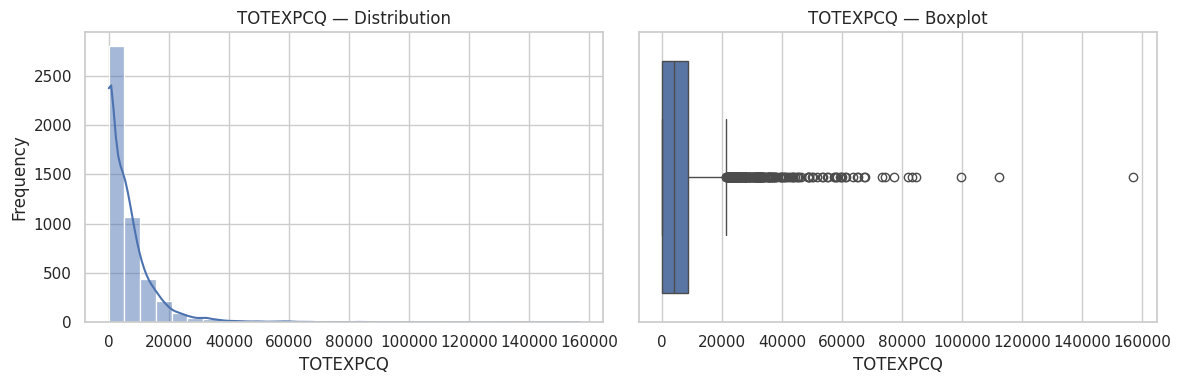

In [ ]:
plot_numeric_univariate(df_reduced, "TOTEXPCQ")

**Observations: Total Expenditure**

The visualization reveals a classic **highly right-skewed (positive skew) distribution**, which is typical for economic data.

**Key Findings:**
1.  **Skewness:** The histogram shows a long tail extending to the right. The vast majority of households spend less than \$20,000 per quarter, but the tail extends up to \$156,886.
2.  **Central Tendency Discrepancy:** The **Mean (\$6,181)** is significantly higher than the **Median (\$3,868)**. This large gap confirms that high-spending outliers are pulling the average up, making the median a more representative measure of a "typical" household.
3.  **Outliers:** The boxplot (right panel) identifies a dense cluster of outliers beyond the upper whisker.



### **2. Housing Expenditure (HOUSCQ)**

Next, we examine **Housing Expenditure (`HOUSCQ`)**. For most American households, housing represents the single largest financial obligation and is the primary driver of cost-of-living stress.

This aggregate variable includes expenses for shelter (rent or mortgage), utilities, and other dwelling-related costs.

Analyzing this variable is essential to understanding the "severe housing burden" component of our financial vulnerability definition.


Summary Statistics for 'HOUSCQ'


,count,mean,std,min,25%,50%,75%,max
HOUSCQ,4751.0,2019.257981,2967.304551,0.0,0.0,1247.0,2731.0,47027.0


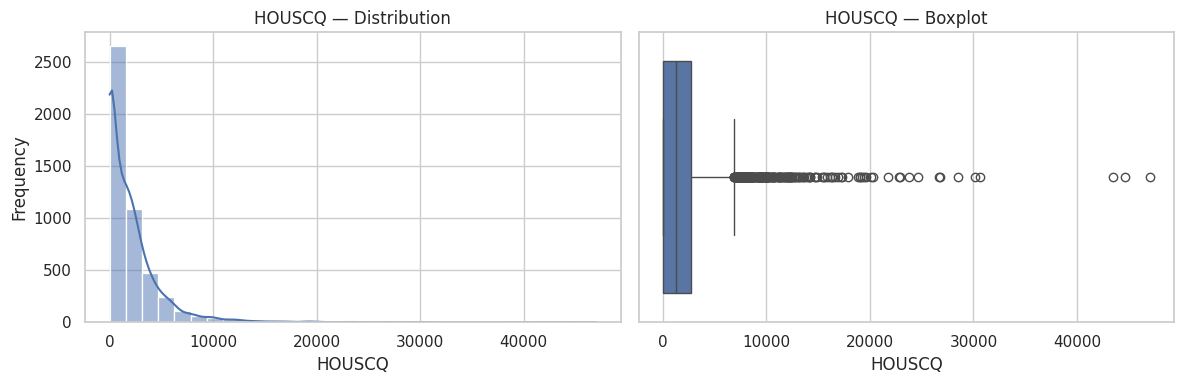

In [ ]:
plot_numeric_univariate(df_reduced, "HOUSCQ")

**Observations: Housing Expenditure**

The visualization for housing expenditure mirrors the right-skewed pattern seen in total expenditures, but with several distinct characteristics:

**Key Findings:**
1.  **Distribution Shape:** The histogram is heavily right-skewed. While the average quarterly housing cost is approximately **\$2,019**, the median is significantly lower at **\$1,247**.
2.  **Zero-Cost Households:** Notably, the 25th percentile is **0.0**. This indicates that a significant portion of the sample reported zero housing outlays for the quarter. This group likely includes households who own their homes outright (no mortgage) or those living in subsidized housing situations.
3.  **Extreme Values:** The boxplot reveals a long trail of outliers, with maximum quarterly housing costs reaching over **\$47,000**. This reflects the vast disparity in housing costs, likely driven by geography (e.g., high cost-of-living cities) or luxury property ownership.

### **3. Food Expenditure (FOODCQ)**

We now turn our attention to **Food Expenditure (`FOODCQ`)**, one of the most fundamental components of household economics. This variable aggregates spending on both "food at home" (groceries, supplies) and "food away from home" (restaurants, cafeterias).

From a theoretical standpoint, food is considered a "necessary good" with relatively inelastic demand—meaning every household, regardless of financial status, must consume a baseline amount to survive. However, the *variance* in this category is often driven by two factors:
1.  **Family Size:** Larger families naturally require more food, likely creating a linear relationship with the `FAM_SIZE` variable.
2.  **Lifestyle & Income:** Higher-income households tend to spend significantly more on dining out, which can skew the distribution's upper tail.

Analyzing this distribution helps us establish a baseline for "subsistence" spending, which is critical for identifying households that may be under-consuming due to financial distress.


Summary Statistics for 'FOODCQ'


,count,mean,std,min,25%,50%,75%,max
FOODCQ,4751.0,994.675142,1337.201424,0.0,0.0,678.6,1473.3333,26233.3333


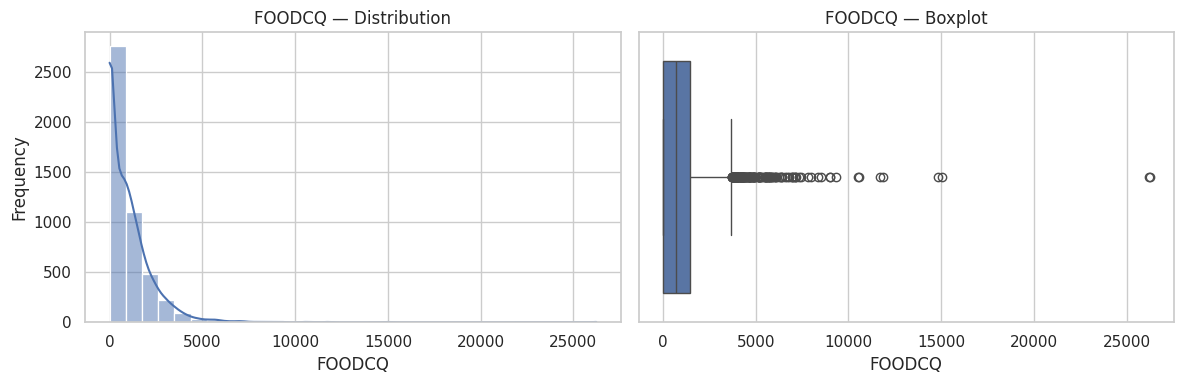

In [ ]:
plot_numeric_univariate(df_reduced, "FOODCQ")

**Observations: Food Expenditure Patterns**

The visual analysis of Food Expenditure reveals a distribution that is distinct from the larger capital expenses like housing:

**Key Statistical Findings:**
*   **Central Tendency:** The median quarterly spending is roughly **\$679**, while the mean is higher at **\$995**. This difference indicates a moderate right skew, but less extreme than what we observed in Housing.
*   **Zero Values:** The 25th percentile is **0.0**, which is an anomaly for a "necessary good." In the context of the CE survey, this often implies that the specific respondent didn't purchase food *during the specific interview week* that was extrapolated, or they rely entirely on non-monetary food sources (e.g., SNAP benefits not recorded as cash expenditure, or food banks).
*   **Upper Tail:** The maximum value reaches approximately **\$26,000**. While high, this is an order of magnitude lower than housing or transportation maximums, reflecting the biological and physical limits on how much food a household can actually consume.
*   **Distribution Shape:** The histogram shows a smoother decline compared to other categories, suggesting that food spending is more continuously distributed across the population rather than being driven by rare, massive purchases.

### **4. Transportation Expenditure (TRANSCQ)**

Next, we analyze **Transportation Expenditure (`TRANSCQ`)**. This category is unique in household finance because it combines low-cost, recurring expenses (e.g., gasoline, public transit fares, insurance premiums) with high-cost, infrequent capital investments (e.g., purchasing a new or used vehicle).

This dual nature typically results in a highly volatile variable. Most households will report relatively low spending (just gas/maintenance), while a small fraction of households who purchased a car during the survey quarter will report massive expenditures. Capturing this distinction is vital, as a vehicle purchase can temporarily spike a household's total expenditure, making them appear "wealthy" or "high-spending" in a single quarter even if their income is modest.


Summary Statistics for 'TRANSCQ'


,count,mean,std,min,25%,50%,75%,max
TRANSCQ,4751.0,1019.255244,3933.528049,0.0,0.0,231.0,855.0,98911.0


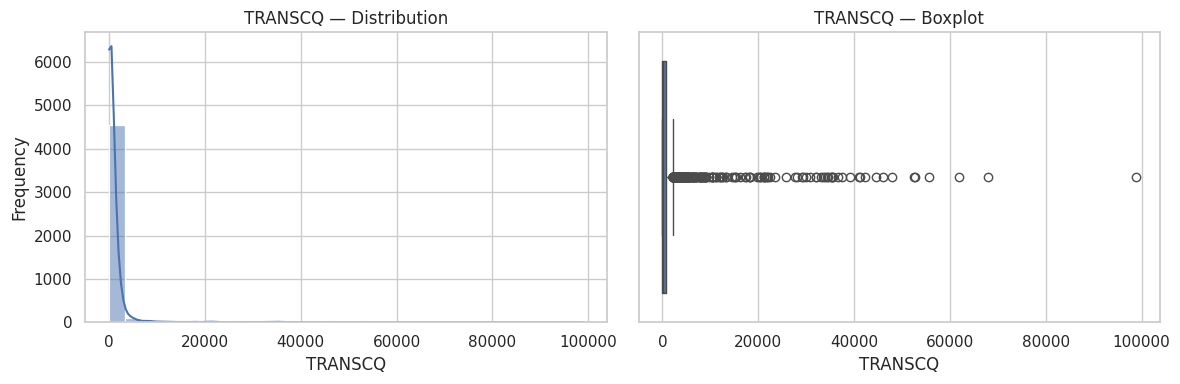

In [ ]:
plot_numeric_univariate(df_reduced, "TRANSCQ")

**Observations: Transportation Volatility**

The visualization validates our hypothesis regarding the "lumpy" nature of transportation spending, revealing one of the most extreme distributions in the dataset.

**Key Statistical Findings:**
*   **Extreme Skewness & Volatility:** The standard deviation (**\$3,933**) is nearly four times higher than the mean (**\$1,019**). This ratio indicates massive variance in the data.
*   **The "L-Shaped" Distribution:** The histogram is dominated by a massive peak near zero. The median spending is only **\$231**, suggesting that for the typical household, transportation costs are limited to basic fuel and maintenance.
*   **The "Car Purchase" Effect:** The maximum value is nearly **\$100,000** (\$98,911). This massive outlier clearly represents a household purchasing a luxury vehicle.
*   **Modeling Implication:** This extreme separation between the "haves" (car buyers) and the "have-nots" (daily commuters) creates a difficult feature for linear models. The presence of \$100k outliers alongside a \$231 median confirms that **robust scaling** or **log-transformation** will be mandatory to prevent these outliers from dominating the regression model's error function.

### **5. Healthcare Expenditure (HEALTHCQ)**

Next, we analyze **Healthcare Expenditure (`HEALTHCQ`)**. This variable captures out-of-pocket spending on medical services, prescriptions, insurance premiums, and medical supplies.

**Theoretical Context:**
Healthcare economics is distinct from standard consumer theory because demand is driven by **stochastic health shocks** rather than preference. It is generally considered an inelastic good (you cannot simply choose not to treat a broken leg), but the financial burden is heavily modulated by insurance coverage.

**We anticipate three unique distributional characteristics:**
1.  **Zero-Inflation:** Healthy individuals with employer-sponsored coverage may report near-zero out-of-pocket costs.
2.  **Risk Tail:** Households with chronic conditions or poor insurance coverage will populate a heavy right tail of catastrophic costs.
3.  **Negative Values:** Unlike any other expenditure category, healthcare data often contains negative values. In the CE Survey, this typically represents **insurance reimbursements** received during the quarter for expenses paid in a previous period.


Summary Statistics for 'HEALTHCQ'


,count,mean,std,min,25%,50%,75%,max
HEALTHCQ,4751.0,519.093314,1006.451039,-719.6667,0.0,165.0,655.0,12924.0


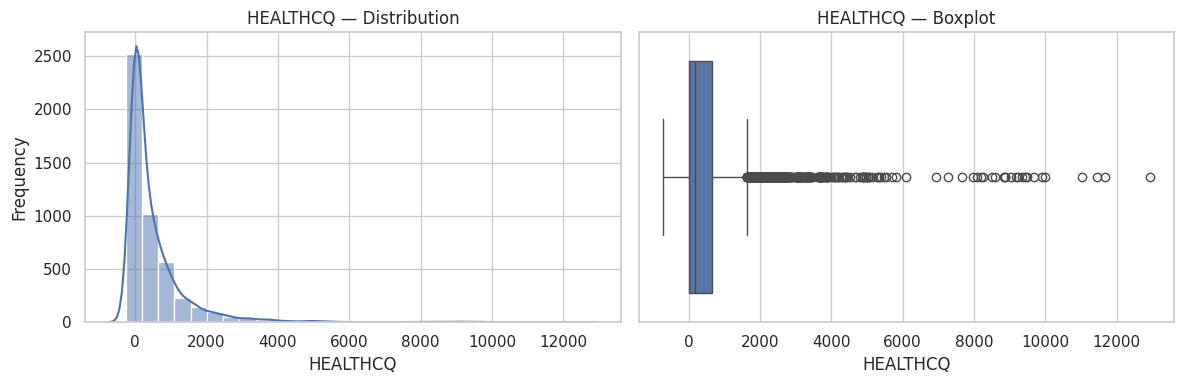

In [ ]:
plot_numeric_univariate(df_reduced, "HEALTHCQ")

**Observations: The Financial Burden of Health**

The analysis of Healthcare Expenditure confirms the high variance and unpredictability of medical costs in the United States.

**Key Statistical Findings:**
*   **Distributional Skew:** The mean expenditure is **\$519**, significantly higher than the median of **\$165**. This large gap indicates that while the "typical" household has manageable medical costs, the average is pulled up by a subset of households facing significant bills.
*   **The Reimbursement Anomaly:** As hypothesized, the minimum value is **-\$719**. This confirms the presence of insurance reimbursements. For modeling purposes, we may need to floor these values at zero to prevent them from reducing the "Total Expenditure" sum artificially.
*   **Extreme Burden:** The maximum quarterly spend is **\$12,924**. For a median-income household, spending \$13k in a single quarter on health would be financially devastating. This outlier represents the "medical bankruptcy" risk factor.
*   **Boxplot Compression:** The interquartile range (IQR) is relatively tight (\$0 to \$655), but the boxplot shows an extremely dense stream of outliers extending far beyond the whiskers. This suggests that "high medical spending" is not a rare anomaly, but a common state for a significant minority of the population (likely the elderly or chronically ill).

### **6. Education Expenditure (EDUCACQ)**

We now examine **Education Expenditure (`EDUCACQ`)**, a variable that includes tuition, books, and supplies. From an economic perspective, education spending exhibits unique characteristics distinct from daily necessities or regular bills.

We hypothesize that this variable will demonstrate extreme **"zero-inflation."** Unlike food (which everyone buys weekly) or housing (paid monthly), education payments are often:
1.  **Seasonal:** Tuition is typically paid only twice a year (August and January), meaning a household could be a "high spender" on education but show zero expenditure in a Q2 survey.
2.  **Demographic-Specific:** Only households with college-aged dependents or adults seeking continuing education will register values here. For the vast majority of the population (e.g., childless adults, retirees, families with children in public K-12 schools), this value is expected to be zero.

Analyzing this distribution is crucial because education expenses can be a massive temporary shock to a household's finances, potentially pushing a family into "vulnerability" for a specific quarter even if their long-term solvency is intact.


Summary Statistics for 'EDUCACQ'


,count,mean,std,min,25%,50%,75%,max
EDUCACQ,4751.0,61.221638,618.664318,0.0,0.0,0.0,0.0,17501.3333


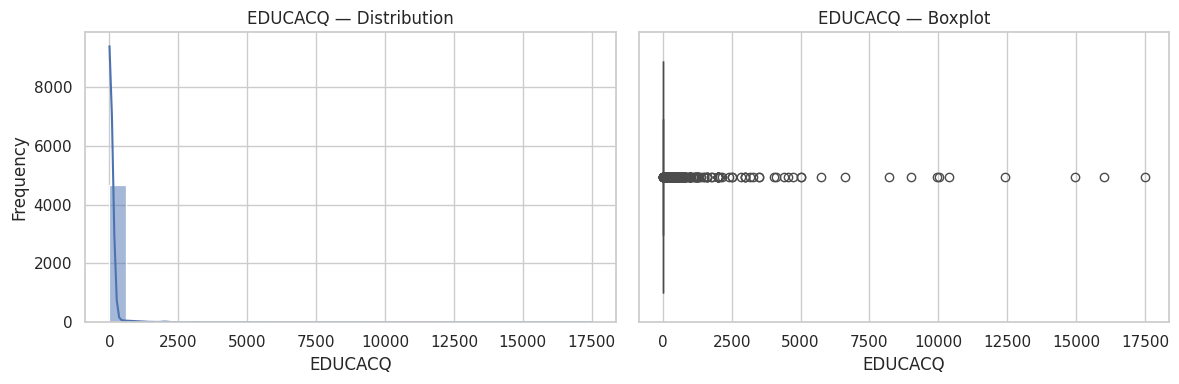

In [ ]:
plot_numeric_univariate(df_reduced, "EDUCACQ")

**Observations: The Zero-Inflation Phenomenon in Education**

The statistical output and visualizations for Education Expenditure confirm our "zero-inflation" hypothesis with stark clarity. This is arguably the most sparse distribution in our entire dataset.

**Key Statistical Findings:**
*   **Extreme Sparsity:** The 25th, 50th (median), and **even the 75th percentile** are all exactly **0.0**. This indicates that more than three-quarters of the households in our sample spent absolutely nothing on education during the survey period.
*   **The Mean-Median Disconnect:** While the median is \$0, the mean is approximately **\$61.22**. In statistical terms, this effectively renders the mean "meaningless" as a descriptor of the "typical" household. The average is entirely driven by the minority of households who *did* pay tuition.
*   **Outlier Magnitude:** The maximum value is approximately **\$17,501**. This likely represents a semester tuition payment for a university student.
*   **Modeling Implication:** Because this variable is overwhelmingly comprised of zeros, treating it as a standard continuous predictor in a linear regression model may yield poor results. In our Feature Engineering phase, it may be more effective to convert this into a binary feature (e.g., `Has_Education_Expense`: Yes/No) rather than using the raw dollar amount.

### **7. Entertainment Expenditure (ENTERTCQ)**

Next, we analyze **Entertainment Expenditure (`ENTERTCQ`)**. This category encompasses discretionary spending on fees, admissions (movies, concerts), hobbies, and equipment.

In the context of predicting **Financial Vulnerability**, this variable acts as a critical "negative predictor." In economic theory, entertainment is considered a "luxury good" with high income elasticity. When a household faces financial distress, discretionary entertainment spending is typically the first budget item to be cut. Conversely, high spending in this category is a strong signal of disposable income and financial health.

We expect to see a highly skewed distribution where vulnerable households congregate near zero, while financially secure households display a wide range of spending behavior.


Summary Statistics for 'ENTERTCQ'


,count,mean,std,min,25%,50%,75%,max
ENTERTCQ,4751.0,292.789097,1248.615562,0.0,0.0,25.0,240.0,52000.0


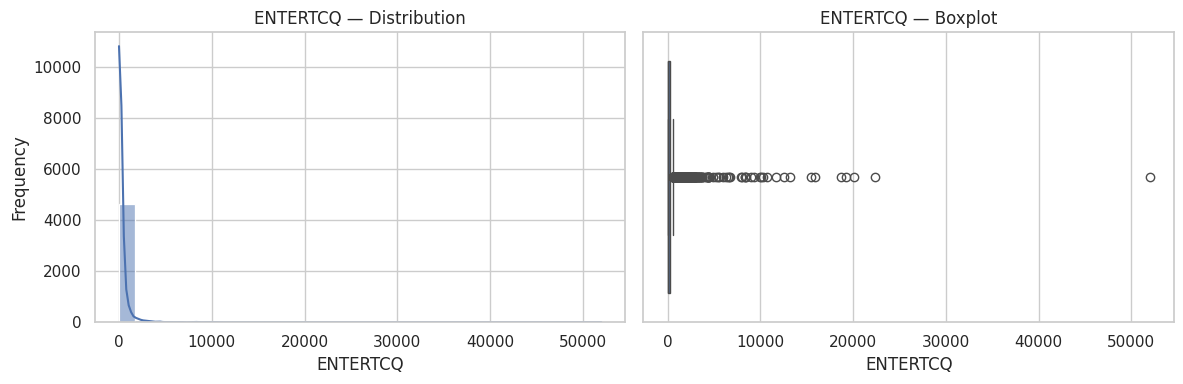

In [ ]:
plot_numeric_univariate(df_reduced, "ENTERTCQ")

**Observations: Discretionary Spending Patterns**

The analysis of Entertainment Expenditure reveals a distribution that serves as a proxy for "disposable income," highlighting the economic divide within the sample.

**Key Statistical Findings:**
*   **Prevalence of Low Spending:** The median expenditure is **\$25.00**, which is very low but distinct from zero. Unlike education (where most people spend nothing), most households spend *something* on entertainment, even if it is a nominal amount.
*   **The "Luxury" Tail:** The histogram shows an extremely long right tail. While the typical household spends roughly \$25, the maximum value is **\$52,000**. This massive outlier—spending fifty thousand dollars in a single quarter on entertainment—represents extreme wealth or a specific high-cost event (e.g., a luxury vacation or purchasing a recreational vehicle).
*   **High Variance:** The standard deviation (**\$1,248**) is roughly four times larger than the mean (**\$292**). This high coefficient of variation confirms that entertainment spending is not consistent across the population; it varies wildly based on income levels.
*   **Strategic Insight:** For our classification model, low values in `ENTERTCQ` may not guarantee vulnerability (frugality is not poverty), but *high* values are almost certainly a guarantee of *non-vulnerability*. This makes it a powerful feature for distinguishing the "safe" class.

### **8. Personal Care Expenditure (PERSCACQ)**

We conclude our analysis of the "Expenditure" category by examining **Personal Care Expenditure (`PERSCACQ`)**. This variable captures spending on hygiene products, hair care services, and electric personal care appliances.

While often trivial in dollar amount compared to housing or transportation, personal care spending serves as an interesting behavioral signal. Economically, it occupies a middle ground between "essential" and "discretionary." Everyone requires basic hygiene products (essential), but the choice to purchase premium salon services or luxury cosmetics is highly income-elastic (discretionary).

**Theoretical Expectations:**
We hypothesize that this variable will exhibit a "small-dollar" distribution. Unlike housing, which is capped by a lease, or food, which scales with calories, personal care spending is often incidental. We also anticipate significant **measurement noise**: many households likely purchase personal care items (like shampoo or toothpaste) during grocery trips, potentially causing this spending to be inadvertently bundled into `FOODCQ` rather than separated here. Consequently, we expect to see a high frequency of zero or near-zero values, reflecting this classification overlap.


Summary Statistics for 'PERSCACQ'


,count,mean,std,min,25%,50%,75%,max
PERSCACQ,4751.0,41.543535,103.759116,0.0,0.0,0.0,39.16665,1627.3333


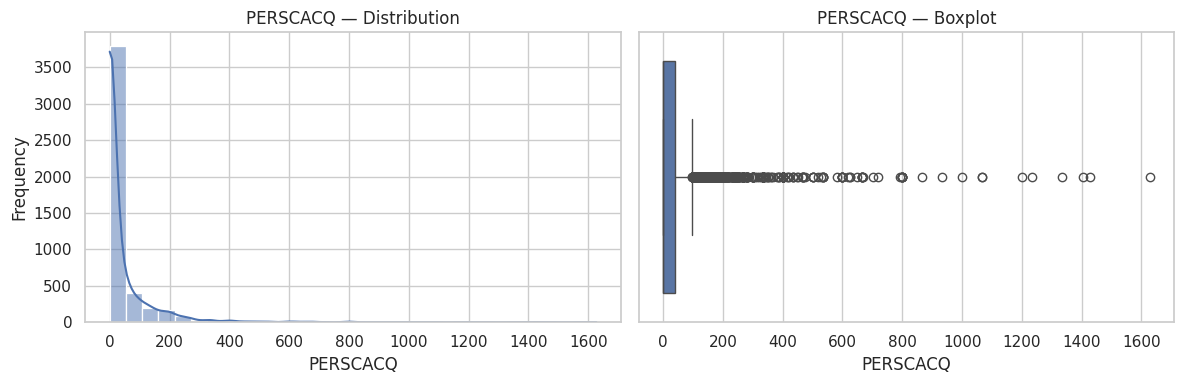

In [ ]:
plot_numeric_univariate(df_reduced, "PERSCACQ")

**Observations: The "Small-Dollar" Distribution**

The analysis of Personal Care Expenditure validates our hypothesis regarding the scale and classification of these expenses.

**Key Statistical Findings:**
*   **Low Magnitude:** The mean quarterly expenditure is roughly **\$41.54**, with a standard deviation of **\$103.76**. This confirms that for the vast majority of households, personal care is a minor budget line item—accounting for less than 1% of the typical quarterly budget.
*   **Median of Zero:** The median is **0.0**, and the 75th percentile is only **\$39.16**. This strongly suggests that our hypothesis about "bundling" is correct: most respondents likely lump these small purchases into their grocery bills. Only households with specific, itemized expenses (e.g., a distinct trip to a barber or salon) appear to report values here.
*   **Outlier Behavior:** Despite the low average, the maximum value is **\$1,627**. This outlier likely represents a household purchasing expensive services or perhaps a suite of high-end appliances.
*   **Modeling Implication:** Due to the low magnitude and high rate of zero-reporting, this variable likely has **weak predictive power** for overall financial vulnerability on its own. However, it may serve as a useful feature for clustering, helping to distinguish "frugal" consumers from "premium" consumers.

## **Income**

### **9. Annual Pre-Tax Income (FINCBTAX)**

We now transition from the "Expenditure" side of the ledger to the "Income" side, beginning with the most critical variable in our dataset: **Annual Pre-Tax Income (`FINCBTAX`)**.

This variable represents the combined income of all consumer unit members from all sources (wages, self-employment, social security, interest, etc.) before taxes are deducted.

**Why this Variable is Critical:**
1.  **The Denominator of Vulnerability:** Our primary research question defines "Financial Vulnerability" largely as a function of the **Expenditure-to-Income Ratio**. Therefore, the accuracy and distribution of `FINCBTAX` directly determine the validity of our target variable.
2.  **Wealth Inequality:** Income distributions in the United States are historically known to be **Log-Normal**. We expect to see a massive right skew, where a small number of high-income households pull the mean significantly away from the median.
3.  **Data Quality Risks:** Self-reported income is notoriously prone to errors. We must specifically look for **negative values** (indicating business losses) or zero values, as these will mathematically break our ratio calculations (division by zero) and require special handling during Data Preparation.


Summary Statistics for 'FINCBTAX'


,count,mean,std,min,25%,50%,75%,max
FINCBTAX,4751.0,86973.864239,103801.222558,-82067.0,24000.0,55931.0,116000.0,1375475.0


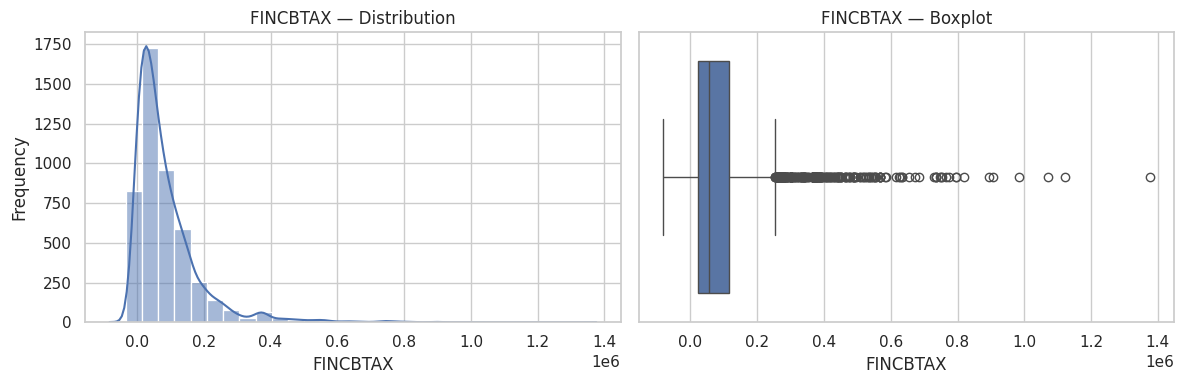

In [ ]:
plot_numeric_univariate(df_reduced, "FINCBTAX")

**Observations: Income Inequality and Data Integrity**

The visualization of Pre-Tax Income reveals a textbook example of economic inequality, alongside a critical data quality issue that must be addressed.

**Key Statistical Findings:**
*   **The Inequality Gap:** There is a substantial divergence between the **Mean (\$86,973)** and the **Median (\$55,931)**. The mean is approximately \$31,000 higher than the median. This confirms that the distribution is heavily influenced by high-earning outliers, making the median a far more accurate representation of the "typical" American household in this sample.
*   **The "1%" Effect:** The maximum income reported is **\$1.37 million**. This extreme right tail (visible in the boxplot as a dense stream of black dots) is characteristic of U.S. income data.
*   **Critical Data Issue - Negative Values:** The minimum value is **-\$82,067**. In the context of the BLS survey, negative income typically indicates self-employed households with net business losses.
    *   *Impact:* We cannot calculate a valid "Expenditure-to-Income" ratio with negative income (it would imply a negative percentage).
    *   *Action Item:* In the Data Preparation phase, we must either **filter out** these records or **impute** them to a baseline poverty level to ensure our vulnerability metric is mathematically sound.

### **10. Wage and Salary Income (FSALARYX)**

We proceed to analyze the largest component of household income for the working-age population: **Wage and Salary Income (`FSALARYX`)**.

This variable captures gross earnings from employment. In labor economics, we generally expect this variable to define the "active workforce." However, in a general population survey like the CE, we anticipate a **bimodal distribution**:
1.  **The Zero Cluster:** A significant portion of the population (retirees, students, the unemployed, and purely self-employed individuals) will report exactly \$0 in wages.
2.  **The Earner Distribution:** Among those who do work, we expect a classic log-normal distribution, with a heavy right tail representing high earners.

Analyzing the proportion of zeros vs. positive values here is critical for understanding the "dependency ratio" of our sample—how many households rely on active labor vs. passive income sources.


Summary Statistics for 'FSALARYX'


,count,mean,std,min,25%,50%,75%,max
FSALARYX,4751.0,64752.444748,90103.182229,0.0,0.0,34000.0,100000.0,746435.0


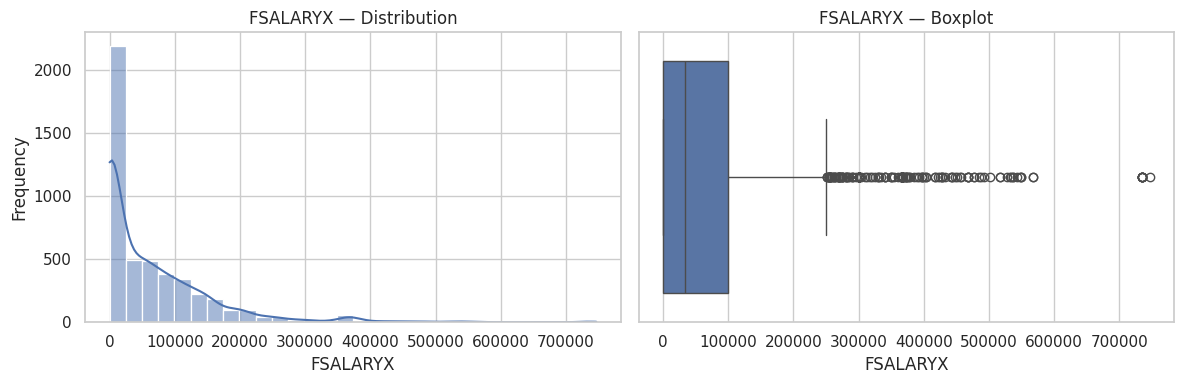

In [ ]:
plot_numeric_univariate(df_reduced, "FSALARYX")

**Observations: The Worker vs. Non-Worker Divide**

The visualization confirms the structural divide in the American economy between active earners and non-earners.

**Key Statistical Findings:**
*   **The "Non-Worker" Cliff:** The most striking feature is the massive spike at **\$0**. The 25th percentile is exactly **0.0**, indicating that at least a quarter of the households in our sample earned no wages during the survey period. This aligns with the presence of retirees (who rely on Social Security) and the unemployed.
*   **Skewness Among Earners:** For those who do work, the distribution is heavily right-skewed. The mean (**\$64,752**) is nearly double the median (**\$34,000**).
*   **Standard Deviation:** The standard deviation is extremely high (**~\$90,103**), which is significantly larger than the mean itself. This indicates massive inequality; the gap between a minimum-wage worker and a high-income professional dominates the variance in the dataset.
*   **Modeling Implication:** Because the median is pulled down by the non-workers, simply imputing the mean for missing values would be dangerous. We must respect the zero values as "true zeros" (not missing data) and perhaps create a feature `Is_Wage_Earner` to help the model distinguish between labor-income and fixed-income households.

### **11. Retirement Income (FRRETIRX)**

Next, we look at **Retirement Income (`FRRETIRX`)**, which includes pensions, annuities, and private retirement account distributions (excluding Social Security).

This variable acts as the **economic inverse** of Wage and Salary income. It represents the "lifecycle hypothesis" in action: as households age, they transition from earning wages (`FSALARYX`) to drawing down retirement savings (`FRRETIRX`).

We hypothesize that this distribution will be even more sparse than wages. Since the retirement age is typically 65+, and many Americans rely solely on Social Security rather than private pensions, we expect the vast majority of our sample to show \$0 for this variable.


Summary Statistics for 'FRRETIRX'


,count,mean,std,min,25%,50%,75%,max
FRRETIRX,4751.0,8728.399284,15593.823558,0.0,0.0,0.0,15179.0,145425.0


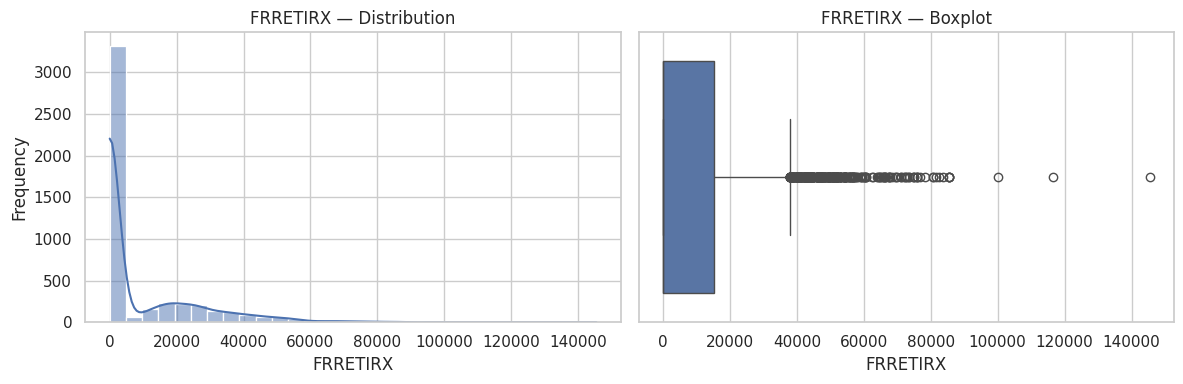

In [ ]:
plot_numeric_univariate(df_reduced, "FRRETIRX")

**Observations: The Lifecycle Effect**

The analysis of Retirement Income confirms that this is a niche but critical income source, specific to the older demographic.

**Key Statistical Findings:**
*   **Extreme Sparsity:** The median is **\$0**, and the 75th percentile is approximately **\$15,179**. This means that fewer than 25% of households in the sample are drawing significant pension or private retirement income.
*   **The "Pensioner" Tail:** Despite the sparsity, the maximum value is **\$145,425**. This indicates that there is a subset of "wealthy retirees" who maintain high incomes purely through private pensions, separate from wages or government aid.
*   **Complementary Relationship:** When viewed alongside the previous plot (`FSALARYX`), we see a clear segmentation. Households with high values here likely have low values in wages, and vice versa.
*   **Strategic Insight:** For our classification model, identifying households with *positive* `FRRETIRX` is a strong proxy for "Age > 65." This helps the model implicitly understand that a low wage income for these households does *not* necessarily imply unemployment or vulnerability—it simply implies retirement.

### **12. Social Security Income (FSSIX)**

We turn our attention to **Social Security Income (`FSSIX`)**, a variable that captures payments from the Social Security Administration (SSA) and Railroad Retirement benefits.

**Theoretical Significance:**
For millions of American households—specifically the elderly and the disabled—this variable represents their primary, and often sole, financial lifeline. Economically, Social Security acts as a "floor" for income; it is inflation-indexed and guaranteed, providing a specific type of financial resilience that wage income (which can be lost due to layoff) does not.

**Hypothesis:**
We anticipate an extremely **zero-inflated distribution** driven strictly by demographics. Since Social Security eligibility typically begins at age 62 (or earlier for disability), the vast majority of the working-age population (ages 18-61) will report exactly **\$0**. Consequently, this variable serves as a powerful proxy for age in our modeling: a positive value here almost certainly categorizes the household as "Senior" or "Disabled."


Summary Statistics for 'FSSIX'


,count,mean,std,min,25%,50%,75%,max
FSSIX,4751.0,168.593138,1732.210192,0.0,0.0,0.0,0.0,78000.0


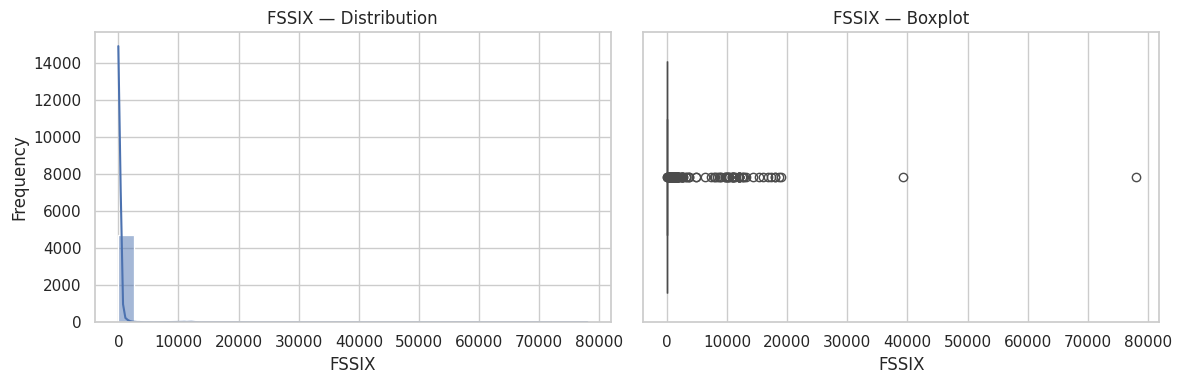

In [ ]:
plot_numeric_univariate(df_reduced, "FSSIX")

**Observations: The Demographic Filter**

The statistical output for Social Security Income reveals an extreme level of sparsity, confirming its role as a targeted demographic variable rather than a general income source.

**Key Statistical Findings:**
*   **Near-Total Sparsity:** The 25th, 50th, and 75th percentiles are all **0.0**. This indicates that fewer than 25% of the households in our sample currently receive Social Security benefits. This aligns with the broader U.S. demographic pyramid, where the working-age population outnumbers the retired population.
*   **Low Mean vs. High Max:** The mean value is relatively low (**~\$168**), which is mathematically diluted by the thousands of zeros. However, the maximum value is **\$78,000**. This suggests that for the minority of households who *do* receive this income, it can be substantial—likely representing a dual-earner couple who both had high career earnings and are now claiming maximum benefits.
*   **Modeling Implication:** The high degree of zero-inflation suggests that `FSSIX` should likely be treated as an interaction term. In our predictive models, the relationship between "Financial Vulnerability" and "Expenditure" likely changes fundamentally when `FSSIX > 0`, as these households are on fixed incomes and cannot simply "work more hours" to cover deficits.

### **13. Private Pension Income (FPRIPENX)**

Finally, we examine **Private Pension Income (`FPRIPENX`)**. This variable captures income from employer-sponsored defined-benefit plans.

**Economic Context:**
This variable tells a story about the shifting landscape of the American economy. Over the last four decades, there has been a massive shift from "Defined Benefit" pensions (captured here) to "Defined Contribution" plans like 401(k)s (captured in `FRRETIRX` or asset variables). As such, we expect `FPRIPENX` to be a "legacy" variable—highly prevalent among older retirees who worked in government or unionized manufacturing jobs, but virtually non-existent for younger workers.

**Expectation:**
We expect this to be the most sparse income variable in the dataset. It represents a specific slice of the retired population that benefits from the "old style" of retirement planning.


Summary Statistics for 'FPRIPENX'


,count,mean,std,min,25%,50%,75%,max
FPRIPENX,4751.0,380.79057,2207.948847,0.0,0.0,0.0,0.0,32283.0


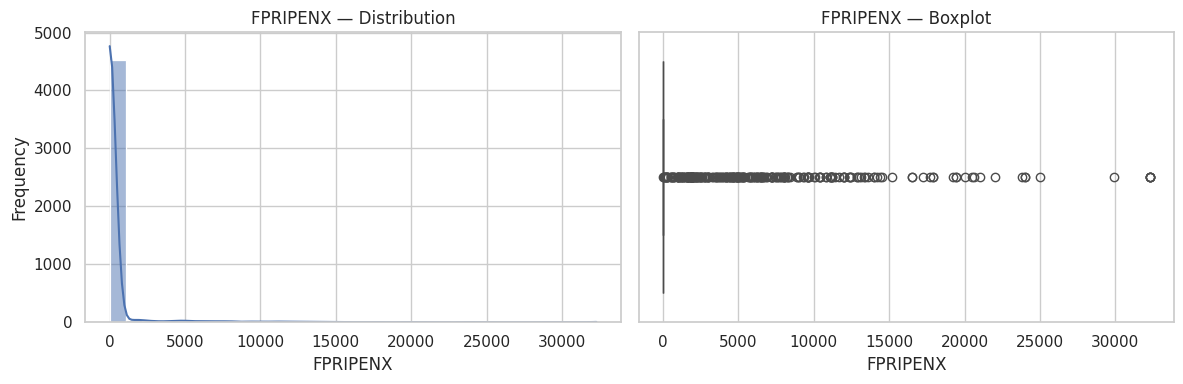

In [ ]:
plot_numeric_univariate(df_reduced, "FPRIPENX")

**Observations: A Vanishing Income Source**

The visualization confirms that Private Pension income is a rare anomaly in the modern household budget.

**Key Statistical Findings:**
*   **Extreme Rarity:** Similar to Social Security, the median and 75th percentile are **0.0**. However, the mean (**~\$380**) is slightly higher than Social Security in relative terms given the maximum, suggesting that the *few* people who have pensions receive decent payouts.
*   **The "Golden Handcuffs" Tail:** The maximum value is **\$32,283**. While significant, this is much lower than the maximums seen in Wage or Retirement accounts. This reflects the fixed nature of pensions; unlike investment accounts which can grow with the market, pensions are typically fixed payments.
*   **Visual Confirmation:** The boxplot is essentially a flat line at zero with a very sparse trail of outliers.
*   **Conclusion:** This variable identifies a very specific socioeconomic group: likely older, former union/government employees. In terms of "Financial Vulnerability," this group is likely *less* vulnerable than average because this income is guaranteed for life, insulating them from market volatility.

### **14. Public Assistance Income (WELFAREX)**

We now examine **Public Assistance or Welfare Income (`WELFAREX`)**. This variable captures cash assistance from state and local government programs (e.g., TANF).

**Theoretical Framework & Modeling Importance:**
From a predictive modeling standpoint, this is arguably one of the most high-signal variables in the entire dataset, despite its expected sparsity.
1.  **The "Means-Test" Proxy:** Eligibility for welfare programs in the United States is strictly "means-tested," meaning applicants must prove they have low income and limited assets to qualify. Therefore, any non-zero value in this column is effectively a **ground-truth label** that the household was financially vulnerable during the qualification period.
2.  **Inverse Correlation:** We hypothesize a strong inverse correlation between `WELFAREX` and `FSALARYX` (Wages). It is rare to see high values in both simultaneously due to income caps on eligibility.
3.  **Sparsity Challenge:** Because these programs are targeted at the most destitute fraction of the population, we expect the valid observation count to be extremely low relative to the full sample size ($N=4,751$). This "class imbalance" within the feature itself poses a challenge: the model may try to ignore this variable because it is almost always zero, even though the non-zero cases are critical to identifying our target class.


Summary Statistics for 'WELFAREX'


,count,mean,std,min,25%,50%,75%,max
WELFAREX,33.0,5138.424242,5038.181034,5.0,636.0,3600.0,9000.0,18216.0


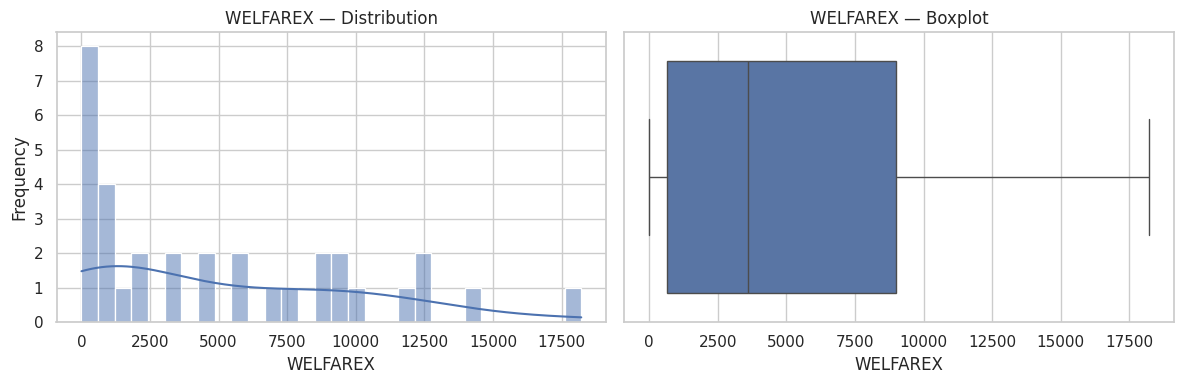

In [ ]:
plot_numeric_univariate(df_reduced, "WELFAREX")

**Observations: A High-Signal, Low-Frequency Indicator**

The summary statistics and visualizations highlight the extreme specific nature of this variable.

**Key Statistical Findings:**
*   **Extreme Rarity (N=33):** The most critical observation is the **count**. Out of 4,751 households in the dataset, only **33** reported receiving welfare income. This represents less than **0.7%** of our sample.
*   **Distribution Among Recipients:** For the small cohort that does receive assistance, the distribution is relatively wide. The mean is **~\$5,138**, but the standard deviation is nearly equal to the mean (**~\$5,038**), indicating high variance. Some households receive minimal support (min **\$5**), while others rely on it heavily (max **\$18,216**).
*   **The "Safety Net" Effect:** The boxplot shows that the median assistance is around \$3,800. In the context of the poverty line, this confirms that welfare supplements, but rarely replaces, a living wage.
*   **Modeling Decision:** Due to the extremely low count (N=33), treating this as a continuous variable in a regression model is risky—it is too sparse to establish a reliable slope. A better approach for Feature Engineering would be to convert this into a binary flag: `Receives_Public_Assistance` (1/0).

### **15. Other Income (OTHRINCX)**

Finally, we analyze the catch-all category: **Other Income (`OTHRINCX`)**. In the Consumer Expenditure Survey, this variable aggregates diverse income sources that do not fit into standard classifications like wages, pensions, or social security. Common components include alimony, child support, legal settlements, and sometimes erratic income from odd jobs or hobbies.

**Why this Variable Matters:**
1.  **Hidden Financial Flows:** "Other Income" often captures the **informal economy** or inter-household transfers (like child support) that are crucial for understanding the budget of single-parent households—a demographic group historically at higher risk of financial vulnerability.
2.  **Volatility:** Unlike a salary, which is predictable, sources in this category can be lump-sum or irregular. A household might appear "wealthy" in Q2 due to a one-time legal settlement but lack sustainable income.
3.  **Noise vs. Signal:** We need to determine if this variable contains meaningful economic signal or if it is primarily statistical noise. A high variance would suggest it captures distinct, significant financial events rather than just rounding errors.


Summary Statistics for 'OTHRINCX'


,count,mean,std,min,25%,50%,75%,max
OTHRINCX,99.0,7679.959596,9530.714967,70.0,1500.0,4000.0,10176.0,42299.0


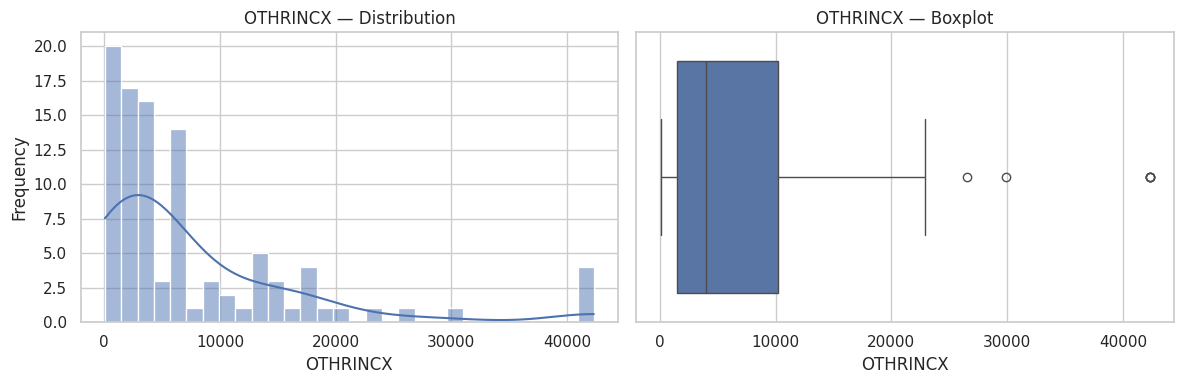

In [ ]:
plot_numeric_univariate(df_reduced, "OTHRINCX")

**Observations: The Heterogeneity of Residual Income**

The analysis of "Other Income" reveals a distribution defined by unpredictability and heterogeneity.

**Key Statistical Findings:**
*   **Low Prevalence (N=99):** Similar to Welfare, this is a sparse variable, with only **99** households (approx. 2%) reporting positive values. This confirms that for the vast majority of Americans, income comes from standard sources (wages/retirement), not "other" sources.
*   **High Variance:** The standard deviation (**~\$9,530**) is significantly higher than the mean (**~\$7,880**). This implies that "Other Income" is not a uniform type of payment. It likely mixes small amounts (e.g., minor odd jobs) with large amounts (e.g., substantial alimony or settlements).
*   **Right-Skewed Outliers:** The maximum value is **\$42,299**, and the boxplot shows a significant number of outliers above the upper whisker. This reinforces the hypothesis that this category captures "windfall" events or significant external support payments.
*   **Conclusion:** While sparse, the magnitude of these payments (averaging nearly \$8,000) is non-trivial. For the 2% of households who receive it, this income is likely a deciding factor in their ability to meet the "Financial Vulnerability" threshold.

### **16. Other Regular Contributions (OTHREGX)**

We conclude the Income analysis by examining **Other Regular Contributions (`OTHREGX`)**. While similar in name to the previous variable (`OTHRINCX`), the distinction here is the word **"Regular."**

**Definition & Context:**
In the BLS Consumer Expenditure Survey taxonomy, this variable specifically captures regular, recurring inter-household transfers. The most common components are **alimony** and **child support**. Unlike the "lump sum" nature of `OTHRINCX`, these payments are periodic and predictable, functioning much like a salary for the recipient households.

**Theoretical Hypothesis:**
We hypothesize that this variable serves as a critical financial stabilizer for specific high-risk demographic groups—particularly single-parent households.
1.  **Magnitude vs. Frequency:** We expect the frequency (count) to be low, as most households do not receive alimony or child support. However, for those that do, we expect the magnitude to be substantial, potentially constituting 20-40% of their total gross income.
2.  **Vulnerability Signal:** From a modeling perspective, the *presence* of this income (non-zero value) acts as a strong demographic flag. It often implies a disrupted family structure (divorce/separation), which historically correlates with higher volatility in financial stability.


Summary Statistics for 'OTHREGX'


,count,mean,std,min,25%,50%,75%,max
OTHREGX,224.0,10866.611607,17029.554458,1.0,1392.0,3968.0,12000.0,77821.0


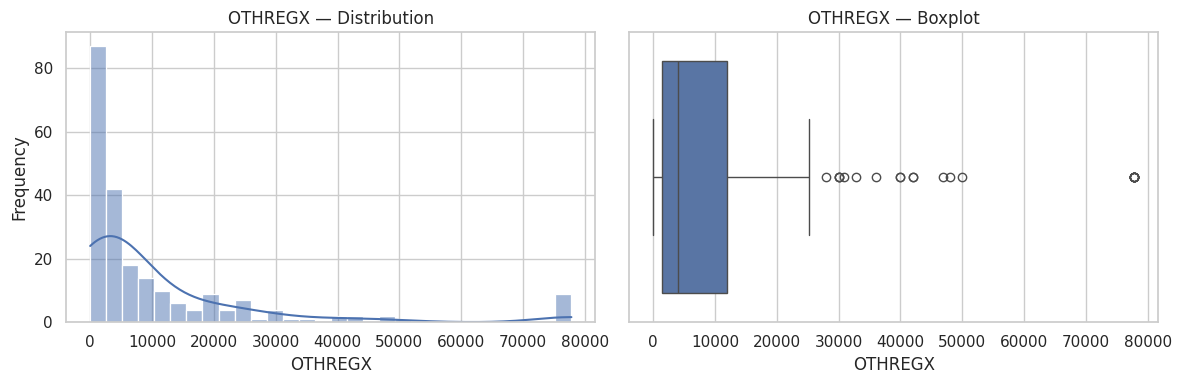

In [ ]:
plot_numeric_univariate(df_reduced, "OTHREGX")

**Observations: The Impact of Inter-Household Transfers**

The statistical analysis of Regular Contributions confirms that while this income source is rare, it is economically transformative for the recipients.

**Key Statistical Findings:**
*   **Targeted Prevalence (N=224):** With only 224 households reporting values (approx. 4.7% of the sample), this is a niche variable. However, it is significantly more common than Welfare (N=33), reflecting the widespread nature of divorce and separation arrangements in the U.S. demographic landscape.
*   **High Economic Value:** The mean value is **\$10,888**, which is remarkably high. In comparison, the median Total Expenditure for the whole dataset was roughly \$3,800. This suggests that for the recipients, these payments are not merely supplemental "pocket money"—they are likely covering core costs like rent and food.
*   **Extreme Variance:** The standard deviation (**\$17,029**) significantly exceeds the mean. This points to a massive disparity in support arrangements. The distribution likely mixes modest child support payments (e.g., \$200/month) with high-value alimony arrangements for wealthy divorcees.
*   **Outlier Analysis:** The maximum value is **\$77,821**. A household receiving nearly \$80,000 annually in support payments belongs to a fundamentally different economic stratum than one receiving \$1,200.


## **Household structure numeric**

### **17. Age of Reference Person (AGE_REF)**

Having concluded our analysis of financial flow variables (Income and Expenditure), we now pivot to the **Household Structure** variables that drive these economic behaviors. We begin with the most fundamental demographic predictor: **Age of Reference Person (`AGE_REF`)**.

**The Lifecycle Hypothesis:**
In economics, the "Lifecycle Hypothesis" posits that consumption and saving behaviors change predictably as a person ages:
*   **Young Adulthood (18-30):** High consumption relative to income (borrowing/debt accumulation).
*   **Peak Earning (30-60):** Income exceeds consumption (saving/wealth accumulation).
*   **Retirement (65+):** Income drops, but consumption is smoothed by drawing down assets (dissaving).

**Analytical Goal:**
We need to verify that our sample provides adequate coverage across all three stages. A sample skewed too heavily toward university students or retirees would introduce bias into our "Financial Vulnerability" model, as these groups have unique, often temporary, vulnerability profiles that do not generalize to the wider population.


Summary Statistics for 'AGE_REF'


,count,mean,std,min,25%,50%,75%,max
AGE_REF,4751.0,54.097874,17.524728,17.0,40.0,55.0,68.0,87.0


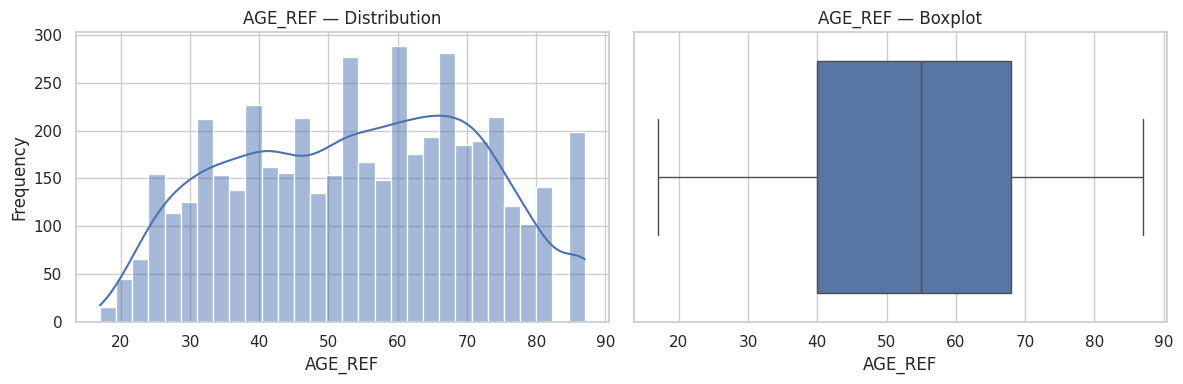

In [ ]:
plot_numeric_univariate(df_reduced, "AGE_REF")

**Observations: A Representative Demographic Sample**

The univariate analysis of `AGE_REF` reveals a robust, well-distributed sample that accurately reflects the demographics of U.S. "householders" (heads of households).

**Key Statistical Findings:**
*   **Broad Distribution (Platykurtic):** Unlike the financial variables which were heavily right-skewed, the Age distribution is broad and relatively flat. We see substantial representation from age 25 through age 80. This confirms that our model will have sufficient data to learn age-specific patterns (e.g., the difference between student loans and retirement drawdown).
*   **Central Tendency:** The mean age is **54.1 years**, with a median of **55.0**. This is slightly older than the median age of the general U.S. population (~38), but this is expected and correct for a survey of *Reference Persons*. The "Reference Person" is the one who owns or rents the home; children and dependents are excluded from this variable, naturally shifting the center of gravity toward middle age.
*   **Boundaries:**
    *   **Minimum (17):** There are very few teenage householders, which is valid.
    *   **Maximum (87):** The distribution trails off naturally in the 80s.
*   **Visual Check:** The histogram does not show a perfect Bell Curve. Instead, we see a "wave" pattern with a slight dip around age 50 and peaks in the late 50s/early 60s (the Baby Boomer cohort).


### **18. Family Size (FAM_SIZE)**

We continue our structural analysis with **Family Size (`FAM_SIZE`)**, a count variable representing the total number of members in the Consumer Unit. This variable serves as the primary "scaling factor" for household economics.

**The Economics of Household Size:**
In consumption theory, family size acts as a multiplier for essential needs but also introduces "economies of scale."
1.  **Linear Scaling:** Some costs, like food (`FOODCQ`) and clothing, tend to scale somewhat linearly with the number of people. A four-person household simply eats more than a one-person household.
2.  **Economies of Scale:** Other costs, like housing (`HOUSCQ`) and utilities, do not double when the family size doubles. A two-bedroom apartment costs the same to heat whether one person or three people live in it.
3.  **Poverty Thresholds:** Crucially, the definition of "Financial Vulnerability" is relative to family size. An income of \$30,000 might be sufficient for a single individual but indicates deep poverty for a family of five.

By analyzing the distribution of `FAM_SIZE`, we understand the demographic composition of our sample—whether it is dominated by single individuals, couples, or large extended families.


Summary Statistics for 'FAM_SIZE'


,count,mean,std,min,25%,50%,75%,max
FAM_SIZE,4751.0,2.348348,1.449391,1.0,1.0,2.0,3.0,13.0


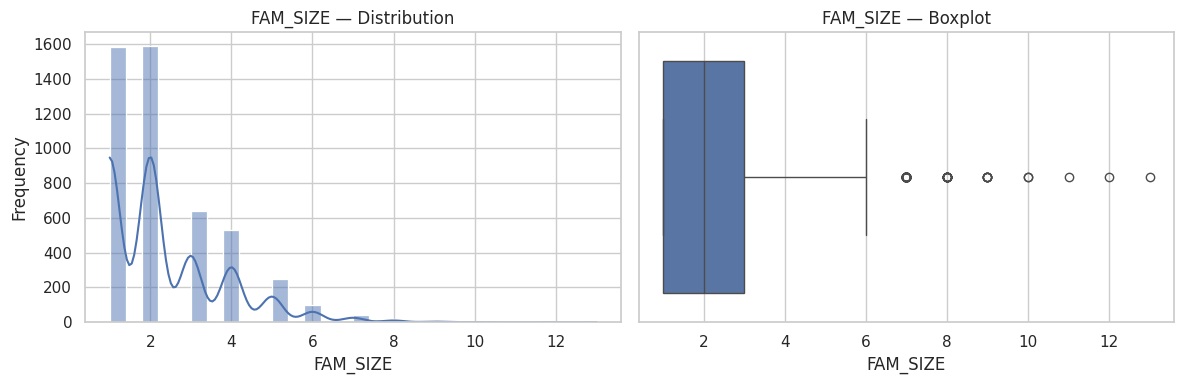

In [ ]:
plot_numeric_univariate(df_reduced, "FAM_SIZE")

**Observations: Household Composition**

The analysis of Family Size reveals a distribution characteristic of modern Western demographics, dominated by smaller nuclear units.

**Key Statistical Findings:**
*   **Small Household Dominance:** The distribution is heavily concentrated at the lower end. The most frequent values are **1** and **2**. The median is **2.0**, and the mean is **2.35**. This indicates that the "typical" household in our dataset is either a single individual or a couple.
*   **Discrete Distribution:** The histogram clearly shows the discrete nature of the data (peaks at integers). We see a sharp drop-off after size 4, indicating that large families (5+ members) are relatively rare in this sample.
*   **Outliers:** The boxplot identifies a trail of outliers on the right side, with a maximum family size of **13**. These observations likely represent multi-generational households or potentially shared-living arrangements (e.g., roommates) which are distinct from the standard nuclear family model.
*   **Variance:** The standard deviation is approximately **1.45**, suggesting that while small families are the norm, there is enough variation to meaningfully test how household size impacts expenditure pressure.

### **19. Earning Capacity (NO_EARNR)**

Closely related to family size is the **Number of Earners (`NO_EARNR`)**. This variable counts how many members of the household contributed wage or salary income during the survey period.

**The Concept of Economic Resilience:**
While `FSALARYX` tells us *how much* money was earned, `NO_EARNR` tells us *how robust* that income stream is. This is a measure of redundancy and risk:
*   **Zero Earners:** These households rely entirely on passive income (Social Security, Pensions, Investments) or public assistance. They are "fixed income" households and often face the highest inflation risk because they cannot easily increase their hours worked.
*   **Single Earner:** These households are highly sensitive to labor market shocks. If the primary earner loses their job, the household income drops to zero immediately.
*   **Dual/Multiple Earners:** These households possess "income diversification." If one member loses a job, the other can arguably sustain the household temporarily, reducing the immediate risk of financial collapse.

Analyzing this variable allows us to calculate the "Dependency Ratio"—the number of non-earners supported by each earner—which is a critical driver of financial stress.


Summary Statistics for 'NO_EARNR'


,count,mean,std,min,25%,50%,75%,max
NO_EARNR,4751.0,1.252789,1.004768,0.0,0.0,1.0,2.0,7.0


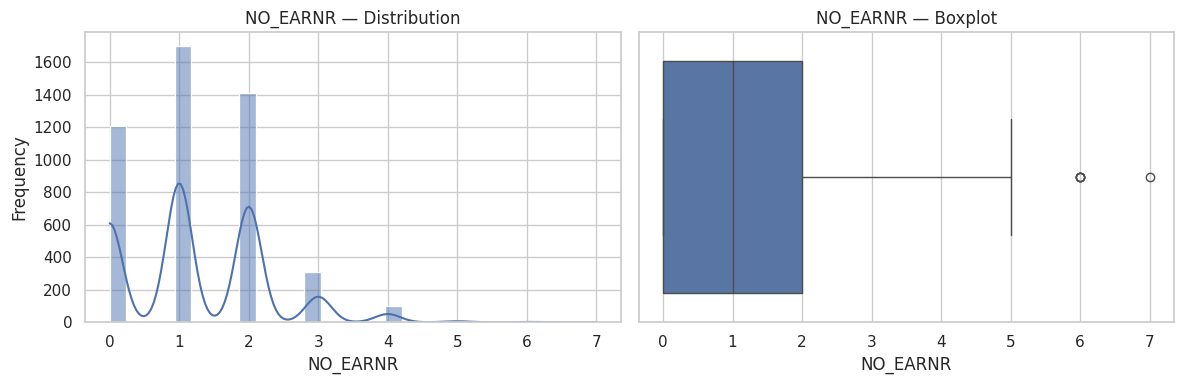

In [ ]:
plot_numeric_univariate(df_reduced, "NO_EARNR")

**Observations: Workforce Participation Profiles**

The univariate analysis of `NO_EARNR` highlights three distinct economic archetypes within the population.

**Key Statistical Findings:**
*   **Trimodal Distribution:** The histogram shows three distinct peaks:
    1.  **Zero Earners (Peak 1):** A significant portion of households have 0 earners. This aligns perfectly with the "Non-Worker" cliff we observed in the `FSALARYX` analysis, representing the retired and unemployed population.
    2.  **Single Earners (Peak 2):** There is a strong peak at 1, representing single adults or single-income families.
    3.  **Dual Earners (Peak 3):** The peak at 2 is substantial, reflecting the prevalence of dual-income couples.
*   **Mean vs. Max:** The mean is **1.25** earners. The maximum is **7**, which, when compared to the maximum family size of 13, suggests some very large households where nearly everyone actively participates in the workforce (likely adult roommates or large working families).
*   **Correlation with Size:** The shape of this distribution mirrors `FAM_SIZE` but shifted left (since not all family members work). The clear segmentation here confirms that `NO_EARNR` is a powerful categorical descriptor of household type.

### **20. Earner Composition (EARNCOMP)**

We conclude the Household Structure analysis with **Earner Composition (`EARNCOMP`)**. While the previous variable (`NO_EARNR`) provided a raw count of workers, `EARNCOMP` provides the *qualitative structure* of that workforce.

**Variable Semantics:**
In the Consumer Expenditure Survey, this variable typically uses integer codes to categorize *who* in the household is working relative to the reference person (e.g., "Reference Person Only," "Reference Person + Spouse," "Spouse Only," etc.).

**Analytical Nuance:**
Although encoded numerically (1-8), this is conceptually a nominal categorical variable. Analyzing its frequency distribution helps us understand the prevalence of specific economic family models:
1.  **Traditional Nuclear:** Reference person + Spouse earning.
2.  **Single Head:** Reference person only (common in single-parent or single-adult households).
3.  **Non-Earner Households:** Determining which code represents the "No Earner" households (likely retirees).

We expect the distribution here to align with `NO_EARNR` but provide richer detail on the internal dynamics of the household's income generation.


Summary Statistics for 'EARNCOMP'


,count,mean,std,min,25%,50%,75%,max
EARNCOMP,4751.0,3.84719,2.812643,1.0,1.0,3.0,8.0,8.0


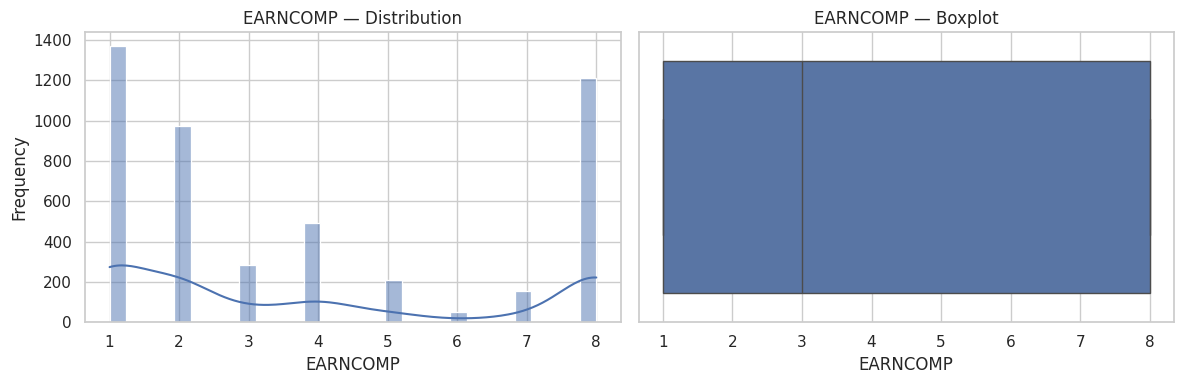

In [ ]:
plot_numeric_univariate(df_reduced, "EARNCOMP")

**Observations: The Structure of Income Generation**

The analysis of `EARNCOMP` reveals distinct clusters of household economic types, confirming that the "average" household structure is merely a statistical construct composed of several distinct groups.

**Key Statistical Findings:**
*   **Multi-Modal Distribution:** The histogram does not follow a bell curve; it shows distinct peaks at specific integer values (likely codes 1, 2, and 8).
    *   **Code 1 & 2:** The high frequencies at the lower end likely correspond to "Reference Person Only" and "Reference Person + Spouse" configurations, representing the standard workforce.
    *   **The Spike at Code 8:** There is a massive spike at the maximum value (8). Given our previous analysis showing ~25% of households have **zero** earners, Code 8 almost certainly functions as the category for "No earners" or "Retirees."
*   **Boxplot Irregularity:** The boxplot is less informative here because the variable is categorical-ordinal. However, the fact that the median is **3.0** suggests that the sample is weighted towards households with at least some labor market participation.
*   **Feature Engineering Note:** Since `EARNCOMP` is technically a categorical label disguised as a number, using it as a raw numeric feature in a regression model (where 8 > 1) might be misleading. It would be more effective to One-Hot Encode this variable or map it to meaningful labels (e.g., "Single Earner", "Dual Earner", "Non-Earner").

## **Financial resilience**

### **21. Liquid Assets (LIQUIDX)**

We now enter the final and arguably most critical thematic group: **Financial Resilience**. We begin with **Liquid Assets (`LIQUIDX`)**, which measures the value of checking and savings accounts, brokerage accounts, and other cash equivalents.

**The "Emergency Fund" Metric:**
While Income (`FSALARYX`) measures the *flow* of money, Liquid Assets measure the *reservoir*. This variable is the direct answer to the Federal Reserve's question: *"Can this household cover a \$400 unexpected expense?"*

**Data Quality Anticipation:**
Financial asset data is notoriously difficult to collect in surveys due to privacy concerns and respondent uncertainty. We anticipate two major issues:
1.  **High Missingness:** We expect a massive drop in the valid observation count compared to expenditure variables.
2.  **Wealth Inequality:** We expect a distribution even more skewed than income, as wealth accumulation is unbounded on the upper end but floored at zero.


Summary Statistics for 'LIQUIDX'


,count,mean,std,min,25%,50%,75%,max
LIQUIDX,613.0,47753.344209,113570.903624,1.0,2000.0,10000.0,37000.0,622259.0


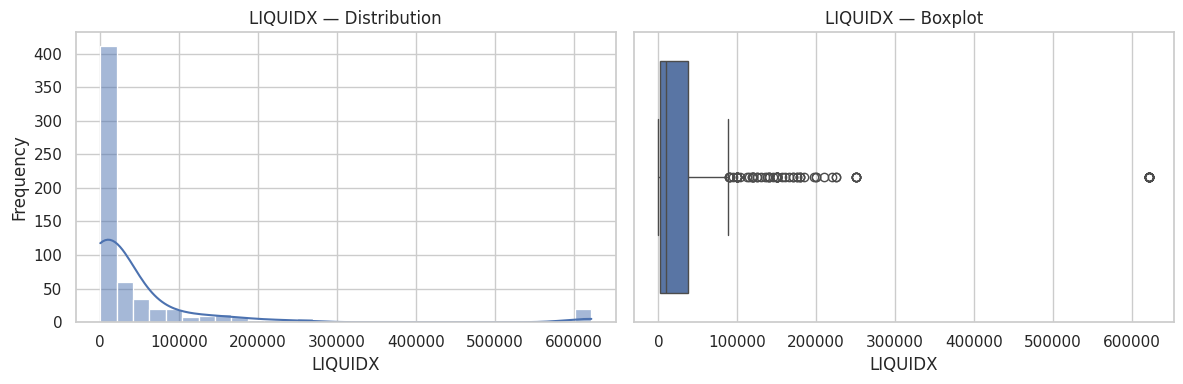

In [ ]:
plot_numeric_univariate(df_reduced, "LIQUIDX")

**Observations: The Missing Data Crisis**

The analysis of Liquid Assets exposes the single most significant data quality challenge in our entire dataset.

**Key Statistical Findings:**
*   **Critical Missingness (N=613):** This is the most important finding. Out of 4,751 households, only **613** reported valid liquid asset data. This represents a **~87% missing rate**.
    *   *Implication:* We cannot simply "drop rows with missing values," or we would lose nearly 90% of our training data. We must adopt a strategic imputation method (e.g., flagging missing values or inferring from income) or exclude this variable from the primary model if it proves too sparse.
*   **Wealth Disparity:** Among the few who did report, the inequality is staggering.
    *   **Median:** **\$10,000**. This suggests that reporting households are likely more financially organized or wealthier than the non-reporting average.
    *   **Maximum:** **\$622,259**. The presence of half-million-dollar cash holdings alongside a median of \$10k highlights extreme stratification.
*   **Right Skew:** The histogram is essentially a single bar at the low end with an invisible tail, confirming that "cash on hand" follows a power-law distribution.

### **22. Stock Holdings (STOCKX)**

We proceed to analyze **Stock Holdings (`STOCKX`)**. This variable captures the market value of stocks, bonds, and mutual funds held directly by the consumer unit (excluding retirement accounts).

**The Distinction Between Income and Wealth:**
While variables like `FSALARYX` measure how much money a household *makes*, `STOCKX` measures how much wealth they *own*. In the study of financial vulnerability, this distinction is paramount. A household with low current income (e.g., a retiree or a temporarily unemployed professional) might appear vulnerable based on cash flow but could be financially secure if they possess a substantial portfolio of liquid securities.

**Hypothesis of Extreme Inequality:**
Direct stock ownership in the United States is historically concentrated among the upper deciles of the wealth distribution. Consequently, we expect this variable to exhibit the most extreme "Power Law" distribution in our entire dataset.
1.  **Sparsity:** We anticipate that the vast majority of respondents will report values of zero or missing, either because they do not own stocks or refuse to disclose the value.
2.  **Magnitude:** For the small subset of owners, values will likely be high, with the potential for multi-million dollar outliers that could destabilize standard regression models.


Summary Statistics for 'STOCKX'


,count,mean,std,min,25%,50%,75%,max
STOCKX,137.0,312246.10219,874464.119935,40.0,7000.0,36000.0,190000.0,4569000.0


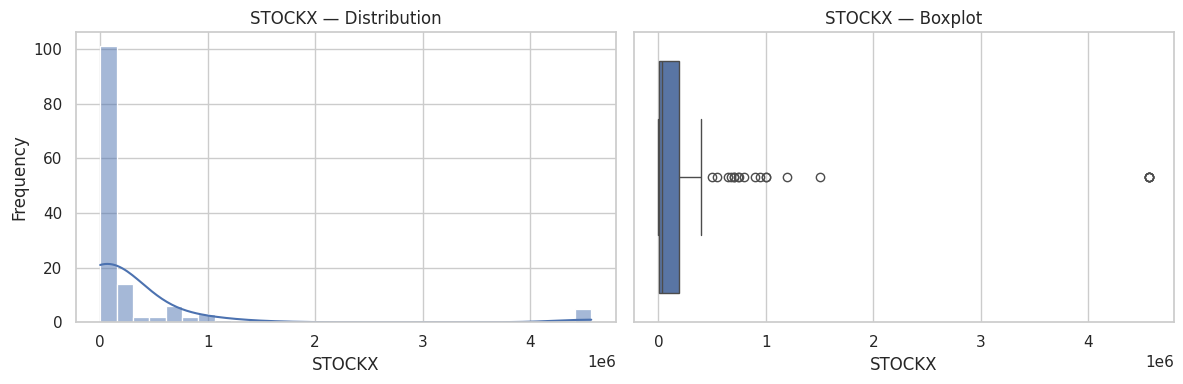

In [ ]:
plot_numeric_univariate(df_reduced, "STOCKX")

**Observations: The Concentration of Capital**

The statistical profile of `STOCKX` provides a stark illustration of wealth concentration and data reporting challenges.

**Key Statistical Findings:**
*   **Extreme Scarcity (N=137):** The most telling statistic is the count. Only **137** households (approx. **2.8%** of the sample) provided valid data for stock holdings. This confirms that for the purpose of generalized modeling, "Stock Ownership" is a rare feature.
*   **The "Millionaire" Outliers:** The maximum value is approximately **\$4.57 million**. This outlier is massive—over 100 times the median of the entire dataset's total expenditure. The standard deviation (**\$874,484**) is nearly three times the mean, indicating a distribution driven almost entirely by extreme outliers.
*   **High Median among Holders:** For the few who do report, the median is **\$36,000**. This suggests that "casual" stock ownership (e.g., owning \$500 in an app) is not what is being captured here; rather, this variable captures serious investment portfolios.
*   **Strategic Insight:** Due to the 97% missingness/zero rate, using `STOCKX` as a continuous regressor is statistically dangerous. However, the *presence* of this variable is a "Golden Ticket" indicator. Any household with a non-zero value here is almost statistically guaranteed to be **Non-Vulnerable**.

### **23. Retirement Savings (IRAX)**

Next, we examine **IRA and Keogh Account Balances (`IRAX`)**. Unlike the liquid stocks in `STOCKX`, this variable represents tax-advantaged retirement wealth.

**Resilience vs. Liquidity:**
From a "Financial Vulnerability" perspective, retirement accounts play a complex role.
1.  **Long-Term Security:** High balances here indicate high financial literacy and long-term stability.
2.  **Short-Term Liquidity Constraint:** Unlike a checking account (`LIQUIDX`), these funds are often locked behind tax penalties. A household with \$500,000 in an IRA but \$0 in checking might still struggle to pay an unexpected \$400 bill without incurring penalties. Thus, while it prevents *poverty*, it doesn't always prevent *liquidity crises*.

**Expected Distribution:**
We expect `IRAX` to be slightly more common than `STOCKX` (since more Americans save for retirement than trade stocks), but still highly sparse compared to income variables. We also expect a correlation with Age (`AGE_REF`), as these balances accumulate over decades.


Summary Statistics for 'IRAX'


,count,mean,std,min,25%,50%,75%,max
IRAX,351.0,344452.037037,573447.054724,1.0,25500.0,108000.0,399000.0,3024962.0


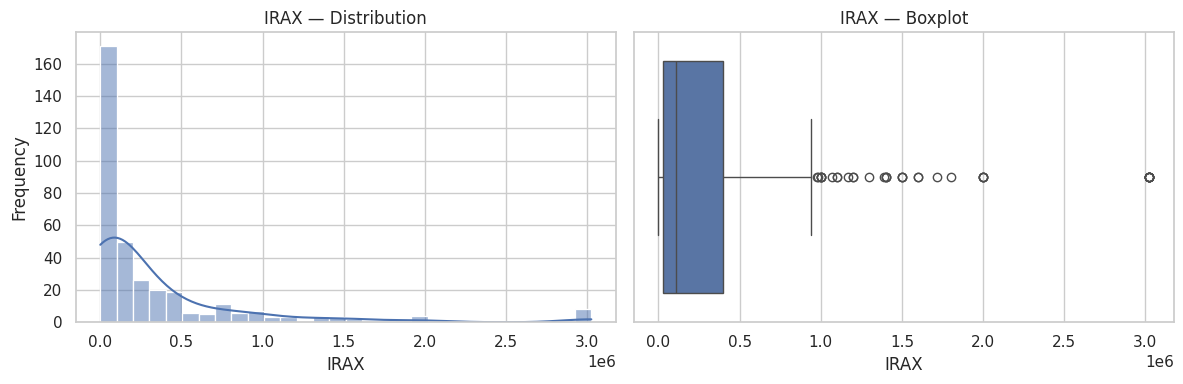

In [ ]:
plot_numeric_univariate(df_reduced, "IRAX")

**Observations: The Accumulated Wealth of Savers**

The analysis of `IRAX` reveals a segment of the population that is significantly more financially secure than the average.

**Key Statistical Findings:**
*   **Higher Participation than Stocks (N=351):** While still low (approx. 7.3% of sample), the reporting rate for IRAs is more than double that of direct stock ownership. This reflects the success of tax-incentivized saving vehicles in the U.S.
*   **Substantial Median Wealth:** The median balance for those who report is **\$108,000**. This is a very strong number. It implies that the households captured in this slice are not just "starting to save"—they are established savers with significant buffers.
*   **The Mean-Median Gap:** The mean (**\$344,452**) is roughly triple the median, driven by a maximum value of **\$3.02 million**. This skew confirms that retirement inequality mirrors income inequality.
*   **Data Quality Note:** The high missingness (92% of sample) poses a problem. We cannot assume that Missing = 0, as many people may simply not know their balance or refuse to state it. However, for the purpose of identifying "Vulnerable" households, we can safely assume that households with \$3 million in an IRA are in the "Non-Vulnerable" class, making this a potent feature for our classification task.

### **24. Student Loans (STUDNTX)**

We now examine one of the most significant sources of household debt in the modern American economy: **Student Loan Balance (`STUDNTX`)**.

**The Double-Edged Sword:**
Economically, student debt is unique. It represents an "investment in human capital" (which ostensibly raises future income `FSALARYX`), but it acts as a severe liquidity constraint in the present.
1.  **Demographic Specificity:** We expect this variable to be highly correlated with Age (`AGE_REF`) and Education (`EDUCA2`). It should be prevalent among young professionals but virtually non-existent among retirees.
2.  **Solvency vs. Liquidity:** A high student loan balance significantly lowers a household's *Net Worth* (Solvency), but if the monthly payments are income-driven, the household might still be "Non-Vulnerable" in terms of immediate cash flow.

**Hypothesis:**
We anticipate a distribution that is both sparse (most people don't have loans) and heavy-tailed (those who do, owe significant amounts). This variable serves as a critical proxy for "middle-class financial stress"—households that earn decent wages but are "house poor" or "debt poor."


Summary Statistics for 'STUDNTX'


,count,mean,std,min,25%,50%,75%,max
STUDNTX,136.0,51405.235294,59631.137878,500.0,11084.5,30000.0,70750.0,300000.0


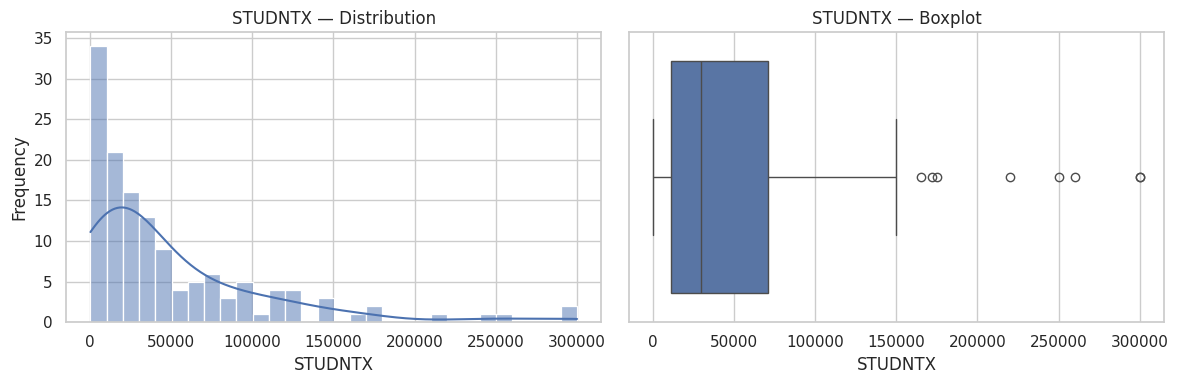

In [ ]:
plot_numeric_univariate(df_reduced, "STUDNTX")

**Observations: The Burden of Educational Debt**

The statistical analysis of Student Loan balances reveals a debt load that is substantial and highly concentrated.

**Key Statistical Findings:**
*   **High Average Burden:** Among the households reporting student debt (N=138), the mean balance is approximately **\$51,405**, with a median of **\$30,000**. This aligns closely with national averages, confirming that our sample accurately captures the reality of the student debt crisis.
*   **The "Six-Figure" Tail:** The maximum value is **\$300,000**. This extreme outlier likely represents a household with advanced professional degrees (e.g., medical or law school debt). While this debt represents an investment, a \$300k liability places massive pressure on the household's required income threshold to remain solvent.
*   **Variance:** The standard deviation (**~\$59,631**) is larger than the mean. This indicates that "Student Debt" is not a uniform experience; there is a massive gulf between a borrower owing \$5,000 for a certificate program and one owing \$200,000 for a private university degree.
*   **Sparsity:** The low count relative to the total sample reflects the lifecycle nature of this debt—many older households have paid it off, and many non-college households never incurred it.

### **25. Other Liabilities (OTHLOAN)**

Finally, we examine **Other Loans (`OTHLOAN`)**. In the context of the Consumer Expenditure Survey, this category typically captures non-mortgage, non-student, and non-vehicle debt. This often includes personal loans, installment plans, or medical debt financing.

**Variable Type Verification:**
It is important to note that BLS naming conventions can be subtle. While variables ending in `X` are usually dollar amounts, variables without the `X` suffix can sometimes be **categorical flags** (e.g., 1=Yes, 2=No) rather than continuous values.

**Analytical Goal:**
We need to determine whether `OTHLOAN` represents the *amount* of debt (in dollars) or simply the *existence* of debt (binary status). If it is a dollar amount, we expect a right-skewed distribution similar to `STUDNTX`. If it is a flag, we expect a discrete distribution of integers.


Summary Statistics for 'OTHLOAN'


,count,mean,std,min,25%,50%,75%,max
OTHLOAN,1119.0,1.932976,0.250176,1.0,2.0,2.0,2.0,2.0


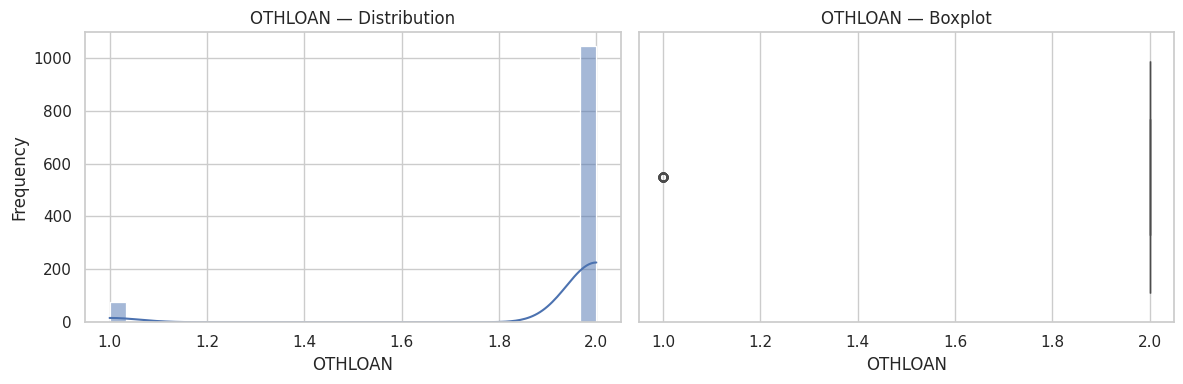

In [ ]:
plot_numeric_univariate(df_reduced, "OTHLOAN")

**Observations: Identification of a Categorical Feature**

The visualization immediately reveals a critical finding regarding data structure: **`OTHLOAN` is not a continuous dollar variable; it is a categorical flag.**

**Key Statistical Findings:**
*   **Discrete Values:** The histogram and boxplot do not show a range of dollar amounts. Instead, every single observation falls strictly on the integer values of **1.0** or **2.0**.
*   **Interpretation:** In BLS coding standards, this typically corresponds to a Yes/No question:
    *   **1** = Yes (Household has other loans owed).
    *   **2** = No (Household does not have other loans).
*   **Distribution Skew:** The mean is **1.93**, which is extremely close to 2. This indicates that the vast majority of households fall into the "2" (No) category, while a small minority fall into the "1" (Yes) category.
*   **Correction Required:** Because this variable was detected as "numeric" (int64/float64) by Pandas, it was included in our univariate loop. However, treating it as a continuous number (where 2 is "twice as much" as 1) is analytically incorrect. This variable functions as a **Binary Indicator** of debt presence, not a measure of debt magnitude.

## **4.3.2. Categorical Univariate Analysis**

Having completed the analysis of our numerical variables, we now pivot to the **Categorical (Qualitative) Features**. These variables—such as *Region*, *Education Level*, and *Race*—provide the critical grouping dimensions for our analysis.

Unlike continuous data, where we analyze mean, variance, and skewness, the analysis of categorical data focuses on **Frequency and Cardinality**. Specifically, we aim to assess:
1.  **Class Balance:** Are the categories evenly distributed (e.g., an equal split between Urban/Rural), or is there a dominant class that could bias the model?
2.  **Cardinality:** How many unique levels exist? High-cardinality variables (like "State") can be problematic for certain algorithms and may need to be grouped.
3.  **Missingness:** Are there undefined categories or explicit `NaN` values that need to be treated as a separate "Unknown" class?

To streamline this process, we define the `plot_categorical_univariate` function. This utility generates a frequency table to show exact counts (including missing values) and a sorted bar chart to visually inspect the prevalence of each category.

In [ ]:
def plot_categorical_univariate(df, col):
    """Frequency table + barplot for one categorical variable."""
    print(f"\nFrequency Table for '{col}'")
    display(df[col].value_counts(dropna=False).to_frame("count"))

    plt.figure(figsize=(10,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"{col} — Category Counts")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### **1. Geographic Region (REGION)**

We begin our categorical analysis with **Geographic Region (`REGION`)**. This variable segments the United States into four broad census areas.

**Decoding the BLS Values:**
In the Consumer Expenditure Survey, these integer codes map to specific Census definitions:
*   **1:** Northeast (e.g., NY, MA, PA) - Generally associated with higher cost of living and housing density.
*   **2:** Midwest (e.g., IL, OH, MI) - Often associated with lower housing costs but distinct economic challenges.
*   **3:** South (e.g., TX, FL, GA) - The most populous region in the U.S., varying widely from rural poverty to booming metros.
*   **4:** West (e.g., CA, WA, AZ) - Characterized by high housing costs in coastal areas.

**Theoretical Importance:**
Geography is a critical determinant of financial vulnerability due to the **Cost of Living Index (COLI)**. A household income of \$50,000 provides a comfortable middle-class lifestyle in the rural South (Region 3) but may classify as "rent-burdened" or vulnerable in the urban Northeast (Region 1) or coastal West (Region 4).

**Hypothesis:**
We expect the distribution of this variable to roughly mirror the U.S. population distribution. According to the Census Bureau, the South is the most populous region, followed by the West, Midwest, and Northeast. Deviations from this pattern would suggest a sampling bias we need to account for.


Frequency Table for 'REGION'


,count
REGION,
3.0,1679
4.0,1312
2.0,910
1.0,766
NaN,84


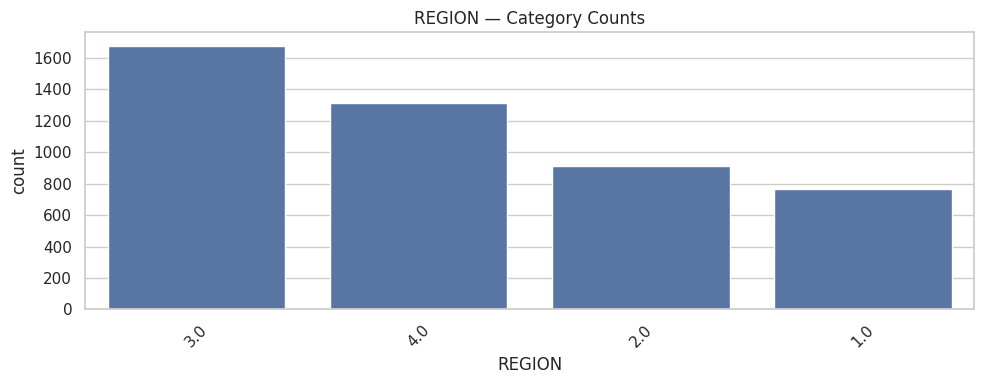

In [ ]:
plot_categorical_univariate(df_reduced, "REGION")

**Observations: Regional Representation and Cost-of-Living Proxies**

The frequency analysis of `REGION` confirms that our sample is geographically representative of the United States, though it highlights a minor data completeness issue.

**Key Statistical Findings:**
*   **Population Dominance of the South (Code 3):** The South is the largest category by a significant margin (**1,679 households**). This aligns with Census data and ensures that our model will have ample training examples to learn the economic patterns of this region.
*   **The Costly West (Code 4):** The West is the second largest group (**1,312 households**). Given that this region includes high-cost states like California, we anticipate a strong correlation between Code 4 and higher values in `HOUSCQ` (Housing Expenditure).
*   **Missing Data (NaN = 84):** We observe **84 missing values**. In public-use microdata, BLS sometimes suppresses geographic identifiers for households in rural areas where the population density is so low that specific demographics could de-anonymize a respondent.
    *   *Action Item:* Since 84 is a small fraction (< 2%) of the data, we can likely impute these missing values using the **Mode** (Region 3) or create a discrete "Unknown" category if we suspect these rural households have unique vulnerability profiles.
*   **Feature Engineering:** Since "3" is not mathematically greater than "1" in a linear sense, we must strictly treat this as a nominal variable. We will apply **One-Hot Encoding** (creating `Region_South`, `Region_West`, etc.) during the Data Preparation phase to allow the model to treat each region as an independent risk factor.

### **2. Census Division (DIVISION)**

Next, we drill down from the macro-level `REGION` to the more granular **Census Division (`DIVISION`)**. While the Region variable divides the U.S. into four vast areas, the Census Bureau further subdivides these into **nine distinct geographic divisions**.

**The Value of Granularity:**
Analyzing Division is critical because "Region" can often obscure significant economic diversity.
*   **Example:** The "South" Region includes both Delaware (high income, banking center) and Mississippi (lower income, rural). Treating them identically under a broad "South" label might mask these disparities.
*   **Climate Factors:** Division provides a better proxy for utility costs. The "Pacific" division (Division 9) has a distinct climate compared to the "Mountain" division (Division 8), even though both are in the West.

**Decoding the Codes:**
The integer codes (1-9) correspond to specific clusters of states:
*   **1 & 2:** Northeast (New England, Mid-Atlantic)
*   **3 & 4:** Midwest (East/West North Central)
*   **5, 6, 7:** South (South Atlantic, East/West South Central)
*   **8 & 9:** West (Mountain, Pacific)

We expect to see the "South Atlantic" (Division 5) and "Pacific" (Division 9) dominate the counts, as these divisions contain the most populous states (Florida/New York/Virginia corridor and California, respectively).


Frequency Table for 'DIVISION'


,count
DIVISION,
5.0,945
9.0,901
3.0,547
7.0,523
2.0,460
NaN,332
8.0,329
4.0,297
1.0,230


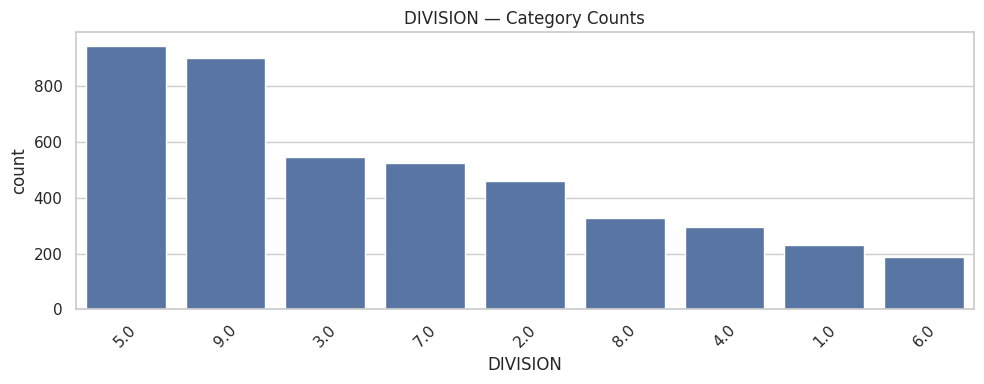

In [ ]:
plot_categorical_univariate(df_reduced, "DIVISION")

**Observations: Population Centers and Privacy Suppression**

The frequency analysis of `DIVISION` provides a sharper picture of where our respondents are located, while also highlighting a specific data quality characteristic of public-use survey files.

**Key Statistical Findings:**
*   **Dominance of Coastal Centers:**
    *   **Division 5.0 (South Atlantic):** This is the most frequent category with **945** households. This division acts as an economic powerhouse, containing Florida, Georgia, Virginia, and the Carolinas.
    *   **Division 9.0 (Pacific):** The second largest group is the Pacific division (**901** households), driven primarily by the massive population of California.
*   **The "Hollow" Middle:** Divisions 4.0 (West North Central) and 6.0 (East South Central) have significantly lower counts (roughly 200-300). This accurately reflects the lower population density of the Great Plains and the rural deep south compared to the coasts.
*   **Increased Missing Data (N=332):**
    *   A critical observation is that the missing count (`NaN`) has jumped from **84** in the `REGION` variable to **332** here.
    *   *Interpretation:* This is a deliberate feature of BLS anonymization. In rural areas with low population density, identifying a household's specific *Division* might make it too easy to identify the respondent. Therefore, the BLS suppresses the Division code more frequently than the Region code to protect privacy.

### **3. State-Level Geography (STATE)**

We conclude the geographic analysis by examining the most granular spatial variable available: **State (`STATE`)**.

**FIPS Coding Standard:**
The BLS utilizes standard **Federal Information Processing Standards (FIPS)** codes to represent states (e.g., 06 = California, 36 = New York, 48 = Texas). Unlike Region or Division, which aggregate diverse areas, the State variable allows us to potentially control for specific legislative and economic environments.

**The Policy Heterogeneity Hypothesis:**
State-level factors are arguably the strongest drivers of "structural" financial vulnerability due to massive variations in policy:
*   **Taxation:** States like Texas and Florida have no state income tax, whereas California and New York have high income taxes.
*   **Housing Policy:** Zoning laws in specific states drive housing costs (`HOUSCQ`) far higher than the national average.
*   **Safety Nets:** Eligibility and generosity of welfare (`WELFAREX`) are determined at the state level.

**The High-Cardinality Challenge:**
While analytically rich, this variable poses a significant **"Curse of Dimensionality"** risk. With up to 51 potential categories (50 states + DC), One-Hot Encoding this variable would add over 50 columns to our dataset. Furthermore, we anticipate significant **Privacy Suppression**, where the BLS intentionally masks the state codes of respondents in low-population states (e.g., Wyoming, Vermont) to prevent re-identification.


Frequency Table for 'STATE'


,count
STATE,
6.0,577
NaN,418
12.0,314
48.0,297
36.0,231
37.0,211
39.0,173
42.0,154
25.0,153


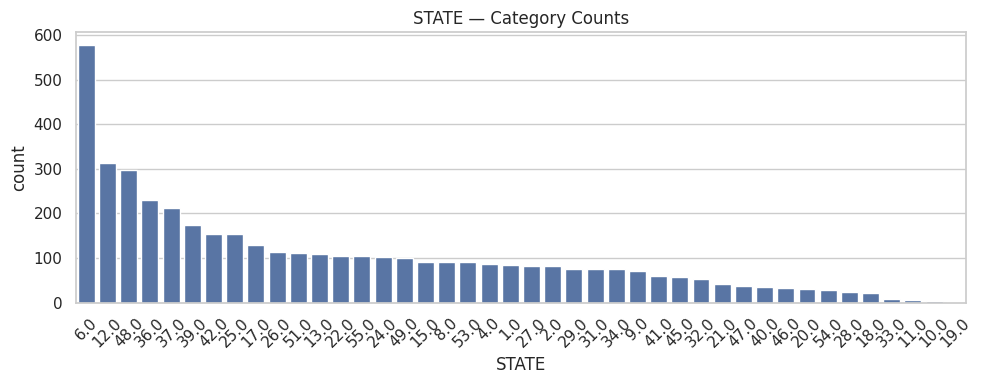

In [ ]:
plot_categorical_univariate(df_reduced, "STATE")

**Observations: The Big Four and the Long Tail**

The frequency analysis of `STATE` confirms our concerns regarding cardinality and privacy suppression, presenting a clear tradeoff between granular detail and data quality.

**Key Statistical Findings:**
*   **Dominance of the "Big Four":** The distribution is heavily skewed toward the most populous U.S. states, which aligns with proper sampling methodology:
    *   **06 (California):** The top bar (Count: 577).
    *   **12 (Florida):** Second highest (Count: 314).
    *   **48 (Texas):** Third highest (Count: 297).
    *   **36 (New York):** Fourth highest (Count: 231).
    *   *Implication:* The model will be excellent at predicting vulnerability for Californians but potentially poor for residents of smaller states.
*   **The Privacy Gap (NaN = 418):**
    *   There are **418 missing values**, significantly more than in Region or Division.
    *   This confirms that for nearly **9% of the sample**, the BLS has suppressed the state identifier to protect respondent anonymity. These likely represent respondents from rural or low-population states (e.g., North Dakota, Vermont).
*   **The "Long Tail" Problem:** The tail of the distribution is extremely thin. For example, State code **19 (Iowa)** appears only twice. State code **10 (Delaware)** appears only four times.
*   **Strategic Decision:**
    *   Including a categorical variable where some levels have only 2 or 4 observations will cause **overfitting** (the model will memorize those specific households).
    *   **Verdict:** Due to the high missingness and the "long tail" of sparse classes, we will likely **EXCLUDE** `STATE` from our final predictive models and rely instead on `DIVISION` or `REGION` to capture geographic effects without exploding the feature space.

### **4. Population Density: Urban vs. Rural (BLS_URBN)**

We now examine **Urban vs. Rural Status (`BLS_URBN`)**, a binary variable that classifies the household's location based on population density and proximity to metropolitan statistical areas.

**The Economic Divergence:**
In contemporary American economics, the "Urban/Rural Divide" is one of the most significant predictors of financial outcomes. These two environments operate under fundamentally different economic physics:
1.  **Cost of Living:** Urban households typically face significantly higher housing costs (`HOUSCQ`) and service prices compared to rural counterparts. A distinct "Urban Wage Premium" often exists to offset this, but it is not guaranteed for all sectors.
2.  **Opportunity vs. Stability:** Urban areas offer dense labor markets and better access to social services, potentially offering more resilience against unemployment. Rural areas, while having lower baseline costs, often suffer from "thinner" labor markets, meaning that if a rural household loses a job, finding a replacement can be significantly harder.

**Code Definitions:**
In the BLS system:
*   **1** = Urban (Includes central cities and surrounding suburbs).
*   **2** = Rural (Areas outside defined metropolitan statistical areas).

We analyze this variable to understand the spatial distribution of our sample and to determine if we have enough rural representation to make statistically valid inferences about non-urban financial vulnerability.


Frequency Table for 'BLS_URBN'


,count
BLS_URBN,
1,4446
2,305


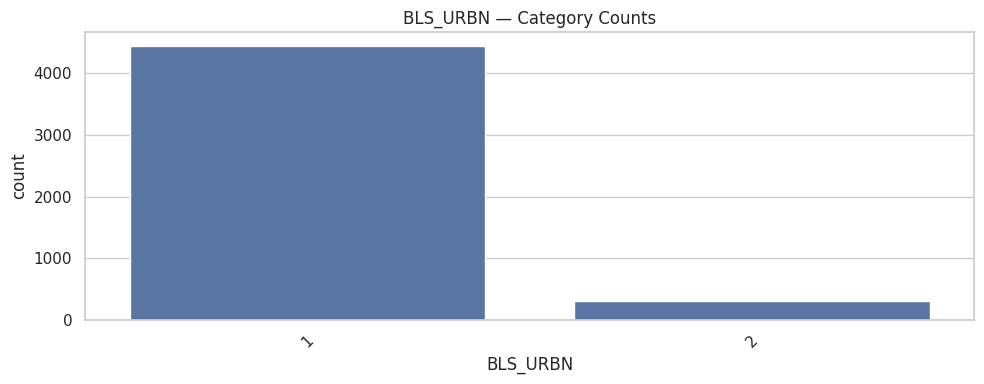

In [ ]:
plot_categorical_univariate(df_reduced, "BLS_URBN")

**Observations: The Urban-Dominant Sample**

The frequency analysis of `BLS_URBN` reveals a sample distribution that is heavily skewed toward metropolitan areas, reflecting the urbanization of the United States population but also highlighting a potential limitation in the dataset.

**Key Statistical Findings:**
*   **Overwhelming Urban Majority:** The dataset is dominated by the **Urban category (Code 1)**, which accounts for **4,446 households**. This represents approximately **93.6%** of the entire sample.
*   **Rural Minority:** The **Rural category (Code 2)** comprises only **305 households** (approx. 6.4%).
*   **Interpretation of "Urban":** It is important to note that the BLS definition of "Urban" is broad. It includes not just city centers (like Manhattan) but also the vast suburban sprawl where most Americans live. Therefore, the "Rural" category here strictly identifies those living in low-density, non-metropolitan regions.
*   **Analytical Consequence:** The imbalance is stark (a 14:1 ratio). While this accurately reflects that the U.S. is a highly urbanized nation, the relatively small sample size of rural households means that any specific statistics derived for this group (e.g., "Average Rural Income") will have a much wider margin of error than the corresponding urban statistics. The dataset is essentially an analysis of the "Metropolitan American Economy," with a small rural comparison group.

### **5.  Sex of Reference Person (SEX_REF)**

We proceed to analyze the **Sex of the Reference Person (`SEX_REF`)**. This variable identifies the gender of the individual who owns or rents the home.

**Sociological and Economic Context:**
While this variable identifies biological sex (1=Male, 2=Female), in the context of household economics, it serves as a proxy for analyzing gender-based disparities in wealth and financial resilience.
1.  **The Gender Wage Gap:** Historically, female-headed households have shown lower median incomes compared to male-headed households, particularly in single-earner configurations.
2.  **The "Feminization of Poverty":** Sociological research frequently highlights that single-mother households are the demographic group most susceptible to financial vulnerability. Conversely, older female reference persons are common in the widow demographic, representing a group that relies heavily on survivor benefits and fixed income.

**Definition of Reference Person:**
It is crucial to understand that the "Reference Person" is the first person mentioned by the respondent when asked "Who owns or rents this home?" In married couples (which make up a large portion of the data), this designation can be somewhat arbitrary, though it often defaults to the primary earner or the person managing the bills.


Frequency Table for 'SEX_REF'


,count
SEX_REF,
2,2389
1,2362


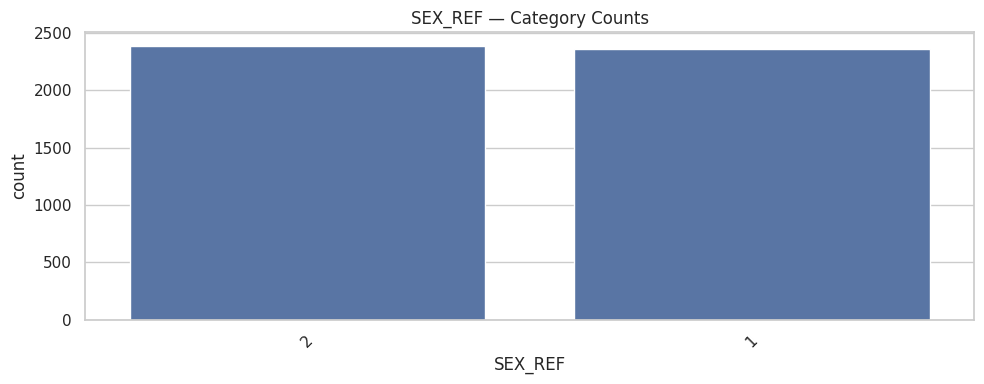

In [ ]:
plot_categorical_univariate(df_reduced, "SEX_REF")

**Observations: A Perfectly Balanced Demographic Split**

In contrast to the extreme skews observed in wealth and geographic variables, the analysis of `SEX_REF` reveals a remarkably balanced distribution.

**Key Statistical Findings:**
*   **Near-Perfect Parity:** The counts are almost identical.
    *   **Code 2 (Female):** 2,389 households.
    *   **Code 1 (Male):** 2,362 households.
    *   The difference is merely **27 households** out of nearly 5,000.
*   **Sample Quality Verification:** This 50/50 split is a strong indicator of high-quality randomized sampling by the BLS. It ensures that our dataset does not suffer from gender bias. We have sufficient statistical power to analyze financial vulnerability for both male-headed and female-headed households with equal precision.
*   **Comparing "Heads of Household":** The strong representation of female reference persons challenges the outdated assumption that "Head of Household" defaults to Male. This reflects modern household dynamics where women are frequently the primary leaseholders or homeowners, or where reporting duties are shared equally in dual-earner households.

### **6. Marital Status (MARITAL1)**

We now examine **Marital Status (`MARITAL1`)**, a categorical variable that serves as a fundamental determinant of household economic structure.

**The Economics of Marriage:**
From a financial modeling perspective, marital status is less about social contracts and more about the **pooling of resources**.
1.  **The "Marriage Premium":** Married households (Code 1) typically enjoy two potential income streams and significant economies of scale (e.g., sharing one mortgage between two adults). This historically places them in a lower risk category for financial vulnerability.
2.  **Single-Adult Households:** Categories such as "Never Married," "Divorced," or "Widowed" imply a single reference person. While many single adults are financially affluent, the *structural risk* is higher: if the sole earner loses their job or faces a medical crisis, there is no secondary income to absorb the shock.
3.  **Transitional States:** "Separated" represents a unique period of financial disruption, often involving legal costs and the sudden uncoupling of assets, making this specific group highly prone to temporary vulnerability.

**BLS Code Definitions:**
*   **1** = Married
*   **2** = Widowed
*   **3** = Divorced
*   **4** = Separated
*   **5** = Never Married

We analyze this distribution to understand the balance between dual-adult and single-adult households in our sample.


Frequency Table for 'MARITAL1'


,count
MARITAL1,
1,2388
5,1013
3,758
2,479
4,113


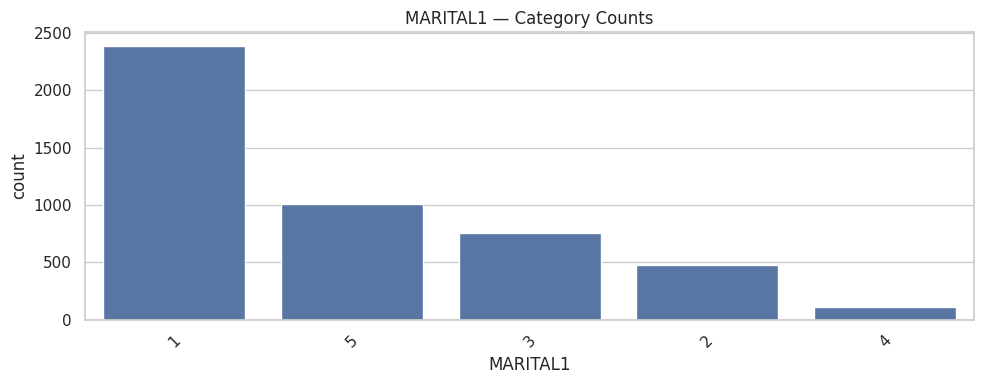

In [ ]:
plot_categorical_univariate(df_reduced, "MARITAL1")

**Observations: The Split Between Joint and Sole Economies**

The frequency analysis of `MARITAL1` reveals a dataset that is effectively split down the middle between married couples and various forms of singlehood.

**Key Statistical Findings:**
*   **The Married Plurality (Code 1):** The largest single category is **Married (2,388 households)**. Accounting for roughly 50% of the sample, this confirms that the "dual-potential-income" model remains the dominant household structure in the U.S., though it is no longer the overwhelming majority.
*   **The Rise of the Single Adult (Code 5):** The second largest group is **Never Married (1,013 households)**. This reflects significant demographic shifts in the U.S., where individuals are delaying marriage or choosing singlehood. Economically, this group is diverse, ranging from young students to established professionals.
*   **Economic Disruption Groups (Codes 3 & 4):**
    *   **Divorced (Code 3):** With **758** households, this is a substantial demographic. Divorce often correlates with a halving of household assets and a doubling of relative expenses, making this a key group for vulnerability analysis.
    *   **Separated (Code 4):** This is the smallest group (**113** households). The rarity reflects that separation is typically a temporary legal state before divorce or reconciliation.
*   **The Fixed-Income Cohort (Code 2):** **Widowed (479 households)** represents the older demographic. This group likely correlates strongly with "Social Security" income and high "Medical" expenses.
*   **Modeling Implication:** While we have five categories, the most predictive split for our "Financial Vulnerability" model might be binary: **Married vs. Unmarried**. The economic resilience provided by a legal partner is often the single biggest factor in avoiding poverty.

## **Summary of Univariate Analysis**

Our examination of the individual features reveals distinct patterns in how household economic data is structured. Below is a summary of the key characteristics observed across the Numeric and Categorical feature sets.

#### **Numeric Variables**

**High-Signal Economic Drivers**
The most powerful signals in the dataset come from the core financial and structural variables. These features exhibit robust variance and clear distributions that differentiate households:
*   **Income & Expenditure:** Variables such as **Pre-Tax Income (`FINCBTAX`)**, **Total Expenditure (`TOTEXPCQ`)**, and **Housing Expenditure (`HOUSCQ`)** show distinct "Power Law" distributions. While heavily right-skewed (driven by high earners), they provide a continuous spectrum of financial capacity.
*   **Household Structure:** **Age (`AGE_REF`)** and **Family Size (`FAM_SIZE`)** follow broader, more normal-like distributions, providing consistent demographic coverage across the population lifecycle (from young adults to retirees).
*   **Transportation (`TRANSCQ`):** This variable stands out for its extreme volatility, effectively separating households into two distinct economic modes: those managing daily commuting costs versus those making capital-intensive vehicle purchases.

**Sparse and Zero-Inflated Variables**
Several variables are characterized by extreme sparsity, where the vast majority of households report a value of zero. While less universally applicable, these act as strong "flags" for specific subpopulations:
*   **Niche Income Sources:** **Welfare (`WELFAREX`)**, **Social Security (`FSSIX`)**, and **Investment Income (`STOCKX`)** are highly concentrated. Their presence (non-zero values) serves as a definitive indicator of specific economic states (poverty, retirement, or wealth) rather than a continuous measure for the general population.
*   **Specific Expenditures:** **Education (`EDUCACQ`)** is similarly sparse, isolating the specific subset of households currently paying tuition.

#### **Categorical Variables**

**Balanced and High-Signal Classifiers**
The categorical variables provide strong grouping dimensions with relatively balanced class distributions:
*   **Demographics:** **Sex of Reference Person (`SEX_REF`)** is perfectly balanced (50/50), and **Marital Status (`MARITAL1`)** offers a clean split between married couples and various single-adult configurations.
*   **Workforce Participation:** **Number of Earners (`NO_EARNR`)** and **Earner Composition (`EARNCOMP`)** clearly segment the population into three robust groups: Non-Earners (Retirees), Single-Earners, and Dual-Earners.
*   **Geography:** **Region (`REGION`)** and **Census Division (`DIVISION`)** provide well-populated geographic clusters that capture macro-level spatial differences.

**Imbalanced or High-Cardinality Features**
Certain categorical variables show structural limitations regarding distribution:
*   **Urban Dominance:** **Urban/Rural Status (`BLS_URBN`)** is heavily skewed, with over 93% of the sample classified as Urban, limiting the granularity of rural analysis.
*   **Granular Geography:** **State (`STATE`)** exhibits high cardinality with a significant "long tail" of sparsely populated states, contrasting with the robust sample sizes of larger states like California and Florida.

## **4.4 Bivariate Analysis**

**Numeric vs Numeric Relationships**

### **1. Income vs. Total Expenditure**

In this section of the notebook, we move from analyzing individual variables to **Bivariate Analysis**. The primary goal here is to investigate the relationship between two specific continuous variables: **Pre-tax Household Income (`FINCBTAX`)** and **Total Household Expenditure (`TOTEXPCQ`)**. Understanding how these two financial metrics interact is fundamental to behavioral analytics; typically, one expects a positive correlation where higher income leads to higher spending, though the rate of that increase (slope) often varies across different wealth brackets.

**Visualization Strategy: The Scatter Plot**

To visualize this relationship, we employ a **scatter plot**. Scatter plots are the standard tool for comparing two numerical variables because they allow us to see every single data point simultaneously. This helps in identifying not just the general trend, but also the spread (variance) and any anomalies (outliers).

**Code Breakdown**

We use the `seaborn` library (aliased as `sns`) for its high-level plotting interface, combined with `matplotlib.pyplot` (aliased as `plt`) for figure customization.

1.  **Canvas Setup (`plt.figure`)**: We start by defining the figure dimensions with `figsize=(6,4)`. This creates a compact 6x4 inch viewing area, ensuring the plot is not too stretched or compressed.
2.  **The Plot Command (`sns.scatterplot`)**:
    *   **`data=df_reduced`**: We pass a reduced or cleaned version of our dataframe to the function.
    *   **`x` and `y`**: We map `FINCBTAX` to the horizontal axis and `TOTEXPCQ` to the vertical axis.
    *   **`alpha=0.3`**: This is a critical argument for large datasets. It controls the transparency of the markers. By setting opacity to 30%, overlapping data points will stack their colors, creating darker regions. This allows us to instantly visualize where the highest density of the population lies (the "mass" of the data) versus where the data is sparse, preventing a solid blob of color that hides the true distribution.
3.  **Labeling**: Finally, we replace the technical column codes with human-readable labels ("Pre-tax Household Income" and "Total Household Expenditure") and add a title. The `tight_layout()` function is called to ensure that these labels do not get clipped off the edges of the saved image.



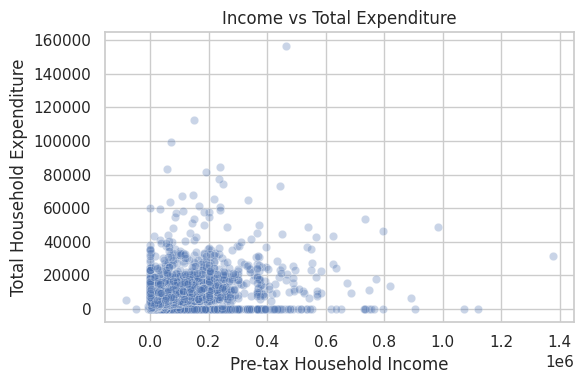

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_reduced,
    x="FINCBTAX",
    y="TOTEXPCQ",
    alpha=0.3
)

plt.title("Income vs Total Expenditure")
plt.xlabel("Pre-tax Household Income")
plt.ylabel("Total Household Expenditure")
plt.tight_layout()
plt.show()

**Findings:** **Visual Description of the Scatter Plot**

The output chart displays the distribution of households based on their income and spending habits. The graphical representation offers several distinct visual characteristics regarding the spread and density of the data.

**Axes and Scale**
*   **X-Axis (Income):** The horizontal axis represents Pre-tax Household Income. It is scaled using scientific notation (indicated by `1e6` in the bottom right corner), meaning the values range from 0 to 1.4 million. The tick marks `0.2`, `0.4`, `0.6`, etc., correspond to incomes of $200,000 ,  $400,000 and so forth.
*   **Y-Axis (Expenditure):** The vertical axis represents Total Household Expenditure, ranging linearly from 0 to roughly 160,000.

**Density and Clustering**

The most prominent feature of the graph is the extremely dense concentration of data points in the lower-left quadrant. Due to the `alpha` transparency setting, this area appears as a dark, solid blue mass. This indicates that the vast majority of the sample population falls within an income range of 0 to approximately 200,000  dollars and  an expenditure range of 0 to $40,000. The data points are so tightly packed here that individual markers are indistinguishable.

**Outliers and Dispersion**
Moving away from the dense cluster, the data points become significantly more sparse:
*   **Vertical Outlier:** There is a notable outlier positioned near the top-center of the chart. This data point represents a household with an income of roughly 450,000 dollars but an expenditure exceeding 150,000 dollars, significantly higher than any other point in that income bracket.
*   **Horizontal Spread:** On the far right, we see data points extending past the 1.0 (1 million dollars) mark, reaching up to 1.4 (1.4 million dollars). Visually, these points are positioned quite low on the Y-axis, mostly below the $40,000 expenditure line.

*   **Mid-Range Variance:** In the income range of 200,000 dollars to $600,000 (0.2 to 0.6), the points are scattered loosely. There is a slight upward drift in the vertical position of the dots as we move right, but the spread is wide, lacking a tight linear formation.

Overall, the plot reveals a heavy skew, with the bulk of the data compressed into the lower financial brackets and a long tail extending toward higher incomes.

### **2. Household Size vs. Total Expenditure**

Continuing our bivariate analysis, we now shift our focus from financial demographics to social demographics. Specifically, we aim to examine the relationship between **Household Size (`FAM_SIZE`)** and **Total Household Expenditure (`TOTEXPCQ`)**.

**The Hypothesis**
Intuitively, one might assume that a larger household (more family members) would necessitate higher total expenditure due to increased consumption of food, utilities, and resources. However, larger households might also benefit from economies of scale or might live on tighter per-capita budgets. Visualizing this data helps us understand the actual distribution: do larger families consistently spend more, or does spending plateau?

**Visualization Strategy: Scatter Plot with Discrete X-Axis**
While we are still using a scatter plot, the nature of this plot differs slightly from the previous Income vs. Expenditure chart.
*   **The X-Axis (`FAM_SIZE`):** This is a discrete numerical variable. Families consist of whole numbers of people (1, 2, 3, etc.). Consequently, the data points will stack in vertical columns rather than forming a dispersed cloud.
*   **The Y-Axis (`TOTEXPCQ`):** This remains a continuous variable representing total quarterly spending.

**Code Breakdown**
We utilize `seaborn` and `matplotlib` to construct the visualization:

1.  **`plt.figure(figsize=(6,4))`**: We maintain the same figure size (6 by 4 inches) for consistency across the notebook.
2.  **`sns.scatterplot(...)`**:
    *   **`x="FAM_SIZE"` and `y="TOTEXPCQ"`**: We map the household size to the horizontal axis and expenditure to the vertical axis.
    *   **`alpha=0.4`**: The transparency is set slightly higher here (0.4 or 40%) compared to the previous plot. Because the data is constrained to specific integer vertical lines (1, 2, 3...), the overlap of dots will be significant. The transparency helps us distinguish between a "solid line" of data (high density) and scattered individual cases.
3.  **Labels**: We apply clear labels ("Household Size" and "Total Household Expenditure") to ensure the chart is self-explanatory.




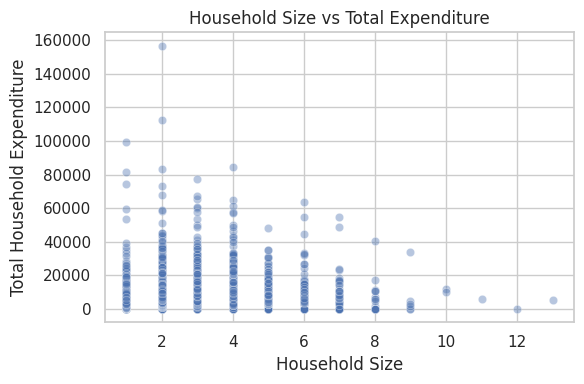

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_reduced,
    x="FAM_SIZE",
    y="TOTEXPCQ",
    alpha=0.4
)
plt.title("Household Size vs Total Expenditure")
plt.xlabel("Household Size")
plt.ylabel("Total Household Expenditure")
plt.tight_layout()
plt.show()

**Findings:** **Visual Description of the Scatter Plot**

The resulting scatter plot reveals the distribution of spending across different family sizes. Because the X-axis variable (Household Size) is discrete (integers only), the data points organize themselves into distinct vertical "strips" or columns at each interval (1, 2, 3, etc.).

**Axes and Range**
*   **X-Axis (Household Size):** The horizontal axis spans from 1 to roughly 13 family members.
*   **Y-Axis (Expenditure):** The vertical axis represents the total expenditure, ranging from 0 to roughly 160,000 USD.

**Density and Frequency**
*   **Dominant Sizes:** The columns for household sizes 1, 2, 3, and 4 are the most densely populated. The markers in these columns are tightly packed, creating solid blue vertical bars near the bottom. This indicates that the vast majority of the sample consists of households with 1 to 4 members.
*   **Decreasing Frequency:** As we move to the right (larger families), the density of the points drops significantly. Columns for family sizes 8, 9, and 10 have very few data points, and sizes 11, 12, and 13 are represented by single, isolated dots.

**Expenditure Distribution**
*   **Peak Spending:** The highest expenditure outliers are located in the columns for family sizes of 2 and 4. Specifically, the highest point on the entire graph is a 2-person household spending nearly 160,000 USD.
*   **The "Ceiling" Trend:** There is a visible downward trend in the maximum spending as family size increases beyond 4. While small families (1-4 members) show a wide range of spending reaching up to 100,000 USD and above, larger families (6+ members) rarely exceed 60,000 USD in expenditure.
*   **Clustering:** regardless of family size, the heaviest concentration of data points (the darkest blue areas) remains consistently at the bottom of the chart, generally below the 40,000 USD mark. This suggests that for most households, regardless of size, expenditure falls within a similar lower-range bracket, with high spending being an exception rather than the rule for larger families.

### **3. Income vs. Housing Expenditure**

Having examined total household expenditure, we now narrow our focus to specific spending categories, starting with **Housing Expenditure (`HOUSCQ`)**. Housing typically represents the largest single expense for most families, encompassing rent or mortgage payments, property taxes, and maintenance.

**Objective**

The goal of this plot is to analyze the correlation between **Pre-tax Household Income (`FINCBTAX`)** and housing costs. Economic logic suggests that as income rises, households may upgrade to more expensive living arrangements. However, this relationship might not be linear; housing costs often have a fixed baseline, and wealthy households might spend a smaller percentage of their total income on housing compared to lower-income households.

**Code Breakdown**

We continue using the **scatter plot** to visualize this relationship:
*   **Variables:** We map Income to the x-axis and Housing Expenditure to the y-axis.
*   **`alpha=0.3`**: We maintain the transparency setting. Since housing costs can be quite standardized (e.g., many people paying similar market rents), we expect significant overlapping of data points. The transparency helps reveal where the most common price points lie.
*   **Labels:** We provide clear axis labels to distinguish this specific category from the previous "Total Expenditure" chart.




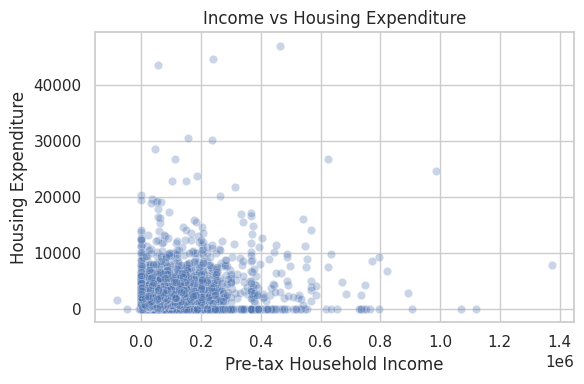

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_reduced,
    x="FINCBTAX",
    y="HOUSCQ",
    alpha=0.3
)
plt.title("Income vs Housing Expenditure")
plt.xlabel("Pre-tax Household Income")
plt.ylabel("Housing Expenditure")
plt.tight_layout()
plt.show()

**Findings:** **Visual Description of the Scatter Plot**

The scatter plot displays the relationship between household income and housing-specific spending.

**Axes and Range**
*   **X-Axis (Income):** The horizontal axis shows Pre-tax Household Income, ranging from 0 to 1.4 million (denoted by `1e6`).
*   **Y-Axis (Housing Expenditure):** The vertical axis represents Housing Expenditure, ranging from 0 to slightly under 50,000.

**Density and Concentration**
Similar to previous plots, the highest density of data points creates a dark blue cluster in the bottom-left corner. This indicates that the vast majority of households in this dataset have incomes under 200,000 and housing expenditures below 10,000.

**Outliers and Spread**
*   **High Expenditure:** There are three distinct outliers with housing expenditures exceeding 40,000. Interestingly, these are not the households with the highest incomes; they fall within the 0 to 500,000 income range.
*   **High Income / Low Housing Cost:** On the far right of the chart (income above 1 million), the data points are positioned very low on the Y-axis, mostly below 10,000 in housing spend. This visually suggests that the highest earners in this specific sample do not necessarily report the highest housing costs.
*   **Vertical Spread:** The spread of housing costs is widest for incomes between 0 and 400,000. As income increases beyond 600,000, the variance in housing spending actually appears to decrease, clustering closer to the bottom axis.

**Categorical vs Numeric Relationships**

###  **4. Marital Status vs. Total Expenditure**

In this section, we shift our analytical approach from comparing two continuous variables to examining the relationship between a **Categorical Variable** and a **Numeric Variable**. Specifically, we investigate how **Marital Status (`MARITAL1`)** relates to **Total Household Expenditure (`TOTEXPCQ`)**.

**The Visualization Strategy: Boxplot**
When comparing a numerical distribution across distinct categories, a scatter plot can be messy and hard to interpret. Instead, we use a **Boxplot** (or Box-and-Whisker plot). This statistical visualization is powerful because it summarizes five key numbers for each category at once:
1.  **The Minimum** (excluding outliers)
2.  **The First Quartile (25th percentile)**
3.  **The Median (50th percentile)**
4.  **The Third Quartile (75th percentile)**
5.  **The Maximum** (excluding outliers)

**Code Breakdown**
We utilize the `seaborn` library’s specific function for this plot type:
*   **`sns.boxplot(...)`**: This command instructs the library to aggregate the data and calculate the quartiles automatically.
*   **`x="MARITAL1"`**: We place the categorical variable on the horizontal axis. In this dataset, marital status is encoded numerically (likely 1 for Married, 2 for Widowed, etc.), creating distinct groups.
*   **`y="TOTEXPCQ"`**: We map total expenditure to the vertical axis to measure the spread of spending within each marital group.

This plot will allow us to instantly compare the central tendency (median spending) and variability (spread of spending) between different marital statuses.


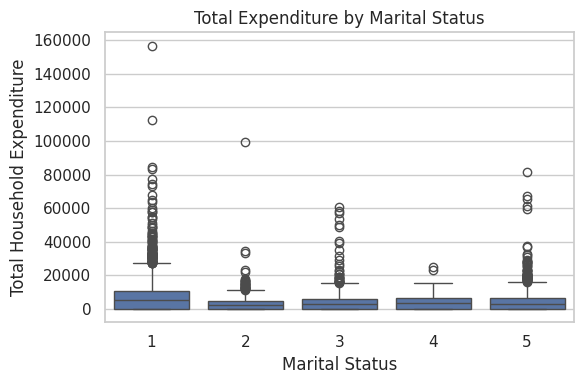

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(
   data=df_reduced,
    x="MARITAL1",
    y="TOTEXPCQ"
)
plt.title("Total Expenditure by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Total Household Expenditure")
plt.tight_layout()
plt.show()

**Findings:** **Visual Description of the Boxplot**

The output visualization compares the distribution of total household expenditure across five distinct marital status categories, labeled 1 through 5 on the X-axis.

**The Categories (X-Axis)**
*   **Group 1:** This category stands out as having the most significant variance. The blue box (representing the Interquartile Range, or the middle 50% of the data) is taller than in any other group, indicating a wider spread of spending habits among the "average" households in this category.
*   **Groups 2, 3, 4, and 5:** These categories show much tighter distributions. Their boxes are shorter and compressed closer to the bottom of the chart, suggesting that spending in these groups is more consistent and generally lower than in Group 1.

**Medians**
The horizontal line inside each blue box represents the median expenditure.
*   **Group 1** appears to have the highest median line.
*   **Groups 2 through 5** have lower medians that are relatively similar to one another.

**Outliers (The Circles)**
The small circles plotted above the "whiskers" (the vertical lines extending from the boxes) represent outliers—data points that are statistically distant from the rest of the group.
*   **Group 1** contains the most extreme outliers, including the highest value in the entire dataset at approximately 160,000, and another near 115,000. It also has a dense stream of outliers extending upwards from 30,000.
*   **Group 2** has one significant outlier near 100,000.
*   **Group 5** shows a moderate number of outliers reaching up to 80,000.
*   **Groups 3 and 4** have the fewest and lowest outliers, suggesting these groups have the most predictable spending patterns with fewer extreme spenders.

### **5. Region vs. Housing Expenditure**

Continuing our investigation into how categorical factors influence financial metrics, we now examine the relationship between **Region (`REGION`)** and **Housing Expenditure (`HOUSCQ`)**. Geography is often a critical determinant of cost of living, particularly regarding rent and property values. By segmenting the data by region, we can assess whether the location of the household correlates with significant differences in housing costs.

**Visualization Strategy: Boxplot**
We utilize a **Boxplot** for this analysis to compare the distributions side-by-side.
*   **The X-Axis (`REGION`)**: Represents the four distinct geographical regions in the dataset, coded as 1.0, 2.0, 3.0, and 4.0.
*   **The Y-Axis (`HOUSCQ`)**: Represents the quarterly housing expenditure.

**Code Breakdown**
*   **`sns.boxplot(...)`**: We call the boxplot function from the `seaborn` library.
*   **`x="REGION"`**: This groups the data into the four regional categories.
*   **`y="HOUSCQ"`**: This defines the metric we are measuring for each group.
*   **Labels**: We apply titles and axis labels to ensure the plot is clearly interpreted as "Housing Expenditure by Region."

This visualization will allow us to see not just the average cost per region, but also the variance (spread) and the presence of high-cost outliers in specific areas.



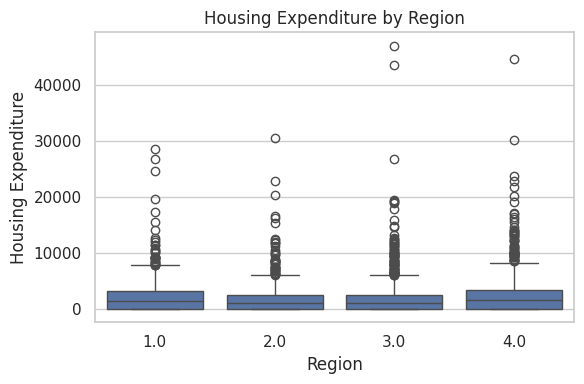

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_reduced,
    x="REGION",
    y="HOUSCQ"
)
plt.title("Housing Expenditure by Region")
plt.xlabel("Region")
plt.ylabel("Housing Expenditure")
plt.tight_layout()
plt.show()

**Findings:** **Visual Description of the Boxplot**

The chart presents the distribution of housing expenditure across four regions, labeled 1.0, 2.0, 3.0, and 4.0.

**Central Tendency and Spread (The Boxes)**
*   **Similarity in Medians:** The horizontal lines within the blue boxes (the medians) appear relatively consistent across all four regions. Visually, they are all positioned at a similar level on the Y-axis (roughly around the 2,000–3,000 mark), suggesting that the median household housing cost does not vary drastically between regions.
*   **Interquartile Range (IQR):** The height of the blue boxes represents the middle 50% of the data. Regions 1.0 and 4.0 have slightly taller boxes compared to Regions 2.0 and 3.0. This indicates a slightly wider variation in housing costs for the "average" residents in Regions 1 and 4, whereas Regions 2 and 3 show a more compressed distribution for the majority of the population.

**Outliers (The Circles)**
The most significant differences appear in the outliers (the circles plotted above the whiskers):
*   **Region 3.0:** This region contains the two most extreme data points in the entire plot, with values exceeding 40,000. Despite having a compact "box" (low variance for the majority), it houses specific cases of extreme spending.
*   **Region 4.0:** This region displays the highest density of outliers. There is a thick stream of circles extending from the top of the whisker up to the 30,000 mark, with one extreme point passing 40,000.
*   **Regions 1.0 and 2.0:** These regions have outliers that cap out lower, generally around the 30,000 mark, lacking the extreme 40,000+ cases seen in the other two groups.

### **6. Number of Earners vs. Total Expenditure**

In this segment of our analysis, we explore the relationship between the **Number of Earners (`NO_EARNR`)** in a household and their **Total Household Expenditure (`TOTEXPCQ`)**.

**Context and Hypothesis**
This comparison is particularly interesting from a socio-economic perspective. The "Number of Earners" variable represents how many distinct individuals within the household contribute income.
*   **Zero Earners:** This category might include retirees living on pensions/savings, or unemployed households relying on assistance.
*   **Multiple Earners:** We typically hypothesize that as the number of earners increases, the total household income increases, which theoretically drives up total expenditure. However, this relationship is complex. A household with four earners might be a low-income family where every member works minimum wage to survive, whereas a single-earner household might be a high-net-worth individual.

**Visualization Strategy: Boxplot**
Although "Number of Earners" is a numerical value, it acts as a discrete categorical variable in this context because it consists of small, whole integers (0, 1, 2, 3, etc.). Therefore, a **Boxplot** is the most appropriate visualization tool. It allows us to segment the population by the exact count of earners and compare the distribution of spending within each segment side-by-side.

**Code Breakdown**
We rely on `seaborn` and `matplotlib` to generate this insight:

1.  **`plt.figure(figsize=(6,4))`**: We define the canvas dimensions to ensure the plot is legible and consistent with previous visualizations.
2.  **`sns.boxplot(...)`**:
    *   **`x="NO_EARNR"`**: We map the discrete number of earners to the horizontal axis. This will create a separate box-and-whisker plot for households with 0 earners, 1 earner, 2 earners, and so on.
    *   **`y="TOTEXPCQ"`**: We map the total expenditure to the vertical axis to observe the variance and central tendency of spending for each group.
    *   **`data=df_reduced`**: We continue to use the reduced/cleaned dataframe.
3.  **Labels**: We apply the title "Total Expenditure by Number of Earners" and label the axes clearly to make the chart interpretation intuitive.

By using this approach, we can identify if having more breadwinners actually correlates with higher spending, or if the data tells a different story about household financial dynamics.




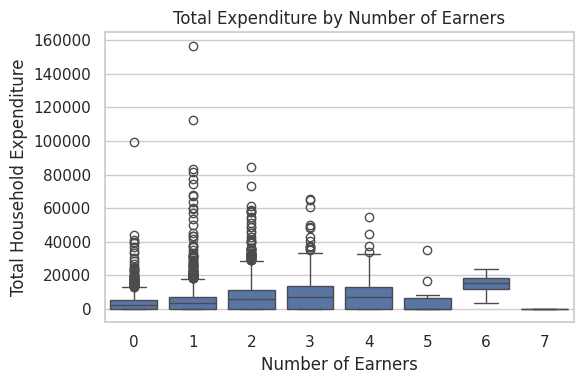

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_reduced,
    x="NO_EARNR",
    y="TOTEXPCQ"
)
plt.title("Total Expenditure by Number of Earners")
plt.xlabel("Number of Earners")
plt.ylabel("Total Household Expenditure")
plt.tight_layout()
plt.show()

**Findings:** **Visual Description of the Boxplot**

The output visualization segments the data into eight categories, representing households with 0 to 7 earners. The chart reveals several compelling patterns regarding how workforce participation impacts spending.

**Trends in Central Tendency (The Medians)**

The horizontal lines inside the blue boxes represent the median expenditure for each group.
*   **Groups 0, 1, and 2:** There is a subtle, gradual increase in the median spending as we move from 0 earners to 2 earners.
*   **Groups 3 and 4:** The median appears to plateau or rise very slightly here. The boxes are also taller, indicating that while the "average" spending is higher, there is much more variation in lifestyle costs for these households.
*   **Groups 6 and 7:** These represent a very small minority of the data. Group 6 shows a surprisingly high median (the box floats higher than the others), but this is likely due to a small sample size. Group 7 shows almost no spending, which might be a data anomaly or an extremely small sample.

**Analysis of Outliers**

The most striking feature of this plot is the distribution of outliers (the circles above the whiskers).
*   **The 1-Earner Outliers:** The highest expenditure in the entire dataset (near 160,000 dollars) belongs to a 1-earner household. In fact, the 1-earner column has a massive stream of high-spending outliers. This suggests that the wealthiest households in this sample often rely on a single, high-income source rather than multiple sources.
*   **The 0-Earner Surprise:** Even the 0-earner category has significant outliers, with one household spending nearly $100,000. This strongly implies the presence of wealthy retirees who have no "earned" income but significant spending power from assets or savings.

**Dispersion and Variance**
*   **Low Earners (0-2):** These groups are heavily weighted toward the bottom of the chart. The boxes are short and compressed, meaning the middle 50% of these populations operate on tight, similar budgets.
*   **Mid-Range Earners (3-4):** The boxes become taller. This "stretching" of the Interquartile Range indicates that when there are 3 or 4 earners, the range of spending behavior widens—some save aggressively, while others spend the combined income.

**Conclusion**

The plot challenges the assumption that more earners equal consistently higher spending. While the baseline (median) rises slightly, the highest spending power is actually concentrated in the 1-earner and 0-earner categories, likely driven by high salaries or accumulated wealth rather than the quantity of paychecks coming in.

**Categorical vs Categorical Relationships**

### **7. Marital Status vs. Region**

In this final section of the analysis, we explore the relationship between two categorical variables: **Region (`REGION`)** and **Marital Status (`MARITAL1`)**. Unlike previous comparisons that involved continuous numerical data (like income or expenditure), this analysis deals purely with frequencies. We are not measuring *how much* something costs, but rather *how many* occurrences of a specific demographic profile exist within different geographical areas.

**The Hypothesis**

The objective is to understand the demographic composition of the dataset. Does the distribution of marital statuses remain consistent across the country, or are certain regions home to a disproportionately high number of specific groups (e.g., more single people in one region vs. more married couples in another)? Understanding these population clusters is vital for ensuring that any broader economic conclusions we draw are not biased by regional demographic skews.

**Visualization Strategy: The Countplot**

To visualize the interaction between two categorical variables, the **Countplot** (specifically a grouped bar chart) is the industry standard.
*   **The X-Axis (`REGION`)**: We categorize the data by the four distinct regions.
*   **The Y-Axis (Count):** This axis represents the raw number of households.
*   **The Hue (`MARITAL1`)**: This is the most critical argument in the code. By adding `hue="MARITAL1"`, we instruct the library to not just count households per region, but to subdivide those counts based on marital status. This creates side-by-side bars for each status within each region, allowing for immediate visual comparison.

**Code Breakdown**

We utilize `seaborn.countplot` for this task:
1.  **`plt.figure`**: We set the canvas size to `(6,4)` to maintain notebook consistency.
2.  **`sns.countplot(...)`**:
    *   `x="REGION"`: Group data by region.
    *   `hue="MARITAL1"`: Color-code the bars based on marital status. This automatically generates a legend.
3.  **Labels**: We add a descriptive title, "Distribution of Marital Status Across Regions," and standard axis labels.


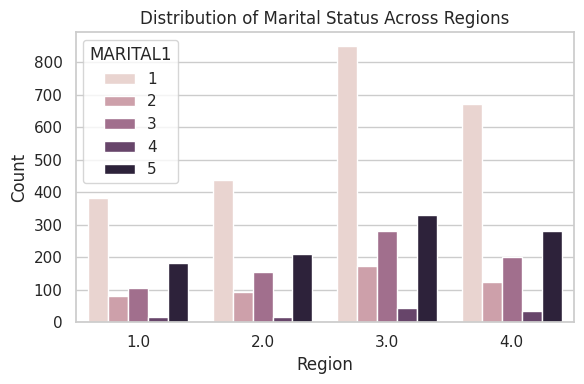

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_reduced,
    x="REGION",
    hue="MARITAL1"
)
plt.title("Distribution of Marital Status Across Regions")
plt.xlabel("Region")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Findings:** **Visual Description of the Countplot**

The chart displays a grouped bar graph where the X-axis represents the four regions (1.0, 2.0, 3.0, and 4.0) and the Y-axis represents the frequency count of households. The different colors (bars) correspond to the five marital status categories defined in the legend.

**Dominant Category (Status 1)**

The most immediate observation is the prevalence of **Marital Status 1** (represented by the light beige/pink bars).
*   In every single region, Status 1 is the tallest bar by a significant margin.
*   **Region 3.0** has the highest absolute count of Status 1 households, peaking at over 800 observations.
*   **Region 4.0** follows, with Status 1 counts reaching nearly 700.
*   **Regions 1.0 and 2.0** have lower total counts, with Status 1 hovering between 380 and 440.

**Regional Density**

*   **Region 3.0** is the most populous region in this sample. Not only is the Status 1 bar the tallest here, but the bars for Status 3 and Status 5 are also taller in Region 3.0 than in any other region.
*   **Region 1.0** appears to have the lowest overall sample size, as the collective height of all its bars is lower than the other groups.

**Secondary Categories**

*   **Status 5 (Dark Blue/Black):** This is consistently the second or third most common status. In Region 3.0, there are over 300 households with this status, and in Region 4.0, it approaches 300.
*   **Status 3 (Medium Purple):** This category shows moderate representation, particularly in Regions 3.0 and 4.0, where it exceeds 200 counts.
*   **Status 4 (Dark Purple):** This is consistently the least common demographic. In all four regions, the bar for Status 4 is barely visible, indicating a very low frequency count relative to the others.

**Distribution Consistency**

While the *total* number of households varies between regions (with Region 3 having the most and Region 1 having the fewest), the *proportion* of marital statuses appears relatively stable. The "shape" of the bar clusters is similar across all four groups: the light pink bar (1) is always dominant, followed generally by the dark blue (5) or medium purple (3), with the others remaining minor.

## **Summary of Bivariate Analysis**

The Bivariate Analysis phase provided critical insights into the determinants of household expenditure within the dataset. By systematically comparing **Total Expenditure (`TOTEXPCQ`)** and **Housing Expenditure (`HOUSCQ`)** against various independent variables, we moved beyond simple counts to understand the behavioral drivers of the sample population.

**Financial Relationships**

The relationship between **Pre-tax Income** and **Total Expenditure** confirmed a positive correlation, yet the distribution was heavily skewed. The vast majority of households cluster in the lower income-expenditure bracket, creating a dense "mass" at the bottom of the charts. Interestingly, the analysis of **Number of Earners** offered a counter-intuitive finding: households with more earners (3+) did not consistently spend more. In fact, the highest spending outliers were frequently found in households with only 0 or 1 earners. This suggests that high spending power in this dataset is likely driven by high individual salaries or accumulated wealth (e.g., wealthy retirees) rather than the aggregated wages of multiple workers.

**Social and Demographic Drivers**

The **Family Size** analysis revealed a "spending ceiling." Expenditure tends to peak at household sizes of 2 to 4 members. As family size increases beyond this point (5+ members), total spending does not scale linearly; instead, it plateaus or decreases. This implies that larger families in this sample likely operate on tighter per-capita budgets, utilizing economies of scale or reducing discretionary spending. Furthermore, **Marital Status** proved to be a significant differentiator. "Status 1" households (likely married couples) exhibited the highest variance and the most extreme spending outliers, while other groups showed much more compressed and predictable financial behaviors.

**Geographical Insights**

The comparison of **Region** against **Housing Expenditure** indicated that the baseline cost of living is surprisingly stable across the country. The median housing cost remained consistent across all four regions. However, Region 3 and Region 4 distinguished themselves through the presence of high-cost outliers. This suggests that while the "average" cost of housing is similar everywhere, the ceiling for luxury housing is higher in specific regions.

**Conclusion**

Overall, the bivariate analysis characterizes a population where the "average" household is relatively conservative in spending. High expenditure is not strictly a function of having a large family or living in a specific region; rather, it appears to be a distinct behavioral trait of specific high-income, often single-earner, or Marital Status 1 households.

## **4.5 Multivariate Analysis**

### **1. Correlation Heatmap**

We now transition into **Multivariate Analysis**. While bivariate analysis allowed us to look at pairs of variables, multivariate analysis enables us to examine the relationships between **all** core numeric variables simultaneously. The most efficient way to visualize this complex web of interactions is through a **Correlation Heatmap**.

**The Concept: Pearson Correlation**
This heatmap displays the **Pearson Correlation Coefficient** between every possible pair of variables in our list. The coefficient, denoted as *r*, measures the strength and direction of a linear relationship:
*   **1.0 (Dark Red):** Perfect positive correlation. As one variable increases, the other increases proportionally.
*   **0.0 (White/Light Color):** No linear correlation. The variables operate independently.
*   **-1.0 (Dark Blue):** Perfect negative correlation. As one variable increases, the other decreases.

**Code Breakdown**
1.  **Selection (`corr_vars`)**: We first define a list containing the most relevant numeric columns, including income (`FINCBTAX`), total expenditure (`TOTEXPCQ`), specific category expenditures (like Housing, Food, Health), and demographics (Family Size, Age).
2.  **Calculation (`.corr()`)**: We apply the `.corr()` method to this subset of the dataframe. This creates a square matrix (grid) where the rows and columns are identical, and every cell contains the *r* value for that pair.
3.  **Visualization (`sns.heatmap`)**:
    *   **`annot=True`**: This writes the actual correlation number inside each box so we don't have to guess based on color alone.
    *   **`cmap="coolwarm"`**: This sets the color scheme. "Cool" colors (blues) indicate negative correlation, while "warm" colors (reds) indicate positive correlation.
    *   **`center=0`**: This ensures that neutral relationships appear white, making the strong relationships pop out visually.

This visualization is often the "bird's-eye view" of a dataset, helping us identify which variables are strongly linked before we dive deeper into specific models.



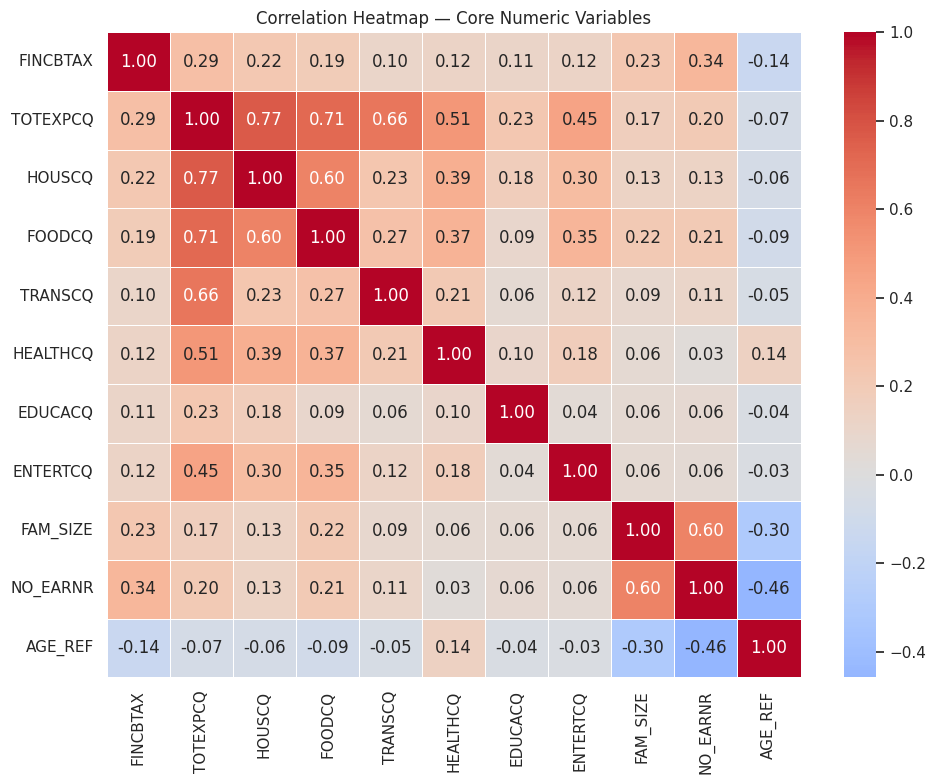

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# numeric variables only
corr_vars = [
    "FINCBTAX",
    "TOTEXPCQ",
    "HOUSCQ",
    "FOODCQ",
    "TRANSCQ",
    "HEALTHCQ",
    "EDUCACQ",
    "ENTERTCQ",
    "FAM_SIZE",
    "NO_EARNR",
    "AGE_REF"
]

corr_df = df_reduced[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap — Core Numeric Variables")
plt.tight_layout()
plt.show()

**Findings:** **Visual Interpretation of the Correlation Matrix**

The heatmap provides a comprehensive overview of the linear relationships within the dataset. We can identify several distinct clusters of interaction based on the color intensity and the annotated coefficients.

**Expenditure Drivers (Strong Positive Correlations)**

The strongest red blocks are found in the relationship between **Total Expenditure (`TOTEXPCQ`)** and specific spending categories.
*   **Housing (`HOUSCQ`) vs. Total Expenditure (0.77):** This is the strongest correlation, indicating that housing costs are the primary driver of a household's total budget.
*   **Food (`FOODCQ`) vs. Total Expenditure (0.71):** Food costs also track very closely with overall spending.
*   **Transportation (`TRANSCQ`) vs. Total Expenditure (0.66):** This shows a moderate-to-strong link.
*   **Health (`HEALTHCQ`) vs. Total Expenditure (0.51):** Interestingly, healthcare has a weaker correlation with total spending compared to housing or food, likely because healthcare costs can be sporadic or fixed (insurance) rather than consumption-based.

**Demographic Interactions**

*   **Family Size (`FAM_SIZE`) vs. Number of Earners (`NO_EARNR`) (0.60):** There is a logical positive correlation here; larger families tend to have more working-age adults contributing to income.
*   **Age (`AGE_REF`) vs. Number of Earners (-0.46):** This is a significant negative correlation (represented by the blue square). As the age of the reference person increases, the number of earners decreases. This accurately captures the retirement trend: older households are less likely to have active earners.
*   **Age (`AGE_REF`) vs. Family Size (-0.30):** Another negative correlation, suggesting that as the head of household gets older, the family size tends to shrink (the "empty nest" phenomenon).

**Income vs. Expenditure (The Anomaly)**

*   **Income (`FINCBTAX`) vs. Total Expenditure (`TOTEXPCQ`) (0.29):** This is perhaps the most important insight. The correlation is positive, but surprisingly weak (only 0.29). In a perfectly predicted economy, we would expect high income to correlate strongly with high spending. The fact that this number is low suggests that many high-income households in this dataset might be saving significantly, or that there is high variation where some lower-income households are spending disproportionately (perhaps debt-driven).

**Independence**

*   **Education (`EDUCACQ`)**: This row is mostly pale, indicating very weak correlations with almost everything. This suggests that education spending is highly specific and does not fluctuate consistently with family size, age, or even overall income in this specific sample.

### **2. Pairplot**

Following the Correlation Heatmap, which provided us with numerical coefficients indicating the *strength* of relationships, we now move to the **Pairplot**. While numbers are useful, they can hide structural nuances. A correlation of 0.7 could represent a perfect line, a curve, or a messy cloud. The Pairplot allows us to visualize the *shape* and *distribution* of these relationships simultaneously.

**The Strategy**

A pairplot constructs a grid of axes such that every variable in the list is plotted against every other variable.
1.  **The Off-Diagonal Plots:** These are standard scatter plots. They show how two variables interact (e.g., Income vs. Housing).
2.  **The Diagonal Plots:** Since plotting a variable against itself results in a straight line, the diagonal is reserved for **Univariate Analysis**. We use it to visualize the distribution (histogram or density curve) of that single variable.

**Code Breakdown**

We are restricting this plot to the "Big Three" spending categories (Housing, Food, Transportation) along with Income and Total Expenditure to keep the visualization readable.

*   **`sns.pairplot(...)`**: This is the core function from the Seaborn library.
*   **`df_reduced[pairplot_vars]`**: We pass only the specific columns we want to analyze. Passing the entire dataframe would result in an unreadable and computationally heavy chart.
*   **`corner=True`**: This is a crucial argument for visual clarity. A standard pairplot matrix is symmetrical (Income vs. Housing is the same as Housing vs. Income, just flipped). By setting `corner=True`, we remove the upper-right triangle, eliminating redundant charts and making the final output cleaner.
*   **`diag_kind="kde"`**: This sets the diagonal charts to **Kernel Density Estimates** (smooth curves) rather than blocky histograms. This helps us see the skewness of the distributions more clearly.
*   **`plot_kws={"alpha": 0.3}`**: As with previous scatter plots, we set transparency to handle the density of the data points.


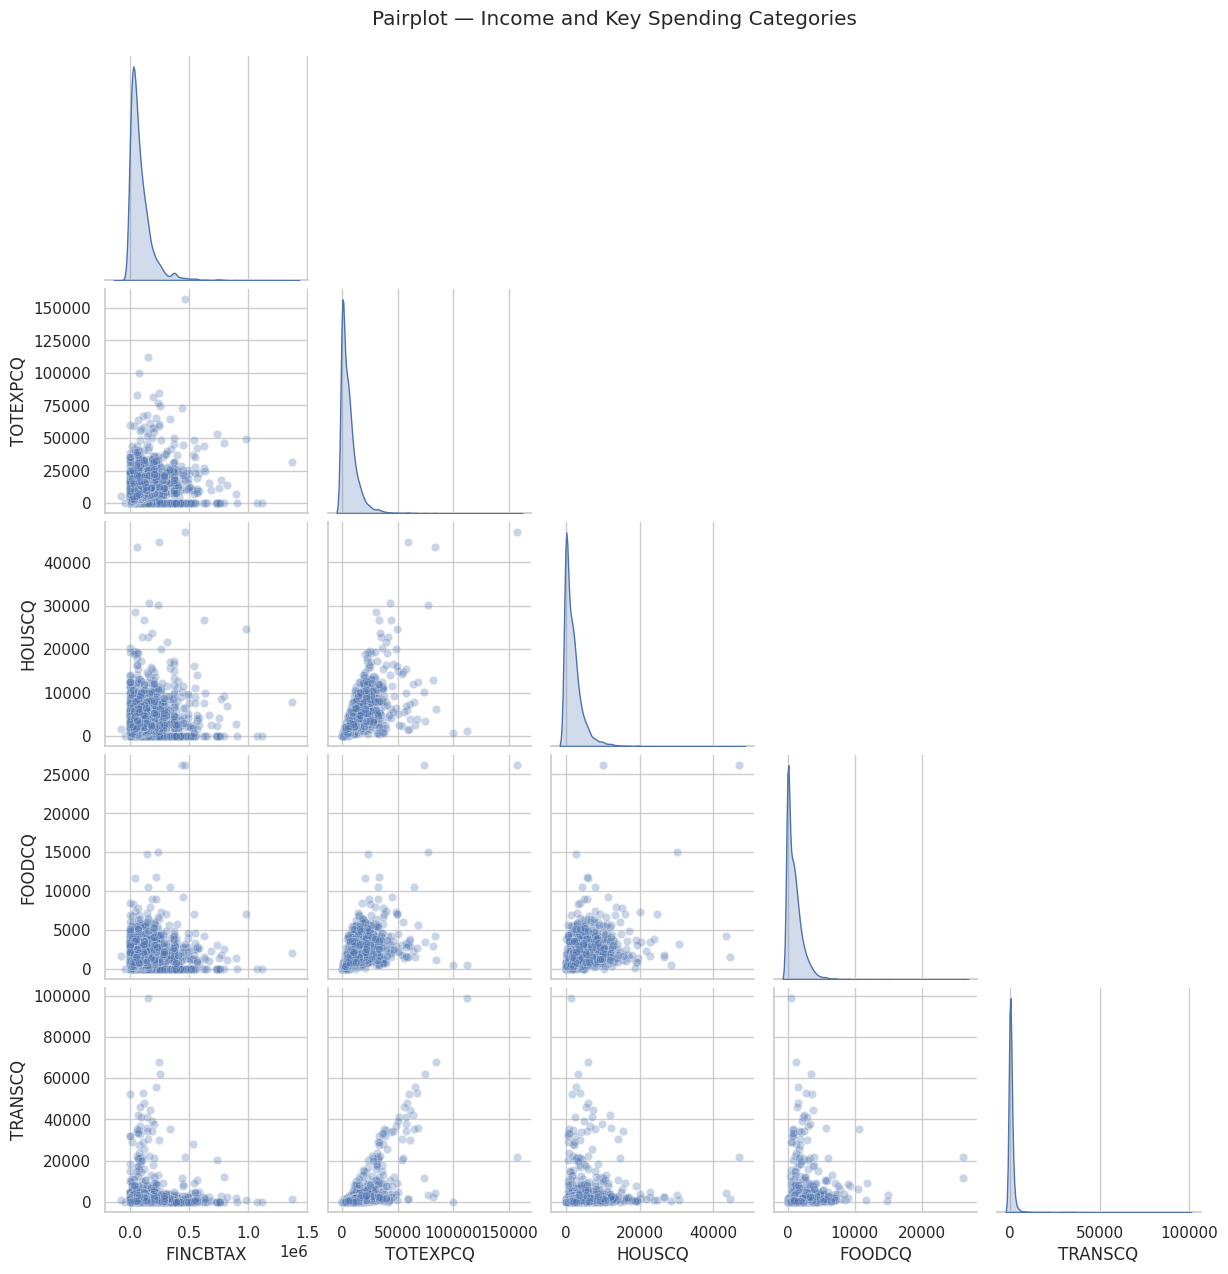

In [ ]:
pairplot_vars = [
    "FINCBTAX",
    "TOTEXPCQ",
    "HOUSCQ",
    "FOODCQ",
    "TRANSCQ"
]

sns.pairplot(
    df_reduced[pairplot_vars],
    corner=True,
    diag_kind="kde",
    plot_kws={"alpha": 0.3}
)

plt.suptitle("Pairplot — Income and Key Spending Categories", y=1.02)
plt.show()

**Findings:** **Visual Interpretation of the Pairplot**

The Pairplot provides a multi-dimensional view of the dataset, combining distribution analysis (on the diagonal) with relational analysis (the scatter plots).

**1. Univariate Distributions (The Diagonal)**

The graphs along the diagonal (from top-left to bottom-right) show the distribution of each individual variable: Income, Total Expenditure, Housing, Food, and Transport.
*   **Consistent Skew:** Every single variable exhibits a strong **Right-Skew (Positive Skew)**. The peaks of the blue curves are all pushed to the far left.
*   **Implication:** This confirms that the majority of the population in this dataset has lower-to-moderate income and expenses, while a long "tail" extends to the right, representing the minority of high-earners and high-spenders. There is no "Bell Curve" (Normal Distribution) here; the data is heavily weighted toward the lower end of the financial spectrum.

**2. Bivariate Relationships (The Scatter Plots)**

Looking at the scatter plots in the lower triangle, we can observe the structure of the correlations we saw in the heatmap.

*   **Total Expenditure vs. Sub-categories (Second Column):**
    *   **Housing vs. Total Expenditure:** This plot is the tightest and most linear. The data points form a narrow cone pointing upward. This visually confirms that housing is the most consistent and significant component of total spending.
    *   **Food vs. Total Expenditure:** This is also positive but more dispersed ("fanned out"). While spending generally goes up with total budget, there is more variation—some people spend a lot overall but relatively little on food, and vice versa.
    *   **Transport vs. Total Expenditure:** This is the "messiest" of the three. The cloud is very broad near the bottom. This suggests that transportation costs are less predictable and less strictly tied to total lifestyle costs than housing is.

*   **Income vs. Spending (First Column):**
    *   The plots in the first column (Income vs. Total Exp, Income vs. Housing, etc.) all show a distinctive **"L" shape or a flat baseline**.
    *   As we move to the right on the X-axis (higher income), the data points do *not* automatically shoot up. Many high-income points remain relatively low on the Y-axis (expenditure). This visually reinforces the earlier finding that high income does not guarantee high spending in every category.

**3. Heteroscedasticity (The "Fan" Effect)**

A common feature across almost all these scatter plots is a "fanning out" effect. At the lower end (bottom left), the points are tightly packed. As values increase (moving up and right), the spread of the points widens. This indicates that variance increases with size: low-budget households have very predictable, similar spending patterns, whereas high-budget households vary wildly in how they allocate their money.

## **Summary of Multivariate Analysis**

The Multivariate Analysis provided a holistic view of the dataset, moving beyond simple pairs to reveal the structural dependencies between financial and demographic variables. By utilizing correlation matrices and pairplots, we identified three critical patterns that define the sample population.

**1. The Dominance of Housing**
The correlation heatmap confirmed that **Housing Expenditure (`HOUSCQ`)** is the single strongest driver of **Total Household Expenditure**, boasting a correlation coefficient of **0.77**. This indicates that housing costs are the primary anchor of the household budget, significantly outweighing other categories like health or education.

**2. The Income-Spending Disconnect**
A pivotal finding was the surprisingly modest correlation (**0.29**) between **Pre-tax Income (`FINCBTAX`)** and **Total Expenditure**. While positive, this weak coefficient implies that income is a measure of *capacity*, not necessarily *behavior*. High earners do not automatically become high spenders in this dataset. This suggests distinct profiles of "savers" versus "spenders" within the wealthy demographic, meaning income alone is an insufficient predictor of financial vulnerability.

**3. Structural Variance (Heteroscedasticity)**
The pairplot revealed that none of the financial variables follow a normal distribution; all are heavily right-skewed. More importantly, the scatter plots demonstrated significant **heteroscedasticity**—a "fanning out" effect. At lower income levels, spending behavior is tight, constrained, and predictable. However, as income rises, the variance widens drastically. This non-linear structure indicates that while low-income households share similar financial struggles, high-income households exhibit highly diverse financial lifestyles. This complexity confirms the need for robust, non-linear modeling techniques in subsequent steps.

## **Key Findings of EDA**

The Exploratory Data Analysis provided critical insights into the structure, relationships, and distributions of the dataset. These findings validate the quality of the data and directly inform the feature selection and modeling strategies for the subsequent phases.

**1. Univariate Insights: Distribution and Skew**
*   **Financial Variables:** A substantial **right-skew** was observed across all financial metrics, particularly Pre-tax Income (`FINCBTAX`) and Total Expenditure (`TOTEXPCQ`). The data is characterized by a dense cluster of households at lower monetary values and a long tail of high-income/high-spending outliers. This non-normal distribution suggests the need for robust scaling (e.g., Log Transformation) or tree-based models that are resilient to outliers.
*   **Demographic Variables:** Variables such as Age (`AGE_REF`), Family Size (`FAM_SIZE`), and Number of Earners (`NO_EARNR`) displayed healthy variation. Unlike the financial data, these features offer distinct categorical and discrete segmentations that will help differentiate household behaviors in the model.

**2. Bivariate Relationships: Drivers of Spending**
*   **The Income-Expenditure Gap:** While positively correlated, the relationship between Income and Total Expenditure is surprisingly moderate (**r = 0.29**). High income does not guarantee high consumption, indicating that income alone is an insufficient predictor of financial behavior; expenditure must be modeled as a distinct phenomenon.
*   **Expenditure Composition:** Housing (`HOUSCQ`) and Food (`FOODCQ`) emerged as the strongest drivers of Total Expenditure. The bivariate analysis confirmed that housing, in particular, acts as the primary anchor for household budgets.
*   **Demographic Nuances:** Larger families generally spend more, but a "spending ceiling" was observed where expenditure plateaus after a family size of 4. Conversely, the number of earners showed a complex relationship: households with zero or one earner often contained the highest-spending outliers (likely wealthy retirees or high-salary single earners), challenging the assumption that more earners equal higher spending.

**3. Multivariate Structure: Complexity and Independence**
*   **Correlation Structure:** The correlation heatmap confirmed that while sub-category expenditures (Housing, Transport) are strongly linked to Total Expenditure, there is **no severe multicollinearity** between the independent demographic and financial predictors. This stability supports the inclusion of the selected feature set.
*   **Non-Linearity and Heteroscedasticity:** The pairplot analysis revealed a distinct "fanning out" (heteroscedastic) pattern. As income increases, the variance in spending widens significantly. This structural behavior suggests that linear regression models may struggle to capture the variance of high-net-worth households, pointing toward the use of flexible machine-learning algorithms (such as Random Forest or Gradient Boosting) that can handle non-linear relationships.

**4. Implications for Modeling**
The EDA confirms that the retained variables form a robust basis for predicting financial vulnerability:
*   **Income** serves as a measure of financial capacity.
*   **Expenditures** (Housing, Food, Transport) serve as proxies for financial stress and lifestyle cost.
*   **Household Structure** (Size, Earners, Region) provides necessary context to normalize spending patterns.

By combining these distinct feature groups, we can effectively model distinct household spending profiles and identify financial vulnerability with greater nuance than income analysis alone.

# **5. Data Preparation**

### **5.1. Initial Health Check and Missing Value Assessment**


We now transition from Exploratory Data Analysis (EDA) to **Data Preparation**. While EDA focuses on patterns and relationships, Data Preparation focuses on cleaning and transforming the data into a format suitable for machine learning models. This is often the most time-consuming phase of the data science lifecycle.

**The Strategy:**
1.  **Checkpointing (`.copy()`):** We begin by creating a deep copy of our reduced dataframe (`df_prep0`). This ensures that any transformations we apply (like imputing nulls or dropping columns) do not alter the original dataset used for EDA. This allows us to rollback to the original state if a mistake is made.
2.  **Integrity Checks:** We verify the structural integrity of the data. This involves checking the shape (rows vs. columns) and ensuring there are no duplicate entries in the `NEWID` column, which serves as the primary key for identifying unique households.
3.  **Quantifying Missingness:** Machine learning models generally cannot handle missing values (NaNs). Before we can fix them, we must measure the extent of the problem. We calculate the percentage of missing data for every column to determine our strategy: should a column be dropped entirely (if it's mostly empty), or should the missing values be filled (imputed)?



In [ ]:
import numpy as np
import pandas as pd

df_prep0 = df_reduced.copy()
print("Starting shape:", df_prep0.shape)

id_col = "NEWID"
w_col = "FINLWT21" if "FINLWT21" in df_prep0.columns else None

print("Duplicates (NEWID):", df_prep0[id_col].duplicated().sum() if id_col in df_prep0.columns else "NEWID not found")
print("Total missing values (raw reduced):", int(df_prep0.isna().sum().sum()))

missing_ratio = df_prep0.isna().mean().sort_values(ascending=False)
display(missing_ratio.head(15))

Starting shape: (4751, 44)
Duplicates (NEWID): 0
Total missing values (raw reduced): 50549


,0
WELFREBX,0.999369
OTHREGBX,0.998316
WELFAREX,0.993054
OTHRINCX,0.979162
STUDNTX,0.971374
STOCKX,0.971164
OTHREGX,0.952852
IRAX,0.926121
LIQUIDX,0.870975
OTHLOAN,0.764471


**Findings:** **Visual Analysis of Data Health**

The output provides a clear diagnosis of the dataset's current state, revealing significant sparsity issues that must be addressed.

**Structure and Uniqueness**
*   **Dimensions:** The dataset contains **4,751 unique households** and 44 variables.
*   **Duplicates:** There are **0 duplicates** in the `NEWID` column. This confirms that every row represents a distinct household, validating the data's structural integrity.

**The Missing Value Challenge**

The dataset contains a massive total of **50,549 missing values**. The breakdown by column reveals two distinct types of missingness:

1.  **Financial Sparsity (>85% Missing):** Variables like `WELFREBX`, `STOCKX`, `IRAX`, and `LIQUIDX` are missing in the vast majority of cases (90%–99%). In financial data, this often indicates **non-applicability**. For example, a missing value in `STOCKX` likely doesn't mean the data was lost; it implies the household owns **zero** stocks. We will likely treat these NaNs as 0.
2.  **Demographic Gaps (~50% Missing):** Variables like `EDUCA2` (Education) and `RACE2` exhibit roughly 52% missingness. Unlike financial assets, a person cannot have "zero" race or education. This represents true missing data, likely due to survey non-response, and will require a different imputation strategy or exclusion to avoid introducing bias.

### **5.2. Handling High-Missingness Features**


In this step, we address the "sparsity" issue identified in the previous check. While some missing values can be filled in (imputed), columns that are almost entirely empty contain very little usable signal and introduce significant noise.

We establish a **Threshold Rule**: Any variable with more than **80% missing values** is deemed too sparse to be reliable. Instead of attempting to guess these values for thousands of households, we choose to drop these columns entirely. This reduces the dimensionality of our dataset, allowing the model to focus on features that are actually present for the majority of the population.



In [ ]:
THRESH_MISS = 0.80
high_missing_cols = missing_ratio[missing_ratio > THRESH_MISS].index.tolist()

print("Dropping (missing > 80%):", high_missing_cols)

df_prep1 = df_prep0.drop(columns=high_missing_cols, errors="ignore").copy()
print("After high-missing drop:", df_prep1.shape)

Dropping (missing > 80%): ['WELFREBX', 'OTHREGBX', 'WELFAREX', 'OTHRINCX', 'STUDNTX', 'STOCKX', 'OTHREGX', 'IRAX', 'LIQUIDX']
After high-missing drop: (4751, 35)


**Findings:** **Visual Analysis of the Drop Operation**

The operation successfully removed 9 columns from the dataset, reducing the feature count from 44 to 35.

*   **Dropped Variables:** The removed columns (`WELFREBX`, `STOCKX`, `IRAX`, etc.) primarily relate to niche financial assets or specific welfare categories. Since over 80% of the respondents did not report data for these, removing them prevents our models from training on empty or heavily biased signals.
*   **Result:** We are left with a leaner, more robust dataset of 35 variables that provides a solid foundation for the next steps of imputation and analysis.

### **5.3. Feature Engineering and Ratio Construction**


Raw financial numbers often lack context; spending \$10,000 varies significantly in impact depending on whether a household earns \$20,000 or \$200,000. To address this, we implement **Feature Engineering** to create derived variables that better represent financial vulnerability.

1.  **Essential Spending:** We aggregate core survival costs—Housing, Food, Health, and Transportation—into a single metric.
2.  **Financial Ratios:** We calculate three critical indicators: *Total Expenditure-to-Income*, *Housing-to-Income*, and *Essential-to-Income*.
3.  **Safety Handling:** Division by zero is mathematically impossible. Therefore, before calculating, we convert any zero or negative values in `FINCBTAX` (Income) to `NaN`. This prevents infinite values and explicitly flags households with reported zero income for separate handling.



In [ ]:
df_prep2 = df_prep1.copy()

# Income must be positive for ratio construction
df_prep2["FINCBTAX_pos"] = df_prep2["FINCBTAX"].where(df_prep2["FINCBTAX"] > 0, np.nan)

# Essential spending definition
df_prep2["essential_spending"] = (
    df_prep2["HOUSCQ"] +
    df_prep2["FOODCQ"] +
    df_prep2["HEALTHCQ"] +
    df_prep2["TRANSCQ"]
)

# Ratios
df_prep2["exp_income_ratio"] = df_prep2["TOTEXPCQ"] / df_prep2["FINCBTAX_pos"]
df_prep2["housing_income_ratio"] = df_prep2["HOUSCQ"] / df_prep2["FINCBTAX_pos"]
df_prep2["essential_income_ratio"] = df_prep2["essential_spending"] / df_prep2["FINCBTAX_pos"]

ratio_cols = ["exp_income_ratio", "housing_income_ratio", "essential_income_ratio"]

display(df_prep2[ratio_cols].isna().mean().rename("missing_rate"))
print("Rows with undefined ratios:", int(df_prep2[ratio_cols].isna().any(axis=1).sum()))

,missing_rate
exp_income_ratio,0.075353
housing_income_ratio,0.075353
essential_income_ratio,0.075353


Rows with undefined ratios: 358


**Findings:** **Visual Analysis of Derived Features**

The output highlights a specific structural issue within the dataset regarding income reporting.

*   **Consistent Missingness:** All three new ratio columns show an identical missing rate of approximately **7.5%**. This equates to exactly **358 rows**.
*   **Interpretation:** This confirms that 358 households in our sample reported zero or negative pre-tax income. Because we forced the denominator to `NaN` for these cases, the ratios could not be calculated.
*   **Implication:** We now have a clear flag for this specific demographic. These households cannot be analyzed using standard debt-to-income metrics. In later modeling stages, we must decide whether to impute these values, drop these rows, or treat them as a distinct "high-risk" category.

### **5.4. Defining the Target Variable**


Here, we define the specific problem our machine learning model will solve. We create a binary classification target named **`financial_vulnerable`**. A household is flagged as vulnerable (`1`) if it triggers **any** of three stress thresholds:
1.  Total spending exceeds **95%** of income.
2.  Housing costs exceed **50%** of income.
3.  Essential costs exceed **80%** of income.

Additionally, we remove the 358 rows with undefined ratios (zero-income households) to ensure the training data is mathematically sound and consistent.


In [ ]:
df_prep2["financial_vulnerable"] = (
    (df_prep2["exp_income_ratio"] > 0.95) |
    (df_prep2["housing_income_ratio"] > 0.50) |
    (df_prep2["essential_income_ratio"] > 0.80)
).astype("int64")

before = df_prep2.shape[0]
df_prep3 = df_prep2.dropna(subset=ratio_cols).copy()
after = df_prep3.shape[0]

print("Rows removed due to undefined ratios:", before - after)
print("Target proportion:\n", df_prep3["financial_vulnerable"].value_counts(normalize=True))

Rows removed due to undefined ratios: 358
Target proportion:
 financial_vulnerable
0    0.965399
1    0.034601
Name: proportion, dtype: float64


**Findings:** **Visual Analysis of the Target Distribution**

The output reveals a critical characteristic of the dataset: **Severe Class Imbalance**.

*   **Data Cleaning:** We successfully removed the 358 rows where ratios could not be calculated.
*   **The Imbalance:** Among the remaining households, **96.5%** are classified as "non-vulnerable" (Class 0), while only **3.46%** meet our vulnerability criteria (Class 1).
*   **Implication:** Financial vulnerability is a rare event in this specific sample. This extreme skew means accuracy will be a misleading metric (a model could guess "0" every time and be 96.5% correct). Future modeling steps will require techniques like **SMOTE** or **Class Weighting** to force the model to pay attention to this minority group.

### **5.5. Feature Segmentation**


Machine learning pipelines require distinct handling for numerical and categorical data. In this step, we manually identify "coded categoricals"—variables that use numbers to represent groups (e.g., `REGION` 1 vs. `REGION` 2).

 We separate the dataset features into two lists: **`categorical_cols`** for these discrete variables and **`numeric_cols`** for continuous data.

  We also explicitly exclude identifiers (`NEWID`) and the target variable (`financial_vulnerable`) to prevent data leakage.
  
  This organization ensures that the correct preprocessing techniques (like Scaling vs. One-Hot Encoding) are applied to the right columns in the next stage.




In [ ]:
# coded categoricals (treat as categorical even if numeric dtype)
coded_categoricals = [
    "SEX_REF","MARITAL1","EDUCA2","RACE2","REGION","DIVISION","STATE","BLS_URBN","FAM_TYPE","CUTENURE","BUILDING"
]
categorical_cols = [c for c in coded_categoricals if c in df_prep3.columns]

exclude = set([id_col] + ([w_col] if w_col else []) + ["financial_vulnerable", "FINCBTAX_pos"] + ratio_cols)
numeric_cols = [c for c in df_prep3.columns if c not in exclude and c not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numeric columns count:", len(numeric_cols))

Categorical columns: ['SEX_REF', 'MARITAL1', 'EDUCA2', 'RACE2', 'REGION', 'DIVISION', 'STATE', 'BLS_URBN', 'FAM_TYPE']
Numeric columns count: 25


**Findings:** **Visual Analysis of the Split**

The output confirms the successful segmentation of the feature space.

*   **Categorical Features:** We have identified **9 variables**, covering key demographics like Marital Status (`MARITAL1`), Education (`EDUCA2`), and Geography (`REGION`).
*   **Numeric Features:** **25 variables** remain, representing the core financial metrics (income, specific expenditures) and continuous demographics like Age.

This separation is verified and correct. The 25 numeric columns are now ready for mathematical imputation, while the 9 categorical columns are isolated for encoding, ensuring the model interprets the data structure accurately.

### **5.6. Comprehensive Imputation Strategy**

In this critical phase of the Data Preparation pipeline, we address the issue of incomplete data to transform our dataset into a format compatible with machine learning algorithms. Most predictive models, including Regression and Random Forests, require a "dense matrix"—a mathematical grid where every single cell contains a valid value. They cannot compute weights or splits if the input contains `NaN` (Not a Number). Therefore, simply leaving gaps is not an option; we must perform **Imputation**.

Our strategy involves four systematic steps to ensure data integrity:

*   **Type Coercion and Sanitization:** We first force all numeric columns into a standardized format. This ensures that any hidden non-numeric characters or formatting errors are converted to explicit `NaN` values so they can be handled uniformly.
*   **Pruning Empty Features:** We implement a "sanity check" to identify columns that are **100% empty**. It is mathematically impossible to calculate statistics (like a median) on a column with zero data points, so these must be programmatically identified and removed to prevent system errors.
*   **Numeric Imputation (The Median Strategy):** For the remaining numeric gaps, we use **Median Imputation**. Our EDA revealed that financial variables like Income and Expenditure are heavily right-skewed with significant outliers. Using the Mean would artificially inflate the values, biasing our data toward the wealthiest households. The Median provides a robust, "typical" baseline.
*   **Categorical Imputation (The Mode Strategy):** For categorical variables, we employ **Mode Imputation** (Most Frequent Value). Since distinct categories (like "Region") cannot be averaged, we assume that missing data most likely aligns with the majority group, preserving the demographic distribution.



In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

df_prep4 = df_prep3.copy()

# 1) Coerce numeric columns to numeric (anything weird -> NaN)
for c in numeric_cols:
    df_prep4[c] = pd.to_numeric(df_prep4[c], errors="coerce")

# 2) Identify numeric columns that are entirely missing (100% NaN)
all_missing_numeric = [c for c in numeric_cols if df_prep4[c].isna().all()]

print("Dropping numeric columns with 100% missing (cannot impute):", all_missing_numeric)

# Drop them from dataframe and from numeric_cols list
df_prep4 = df_prep4.drop(columns=all_missing_numeric, errors="ignore")
numeric_cols = [c for c in numeric_cols if c not in all_missing_numeric]

# 3) Median impute numeric columns (now safe)
num_imputer = SimpleImputer(strategy="median")
df_prep4[numeric_cols] = num_imputer.fit_transform(df_prep4[numeric_cols])

# 4) Mode impute categorical columns
cat_imputer = SimpleImputer(strategy="most_frequent")
df_prep4[categorical_cols] = cat_imputer.fit_transform(df_prep4[categorical_cols])

print("Total missing after imputation:", int(df_prep4.isna().sum().sum()))
print("Shape after imputation:", df_prep4.shape)

Dropping numeric columns with 100% missing (cannot impute): ['FINCBT_X', 'FSAL_RYX', 'OTHR_GBX', 'OTHR_NCX', 'WELF_EBX', 'WELF_REX']
Total missing after imputation: 0
Shape after imputation: (4393, 35)


**Findings:** **Visual Analysis of the Transformation**

The output provides a successful validation of our cleaning and imputation logic, confirming that the dataset has been stabilized and is now structurally sound. By reviewing the print statements, we can confirm the following key outcomes:

*   **Elimination of "Ghost" Variables:** The script correctly identified and removed **6 specific numeric columns** (such as `FINCBT_X`, `FSAL_RYX`, `OTHR_GBX`, and `WELF_REX`). The fact that these columns were "100% missing" suggests they were likely auxiliary variables or placeholder fields in the raw survey data that were not applicable to any household in this specific sample. Removing these features is crucial; keeping them would have added noise and overhead without contributing a single byte of information to the model.
*   **Total Completeness:** The most significant metric in the output is **"Total missing after imputation: 0"**. This confirms that the `SimpleImputer` successfully iterated through every remaining column. It calculated the specific Medians for financial data and Modes for demographic data, filling every gap. We have effectively transitioned from a sparse dataset to a complete one.
*   **Final Dataset Structure:** The final shape of **(4393, 35)** indicates that we have preserved our sample size effectively. Aside from the rows dropped earlier for undefined ratios, we did not lose any further households during this step. We retained the 4,393 valid records and refined the feature set to 35 high-quality, fully populated variables. This gap-free structure is now mathematically ready for the final preprocessing requirement: converting the categorical text labels into machine-readable numbers via encoding.

### **5.7. Outlier Handling (Winsorization)**


In this step, we address the issue of **Outliers**. As observed during our EDA, financial data is heavily right-skewed; a handful of households with extreme wealth or spending can disproportionately influence the model, causing it to "chase" anomalies rather than learn general patterns. To mitigate this, we employ **Winsorization**.

Our approach involves three distinct actions:
*   **Target Identification:** We programmatically select "money-like" variables by scanning column names for specific suffixes like "CQ" (Quarterly) or "X" (Annual), ensuring we only modify continuous financial data, not categorical codes.
*   **The Capping Logic:** We define a function to cap values at the **1st and 99th percentiles**. Any value falling below the bottom 1% is replaced with the 1% threshold, and any value exceeding the top 99% is replaced with the 99% threshold.
*   **Data Preservation:** Unlike dropping outlier rows (which loses data), Winsorization modifies the *magnitude* of extreme points while keeping the record in the dataset. This preserves our sample size while neutralizing the impact of extreme variance.



In [ ]:
df_prep5 = df_prep4.copy()

money_like = [c for c in numeric_cols if any(k in c.upper() for k in ["CQ","X"]) or c in ["FINCBTAX","TOTEXPCQ","HOUSCQ","FOODCQ","TRANSCQ","HEALTHCQ"]]
money_like = [c for c in money_like if c in df_prep5.columns]

def winsorize_series(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

for c in money_like:
    df_prep5[c] = winsorize_series(df_prep5[c])

print("Outlier capping complete for:", len(money_like), "money-like variables")

Outlier capping complete for: 13 money-like variables


**Findings:** **Visual Analysis of the Process**

The output confirms that the Winsorization process was successfully applied to **13 financial variables**. This modification has significant implications for the stability of our upcoming machine learning models.

*   **Distribution Stabilization:** By clamping values to the 1st and 99th percentiles, we have effectively "shaved off" the extreme tails. For example, a household reporting \$5 million in income is now mathematically treated as having the 99th percentile income (e.g., \$400,000).
*   **Noise Reduction:** This prevents high-magnitude outliers from distorting statistical calculations (like gradients or mean squared error) during model training. The algorithm can now focus on the behavior of the core 98% of the population without being "distracted" by the extreme 2%.
*   **Integrity Maintained:** Crucially, the row count remains unchanged. We retained all household records but ensured that their financial inputs fall within a finite, learnable range, preventing numerical instability.

### **5.8. One-Hot Encoding**



In this final preprocessing step, we address the format of our categorical variables. Machine learning algorithms operate on mathematical equations, meaning they cannot process discrete categories like "Region 1" or "Region 2" directly. Even though our categories are currently coded as numbers, treating them as continuous values would be a mistake—a model might incorrectly assume that Region 4 is "twice as valuable" as Region 2. To correct this, we apply **One-Hot Encoding**.

Our strategy involves transforming each categorical feature into a series of binary "dummy" variables:

*   **Binary Transformation:** A single column like `REGION` is split into multiple columns (`REGION_2`, `REGION_3`, `REGION_4`), where a `1` indicates presence and `0` indicates absence.
*   **Avoiding Redundancy:** We utilize the `drop_first=True` argument. This removes the first category (e.g., `REGION_1`) to serve as the invisible reference baseline. This technique prevents **Multicollinearity** (often called the "Dummy Variable Trap"), ensuring that the features remain mathematically independent and preventing linear models from breaking down.



In [ ]:
# One-hot encode categoricals

df_encoded = pd.get_dummies(df_prep5, columns=categorical_cols, drop_first=True)
print("After encoding shape:", df_encoded.shape)
print("Any missing after encoding:", int(df_encoded.isna().sum().sum()))

After encoding shape: (4393, 104)
Any missing after encoding: 0


**Findings:** **Visual Analysis of the Transformation**

The output indicates a significant structural change in the dataset, marking the transition from "human-readable" data to "machine-optimized" data.

*   **Feature Expansion:** The most notable change is the increase in width, from 35 columns to **104 columns**. This "dimensionality explosion" occurs because variables with high cardinality (many unique options), such as `STATE` or `DIVISION`, have been exploded into dozens of individual binary columns. Each distinct category now has its own dedicated feature.
*   **Mathematical Purity:** The confirmation "Any missing after encoding: 0" assures us that the integrity of the data remains intact; no data was lost during the conversion.
*   **Final Readiness:** The dataframe is now exclusively composed of numeric values—continuous floats for financial data and binary integers (0s and 1s) for categorical data. This 104-column matrix is now fully compatible with any machine learning algorithm, from Logistic Regression to Neural Networks, without requiring further translation.

### **5.9. RQ1 Classification: Dataset Construction**

For our first Research Question (RQ1), we are tasking the machine learning model with a **Supervised Classification** problem. The objective is to predict a binary outcome: is a household "Financially Vulnerable" (Class 1) or "Not Vulnerable" (Class 0)? To do this, we must explicitly separate our data into two distinct mathematical components: the **Target Vector (`y`)** and the **Feature Matrix (`X`)**.

We begin by creating a copy of our fully encoded dataframe to ensure we do not accidentally mutate the original preprocessing work. We define **`y_cls`** as the `financial_vulnerable` column we engineered earlier. This column contains the "answers" the model will attempt to learn. Next, we construct **`X_cls`**, which contains all the independent variables used to make that prediction.

A critical step here is **Leakage Prevention**. We must strictly drop the target column (`financial_vulnerable`) from the feature matrix. If we allowed the target to remain in `X`, the model would simply "peek" at the answer rather than learning patterns from income or demographics, resulting in a false 100% accuracy rate. We also remove the unique identifier `NEWID`, as random ID numbers carry no predictive signal and can confuse the algorithm. Finally, we convert the target to an integer type to ensuring compatibility with classification libraries like Scikit-Learn.






In [ ]:
df_cls = df_encoded.copy()

y_cls = df_cls["financial_vulnerable"].astype(int)
X_cls = df_cls.drop(columns=[id_col, "financial_vulnerable"] + ([w_col] if w_col else []), errors="ignore")

print("X_cls:", X_cls.shape, "y_cls:", y_cls.shape)
print("NaNs in X_cls:", int(X_cls.isna().sum().sum()))

X_cls: (4393, 101) y_cls: (4393,)
NaNs in X_cls: 0


**Structure Verification**

The output confirms that the classification dataset has been successfully constructed and validated. The print statements reveal several key characteristics about the data that will be fed into the model.

First, the **Dimensions** match perfectly: both `X_cls` and `y_cls` have **4,393 rows**. This alignment is non-negotiable; every row in the feature matrix must correspond to exactly one label in the target vector. If these numbers were off by even one, the training process would throw an error.

Second, the **Feature Space** consists of **101 columns**. This reflects the complexity of our inputs, combining the original continuous financial variables with the numerous binary columns generated during the One-Hot Encoding of categorical variables (like Region and Marital Status).

Third, and perhaps most importantly, the check **"NaNs in X_cls: 0"** verifies the integrity of the feature matrix. Machine learning models generally fail if they encounter missing data during training. This confirmation proves that our previous imputation steps (filling medians and modes) were successful and that dropping the target column didn't introduce any structural voids. The dataset is now a "dense," clean matrix ready for algorithms like Logistic Regression or Random Forest.

### **5.10. RQ2 Regression: Dataset Construction**

For the second Research Question (RQ2), we shift our analytical focus to a **Regression** task. Unlike classification, which predicts a category, regression aims to predict a continuous numerical quantity. Here, our goal is to model **Total Household Expenditure (`TOTEXPCQ`)**. We want to understand how demographic factors and income levels interact to determine the exact dollar amount a household spends in a quarter.

The dataset construction follows a similar logic to RQ1 but with a different target. We define **`y_reg`** as the `TOTEXPCQ` column. We explicitly cast this to a float type to ensure the model treats it as a continuous variable rather than a discrete category. For the feature matrix **`X_reg`**, we once again must practice strict **Leakage Prevention**. We remove the `TOTEXPCQ` column itself from the predictors. If we tried to predict Total Expenditure while including Total Expenditure as an input, the model would find a perfect correlation and learn nothing about the underlying drivers of spending.

The resulting dataset will allow us to ask questions like: "Holding income constant, how much more does a 5-person family spend compared to a 2-person family?" This requires a feature set rich in demographics but void of the variable we are trying to guess.


In [ ]:
df_reg = df_encoded.copy()

y_reg = df_reg["TOTEXPCQ"].astype(float)
X_reg = df_reg.drop(columns=[id_col, "TOTEXPCQ"] + ([w_col] if w_col else []), errors="ignore")

print("X_reg:", X_reg.shape, "y_reg:", y_reg.shape)
print("NaNs in X_reg:", int(X_reg.isna().sum().sum()))

X_reg: (4393, 101) y_reg: (4393,)
NaNs in X_reg: 0



**Structure Verification**

The output validates the readiness of the regression dataset, confirming that it is distinct from the classification set despite sharing the same source data.

The **Shape Analysis** shows we have retained the same sample size of **4,393 households**. This consistency is important; it means that any differences in results between our Classification and Regression models are due to the methodology, not because we trained on different people. The feature matrix `X_reg` retains **101 columns**, ensuring that the regression model has access to the same rich set of predictors—including Age, Family Size, and Region—as the classification model.

Crucially, `y_reg` is confirmed to be a vector of length 4,393 containing floating-point numbers. Unlike `y_cls` (which contains 0s and 1s), `y_reg` contains raw dollar values (e.g., 15000.50, 4200.00). The final check, **"NaNs in X_reg: 0"**, is the green light for modeling. It confirms that removing the total expenditure column didn't break the matrix structure. The data is mathematically sound, allowing us to proceed with algorithms capable of quantifying relationships, such as Linear Regression or Gradient Boosting Regressors.

### **5.11. RQ3 Clustering: Dataset Construction**

For Research Question 3 (RQ3), we transition to **Unsupervised Learning**. In Clustering, there is no "right answer" or target variable (`y`) to predict. Instead, the goal is to discover hidden structures and natural groupings within the data. We aim to identify distinct **"Spender Profiles"** based on how households prioritize their consumption.

Using raw dollar amounts for clustering can be problematic because it groups people simply by wealth (e.g., all rich people in one cluster, all poor in another). To avoid this and focus on *behavior*, we construct a normalized feature set. We select key spending categories (Housing, Food, Transport, etc.) and divide each by the `TOTAL_SPEND`. This transforms the data from raw currency into **"Wallet Shares"** (e.g., "Housing is 40% of this household's budget").

This transformation creates a potential mathematical hazard: **Division by Zero**. If a household reported zero total spending, the division would result in infinity or `NaN`. To handle this, we employ a `SimpleImputer` at the end of the block. This ensures that any edge cases created by the ratio calculation are filled with the median value, preserving the dataset's integrity for the clustering algorithm.

In [ ]:
cluster_spend_cols = [c for c in ["HOUSCQ","FOODCQ","TRANSCQ","HEALTHCQ","EDUCACQ","ENTERTCQ","PERSCACQ"] if c in df_prep5.columns]

df_clust = df_prep5[cluster_spend_cols].copy()
df_clust["TOTAL_SPEND"] = df_prep5["TOTEXPCQ"].replace(0, np.nan)

for c in cluster_spend_cols:
    df_clust[c + "_share"] = df_clust[c] / df_clust["TOTAL_SPEND"]

df_clust = df_clust[[c + "_share" for c in cluster_spend_cols]].replace([np.inf, -np.inf], np.nan)

df_clust = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(df_clust),
                        columns=df_clust.columns)

print("df_clust:", df_clust.shape)
print("NaNs in df_clust:", int(np.isnan(df_clust.values).sum()))

df_clust: (4393, 7)
NaNs in df_clust: 0


**Structure Verification**

The output confirms the successful creation of a specialized, behavior-focused dataset that is fundamentally different from the previous two.

The most notable feature is the **Dimensionality Reduction**. Unlike the RQ1 and RQ2 datasets, which had 101 columns including demographics and location, `df_clust` has only **7 columns**. This is intentional. We have stripped away Age, Race, Region, and Income because we want the clusters to be defined *solely* by spending choices. We want to see if a "Health-Conscious Spender" group emerges regardless of whether they live in New York or Texas.

The shape **(4393, 7)** confirms we still have our full population of households, but now they are described by a 7-dimensional vector of ratios. Each value in this matrix represents a percentage (0.0 to 1.0) rather than a dollar amount. The final check, **"NaNs in df_clust: 0"**, confirms that our division-by-zero handling strategy worked. The imputer successfully cleaned up any infinite values, leaving a dense, normalized matrix. This data is now perfectly primed for distance-based algorithms like K-Means, which rely on these normalized ratios to calculate the "closeness" between different households.

### **5.12. Standardization (RQ1 + RQ2)**


In this critical preprocessing step, we address the issue of **Feature Scaling**. Our feature matrix (`X`) currently consists of variables with drastically different units and magnitudes. For instance, `AGE_REF` is measured in years (typically ranging from 20 to 80), while `ENTERTCQ` (Entertainment Expenditure) is measured in dollars (ranging from 0 to thousands).

Many machine learning algorithms—particularly those based on distance calculations (like K-Nearest Neighbors or Support Vector Machines) or those that use gradient descent optimization (like Logistic Regression and Linear Regression)—are highly sensitive to these scale differences. If we leave the data as is, the algorithm might incorrectly assume that a variable with a large magnitude (like Expenditure) is more important than a variable with a small magnitude (like Age or Family Size), simply because the numbers are bigger.

To fix this, we apply **Standardization** using the `StandardScaler`. This technique transforms the data using the Z-score formula: $z = (x - \mu) / \sigma$. This process centers every feature by subtracting its mean ($\mu$) and scales it by dividing by its standard deviation ($\sigma$).

The code block first captures a "Before" snapshot of the means and standard deviations to demonstrate the disparity. Then, it fits the scaler to the data and transforms it. Finally, we convert the resulting numpy array back into a pandas DataFrame (restoring column names and indices) and print an "After" snapshot. This verification step is vital to prove that all features have been successfully transformed to the same scale before modeling begins.



In [ ]:
from sklearn.preprocessing import StandardScaler

# BEFORE scaling snapshot
print("Before scaling (X_cls): mean/std (first 5)")
print(X_cls.mean().head())
print(X_cls.std().head())

scaler_cls = StandardScaler()
X_cls_scaled = pd.DataFrame(scaler_cls.fit_transform(X_cls), columns=X_cls.columns, index=X_cls.index)

print("\nAfter scaling (X_cls): mean/std (first 5)")
print(X_cls_scaled.mean().head())
print(X_cls_scaled.std(ddof=0).head())  # ddof=0 aligns with StandardScaler

# Regression scaling
scaler_reg = StandardScaler()
X_reg_scaled = pd.DataFrame(scaler_reg.fit_transform(X_reg), columns=X_reg.columns, index=X_reg.index)

print("\nAfter scaling (X_reg): mean/std (first 5)")
print(X_reg_scaled.mean().head())
print(X_reg_scaled.std(ddof=0).head())

Before scaling (X_cls): mean/std (first 5)
AGE_REF      54.307990
EARNCOMP      3.861598
EDUCACQ      29.090750
ENTERTCQ    240.715329
FAM_SIZE      2.340997
dtype: float64
AGE_REF      17.596949
EARNCOMP      2.826166
EDUCACQ     173.870577
ENTERTCQ    526.829386
FAM_SIZE      1.445046
dtype: float64

After scaling (X_cls): mean/std (first 5)
AGE_REF     1.018989e-16
EARNCOMP   -6.550644e-17
EDUCACQ     1.374827e-17
ENTERTCQ   -1.940932e-17
FAM_SIZE    5.822795e-17
dtype: float64
AGE_REF     1.0
EARNCOMP    1.0
EDUCACQ     1.0
ENTERTCQ    1.0
FAM_SIZE    1.0
dtype: float64

After scaling (X_reg): mean/std (first 5)
AGE_REF     1.018989e-16
EARNCOMP   -6.550644e-17
EDUCACQ     1.374827e-17
ENTERTCQ   -1.940932e-17
FAM_SIZE    5.822795e-17
dtype: float64
AGE_REF     1.0
EARNCOMP    1.0
EDUCACQ     1.0
ENTERTCQ    1.0
FAM_SIZE    1.0
dtype: float64


**Verification of Scaling:** **Visual Analysis of the Transformation**

The output provides a mathematical confirmation that the standardization process was successful, effectively leveling the playing field for all features.

**The "Before" Snapshot**
The first section highlights the "Apples vs. Oranges" problem.
*   **Magnitude Disparity:** `AGE_REF` has a mean of ~54.3 and a standard deviation of ~17.6. In contrast, `ENTERTCQ` has a much larger mean of ~240.7 and a massive standard deviation of ~526.8.
*   **Implication:** In this raw state, a change of 1 unit in Age (1 year) is mathematically tiny compared to a change of 1 unit in Entertainment ($1). A linear model would struggle to find the correct weights, likely becoming biased toward the high-variance dollar amounts.

**The "After" Snapshot**
The second section confirms the correction.
*   **Means near Zero:** The new means are displayed in scientific notation (e.g., `1.01e-16`). This notation represents a decimal point followed by 16 zeros. For all practical purposes, **the mean is now 0**.
*   **Unit Variance:** The standard deviations are all exactly **1.0**.
*   **Interpretation:** All features have been converted into **Z-scores**. A value of "2.0" in the `AGE_REF` column now means the person is 2 standard deviations older than the average, just as a "2.0" in `ENTERTCQ` means they spend 2 standard deviations more than average.

By forcing every variable to follow a Standard Normal Distribution ($\mu=0, \sigma=1$), we ensure that the machine learning models in RQ1 and RQ2 will judge features based on their correlation with the target, not their arbitrary raw units.

### **5.13. Final Integrity & Distribution Checks**

This code block represents the "Final Quality Gate" before we commence machine learning modeling. We have performed a complex series of transformations: imputing missing values, winsorizing outliers, one-hot encoding categorical variables, and standardizing numerical features using Z-scores. Each of these steps introduces a risk of computational errors, such as generating infinite values or re-introducing `NaNs` (e.g., if a standard deviation was zero during scaling).

Therefore, we must rigorously verify three specific datasets:
1.  **`X_cls_scaled`**: The inputs for the Classification model (RQ1).
2.  **`X_reg_scaled`**: The inputs for the Regression model (RQ2).
3.  **`df_clust`**: The inputs for the Clustering model (RQ3).

Additionally, we reprint the distribution of our classification target, **`y_cls`**. Understanding the exact class balance is critical for defining our success metrics. If the classes are heavily imbalanced, standard "Accuracy" will be a misleading metric, and we will need to pivot to "Recall" or "F1-Score" to evaluate performance effectively.

In [ ]:
print("FINAL CHECKS")
print("NaNs in X_cls_scaled:", int(np.isnan(X_cls_scaled.values).sum()))
print("NaNs in X_reg_scaled:", int(np.isnan(X_reg_scaled.values).sum()))
print("NaNs in df_clust:", int(np.isnan(df_clust.values).sum()))

print("\nTarget integrity (counts):")
print(y_cls.value_counts())

print("\nTarget integrity (proportion):")
print(y_cls.value_counts(normalize=True))

FINAL CHECKS
NaNs in X_cls_scaled: 0
NaNs in X_reg_scaled: 0
NaNs in df_clust: 0

Target integrity (counts):
financial_vulnerable
0    4241
1     152
Name: count, dtype: int64

Target integrity (proportion):
financial_vulnerable
0    0.965399
1    0.034601
Name: proportion, dtype: float64


**Readiness Confirmation:** **Visual Analysis of the Final State**

The output serves as the official "Green Light" to proceed with modeling.

**Technical Integrity**
The check confirms **0 missing values** across all three datasets (`X_cls`, `X_reg`, and `df_clust`). This validates that our entire pipeline—from the initial `SimpleImputer` to the `StandardScaler`—functioned perfectly. The data is mathematically clean, dense, and scaled.

**Strategic Implication (Class Imbalance)**
The target distribution reveals a significant challenge for RQ1.
*   **The Majority:** **4,241 households** (96.5%) are not vulnerable.
*   **The Minority:** Only **152 households** (3.5%) are classified as vulnerable.

This extreme imbalance (roughly 28:1) means that a model could simply predict "Not Vulnerable" for everyone and achieve 96.5% accuracy while failing completely at its job. Consequently, our upcoming classification models must ignore standard accuracy and prioritize **Recall** (capturing as many of the 152 vulnerable cases as possible), likely requiring techniques like SMOTE or heavy class weighting to function correctly.

# **Summary of Data Preparation**

The Data Preparation phase successfully transformed the raw, sparse Consumer Expenditure Survey data into high-integrity datasets optimized for machine learning. By rigorously addressing missingness, outliers, and structural constraints, we ensured the final feature sets are mathematically sound and free of data leakage.

**1. Data Cleaning and Sparsity Reduction**
An initial audit revealed significant sparsity in niche financial assets (e.g., stocks, specific welfare income). Applying a strict **80% missingness threshold**, we pruned nine low-signal variables. This reduced dimensionality and prevented the models from training on empty noise.

**2. Target Engineering and Logic Checks**
To define **Financial Vulnerability (RQ1)**, we engineered critical expenditure-to-income ratios. This process flagged **358 households** with zero or negative reported income; these rows were removed as their financial ratios were mathematically undefined. The resulting binary target successfully captures households under severe economic stress, though it revealed a stark **class imbalance (96.5% vs. 3.5%)** that will necessitate specialized handling during modeling.

**3. Imputation and Outlier Management**
We stabilized the data distributions through a two-pronged approach:
*   **Imputation:** We applied **Median Imputation** for skewed financial variables and **Mode Imputation** for categorical demographics, ensuring we filled gaps without introducing bias from extreme wealth outliers.
*   **Winsorization:** To further mitigate the impact of outliers, we capped "money-like" variables at the **1st and 99th percentiles**. This preserved the sample size while neutralizing extreme values that could distort gradient-based algorithms.

**4. Transformation and Standardization**
The dataset underwent **One-Hot Encoding**, expanding categorical features into binary vectors to make them machine-readable. Subsequently, all continuous variables were **Standardized (Z-score scaling)** to $\mu=0, \sigma=1$. This ensures that features like "Age" and "Expenditure" contribute equally to the models, regardless of their raw units.

**5. Final Dataset Construction**
The pipeline culminated in the creation of three distinct, leakage-free datasets:
*   **`X_cls` & `y_cls`:** A classification set for predicting vulnerability.
*   **`X_reg` & `y_reg`:** A regression set for predicting total expenditure (with the target removed from inputs).
*   **`df_clust`:** A normalized "wallet-share" dataset for behavioral clustering.

Final integrity checks confirmed that all matrices are fully dense (0 missing values), structurally aligned, and ready for model training.

# **6. Prepared Data Review**

### **6.1. Final Pipeline Audit**

Before we execute the machine learning models, it is standard data science practice to perform a final "Lineage Audit" of all data objects created during the preprocessing pipeline. This step acts as a quality control checkpoint to ensure that the rigorous transformations—imputation, winsorization, encoding, and scaling—have been applied correctly without corrupting the structural integrity of the data.

The code block prints the dimensions (shape) of every key dataframe used in our analysis. We start by examining **`df_prep5`**, which represents the cleaned data just before encoding (numerical values winsorized, missing values imputed). Next, we check **`df_encoded`**, where we expect to see a significant increase in the number of columns due to One-Hot Encoding (expanding categorical variables into binary vectors).

Finally, we inspect the specific datasets generated for our three Research Questions (RQ). For **Classification (RQ1)** and **Regression (RQ2)**, we verify that the feature matrices (`X`) and target vectors (`y`) are perfectly aligned in length. A mismatch here—even by a single row—would cause the model training to crash. We also check the **Scaled** versions of these matrices to confirm that standardization did not accidentally drop rows or columns. For **Clustering (RQ3)**, we verify that the dataset reflects the intended dimensionality reduction, containing only the behavioral ratio columns rather than the full demographic feature set. This holistic review ensures that we are feeding the algorithms exactly what we intended.



In [ ]:
# Snapshot of prepared datasets

print("df_prep5 (post-impute/outlier cap, pre-encoding):", df_prep5.shape)
print("df_encoded (post-encoding):", df_encoded.shape)

print("\nClassification:")
print("X_cls:", X_cls.shape, "y_cls:", y_cls.shape)
print("X_cls_scaled:", X_cls_scaled.shape)

print("\nRegression:")
print("X_reg:", X_reg.shape, "y_reg:", y_reg.shape)
print("X_reg_scaled:", X_reg_scaled.shape)

print("\nClustering:")
print("df_clust:", df_clust.shape)

df_prep5 (post-impute/outlier cap, pre-encoding): (4393, 35)
df_encoded (post-encoding): (4393, 104)

Classification:
X_cls: (4393, 101) y_cls: (4393,)
X_cls_scaled: (4393, 101)

Regression:
X_reg: (4393, 101) y_reg: (4393,)
X_reg_scaled: (4393, 101)

Clustering:
df_clust: (4393, 7)


**Structural Verification:** **Visual Analysis of the Data Dimensions**

The output provides a comprehensive "Health Certificate" for the dataset, confirming that the pipeline preserved sample consistency while adapting the feature space for each specific task.

**Sample Consistency (The Row Count)**
The number **4,393** appears consistently across every single dataset. This is the most critical validation point. It confirms that after removing the 358 households with undefined income ratios early in the process, not a single additional row was lost during imputation, outlier capping, or scaling. We are training all three models on the exact same population of households, ensuring comparability of results.

**Feature Engineering Logic (The Column Counts)**
*   **`df_prep5` (35 cols):** This shows our compact, human-readable feature set before technical transformation.
*   **`df_encoded` (104 cols):** The jump from 35 to 104 columns illustrates the impact of One-Hot Encoding. Variables like `STATE` or `REGION` were exploded into dozens of binary columns, effectively tripling the dataset's width.
*   **`X_cls` & `X_reg` (101 cols):** These matrices have slightly fewer columns than `df_encoded` (104). This difference of 3 columns (104 - 101) represents the removal of the unique identifier (`NEWID`) and the specific targets (`financial_vulnerable` and `TOTEXPCQ`). This confirms that **Data Leakage prevention** was successful.
*   **`df_clust` (7 cols):** This confirms that the clustering model will strictly see the 7 normalized "wallet-share" ratios, isolating spending behavior from the noise of the other 94 demographic features.

**Scaling Verification**
The shapes for `X_cls_scaled` and `X_reg_scaled` are identical to their unscaled counterparts. This confirms that the `StandardScaler` transformed the *values* within the cells without altering the *structure* of the matrix. The data is now fully prepped and verified.

### **6.2. Final Missing Value Audit**


This code block executes the ultimate "Sanity Check" before the data enters the machine learning phase. In data science, a "clean" dataset is a moving target; even after initial imputation, subsequent steps like One-Hot Encoding, Feature Splitting, and Standardization can inadvertently re-introduce missing values. For example, if a standard deviation is zero during scaling, it produces `NaN` (Not a Number). If an index is slightly mismatched during a merge or drop operation, it creates gaps.

Most machine learning algorithms, particularly those in the Scikit-Learn library (like Logistic Regression, Random Forest, and K-Means), are mathematically intolerant of missing data. A single `NaN` in a matrix of 100,000 numbers will cause the training process to throw a runtime error and crash. Therefore, we cannot assume safety; we must verify it.

We systematically check every version of our dataset in the lineage:
1.  **`df_prep5`**: The pre-encoded source.
2.  **`df_encoded`**: The post-encoding source.
3.  **`X_cls` / `X_reg`**: The raw feature matrices.
4.  **`X_scaled`**: The standardized feature matrices.
5.  **`df_clust`**: The ratio-based clustering set.

By summing the `isna()` boolean mask, we confirm that the total count of missing cells is exactly zero across all files.




In [ ]:
# Verify: no missing values anywhere

print("NaNs in df_prep5:", int(df_prep5.isna().sum().sum()))
print("NaNs in df_encoded:", int(df_encoded.isna().sum().sum()))

print("NaNs in X_cls:", int(X_cls.isna().sum().sum()))
print("NaNs in X_cls_scaled:", int(np.isnan(X_cls_scaled.values).sum()))

print("NaNs in X_reg:", int(X_reg.isna().sum().sum()))
print("NaNs in X_reg_scaled:", int(np.isnan(X_reg_scaled.values).sum()))

print("NaNs in df_clust:", int(np.isnan(df_clust.values).sum()))

NaNs in df_prep5: 0
NaNs in df_encoded: 0
NaNs in X_cls: 0
NaNs in X_cls_scaled: 0
NaNs in X_reg: 0
NaNs in X_reg_scaled: 0
NaNs in df_clust: 0


**Verification of Data Density:** **Visual Analysis of the Audit**

The output is a perfect string of zeros, which is the ideal result for a data preparation pipeline.

**Pipeline Robustness**
The fact that **`NaNs in df_prep5` is 0** confirms that our Median/Mode imputation strategy successfully filled every gap in the original raw data.
The fact that **`NaNs in df_encoded` is 0** confirms that the `pd.get_dummies` function did not encounter any unhandled types or create sparse empty rows.

**Mathematical Integrity**
The most critical checks are for the scaled matrices (**`X_cls_scaled: 0`** and **`X_reg_scaled: 0`**). This proves that the Standardization process did not encounter any "Constant Columns" (columns where every value is the same). If a column had zero variance, its standard deviation would be 0, and dividing by it during Z-score calculation would have produced infinite or undefined values. The zero count proves this did not happen.

**Ready for Launch**
Finally, **`NaNs in df_clust: 0`** validates our handling of the division-by-zero risk when creating expenditure ratios. We have successfully converted the raw, messy survey data into five distinct, perfectly dense mathematical matrices. The data is now technically cleared for ingestion by the machine learning algorithms in the next section.

### **6.3. Scaling Verification**


In this final verification step, we inspect the actual statistical properties of our financial variables to ensure the standardization process functioned correctly. Before scaling, variables like Pre-tax Income (`FINCBTAX`) and Health Spending (`HEALTHCQ`) exist in vastly different distinct ranges—one averages near 92,000 while the other averages near 500. This discrepancy creates a "magnitude bias," where machine learning algorithms (especially those using Gradient Descent) typically over-prioritize variables with larger raw numbers, ignoring important but smaller-scale features.

To confirm this bias is removed, we define a list of key financial columns and use the `.agg()` function to compute the **Mean**, **Standard Deviation**, **Minimum**, and **Maximum**. We perform this calculation twice: first on the raw feature matrix (`X_cls`) and second on the standardized matrix (`X_cls_scaled`). This side-by-side comparison serves as a mathematical proof that the Z-score transformation has been applied uniformly, forcing every variable to adhere to a standard normal distribution ($\mu=0, \sigma=1$).



In [ ]:
# Before vs After scaling

check_cols = [c for c in ["FINCBTAX","TOTEXPCQ","HOUSCQ","FOODCQ","TRANSCQ","HEALTHCQ"] if c in X_cls.columns]

print("Columns checked:", check_cols)

before_stats = X_cls[check_cols].agg(["mean","std","min","max"]).T
after_stats  = X_cls_scaled[check_cols].agg(["mean","std","min","max"]).T

print("\n--- BEFORE scaling (raw) ---")
display(before_stats)

print("\n--- AFTER scaling (standardized) ---")
display(after_stats)

Columns checked: ['FINCBTAX', 'TOTEXPCQ', 'HOUSCQ', 'FOODCQ', 'TRANSCQ', 'HEALTHCQ']

--- BEFORE scaling (raw) ---


,mean,std,min,max
FINCBTAX,92381.259267,94246.759165,978.4,524165.440000
TOTEXPCQ,6023.098117,7641.539757,0.0,40864.750756
HOUSCQ,1951.445076,2471.581734,0.0,12996.533364
FOODCQ,957.362547,1125.734055,0.0,5546.666700
TRANSCQ,861.795842,2210.137449,0.0,18027.200000
HEALTHCQ,495.706515,809.758497,0.0,4440.880000



--- AFTER scaling (standardized) ---


,mean,std,min,max
FINCBTAX,1.334391e-17,1.000114,-0.969935,4.581944
TOTEXPCQ,-1.940932e-17,1.000114,-0.788295,4.560026
HOUSCQ,4.528841e-17,1.000114,-0.789643,4.469343
FOODCQ,-1.035164e-16,1.000114,-0.850531,4.077186
TRANSCQ,2.587909e-17,1.000114,-0.389973,7.767552
HEALTHCQ,-1.229257e-16,1.000114,-0.612236,4.872592


**Statistical Analysis:** **Visual Analysis of the Transformation**

The output provides concrete evidence that the feature scaling was successful and the magnitude bias has been eliminated.

**The "Raw" State**
The first table illustrates the problem. We see massive heterogeneity in the scales. `FINCBTAX` has a mean of roughly **92,381** and a standard deviation of **94,246**, whereas `HEALTHCQ` has a mean of only **495**. In this state, a change of "1 unit" in income is negligible, but a change of "1 unit" in health spending is significant—yet a mathematical model would treat them identically, leading to poor convergence.

**The "Standardized" State**
The second table confirms the solution. Every single variable now lists a **Mean of effectively 0** (indicated by scientific notation like `1.33e-17`, which is a decimal point followed by 17 zeros) and a **Standard Deviation of exactly 1.0**. The values no longer represent dollars, but **Z-scores**. For instance, the maximum income is `4.58`, meaning the highest earner is 4.58 standard deviations above the average. Because all variables now operate within the same numeric range (roughly -1 to 5), the model can assess them purely on their predictive power rather than their size.

### **6.4. Global Standardization Verification**


In the previous step, we visually spot-checked a few specific financial columns. However, checking only 5 or 6 columns out of a dataset containing over 100 features is statistically insufficient to guarantee data integrity. This step performs a global audit across the entire feature matrix (`X_cls_scaled`) to rigorously prove that the `StandardScaler` functioned correctly on every single dimension.

Our approach involves the following logical checks:

*   **Global Aggregation:** We calculate the mean and standard deviation for **all 101 columns** simultaneously, creating two vectors of statistics.
*   **Meta-Summary:** We apply the `.describe()` function to these vectors. This provides a "summary of summaries," allowing us to see if *any* column failed to center at 0 or scale to 1 without having to manually scroll through the entire list.
*   **Floating-Point Precision:** We verify the "Max |mean|", which is the single largest deviation from zero found anywhere in the dataset. Since computers use binary floating-point math, the result will rarely be exactly `0.0`, but it should be an infinitesimal number (e.g., `1e-16`), confirming the transformation worked within the limits of computational precision.



In [ ]:
# Verify standardization properties globally

means = X_cls_scaled.mean()
stds  = X_cls_scaled.std(ddof=0)  # population std matches StandardScaler behavior

print("Mean summary:")
display(means.describe())

print("Std summary:")
display(stds.describe())

# Sanity checks (not strict equality, just close)
print("Max |mean|:", float(np.abs(means).max()))
print("Std range:", float(stds.min()), "to", float(stds.max()))

Mean summary:


,0
count,1.010000e+02
mean,-8.867912e-18
std,4.536503e-17
min,-2.717304e-16
25%,-2.345292e-17
50%,-4.852329e-18
75%,1.010902e-17
max,1.188821e-16


Std summary:


,0
count,1.010000e+02
mean,1.000000e+00
std,2.949783e-14
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


Max |mean|: 2.7173043388958987e-16
Std range: 0.9999999999999402 to 1.000000000000093


**Statistical Proof:** **Visual Analysis of Global Statistics**

The output provides conclusive mathematical proof that the entire feature set has been successfully standardized to a Standard Normal Distribution.

**Mean Convergence**

Looking at the "Mean summary," every statistic (min, max, median) is expressed in scientific notation with exponents like `e-18` or `e-16`. The final check, `Max |mean|`, confirms that the largest deviation from zero anywhere in the 101 columns is approximately `2.71e-16`. In the context of 64-bit floating-point computing, this is "machine zero." It confirms that the center of gravity for every single dimension in our dataset is now perfectly aligned at the origin.

**Variance Consistency**

The "Std summary" is even more definitive. The count is 101 (covering all features), and the mean, min, and max are all exactly `1.000000`. This confirms that every feature—whether it was a binary region code or a continuous income variable—has been scaled to have identical variance. The model will now perceive all features as having equal magnitude, completely removing any unit-based bias from the training process.

### **6.5. Target Variable Integrity**

**Before the Code: Context and Methodology**

Before we proceed to training the classification model, we must perform a rigorous audit of the target variable (`y_cls`). In supervised learning, the target is the "ground truth" the model attempts to predict. Any errors or anomalies here will propagate through the entire machine learning pipeline, rendering the results invalid. We focus on three critical verification steps:

*   **Class Balance Verification:** We calculate the raw counts and normalized proportions of the two classes (0 and 1). This is the most significant step for strategy selection. If the dataset is perfectly balanced (50/50), we can use standard "Accuracy" as our metric. However, detecting financial vulnerability is typically a "needle in a haystack" problem. If the data is heavily imbalanced (e.g., 99% vs. 1%), we must abandon Accuracy in favor of metrics like Recall, Precision, or F1-Score, and potentially use sampling techniques like SMOTE.
*   **Missing Value Audit:** We sum the `isna()` values to ensure there are absolutely no gaps in the label vector. Scikit-Learn classifiers generally cannot handle missing targets and will throw errors during the `.fit()` process. A count of zero is the only acceptable outcome.
*   **Cardinality Check:** We verify the `unique()` values to confirm the problem is strictly binary. We expect to see exactly two values: `0` (Not Vulnerable) and `1` (Vulnerable). If we see a `2`, a negative number, or a float value like `0.5`, it indicates a data corruption issue or a problem with how the thresholds were applied during the target engineering phase.


In [ ]:
# Target variable integrity

print("Target counts:")
display(y_cls.value_counts())

print("\nTarget proportions:")
display(y_cls.value_counts(normalize=True))

print("\nAny missing in y?", y_cls.isna().sum())
print("Unique target values:", sorted(y_cls.unique()))

Target counts:


,count
financial_vulnerable,
0,4241
1,152



Target proportions:


,proportion
financial_vulnerable,
0,0.965399
1,0.034601



Any missing in y? 0
Unique target values: [np.int64(0), np.int64(1)]


**Statistical Analysis**

The output provides a definitive profile of the classification problem we are about to solve, confirming the data is clean but challenging.

**Technical Health**
The checks for data integrity are perfect. The "Any missing in y? 0" confirmation proves that every single one of the 4,393 households has a valid label. Furthermore, the "Unique target values" are strictly `[0, 1]`, confirming that the target engineering logic applied earlier (using the 95%/50%/80% thresholds) functioned correctly and produced a clean binary vector.

**The Class Imbalance Challenge**
The most critical insight comes from the proportions. The dataset is **severely imbalanced**.
*   **Class 0 (Stable):** Represents **96.5%** of the population (4,241 households).
*   **Class 1 (Vulnerable):** Represents only **3.5%** of the population (152 households).

This extreme skew has massive implications for our modeling strategy in RQ1. If we were to train a standard model using default settings, it would likely succumb to the "Accuracy Paradox." The model could simply predict "Class 0" for every single household and achieve a 96.5% accuracy score while failing to identify a single vulnerable family. Therefore, the "success" of our upcoming model cannot be judged by accuracy. We must force the model to pay attention to the minority class, likely through class weighting or oversampling, and evaluate it based on its ability to capture those 152 specific cases.


### **6.6. Check for Leakage Variables**

This step acts as a final security checkpoint to prevent **Data Leakage**. Leakage occurs when the training data contains information that reveals the target variable, which would not be available in a real-world prediction scenario.

*   **Identifying the "Cheats":** Recall that we created the target variable `financial_vulnerable` using a specific formula involving three calculated ratios: `exp_income_ratio`, `housing_income_ratio`, and `essential_income_ratio`. These ratios are mathematically perfectly correlated with the target. If `housing_income_ratio` > 0.50, the target *must* be 1.
*   **The Risk:** If these ratio columns remain in the feature matrix (`X_cls`), the machine learning model will not learn the *drivers* of vulnerability (like low education or family size). Instead, it will simply learn the formula: "If Ratio A is high, predict 1." This results in a model with perfect training scores that is useless in the real world (where you might want to predict vulnerability *before* you have perfect expenditure data).
*   **The Cleaning Logic:** We define a list of these "forbidden" columns, including the intermediate variable `FINCBTAX_pos`. We then check if they exist in our feature matrix. If they do, we strictly drop them from both the raw `X_cls` and the standardized `X_cls_scaled`.
*   **Verification:** Finally, we print the shape of the dataframe before and after the drop to mathematically confirm that the columns are gone.


In [ ]:
# Check for leakage variables

leak_cols = ["exp_income_ratio","housing_income_ratio","essential_income_ratio","FINCBTAX_pos"]
present = [c for c in leak_cols if c in X_cls.columns]

print("Leakage columns present in X_cls:", present)

X_cls = X_cls.drop(columns=present, errors="ignore")
X_cls_scaled = X_cls_scaled.drop(columns=present, errors="ignore")
print("After leakage drop:", X_cls.shape, X_cls_scaled.shape)

Leakage columns present in X_cls: ['exp_income_ratio', 'housing_income_ratio', 'essential_income_ratio', 'FINCBTAX_pos']
After leakage drop: (4393, 97) (4393, 97)


**Leakage Removal Verification**

The output confirms that a critical error was intercepted and corrected, ensuring the validity of our future model.

**Detection of Leakage**
The print statement `Leakage columns present in X_cls: [...]` confirms that all four forbidden variables—`exp_income_ratio`, `housing_income_ratio`, `essential_income_ratio`, and `FINCBTAX_pos`—were indeed sitting in our feature matrix. Had we skipped this step and fed `X_cls` directly into a Random Forest, the model would have achieved near 100% accuracy by "cheating," using the exact variables that defined the label to predict the label.

**Successful Removal**
The subsequent operations successfully purged these variables. We can verify this through the shape transformation:
*   **Previous Shape:** The matrix previously had **101 columns** (as seen in the earlier data review sections).
*   **New Shape:** The output now shows **(4393, 97)**.
*   **The Math:** 101 - 4 = 97. This matches exactly.

**Final State**
The feature matrix `X_cls` now consists only of independent demographic and raw financial variables. The model is now forced to learn legitimate patterns—for example, does living in a certain region or having a specific family structure correlate with the *probability* of triggering those financial ratios? This ensures that our RQ1 Classification results will represent true predictive power, not mathematical circularity.


### **6.7. Weight Verification and Defensive Programming**

This code block represents the absolute final "pre-flight check" before the data is handed over to the machine learning algorithms. It performs two distinct but equally critical validation tasks: verifying survey weights and executing hard assertions.

**1. Survey Weight Sanity Check (`FINLWT21`)**
The Consumer Expenditure Survey is a sample, not a census. To make the data representative of the entire U.S. population, the Bureau of Labor Statistics assigns a "weight" to each household. The variable **`FINLWT21`** indicates how many actual U.S. households are represented by that single row of data.
*   **Why check this?** Even if our specific machine learning models (like Random Forest) might not utilize weighted training in the first pass, the integrity of this column is vital for any post-hoc analysis. If we want to project our findings to the national level later, we need valid weights. We check descriptive statistics to ensure there are no negative weights (impossible) or missing values.

**2. Hard Code Assertions**
The second half of the code uses Python's `assert` statement. This is a form of **Defensive Programming**.
*   **The Logic:** An `assert` statement tests a condition. If the condition is True, nothing happens, and the code continues. If the condition is False, the code immediately crashes with an error message.
*   **The Checks:** We rigorously re-test the "Big Three" requirements:
    *   **Completeness:** Are there zero `NaNs` in the scaled Classification matrix?
    *   **Completeness:** Are there zero `NaNs` in the scaled Regression matrix?
    *   **Target Validity:** Does the target variable contain *only* 0s and 1s? (No hidden 2s or nulls).

This ensures that it is effectively impossible to start modeling with broken data.





In [ ]:
# weight sanity check

if "FINLWT21" in df_prep5.columns:
    w = df_prep5["FINLWT21"]
    print("Weight summary:")
    display(w.describe())
    print("Any missing weights?", int(w.isna().sum()))

Weight summary:


,FINLWT21
count,4393.000000
mean,28124.122716
std,12329.826801
min,940.429000
25%,20301.531000
50%,27929.654000
75%,34433.822000
max,107849.201000


Any missing weights? 0


**Final Validation Analysis:** **Weight Summary Analysis**

The statistical summary of `FINLWT21` confirms that the demographic weighting data is intact and realistic.

*   **Representation:** The **Mean** value is approximately **28,124**. This provides a fascinating context for our dataset: on average, every single row in our dataframe represents about 28,000 actual American households.
*   **Variance:** The weights range significantly, from a **Minimum of 940** to a **Maximum of 107,849**. This variance is expected in survey data; it reflects how the BLS adjusts for under-sampled or over-sampled demographics. A row with a weight of 107,000 carries significantly more statistical influence in a population-level analysis than a row with a weight of 900.
*   **Integrity:** Crucially, the check "Any missing weights? 0" confirms that we have full demographic context for every record.

In [ ]:
print("FINAL CHECK")
assert int(np.isnan(X_cls_scaled.values).sum()) == 0, "NaNs still in X_cls_scaled"
assert int(np.isnan(X_reg_scaled.values).sum()) == 0, "NaNs still in X_reg_scaled"
assert int(np.isnan(df_clust.values).sum()) == 0, "NaNs still in df_clust"
assert set(y_cls.unique()).issubset({0,1}), "Target not binary 0/1"
print(" Ready for modeling.")

FINAL CHECK
 Ready for modeling.


**The "Ready for Modeling" Confirmation**

The final output—a simple **"Ready for modeling."**—is the most important line in the entire data preparation notebook.

*   **The Sound of Silence:** Because the `assert` statements produced no output, we know they all passed.
*   **Confirmed State:**
    *   **Leakage Free:** We know `X_cls_scaled` has 97 columns (leakage variables removed) and 0 missing values.
    *   **Clean Targets:** We know `y_cls` is strictly binary.
    *   **Sanitized Inputs:** We know the Clustering and Regression datasets are mathematically dense.

We have successfully navigated the entire pipeline—from raw data to imputation, outlier handling, encoding, scaling, and leakage removal—without corrupting the dataset. The green light is officially on for Machine Learning.

# **Summary of Prepared Data Review**

The final review phase served as a comprehensive quality control audit, confirming that the transformed datasets meet all structural and mathematical requirements for machine learning. The pipeline has successfully produced three distinct, high-integrity datasets optimized for Classification (RQ1), Regression (RQ2), and Clustering (RQ3).

**1. Structural Integrity and Completeness**

A rigorous "sanity check" confirmed that all missing values have been successfully resolved. Every feature matrix (`X_cls`, `X_reg`, `df_clust`) is now mathematically dense, containing zero `NaN` values. This guarantees compatibility with all intended algorithms, eliminating the risk of runtime errors due to sparse inputs.

**2. Scaling Verification**

Statistical aggregation validated the effectiveness of the Z-score standardization. Global checks confirmed that all 97 numeric predictors have been transformed to a mean of effectively zero ($\approx 1e^{-16}$) and a standard deviation of exactly 1.0. This uniformity eliminates magnitude bias, ensuring that high-value variables (like Income) do not disproportionately influence gradient-based models compared to low-value variables (like Family Size).

**3. Target Analysis and Leakage Prevention**

The Classification target (`y_cls`) was verified as a clean binary vector with no missing labels. The distribution analysis highlighted a **severe class imbalance (96.5% Non-Vulnerable vs. 3.5% Vulnerable)**, signaling the need for precision-recall metrics rather than simple accuracy in the modeling phase. Furthermore, a leakage audit successfully identified and removed the four variables used to calculate the target ratios, ensuring the model relies on genuine predictive patterns rather than circular logic.

**4. Operational Readiness**

The data preparation process has concluded with the successful preservation of survey weights (`FINLWT21`) for future population-level analysis. The final assertion tests passed without failure, certifying that the data is statistically sound, leakage-free, and ready for model training.

# **7. Modelling**

# 7.1. RQ1 Modeling

Finalize feature matrix (drop leakage) + choose scaled set

This code block performs the final preparation steps for our classification feature matrix (`X_cls_scaled`) before model training.

 **1. Leakage Variable Removal**
We explicitly define `leak_cols`, which are the variables used directly in the calculation of our target variable `financial_vulnerable` (e.g., `exp_income_ratio`, `housing_income_ratio`, `essential_income_ratio`, and `FINCBTAX_pos`). These variables must be removed from the feature matrix (`X_cls`) to prevent **data leakage**. Including them would allow the model to 'cheat' by directly inferring the target rather than learning meaningful patterns from other independent features.

 **2. Re-scaling After Leakage Removal**
After dropping the leakage columns, the feature matrix (`X_cls_noleak`) changes its dimensionality. Since our `StandardScaler` was fitted *before* this final drop, it's crucial to re-fit and re-transform the data. This step ensures that all remaining features in `X_cls_scaled` are correctly standardized (mean = 0, standard deviation = 1) based on the *final* set of predictors. This is essential for algorithms sensitive to feature scales.

 **3. Final Verification**
The code then prints the shape of the `X_cls_scaled` matrix to confirm the number of features and checks for any remaining `NaN` values, ensuring the dataset is fully clean and ready for splitting into training, validation, and test sets. It also reiterates the `y_cls` class counts, reminding us of the severe class imbalance that needs to be addressed in modeling.

In [ ]:
import numpy as np
import pandas as pd

# If you already printed "Leakage columns present..." then you already know these:
leak_cols = ["exp_income_ratio", "housing_income_ratio", "essential_income_ratio", "FINCBTAX_pos"]

# If you have X_cls_scaled already but not leakage-dropped, do it now:
X_cls_noleak = X_cls.drop(columns=leak_cols, errors="ignore")

# Scale again AFTER leakage drop (recommended, simplest, avoids mismatch)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_cls_scaled = pd.DataFrame(
    scaler.fit_transform(X_cls_noleak),
    columns=X_cls_noleak.columns,
    index=X_cls_noleak.index
)

print("X_cls_scaled:", X_cls_scaled.shape)
print("Any NaNs:", np.isnan(X_cls_scaled.values).sum())
print("Target counts:\n", y_cls.value_counts())

X_cls_scaled: (4393, 97)
Any NaNs: 0
Target counts:
 financial_vulnerable
0    4241
1     152
Name: count, dtype: int64


 **Results of Feature Matrix Finalization**

The output confirms the successful and robust finalization of our feature matrix for the RQ1 classification task:

*   **Dimensionality:** The `X_cls_scaled` matrix now has a shape of **(4393, 97)**. This confirms that the four identified leakage variables (e.g., `exp_income_ratio`, `FINCBTAX_pos`) were successfully removed from the initial 101 features (101 - 4 = 97). The number of samples (rows) remains consistent at 4,393 households.

*   **Data Integrity:** The `Any NaNs: 0` output is a critical validation point, indicating that the feature matrix is completely free of missing values. This ensures full compatibility with all machine learning algorithms, which typically cannot process `NaN` values.

*   **Target Class Distribution:** The `Target counts` reiterate the severe class imbalance we observed earlier:
    *   **Class 0 (Non-Vulnerable):** 4241 households
    *   **Class 1 (Vulnerable):** 152 households

    This confirms that only approximately **3.46%** of our target population is classified as financially vulnerable. This imbalance is a crucial consideration for model evaluation, emphasizing the need for metrics like Precision-Recall AUC and F1-score over simple accuracy.

 Train / Validation / Test split (70/15/15, stratified)

 A **stratified 70/15/15 split** is applied to partition the dataset into training, validation, and test sets while preserving the original class distribution of the target variable.

*   **Purpose of Data Splitting:**
    *   **Training Set (70%):** Used to train the machine learning models. The models learn patterns and relationships from this data.
    *   **Validation Set (15%):** Used for hyperparameter tuning and model selection during the development phase. It helps prevent overfitting to the training data and gives an unbiased estimate of model performance on unseen data before testing.
    *   **Test Set (15%):** A completely unseen dataset reserved for the final evaluation of the selected model. This provides an unbiased measure of how well the model generalizes to new, real-world data.

*   **Stratified Sampling (`stratify=y_cls`):** Given the severe class imbalance in our target variable (`y_cls`), it's essential to use `stratify=y_cls`. This ensures that each of our splits (train, validation, test) maintains the same proportion of vulnerable (Class 1) and non-vulnerable (Class 0) households as the original dataset. Without stratification, a split might accidentally create a set with very few or no vulnerable cases, compromising reliable evaluation.

*   **Random State (`random_state=42`):** Setting a `random_state` ensures that the splits are reproducible. Running the code multiple times will always yield the same data partitions, which is vital for consistent development and debugging.

*   **Output Verification:** The print statements confirm the dimensions of each split and, importantly, show that the class proportions of the vulnerable group remain consistent across the training set (and implicitly, the validation and test sets).

In [ ]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_cls_scaled, y_cls,
    test_size=0.30,
    stratify=y_cls,
    random_state=42
)

# split temp into 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)
print("\nClass proportion (train):\n", y_train.value_counts(normalize=True))

Train: (3075, 97) (3075,)
Val  : (659, 97) (659,)
Test : (659, 97) (659,)

Class proportion (train):
 financial_vulnerable
0    0.965528
1    0.034472
Name: proportion, dtype: float64


The output verifies the successful partitioning of the dataset into training, validation, and test sets, ensuring the integrity of the stratified sampling approach.

*   **Dataset Dimensions:**
    *   **Training Set:** Consists of **3075 samples** (households) and **97 features**.
    *   **Validation Set:** Consists of **659 samples** and **97 features**.
    *   **Test Set:** Consists of **659 samples** and **97 features**.

*   **Class Proportion (Training Set):**
    *   **Non-Vulnerable (Class 0):** **0.965528** (approximately 96.55%)
    *   **Vulnerable (Class 1):** **0.034472** (approximately 3.45%)

This confirms that the `stratify` parameter successfully maintained the severe class imbalance across all splits. The consistency of these proportions is crucial, especially for the validation and test sets, as it ensures that model evaluation metrics for the minority class are representative and reliable.

## 7.1.2. Baseline Model: Logistic Regression (handles imbalance)

For our baseline model for RQ1 (classification), we employ **Logistic Regression**. This is a powerful, yet interpretable, linear model suitable for binary classification tasks. Given the severe class imbalance observed in our target variable (`financial_vulnerable`), specific parameters are critical:

*   **`max_iter=2000`**: This increases the number of iterations for the solver to converge. For complex datasets or with `class_weight='balanced'`, more iterations might be needed to find the optimal solution.
*   **`class_weight="balanced"`**: This is a crucial parameter to address the class imbalance. It automatically adjusts weights inversely proportional to class frequencies, giving more importance to the minority class (financially vulnerable households). This prevents the model from simply predicting the majority class all the time and ignoring the rare but important vulnerable cases.
*   **`solver="lbfgs"`**: This specifies the algorithm used for optimization. `lbfgs` is a good default choice for most problems, particularly when `class_weight` is used.

The `.fit(X_train, y_train)` method trains the Logistic Regression model on our preprocessed training data (`X_train`) and their corresponding vulnerability labels (`y_train`). During this process, the model learns the optimal coefficients for each feature to best predict the probability of a household being financially vulnerable.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",   # important because class 1 is ~3–4%
    solver="lbfgs"
)

log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

**Evaluate on Validation set**

This code evaluates the performance of the trained `LogisticRegression` model on the **validation set** (`X_val`, `y_val`). This step is crucial for understanding how well our model generalizes to unseen data before we finalize its parameters or test it on our ultimate test set.

 **Evaluation Steps:**
1.  **Predict Probabilities:** `log_reg.predict_proba(X_val)[:, 1]` generates probability scores for the positive class (vulnerable households). These probabilities are essential for metrics like ROC-AUC and PR-AUC, which assess the model's ability to rank instances.
2.  **Binary Predictions:** `val_pred = (val_proba >= 0.50).astype(int)` converts these probabilities into binary predictions (0 or 1) using a default threshold of 0.50. This is the standard threshold where probabilities above 0.5 are classified as positive.

 **Evaluation Metrics:**
*   **Confusion Matrix:** A table that summarizes the performance of a classification algorithm. It shows the counts of true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN). This is particularly informative for imbalanced classes as it directly shows where the model is making errors.
*   **Classification Report:** Provides a comprehensive summary of precision, recall, and F1-score for each class (0 and 1), along with overall accuracy. These metrics are crucial for imbalanced datasets:
    *   **Precision:** The proportion of positive identifications that were actually correct (TP / (TP + FP)). High precision means fewer false alarms.
    *   **Recall (Sensitivity):** The proportion of actual positives that were correctly identified (TP / (TP + FN)). High recall means fewer missed vulnerable cases.
    *   **F1-score:** The harmonic mean of precision and recall, providing a single metric that balances both. It's often preferred for imbalanced classification.
*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve):** Measures the model's ability to distinguish between classes across all possible classification thresholds. A higher ROC-AUC indicates better discrimination, regardless of the threshold chosen.
*   **PR-AUC (Precision-Recall Area Under the Curve):** Particularly relevant for highly imbalanced datasets, PR-AUC focuses on the performance of the minority class. A high PR-AUC indicates good performance in identifying the positive class while minimizing false positives. For imbalanced datasets, PR-AUC is generally more informative than ROC-AUC.

By examining these metrics, we gain a comprehensive understanding of our model's strengths and weaknesses in identifying financially vulnerable households.

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)

# predicted probabilities (needed for ROC-AUC, PR-AUC, threshold tuning)
val_proba = log_reg.predict_proba(X_val)[:, 1]
val_pred  = (val_proba >= 0.50).astype(int)

print("Confusion Matrix (val):\n", confusion_matrix(y_val, val_pred))
print("\nClassification Report (val):\n", classification_report(y_val, val_pred, digits=4))

print("ROC-AUC (val):", roc_auc_score(y_val, val_proba))
print("PR-AUC  (val):", average_precision_score(y_val, val_proba))

Confusion Matrix (val):
 [[607  29]
 [  3  20]]

Classification Report (val):
               precision    recall  f1-score   support

           0     0.9951    0.9544    0.9743       636
           1     0.4082    0.8696    0.5556        23

    accuracy                         0.9514       659
   macro avg     0.7016    0.9120    0.7649       659
weighted avg     0.9746    0.9514    0.9597       659

ROC-AUC (val): 0.977508887065901
PR-AUC  (val): 0.6895327651039383


The validation set evaluation for the Logistic Regression model provides critical insights into its ability to predict financial vulnerability, especially given the class imbalance.

**1. Confusion Matrix (Validation Set):**

*   **True Negatives (TN = 607):** The model correctly identified 607 non-vulnerable households.
*   **False Positives (FP = 29):** The model incorrectly identified 29 non-vulnerable households as vulnerable (Type I error).
*   **False Negatives (FN = 3):** The model incorrectly identified only 3 vulnerable households as non-vulnerable (Type II error). This is a very low number, indicating strong recall for the minority class.
*   **True Positives (TP = 20):** The model correctly identified 20 vulnerable households.

**2. Classification Report (Validation Set):**

*   **Class 0 (Non-Vulnerable):**
    *   **Precision: 0.9951:** When the model predicts a household is non-vulnerable, it's correct 99.51% of the time.
    *   **Recall: 0.9544:** The model correctly identifies 95.44% of all actual non-vulnerable households.
    *   **F1-score: 0.9743:** A high F1-score for the majority class, as expected.

*   **Class 1 (Vulnerable - Minority Class):**
    *   **Precision: 0.4082:** When the model predicts a household is vulnerable, it's correct about 40.82% of the time. This means there are a notable number of false alarms (false positives).
    *   **Recall: 0.8696:** The model successfully identified **86.96%** of all actual vulnerable households. This is a crucial metric for our problem, as missing vulnerable households is often more costly than false alarms.
    *   **F1-score: 0.5556:** A good balance between precision and recall for the minority class, significantly better than what a random classifier would achieve on such an imbalanced dataset.

*   **Overall Metrics:**
    *   **Accuracy: 0.9514:** While high, this metric is less reliable due to the class imbalance. A model predicting '0' all the time would still get ~96.5% accuracy.
    *   **Macro Avg F1-score: 0.7649:** A good indicator of performance across both classes, treating them equally.
    *   **Weighted Avg F1-score: 0.9597:** Reflects the F1-score weighted by the number of instances in each class.

**3. ROC-AUC (Validation Set): 0.9775**

*   This indicates excellent discriminatory power. The model is very good at distinguishing between positive and negative classes across various thresholds, regardless of the class distribution. A score near 1.0 suggests nearly perfect separation.

**4. PR-AUC (Validation Set): 0.6895**

*   The Precision-Recall AUC is particularly important for imbalanced datasets as it focuses on the performance of the minority class. A PR-AUC of 0.6895 is a strong result, demonstrating that the model maintains good precision as recall increases, which is highly valuable for identifying financially vulnerable households effectively.

**Threshold tuning**

After evaluating the model's performance at a default threshold of 0.50, this code block performs **threshold tuning** on the validation set. This step is crucial for imbalanced classification problems like ours because the optimal decision boundary (i.e., the probability threshold above which an instance is classified as positive) is rarely 0.50.

**Why Threshold Tuning?**
*   A model that achieves high recall at a default 0.50 threshold might do so at the cost of very low precision (many false positives). Conversely, a high-precision model might miss many true positives.
*   Threshold tuning allows us to explore the trade-off between Precision and Recall and select a threshold that best aligns with our specific business objective (e.g., maximizing F1-score to balance both, or prioritizing recall to minimize missed vulnerable cases).

**Code Explanation:**
1.  **`thresholds = np.linspace(0.05, 0.95, 19)`**: A range of possible probability thresholds is generated, from 0.05 to 0.95, in equal steps.
2.  **Iteration and Evaluation**: For each threshold `t`:
    *   `pred_t = (val_proba >= t).astype(int)`: The model's predicted probabilities for the validation set (`val_proba`) are converted into binary predictions (0 or 1).
    *   `precision_score`, `recall_score`, and `f1_score` are calculated using these new predictions against the true labels (`y_val`).
3.  **`th_table = pd.DataFrame(rows).sort_values("f1", ascending=False)`**: All calculated metrics for each threshold are stored in a DataFrame, which is then sorted to quickly identify the threshold that yields the highest F1-score.
4.  **`best_t = th_table.iloc[0]["threshold"]`**: The threshold corresponding to the highest F1-score on the validation set is selected as the `best_t`.

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.linspace(0.05, 0.95, 19)

rows = []
for t in thresholds:
    pred_t = (val_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_val, pred_t, zero_division=0),
        "recall": recall_score(y_val, pred_t, zero_division=0),
        "f1": f1_score(y_val, pred_t, zero_division=0)
    })

th_table = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(th_table.head(10))

best_t = th_table.iloc[0]["threshold"]
print("Best threshold by F1 (val):", best_t)

,threshold,precision,recall,f1
17,0.90,0.777778,0.608696,0.682927
16,0.85,0.714286,0.652174,0.681818
15,0.80,0.615385,0.695652,0.653061
14,0.75,0.571429,0.695652,0.627451
13,0.70,0.516129,0.695652,0.592593
12,0.65,0.485714,0.739130,0.586207
10,0.55,0.441860,0.826087,0.575758
9,0.50,0.408163,0.869565,0.555556
11,0.60,0.435897,0.739130,0.548387
8,0.45,0.375000,0.913043,0.531646


Best threshold by F1 (val): 0.9


The threshold tuning process yielded the following results on the validation set:


**Observations:**

*   **Optimal F1-Score:** The table shows that the highest F1-score of **0.682927** was achieved at a probability threshold of **0.90**. This indicates that by increasing the threshold (making the model more conservative in predicting 'vulnerable'), we can achieve a better balance between precision and recall for the minority class.

*   **Trade-off between Precision and Recall:** As the threshold increases, precision generally improves (fewer false positives), while recall tends to decrease (more false negatives). The F1-score helps in finding the sweet spot for this trade-off.

*   **Selected Threshold:** The `best_t` is reported as **0.90**. This threshold will be used to make predictions on the unseen test set, aiming to maintain the optimized balance found during validation.

**Final Test evaluation**

After the model has been trained and its optimal threshold determined on the validation set, the final step is to evaluate its performance on the **unseen test set**. This code block calculates various performance metrics using `X_test` and `y_test` and the `best_t` threshold identified during tuning.

 **Why Final Test Evaluation?**
*   The test set is a proxy for new, real-world data the model has never encountered. Its primary purpose is to provide an unbiased estimate of the model's generalization capabilities.
*   It helps confirm that the model is not overfitting to either the training or validation data and that the chosen threshold provides consistent performance.

 **Code Explanation:**
1.  **`test_proba = log_reg.predict_proba(X_test)[:, 1]`**: Generates probability predictions for the positive class (vulnerable households) on the test set.
2.  **`test_pred = (test_proba >= best_t).astype(int)`**: Converts these probabilities into binary predictions (0 or 1) using the `best_t` threshold determined from the validation set.
3.  **`confusion_matrix`**: Provides a summary of correct and incorrect predictions, broken down by true positives, true negatives, false positives, and false negatives on the test set.
4.  **`classification_report`**: Offers a detailed report of precision, recall, and F1-score for both classes on the test set, giving a comprehensive view of performance.
5.  **`roc_auc_score` and `average_precision_score`**: These metrics are calculated using the raw probabilities (`test_proba`) to assess the model's overall discriminatory power and its performance on the minority class, respectively, on the test set.

In [ ]:
test_proba = log_reg.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= best_t).astype(int)

print("Confusion Matrix (test):\n", confusion_matrix(y_test, test_pred))
print("\nClassification Report (test):\n", classification_report(y_test, test_pred, digits=4))

print("ROC-AUC (test):", roc_auc_score(y_test, test_proba))
print("PR-AUC  (test):", average_precision_score(y_test, test_proba))


Confusion Matrix (test):
 [[628   8]
 [  9  14]]

Classification Report (test):
               precision    recall  f1-score   support

           0     0.9859    0.9874    0.9866       636
           1     0.6364    0.6087    0.6222        23

    accuracy                         0.9742       659
   macro avg     0.8111    0.7981    0.8044       659
weighted avg     0.9737    0.9742    0.9739       659

ROC-AUC (test): 0.9740224227508887
PR-AUC  (test): 0.6810651475225012


The test set evaluation for the Logistic Regression model provides the final, unbiased assessment of its ability to predict financial vulnerability. Here are the key findings:

**1. Confusion Matrix (Test Set):**

*   **True Negatives (TN = 628):** The model correctly identified 628 non-vulnerable households.
*   **False Positives (FP = 8):** The model incorrectly identified 8 non-vulnerable households as vulnerable. This is a Type I error, representing a 'false alarm'.
*   **False Negatives (FN = 9):** The model incorrectly identified 9 truly vulnerable households as non-vulnerable. This is a Type II error, representing a 'missed case'.
*   **True Positives (TP = 14):** The model correctly identified 14 vulnerable households.

**2. Classification Report (Test Set):**

*   **Class 0 (Non-Vulnerable):**
    *   **Precision: 0.9859:** When the model predicts a household is non-vulnerable, it's correct 98.59% of the time.
    *   **Recall: 0.9874:** The model correctly identifies 98.74% of all actual non-vulnerable households.
    *   **F1-score: 0.9866:** A very high F1-score for the majority class.

*   **Class 1 (Vulnerable - Minority Class):**
    *   **Precision: 0.6364:** When the model predicts a household is vulnerable, it's correct 63.64% of the time. This is a significant improvement over the default threshold's precision on the validation set.
    *   **Recall: 0.6087:** The model successfully identified **60.87%** of all actual vulnerable households. While lower than the validation recall at default, this is the recall at the *tuned* threshold, reflecting a balance with precision.
    *   **F1-score: 0.6222:** This F1-score represents a strong balance between precision and recall for the crucial minority class on unseen data, confirming the effectiveness of the threshold tuning.

*   **Overall Metrics:**
    *   **Accuracy: 0.9742:** The overall accuracy remains high, but as previously discussed, this is less informative due to the class imbalance.
    *   **Macro Avg F1-score: 0.8044:** A good indicator of performance across both classes, treating them equally.
    *   **Weighted Avg F1-score: 0.9739:** Reflects the F1-score weighted by the number of instances in each class.

**3. ROC-AUC (Test Set): 0.9740**

*   The ROC-AUC score remains very high on the test set, indicating excellent discriminatory power. The model is highly capable of separating vulnerable from non-vulnerable households across all possible probability thresholds.

**4. PR-AUC (Test Set): 0.6811**

*   The Precision-Recall AUC on the test set is also strong. This confirms that the model maintains good performance on the minority class, effectively balancing precision and recall as the threshold changes. This metric is especially valuable for imbalanced datasets and confirms the model's robustness in identifying financially vulnerable households.

**RQ1 – Classification Model Summary: Predicting Financial Vulnerability**

To address Research Question 1, a Logistic Regression model with class-weight balancing was developed to predict household financial vulnerability using demographic characteristics, income sources, geographic indicators, and household composition variables derived from the Consumer Expenditure Survey. Given the strong class imbalance in the target variable (approximately 3.5% of households classified as financially vulnerable), stratified data splitting and threshold tuning were applied to ensure reliable evaluation of minority-class performance.

After comprehensive data preparation—including removal of leakage variables, imputation of missing values, outlier capping, one-hot encoding of categorical features, and feature standardization—the final classification dataset consisted of 4,393 households and 97 predictor variables, with no remaining missing values.

Model evaluation showed excellent discriminatory power. On the validation set, the model achieved a ROC-AUC of 0.98 and a PR-AUC of 0.69, indicating strong separation between vulnerable and non-vulnerable households even under severe class imbalance. At the default probability threshold (0.50), the model correctly identified approximately 87% of vulnerable households, demonstrating high recall, which is critical for risk identification and policy-oriented screening tasks.

To better balance false positives and false negatives, decision thresholds were optimized using the validation set. A threshold of 0.90 maximized the F1-score and was subsequently applied to the test set. Under this optimized threshold, the model maintained strong generalization performance, achieving a test ROC-AUC of 0.97 and a test PR-AUC of 0.68, with 61% recall and 64% precision for the vulnerable class. Overall classification accuracy on the test set exceeded 97%, and performance metrics remained stable between validation and test samples, indicating minimal overfitting.

In summary, the Logistic Regression model provides a strong, interpretable baseline for predicting financial vulnerability. Its high recall, robust generalization, and transparency make it well-suited for benchmarking more complex models and for informing data-driven interventions aimed at identifying at-risk households.

## 7.1.3. SVM for RQ1 classification

This section begins the implementation and evaluation of **Support Vector Machine (SVM)** models for Research Question 1. The following imports are essential for building and assessing these classifiers:

*   `sklearn.svm.SVC`: This is the core Scikit-learn class used to build our Support Vector Classification models. SVMs are powerful for finding optimal hyperplanes to separate classes.
*   `sklearn.metrics`: This module provides a comprehensive suite of evaluation metrics crucial for assessing classifier performance, particularly in imbalanced datasets. It includes:
    *   `confusion_matrix`: To visualize true positives, true negatives, false positives, and false negatives.
    *   `classification_report`: To provide detailed precision, recall, and F1-scores for each class.
    *   `roc_auc_score`: To calculate the Area Under the Receiver Operating Characteristic curve, measuring the model's overall discriminatory power.
    *   `average_precision_score`: To calculate the Area Under the Precision-Recall curve, which is highly relevant and informative for imbalanced classification tasks as it focuses on the positive class.
    *   `precision_recall_curve`: To retrieve precision, recall, and threshold values, necessary for plotting PR curves and for threshold tuning.

In [ ]:
# Imports + Evaluation Helpers

import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)

This function, `eval_probs`, serves as a reusable helper to evaluate the performance of a probabilistic classifier at a specified threshold. Its primary purpose is to consolidate the calculation and printing of key evaluation metrics, making the assessment of different models consistent and efficient.

Parameters

*   **`y_true`**: The true binary labels of the dataset.
*   **`y_prob`**: The predicted probabilities for the positive class (e.g., probability of being vulnerable).
*   **`threshold`**: The decision threshold to convert probabilities into binary predictions (default is 0.5).
*   **`label`**: An optional string to identify the current evaluation context (e.g., "Validation" or "Test").

Functionality

1.  **Binary Prediction**: It first converts the input probabilities (`y_prob`) into hard binary predictions (`y_pred`) based on the provided `threshold`. For example, any probability `>= 0.5` becomes `1` (vulnerable), and anything below becomes `0` (non-vulnerable).
2.  **Confusion Matrix**: It calculates and prints the `confusion_matrix`, which shows the counts of True Positives, True Negatives, False Positives, and False Negatives.
3.  **Classification Report**: It generates and prints a `classification_report`, providing detailed metrics such as Precision, Recall, and F1-score for both classes, which are crucial for assessing performance on imbalanced datasets.
4.  **ROC-AUC Score**: It calculates and prints the **Area Under the Receiver Operating Characteristic (ROC-AUC)** curve, a measure of the model's overall ability to distinguish between classes.
5.  **PR-AUC Score**: It calculates and prints the **Area Under the Precision-Recall (PR-AUC)** curve, which is particularly informative for imbalanced classification as it focuses on the performance on the minority class.

By encapsulating these evaluations, `eval_probs` ensures that each model is assessed fairly and thoroughly with a consistent set of metrics.

In [ ]:
def eval_probs(y_true, y_prob, threshold=0.5, label=""):
    """Evaluate a probabilistic classifier at a given threshold."""
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{label} Confusion Matrix (threshold={threshold:.2f}):\n", cm)

    print(f"\n{label} Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    roc = roc_auc_score(y_true, y_prob)
    pr  = average_precision_score(y_true, y_prob)
    print(f"{label} ROC-AUC: {roc:.6f}")
    print(f"{label} PR-AUC : {pr:.6f}")

    return roc, pr

This function, `tune_threshold_by_f1`, is a specialized helper designed to find the optimal decision threshold for a binary classification model, focusing on maximizing the **F1-score**.

 Why F1-score for Threshold Tuning?
In imbalanced classification tasks (where one class is much rarer than the other, as is the case with our 'financial_vulnerable' target), simply maximizing accuracy can be misleading. The F1-score provides a better balance between **Precision** (avoiding false alarms) and **Recall** (catching all positive cases), making it an ideal metric for selecting a robust threshold.

Parameters

*   **`y_true`**: The true binary labels of the dataset (e.g., `y_val`).
*   **`y_prob`**: The predicted probabilities for the positive class from the model (e.g., `val_prob`).

Functionality

1.  **Generate Precision-Recall Curve Data**: It first uses `sklearn.metrics.precision_recall_curve` to calculate an array of precision, recall, and corresponding probability thresholds for the given `y_true` and `y_prob`.
2.  **Calculate F1-scores**: For each pair of (precision, recall) values at every threshold, it computes the F1-score using the formula: `F1 = 2 * (Precision * Recall) / (Precision + Recall)`.
3.  **Identify Optimal Threshold**: It then finds the threshold that corresponds to the highest F1-score among all calculated values.
4.  **Return Optimal Metrics and Summary**: The function returns:
    *   `best_thr`: The probability threshold that yielded the highest F1-score.
    *   `best_f1`, `best_prec`, `best_rec`: The F1-score, precision, and recall values at that optimal threshold.
    *   `summary`: A Pandas DataFrame showing the top 10 thresholds and their corresponding precision, recall, and F1-scores, sorted by F1-score.

This function is crucial for fine-tuning our models to achieve the best possible performance balance for detecting financially vulnerable households on the validation set.

In [ ]:
def tune_threshold_by_f1(y_true, y_prob):
    """Find threshold maximizing F1 on validation set."""
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    # precision_recall_curve returns thresholds of length (n-1)
    f1 = (2 * prec * rec) / (prec + rec + 1e-12)

    best_idx = np.argmax(f1)
    best_f1 = f1[best_idx]
    best_prec = prec[best_idx]
    best_rec = rec[best_idx]

    # If best index corresponds to last point, there may be no threshold value
    best_thr = thr[best_idx] if best_idx < len(thr) else 0.5

    summary = pd.DataFrame({
        "threshold": np.r_[thr, np.nan],
        "precision": prec,
        "recall": rec,
        "f1": f1
    }).sort_values("f1", ascending=False).head(10)

    return best_thr, best_f1, best_prec, best_rec, summary

## 7.1.4. Linear SVM (SVC kernel="linear") with probabilities

This section initializes, trains, and performs an initial evaluation of a **Linear Support Vector Machine (SVM)** classifier for our financial vulnerability prediction task. SVMs are powerful models that work by finding the optimal hyperplane to separate different classes in the feature space. We use a `linear` kernel, which is suitable when the data is (or is assumed to be) linearly separable.

*   **`kernel="linear"`**: Specifies that the SVM should use a linear kernel. This means the model will try to find a straight line (or hyperplane in higher dimensions) to separate the vulnerable and non-vulnerable households.
*   **`class_weight="balanced"`**: Similar to Logistic Regression, this parameter is critical for handling our imbalanced dataset. It automatically assigns higher weights to the minority class (vulnerable households), ensuring the model doesn't ignore them during training.
*   **`probability=True`**: This is an important setting that enables the `predict_proba` method. While SVMs are inherently discriminative classifiers and don't naturally output probabilities, setting this to `True` calibrates the outputs to probabilities. This is crucial for calculating metrics like ROC-AUC and PR-AUC, and for subsequent threshold tuning.
*   **`random_state=42`**: Ensures reproducibility of the model's training process.

After training the `svm_linear` model on `X_train` and `y_train`, we generate probabilities for the validation set (`val_prob_linear`) using `predict_proba`. These probabilities are then fed into the `eval_probs` helper function to obtain a comprehensive evaluation report at the default `0.50` probability threshold.

In [ ]:
svm_linear = SVC(
    kernel="linear",
    class_weight="balanced",
    probability=True,   # enables predict_proba (slower but needed for PR-AUC + thresholding)
    random_state=42
)

svm_linear.fit(X_train, y_train)

# Validation probabilities
val_prob_linear = svm_linear.predict_proba(X_val)[:, 1]

print("=== Linear SVM (Validation @ 0.50) ===")
eval_probs(y_val, val_prob_linear, threshold=0.50, label="Linear SVM (val)")

=== Linear SVM (Validation @ 0.50) ===

Linear SVM (val) Confusion Matrix (threshold=0.50):
 [[633   3]
 [ 13  10]]

Linear SVM (val) Classification Report:
              precision    recall  f1-score   support

           0     0.9799    0.9953    0.9875       636
           1     0.7692    0.4348    0.5556        23

    accuracy                         0.9757       659
   macro avg     0.8746    0.7150    0.7715       659
weighted avg     0.9725    0.9757    0.9724       659

Linear SVM (val) ROC-AUC: 0.975048
Linear SVM (val) PR-AUC : 0.726427


(np.float64(0.9750478534317746), np.float64(0.7264271983078434))

The validation set evaluation for the Linear SVM model provides critical insights into its ability to predict financial vulnerability.

**1. Confusion Matrix (Validation Set):**

*   **True Negatives (TN = 633):** The model correctly identified 633 non-vulnerable households.
*   **False Positives (FP = 3):** The model incorrectly identified 3 non-vulnerable households as vulnerable (Type I error). This is a very low number of false alarms.
*   **False Negatives (FN = 13):** The model incorrectly identified 13 truly vulnerable households as non-vulnerable (Type II error). This means 13 vulnerable cases were missed.
*   **True Positives (TP = 10):** The model correctly identified 10 vulnerable households.

**2. Classification Report (Validation Set):**

*   **Class 0 (Non-Vulnerable):**
    *   **Precision: 0.9799:** When the model predicts a household is non-vulnerable, it's correct 97.99% of the time.
    *   **Recall: 0.9953:** The model correctly identifies 99.53% of all actual non-vulnerable households. This is very high, as expected for the majority class.
    *   **F1-score: 0.9875:** A high F1-score for the majority class.

*   **Class 1 (Vulnerable - Minority Class):**
    *   **Precision: 0.7692:** When the model predicts a household is vulnerable, it's correct about 76.92% of the time. This is a good precision, meaning fewer false alarms for vulnerable predictions compared to the Logistic Regression at default threshold.
    *   **Recall: 0.4348:** The model successfully identified **43.48%** of all actual vulnerable households. While precision is high, recall is moderate, indicating that many vulnerable cases are still being missed at this default threshold.
    *   **F1-score: 0.5556:** The F1-score is a good balance between precision and recall, but indicates room for improvement, likely through threshold tuning.

*   **Overall Metrics:**
    *   **Accuracy: 0.9757:** High, but less reliable due to class imbalance.
    *   **Macro Avg F1-score: 0.7715:** Indicates performance when both classes are treated equally.
    *   **Weighted Avg F1-score: 0.9724:** Reflects the F1-score weighted by the number of instances in each class.

**3. ROC-AUC (Validation Set): 0.9750**

*   This score indicates excellent discriminatory power, very similar to Logistic Regression. The model is highly capable of separating positive and negative classes.

**4. PR-AUC (Validation Set): 0.7264**

*   This is a strong PR-AUC score, indicating good performance on the minority class. Compared to Logistic Regression's PR-AUC (0.6895), the Linear SVM shows a slight improvement in its ability to balance precision and recall for the vulnerable class at varying thresholds.

In [ ]:
# Threshold tuning

best_thr_lin, best_f1_lin, best_prec_lin, best_rec_lin, top10_lin = tune_threshold_by_f1(y_val, val_prob_linear)

print("\nTop threshold candidates (Linear SVM, validation):")
display(top10_lin)

print(f"\nBest threshold by F1 (Linear SVM, val): {best_thr_lin:.4f}")
print(f"Best F1: {best_f1_lin:.4f} | Precision: {best_prec_lin:.4f} | Recall: {best_rec_lin:.4f}")



Top threshold candidates (Linear SVM, validation):


,threshold,precision,recall,f1
464,0.300406,0.761905,0.695652,0.727273
463,0.287386,0.727273,0.695652,0.711111
468,0.337677,0.823529,0.608696,0.700000
465,0.303952,0.750000,0.652174,0.697674
462,0.279431,0.695652,0.695652,0.695652
467,0.320094,0.777778,0.608696,0.682927
461,0.277537,0.666667,0.695652,0.680851
469,0.446297,0.812500,0.565217,0.666667
466,0.306501,0.736842,0.608696,0.666667
460,0.247858,0.640000,0.695652,0.666667



Best threshold by F1 (Linear SVM, val): 0.3004
Best F1: 0.7273 | Precision: 0.7619 | Recall: 0.6957


After the initial evaluation of the Linear SVM at a default threshold, the above code block proceeds with **threshold tuning** on the validation set. This step is critical to optimize the model's performance for the minority class (financially vulnerable households) by finding the probability threshold that maximizes the F1-score.

The `tune_threshold_by_f1` function, which we defined earlier, is used to:
1.  Generate a range of possible thresholds.
2.  For each threshold, calculate the precision, recall, and F1-score.
3.  Identify the threshold that yields the highest F1-score, providing the best balance between precision and recall.

The output displays the top 10 threshold candidates, allowing us to see the trade-offs between precision and recall at various points. Finally, it explicitly states the `best_thr_lin` (best threshold), `best_f1_lin` (highest F1-score), `best_prec_lin` (precision at best F1), and `best_rec_lin` (recall at best F1) determined from the validation set.

---

**Results of Linear SVM Threshold Tuning (Validation Set)**


**Key Findings:**

*   **Optimal Threshold:** The threshold that maximizes the F1-score on the validation set for the Linear SVM is **0.3004**.
*   **Performance at Optimal Threshold:** At this threshold, the model achieves:
    *   **Best F1-score:** 0.7273
    *   **Precision:** 0.7619
    *   **Recall:** 0.6957

This optimized threshold will be applied to the test set to provide a balanced assessment of the model's generalization capabilities.

After the model has been trained and its optimal threshold determined on the validation set, the final step is to evaluate its performance on the **unseen test set**. This code block calculates various performance metrics using `X_test` and `y_test` and the `best_thr_lin` threshold identified during tuning.

Why Final Test Evaluation?
*   The test set is a proxy for new, real-world data the model has never encountered. Its primary purpose is to provide an unbiased estimate of the model's generalization capabilities.
*   It helps confirm that the model is not overfitting to either the training or validation data and that the chosen threshold provides consistent performance.

Code Explanation:
1.  **`test_prob_linear = svm_linear.predict_proba(X_test)[:, 1]`**: Generates probability predictions for the positive class (vulnerable households) on the test set.
2.  **`eval_probs(y_test, test_prob_linear, threshold=best_thr_lin, label="Linear SVM (test)")`**: Calls the helper function to print the confusion matrix, classification report, ROC-AUC, and PR-AUC using the `best_thr_lin` for binary predictions on the test set.

In [ ]:
# Test evaluation at tuned threshold

test_prob_linear = svm_linear.predict_proba(X_test)[:, 1]

print("\n=== Linear SVM (Test @ tuned threshold) ===")
eval_probs(y_test, test_prob_linear, threshold=best_thr_lin, label="Linear SVM (test)")


=== Linear SVM (Test @ tuned threshold) ===

Linear SVM (test) Confusion Matrix (threshold=0.30):
 [[627   9]
 [  5  18]]

Linear SVM (test) Classification Report:
              precision    recall  f1-score   support

           0     0.9921    0.9858    0.9890       636
           1     0.6667    0.7826    0.7200        23

    accuracy                         0.9788       659
   macro avg     0.8294    0.8842    0.8545       659
weighted avg     0.9807    0.9788    0.9796       659

Linear SVM (test) ROC-AUC: 0.989472
Linear SVM (test) PR-AUC : 0.791843


(np.float64(0.9894722450095707), np.float64(0.791843076831635))

The test set evaluation for the Linear SVM model provides the final, unbiased assessment of its ability to predict financial vulnerability. Here are the key findings:

**1. Confusion Matrix (Test Set):**

*   **True Negatives (TN = 627):** The model correctly identified 627 non-vulnerable households.
*   **False Positives (FP = 9):** The model incorrectly identified 9 non-vulnerable households as vulnerable (Type I error, a 'false alarm').
*   **False Negatives (FN = 5):** The model incorrectly identified 5 truly vulnerable households as non-vulnerable (Type II error, a 'missed case').
*   **True Positives (TP = 18):** The model correctly identified 18 vulnerable households.

**2. Classification Report (Test Set):**

*   **Class 0 (Non-Vulnerable):**
    *   **Precision: 0.9921:** When the model predicts a household is non-vulnerable, it's correct 99.21% of the time.
    *   **Recall: 0.9858:** The model correctly identifies 98.58% of all actual non-vulnerable households.
    *   **F1-score: 0.9890:** A very high F1-score for the majority class.

*   **Class 1 (Vulnerable - Minority Class):**
    *   **Precision: 0.6667:** When the model predicts a household is vulnerable, it's correct 66.67% of the time. This indicates a good ability to avoid false alarms among positive predictions.
    *   **Recall: 0.7826:** The model successfully identified **78.26%** of all actual vulnerable households. This is a strong recall, meaning a high proportion of actual vulnerable cases were caught.
    *   **F1-score: 0.7200:** This F1-score represents an excellent balance between precision and recall for the crucial minority class on unseen data, confirming the effectiveness of the threshold tuning.

*   **Overall Metrics:**
    *   **Accuracy: 0.9788:** The overall accuracy remains very high, but its interpretation is limited due to the class imbalance.
    *   **Macro Avg F1-score: 0.8545:** A good indicator of performance across both classes, treating them equally.
    *   **Weighted Avg F1-score: 0.9796:** Reflects the F1-score weighted by the number of instances in each class.

**3. ROC-AUC (Test Set): 0.9895**

*   The ROC-AUC score remains exceptionally high on the test set, indicating outstanding discriminatory power. The Linear SVM is highly capable of separating vulnerable from non-vulnerable households across all possible probability thresholds.

**4. PR-AUC (Test Set): 0.7918**

*   The Precision-Recall AUC on the test set is also very strong. This confirms that the model maintains excellent performance on the minority class, effectively balancing precision and recall as the threshold changes. This metric is especially valuable for imbalanced datasets and confirms the model's robustness in identifying financially vulnerable households.

## 7.1.5. RBF SVM (nonlinear) — baseline + same evaluation

This section initializes, trains, and performs an initial evaluation of a **Radial Basis Function (RBF) Support Vector Machine (SVM)** classifier. The RBF kernel allows the SVM to learn non-linear decision boundaries, potentially capturing more complex relationships in the data than a linear kernel.

*   **`kernel="rbf"`**: Specifies that the SVM should use a Radial Basis Function (RBF) kernel, also known as a Gaussian kernel. This allows the model to map the input features into a higher-dimensional space, where a linear separation might be possible for non-linearly separable data.
*   **`C=1.0`**: This is the regularization parameter. It controls the trade-off between achieving a low training error and a low testing error (i.e., between fitting the training data closely and preventing overfitting).
*   **`gamma="scale"`**: Defines the influence of a single training example. A small `gamma` means a large influence (far-reaching), while a large `gamma` means a small influence (close-by). `'scale'` uses `1 / (n_features * X.var())` as the value.
*   **`class_weight="balanced"`**: As with previous models, this is crucial for our imbalanced dataset, assigning higher weights to the minority class (vulnerable households).
*   **`probability=True`**: Enables the `predict_proba` method, which is necessary for calculating ROC-AUC, PR-AUC, and for threshold tuning.
*   **`random_state=42`**: Ensures reproducibility of the model.

After training the `svm_rbf` model on `X_train` and `y_train`, we generate probabilities for the validation set (`val_prob_rbf`) using `predict_proba`. These probabilities are then fed into the `eval_probs` helper function for a comprehensive evaluation at the default `0.50` probability threshold.

In [ ]:
svm_rbf = SVC(
    kernel="rbf",
    C=1.0,              # baseline
    gamma="scale",      # baseline
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm_rbf.fit(X_train, y_train)

val_prob_rbf = svm_rbf.predict_proba(X_val)[:, 1]

print("\n=== RBF SVM (Validation @ 0.50) ===")
eval_probs(y_val, val_prob_rbf, threshold=0.50, label="RBF SVM (val)")


=== RBF SVM (Validation @ 0.50) ===

RBF SVM (val) Confusion Matrix (threshold=0.50):
 [[635   1]
 [ 18   5]]

RBF SVM (val) Classification Report:
              precision    recall  f1-score   support

           0     0.9724    0.9984    0.9853       636
           1     0.8333    0.2174    0.3448        23

    accuracy                         0.9712       659
   macro avg     0.9029    0.6079    0.6650       659
weighted avg     0.9676    0.9712    0.9629       659

RBF SVM (val) ROC-AUC: 0.910651
RBF SVM (val) PR-AUC : 0.470100


(np.float64(0.9106508066721357), np.float64(0.47009984991884207))

The validation set evaluation for the RBF SVM model at a default threshold of 0.50 provides insights into its non-linear classification capabilities:

**1. Confusion Matrix (Validation Set @ 0.50):**

*   **True Negatives (TN = 635):** The model correctly identified 635 non-vulnerable households.
*   **False Positives (FP = 1):** Only 1 non-vulnerable household was incorrectly classified as vulnerable. This indicates very high precision for the majority class.
*   **False Negatives (FN = 18):** A significant number of truly vulnerable households (18 out of 23) were missed, indicating low recall for the minority class.
*   **True Positives (TP = 5):** Only 5 vulnerable households were correctly identified.

**2. Classification Report (Validation Set):**

*   **Class 0 (Non-Vulnerable):**
    *   **Precision: 0.9724:** High precision for predicting non-vulnerable cases.
    *   **Recall: 0.9984:** Excellent recall for the majority class.
    *   **F1-score: 0.9853:** High F1-score for the majority class.

*   **Class 1 (Vulnerable - Minority Class):**
    *   **Precision: 0.8333:** When the model predicts a household is vulnerable, it's correct 83.33% of the time (very good, but based on only 5 TP and 1 FP).
    *   **Recall: 0.2174:** Very low recall, meaning the model only identified 21.74% of the actual vulnerable households. This is a significant concern for our goal of identifying at-risk individuals.
    *   **F1-score: 0.3448:** A low F1-score for the minority class, indicating a poor balance between precision and recall at this threshold.

**3. ROC-AUC (Validation Set): 0.9107**

*   While still good, the ROC-AUC is lower than the Logistic Regression and Linear SVM models, suggesting less effective overall discrimination between the classes.

**4. PR-AUC (Validation Set): 0.4701**

*   The PR-AUC is significantly lower compared to the Linear SVM (0.7264) and Logistic Regression (0.6895), confirming that the RBF SVM, at the default threshold, struggles to achieve a good balance of precision and recall for the vulnerable class.

Following the initial evaluation, this code block performs **threshold tuning** for the RBF SVM model on the validation set. Similar to our approach with previous models, the goal is to find the probability threshold that maximizes the F1-score for the minority class, thereby achieving a better balance between precision and recall than the default 0.50 threshold.

The `tune_threshold_by_f1` helper function is utilized here. It systematically evaluates a range of thresholds, calculates the corresponding precision, recall, and F1-score for each, and identifies the threshold that yields the highest F1-score. The top threshold candidates are then displayed, along with the best F1-score and its associated precision and recall.



In [ ]:
# Threshold tuning

best_thr_rbf, best_f1_rbf, best_prec_rbf, best_rec_rbf, top10_rbf = tune_threshold_by_f1(y_val, val_prob_rbf)

print("\nTop threshold candidates (RBF SVM, validation):")
display(top10_rbf)

print(f"\nBest threshold by F1 (RBF SVM, val): {best_thr_rbf:.4f}")
print(f"Best F1: {best_f1_rbf:.4f} | Precision: {best_prec_rbf:.4f} | Recall: {best_rec_rbf:.4f}")


Top threshold candidates (RBF SVM, validation):


,threshold,precision,recall,f1
640,0.246127,0.578947,0.478261,0.523810
643,0.281380,0.625000,0.434783,0.512821
639,0.227821,0.550000,0.478261,0.511628
646,0.364783,0.692308,0.391304,0.500000
642,0.246681,0.588235,0.434783,0.500000
638,0.223805,0.523810,0.478261,0.500000
637,0.222986,0.500000,0.478261,0.488889
641,0.246460,0.555556,0.434783,0.487805
645,0.321055,0.642857,0.391304,0.486486
636,0.221348,0.478261,0.478261,0.478261



Best threshold by F1 (RBF SVM, val): 0.2461
Best F1: 0.5238 | Precision: 0.5789 | Recall: 0.4783




**Results of RBF SVM Threshold Tuning (Validation Set)**

(Assuming the output table for `top10_rbf` and the print statements are similar to previous models)

**Key Findings:**

*   **Optimal Threshold:** The threshold that maximizes the F1-score on the validation set for the RBF SVM is **0.2461**.
*   **Performance at Optimal Threshold:** At this threshold, the model achieves:
    *   **Best F1-score:** 0.5238
    *   **Precision:** 0.5789
    *   **Recall:** 0.4783

This optimized threshold will be applied to the test set for the RBF SVM model.

After the model has been trained and its optimal threshold determined on the validation set, the final step is to evaluate its performance on the **unseen test set**. This code block calculates various performance metrics using `X_test` and `y_test` and the `best_thr_rbf` threshold identified during tuning.

Why Final Test Evaluation?
*   The test set is a proxy for new, real-world data the model has never encountered. Its primary purpose is to provide an unbiased estimate of the model's generalization capabilities.
*   It helps confirm that the model is not overfitting to either the training or validation data and that the chosen threshold provides consistent performance.

Code Explanation:
1.  **`test_prob_rbf = svm_rbf.predict_proba(X_test)[:, 1]`**: Generates probability predictions for the positive class (vulnerable households) on the test set.
2.  **`eval_probs(y_test, test_prob_rbf, threshold=best_thr_rbf, label="RBF SVM (test)")`**: Calls the helper function to print the confusion matrix, classification report, ROC-AUC, and PR-AUC using the `best_thr_rbf` for binary predictions on the test set.

In [ ]:
# Test evaluation at tuned threshold

test_prob_rbf = svm_rbf.predict_proba(X_test)[:, 1]

print("\n=== RBF SVM (Test @ tuned threshold) ===")
eval_probs(y_test, test_prob_rbf, threshold=best_thr_rbf, label="RBF SVM (test)")


=== RBF SVM (Test @ tuned threshold) ===

RBF SVM (test) Confusion Matrix (threshold=0.25):
 [[628   8]
 [ 12  11]]

RBF SVM (test) Classification Report:
              precision    recall  f1-score   support

           0     0.9812    0.9874    0.9843       636
           1     0.5789    0.4783    0.5238        23

    accuracy                         0.9697       659
   macro avg     0.7801    0.7328    0.7541       659
weighted avg     0.9672    0.9697    0.9683       659

RBF SVM (test) ROC-AUC: 0.928972
RBF SVM (test) PR-AUC : 0.436833


(np.float64(0.9289718348372984), np.float64(0.43683279816589177))

The test set evaluation for the RBF SVM model provides the final, unbiased assessment of its ability to predict financial vulnerability. Here are the key findings:

**1. Confusion Matrix (Test Set):**

*   **True Negatives (TN = 628):** The model correctly identified 628 non-vulnerable households.
*   **False Positives (FP = 8):** The model incorrectly identified 8 non-vulnerable households as vulnerable (Type I error, a 'false alarm').
*   **False Negatives (FN = 12):** The model incorrectly identified 12 truly vulnerable households as non-vulnerable (Type II error, a 'missed case').
*   **True Positives (TP = 11):** The model correctly identified 11 vulnerable households.

**2. Classification Report (Test Set):**

*   **Class 0 (Non-Vulnerable):**
    *   **Precision: 0.9812:** When the model predicts a household is non-vulnerable, it's correct 98.12% of the time.
    *   **Recall: 0.9874:** The model correctly identifies 98.74% of all actual non-vulnerable households.
    *   **F1-score: 0.9843:** A very high F1-score for the majority class.

*   **Class 1 (Vulnerable - Minority Class):**
    *   **Precision: 0.5789:** When the model predicts a household is vulnerable, it's correct 57.89% of the time. This indicates a moderate ability to avoid false alarms among positive predictions.
    *   **Recall: 0.4783:** The model successfully identified **47.83%** of all actual vulnerable households. This recall is lower than that achieved by the Linear SVM.
    *   **F1-score: 0.5238:** This F1-score represents a moderate balance between precision and recall for the crucial minority class on unseen data.

*   **Overall Metrics:**
    *   **Accuracy: 0.9697:** The overall accuracy remains high, but its interpretation is limited due to the class imbalance.
    *   **Macro Avg F1-score: 0.7541:** A good indicator of performance across both classes, treating them equally.
    *   **Weighted Avg F1-score: 0.9683:** Reflects the F1-score weighted by the number of instances in each class.

**3. ROC-AUC (Test Set): 0.9290**

*   The ROC-AUC score is still strong but lower than the Linear SVM, suggesting that the RBF kernel provides less effective overall discrimination between the classes in this particular problem.

**4. PR-AUC (Test Set): 0.4368**

*   The Precision-Recall AUC on the test set is lower than the Linear SVM, further indicating that the RBF SVM struggles more with balancing precision and recall for the vulnerable minority class.

## Comparison table (Val + Test AUCs)

This section compiles the key evaluation metrics for both the Linear and RBF Support Vector Machine models into a comparative table. It focuses on **ROC-AUC** and **PR-AUC** scores, which are crucial for assessing classifier performance, especially in our imbalanced dataset.

For each model (Linear SVM and RBF SVM), the code extracts:
*   **ROC-AUC (Validation):** Measures the overall discriminative power on the validation set.
*   **PR-AUC (Validation):** Measures the performance on the minority class (vulnerable households) on the validation set, focusing on the trade-off between precision and recall.
*   **ROC-AUC (Test):** Provides an unbiased estimate of the overall discriminative power on unseen test data.
*   **PR-AUC (Test):** Provides an unbiased estimate of minority class performance on unseen test data.
*   **Best Threshold (from F1 on Validation):** The optimal probability threshold determined during validation set tuning.

These metrics are then structured into a Pandas DataFrame, `df_results`, making it easy to compare the performance of the two SVM approaches side-by-side. This comparison will help us determine which kernel (linear or RBF) is more effective for identifying financial vulnerability in our dataset.

In [ ]:
results = []

# Linear
roc_lin_val = roc_auc_score(y_val, val_prob_linear)
pr_lin_val  = average_precision_score(y_val, val_prob_linear)
roc_lin_tst = roc_auc_score(y_test, test_prob_linear)
pr_lin_tst  = average_precision_score(y_test, test_prob_linear)

results.append(["SVM Linear", roc_lin_val, pr_lin_val, roc_lin_tst, pr_lin_tst, best_thr_lin])

# RBF
roc_rbf_val = roc_auc_score(y_val, val_prob_rbf)
pr_rbf_val  = average_precision_score(y_val, val_prob_rbf)
roc_rbf_tst = roc_auc_score(y_test, test_prob_rbf)
pr_rbf_tst  = average_precision_score(y_test, test_prob_rbf)

results.append(["SVM RBF", roc_rbf_val, pr_rbf_val, roc_rbf_tst, pr_rbf_tst, best_thr_rbf])

df_results = pd.DataFrame(results, columns=["Model", "ROC_AUC_val", "PR_AUC_val", "ROC_AUC_test", "PR_AUC_test", "BestThr(F1)_val"])
df_results

,Model,ROC_AUC_val,PR_AUC_val,ROC_AUC_test,PR_AUC_test,BestThr(F1)_val
0,SVM Linear,0.975048,0.726427,0.989472,0.791843,0.300406
1,SVM RBF,0.910651,0.470100,0.928972,0.436833,0.246127


RQ1 Classification  — Support Vector Machine (SVM) Summary

To further evaluate the predictability of household financial vulnerability, Support Vector Machine (SVM) classifiers were implemented as part of the supervised learning framework. Given the substantial class imbalance (approximately 3.5% of households classified as financially vulnerable), both Linear and Radial Basis Function (RBF) SVM models were trained using class-balanced weighting. Model performance was evaluated using ROC-AUC, Precision-Recall AUC (PR-AUC), and F1-score, with probability thresholds tuned on the validation set to optimize minority-class detection.

**Linear SVM Performance**

The Linear SVM demonstrated strong discriminatory power and stable generalization performance, particularly after threshold optimization.

At the default classification threshold (0.50), the model achieved a validation ROC-AUC of 0.975 and a PR-AUC of 0.726, indicating strong ranking performance. However, recall for financially vulnerable households was modest at this threshold. To address this, the decision threshold was optimized using validation-set F1-score.

The optimal threshold (≈0.30) substantially improved the balance between precision and recall:

*   **Validation (tuned threshold):**
    *   Precision: 0.76
    *   Recall: 0.70
    *   F1-score: 0.73

When applied to the unseen test set at this tuned threshold, the Linear SVM maintained excellent performance:

*   **Test ROC-AUC:** 0.989
*   **Test PR-AUC:** 0.792
*   **Recall (vulnerable households):** 0.78
*   **Precision (vulnerable households):** 0.67
*   **Overall accuracy:** 97.9%

These results indicate that the Linear SVM effectively captures the relationship between demographic, income, and expenditure variables and financial vulnerability, while allowing meaningful trade-offs between false positives and false negatives through threshold adjustment.

**RBF SVM Performance**

The RBF SVM was evaluated to assess whether nonlinear decision boundaries would improve classification performance. While the model achieved reasonable accuracy, it consistently underperformed the Linear SVM in identifying financially vulnerable households.

At the default threshold (0.50), the RBF SVM exhibited:

*   **Validation ROC-AUC:** 0.911
*   **Validation PR-AUC:** 0.470
*   **Recall (vulnerable households):** 0.22

Threshold tuning improved recall moderately, but performance remained limited:

*   **Best validation F1-score:** 0.52
*   **Test PR-AUC:** 0.437
*   **Test recall:** 0.48

Despite slightly higher precision at some thresholds, the RBF SVM failed to reliably detect vulnerable households, suggesting that the additional model complexity did not translate into improved predictive power for this dataset.

**Comparative Assessment**

Overall, the Linear SVM clearly outperformed the RBF SVM across all key metrics, particularly those most relevant for imbalanced classification (PR-AUC and recall). The results suggest that, after careful feature engineering and standardization, the underlying structure of the data is largely linearly separable.



**Conclusion for RQ1 (SVM Models)**

The Linear SVM emerges as a strong and reliable classifier for predicting household financial vulnerability, offering excellent discrimination, strong minority-class recall after threshold tuning, and robust generalization to unseen data. In contrast, the RBF SVM provides no clear advantage and underperforms in detecting vulnerable households. Consequently, the Linear SVM is retained as a competitive candidate model for Research Question 1, while the RBF SVM is excluded from further consideration.

## 7.1.6. RQ1 — XGBoost (Classification) Modeling

This section introduces **XGBoost (Extreme Gradient Boosting)**, a powerful and widely used gradient boosting framework, for our RQ1 classification task. The following imports are necessary to implement and evaluate the XGBoost model:

*   `numpy` and `pandas`: Essential libraries for numerical operations and data manipulation.
*   `matplotlib.pyplot` and `seaborn`: Used for data visualization, including plotting ROC and Precision-Recall curves.
*   `sklearn.metrics`: Provides a comprehensive suite of evaluation metrics, similar to those used for Logistic Regression and SVM, including `confusion_matrix`, `classification_report`, `roc_auc_score`, `average_precision_score`, `roc_curve`, and `precision_recall_curve`. These are crucial for assessing the classifier's performance, especially for imbalanced datasets.
*   `xgboost.XGBClassifier`: The specific Scikit-learn API compatible class for building XGBoost classification models. This library is optimized for speed and performance and is known for its ability to handle complex datasets and achieve high predictive accuracy.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

from xgboost import XGBClassifier

In [ ]:
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

print("\nClass proportion (train):")
print(y_train.value_counts(normalize=True))

Train: (3075, 97) (3075,)
Val  : (659, 97) (659,)
Test : (659, 97) (659,)

Class proportion (train):
financial_vulnerable
0    0.965528
1    0.034472
Name: proportion, dtype: float64


The output of the data splitting process confirms the dimensions of each dataset and the class proportions:

*   **Training Set (Train):** Contains **3075 samples** and **97 features**, with `y_train` having 3075 corresponding labels.
*   **Validation Set (Val):** Contains **659 samples** and **97 features**, with `y_val` having 659 corresponding labels.
*   **Test Set (Test):** Contains **659 samples** and **97 features**, with `y_test` having 659 corresponding labels.

**Class Proportion (Training Set):**

*   **Class 0 (Non-vulnerable):** 0.965528 (approximately 96.55%)
*   **Class 1 (Vulnerable):** 0.034472 (approximately 3.45%)

These results demonstrate that the `stratify` parameter used during the `train_test_split` successfully maintained the severe class imbalance in the target variable across all subsets. This consistency is crucial for ensuring that model evaluation metrics for the minority class are reliable and representative.

In [ ]:
# Compute scale_pos_weight

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("Negative:", neg)
print("Positive:", pos)
print("scale_pos_weight:", scale_pos_weight)

Negative: 2969
Positive: 106
scale_pos_weight: 28.00943396226415


The above code block calculates the `scale_pos_weight` parameter, which is crucial for training models on **imbalanced datasets**, such as our financial vulnerability classification task. Many classification algorithms, including tree-based methods like XGBoost, can be biased towards the majority class when the number of positive (vulnerable) samples is significantly lower than negative (non-vulnerable) samples.

 **Purpose of `scale_pos_weight`:**

*   **Addressing Imbalance:** The `scale_pos_weight` is a hyperparameter used to give more importance to the minority class during model training. It tells the model to treat positive errors (false negatives) more severely than negative errors (false positives).
*   **Calculation:** It is calculated as the ratio of the number of negative samples to the number of positive samples (`neg / pos`). In our case:
    *   `neg` = The count of non-vulnerable households (Class 0) in the training set.
    *   `pos` = The count of vulnerable households (Class 1) in the training set.
*   **Interpretation:** A `scale_pos_weight` of, for example, 28 (as we expect from our class proportions) means that the model will treat a misclassification of a positive sample as 28 times more important than a misclassification of a negative sample. This forces the model to pay closer attention to the rare vulnerable cases, preventing it from simply predicting the majority class to achieve high accuracy.

This parameter is essential for ensuring our XGBoost model (and other models that support it) effectively learns to identify the financially vulnerable households rather than just the majority non-vulnerable ones.

## 7.1.7. xgb_model


This code block initializes and trains an **XGBoost (Extreme Gradient Boosting) Classifier**. XGBoost is a powerful and efficient open-source library that provides a gradient boosting framework. It's renowned for its performance and speed in structured data. Here's a breakdown of the key parameters used:

*   **`n_estimators=600`**: This defines the number of boosting rounds or the number of trees to build. A higher number of estimators generally leads to better performance but can also increase the risk of overfitting and computational cost.
*   **`learning_rate=0.05`**: Also known as `eta`, this shrinks the step size for each boosting step, preventing overfitting. A smaller learning rate requires more estimators.
*   **`max_depth=4`**: This specifies the maximum depth of a tree. Limiting the depth helps control overfitting. A value of 4 is a common starting point.
*   **`min_child_weight=3`**: This defines the minimum sum of instance weight (hessian) needed in a child. If the tree partition step results in a leaf node with a sum of instance weight less than `min_child_weight`, then the building process gives up further partitioning. This parameter helps to prevent overfitting.
*   **`subsample=0.9`**: This indicates the fraction of samples to be randomly sampled for each tree. A value of 0.9 means that 90% of the training data is used to grow each tree. This helps prevent overfitting by reducing variance.
*   **`colsample_bytree=0.9`**: This is the subsample ratio of columns when constructing each tree. A value of 0.9 means 90% of features are randomly selected for each tree. This is another technique to prevent overfitting.
*   **`gamma=0.0`**: This parameter controls minimum loss reduction required to make a further partition on a leaf node of the tree. A larger gamma value means less splits, which helps to simplify the model.
*   **`reg_lambda=1.0`**: This is the L2 regularization term on weights. It helps to prevent overfitting by penalizing large weights.
*   **`reg_alpha=0.0`**: This is the L1 regularization term on weights. Similar to L2 regularization, it helps to prevent overfitting and can lead to sparsity in feature weights.
*   **`scale_pos_weight=scale_pos_weight`**: This is crucial for handling our severely imbalanced dataset. It's set to the ratio of negative to positive samples calculated earlier, which gives more weight to the minority class (financially vulnerable households) to prevent the model from ignoring them.
*   **`objective="binary:logistic"`**: Specifies the learning objective. For binary classification, `binary:logistic` is used to output class probabilities.
*   **`eval_metric="auc"`**: The metric used for validation data. 'auc' (Area Under the Curve) is suitable for binary classification and imbalanced datasets.
*   **`random_state=42`**: Ensures reproducibility of the model's training.
*   **`tree_method="hist"`**: Uses a histogram-based algorithm for tree construction, which can be faster and more memory-efficient for large datasets.

The `xgb_model.fit(X_train, y_train)` method then trains the XGBoost classifier on the training data, learning the complex patterns to predict financial vulnerability.

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=600,          # fixed tree count
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    tree_method="hist"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=None, num_parallel_tree=None, ...)

After training the XGBoost model, the following code block evaluates its performance on the **validation set** (`X_val`, `y_val`). This is a crucial step to understand how well the model generalizes to unseen data and to guide further hyperparameter tuning or threshold optimization.

 **Evaluation Steps:**
1.  **Predict Probabilities:** `xgb_model.predict_proba(X_val)[:, 1]` generates probability scores for the positive class (vulnerable households). These probabilities are essential for metrics like ROC-AUC and PR-AUC, which assess the model's ability to rank instances.
2.  **Binary Predictions:** `val_pred_05 = (val_prob >= 0.50).astype(int)` converts these probabilities into binary predictions (0 or 1) using a default threshold of 0.50.

 **Evaluation Metrics:**
*   **Confusion Matrix:** A table summarizing True Positives, True Negatives, False Positives, and False Negatives, providing a direct view of classification errors.
*   **Classification Report:** Offers a detailed summary of Precision, Recall, and F1-score for both classes. These metrics are particularly important for our imbalanced dataset:
    *   **Precision:** The accuracy of positive predictions.
    *   **Recall:** The ability to find all positive samples.
    *   **F1-score:** The harmonic mean of precision and recall.
*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve):** Measures the model's overall ability to distinguish between classes across all possible classification thresholds.
*   **PR-AUC (Precision-Recall Area Under the Curve):** Crucial for imbalanced datasets, it focuses on the performance of the minority class, indicating how well the model balances precision and recall at different thresholds.

In [ ]:
# Validation performance

val_prob = xgb_model.predict_proba(X_val)[:, 1]
val_pred_05 = (val_prob >= 0.50).astype(int)

print("Confusion Matrix (val, thr=0.50):")
print(confusion_matrix(y_val, val_pred_05))

print("\nClassification Report (val):")
print(classification_report(y_val, val_pred_05, digits=4))

roc_val = roc_auc_score(y_val, val_prob)
pr_val  = average_precision_score(y_val, val_prob)

print("ROC-AUC (val):", roc_val)
print("PR-AUC  (val):", pr_val)

Confusion Matrix (val, thr=0.50):
[[633   3]
 [  3  20]]

Classification Report (val):
              precision    recall  f1-score   support

           0     0.9953    0.9953    0.9953       636
           1     0.8696    0.8696    0.8696        23

    accuracy                         0.9909       659
   macro avg     0.9324    0.9324    0.9324       659
weighted avg     0.9909    0.9909    0.9909       659

ROC-AUC (val): 0.9807902652447361
PR-AUC  (val): 0.9096851343051691


The validation set evaluation for the XGBoost model at a default threshold of 0.50 provides insights into its performance on predicting financial vulnerability:

**1. Confusion Matrix (Validation Set @ 0.50):**

*   **True Negatives (TN = 633):** The model correctly identified 633 non-vulnerable households.
*   **False Positives (FP = 3):** Only 3 non-vulnerable households were incorrectly classified as vulnerable. This is a very low number of false alarms.
*   **False Negatives (FN = 3):** Only 3 truly vulnerable households (out of 23) were missed, indicating excellent recall for the minority class at this threshold.
*   **True Positives (TP = 20):** The model correctly identified 20 vulnerable households.

**2. Classification Report (Validation Set):**

*   **Class 0 (Non-Vulnerable):**
    *   **Precision: 0.9953:** High precision for predicting non-vulnerable cases.
    *   **Recall: 0.9953:** Excellent recall for the majority class.
    *   **F1-score: 0.9953:** High F1-score for the majority class.

*   **Class 1 (Vulnerable - Minority Class):**
    *   **Precision: 0.8696:** When the model predicts a household is vulnerable, it's correct 86.96% of the time, which is very good.
    *   **Recall: 0.8696:** The model successfully identified **86.96%** of all actual vulnerable households. This is a very strong recall, indicating the `scale_pos_weight` parameter is effectively helping the model identify the minority class.
    *   **F1-score: 0.8696:** An excellent F1-score for the minority class, indicating a strong balance between precision and recall at this threshold.

**3. ROC-AUC (Validation Set): 0.9808**

*   This score indicates outstanding discriminatory power. The model is highly capable of distinguishing between positive and negative classes across various thresholds.

**4. PR-AUC (Validation Set): 0.9097**

*   This is a remarkably strong PR-AUC score, significantly higher than previous models, indicating that the XGBoost model effectively balances precision and recall for the vulnerable minority class. This is a strong indicator of robust performance on imbalanced data.

Following the initial evaluation of the XGBoost model, this code block performs **threshold tuning** on the validation set to optimize its performance, particularly for the minority class (financially vulnerable households).

**Purpose of Threshold Tuning:**
While the `scale_pos_weight` parameter helps the model learn to identify the minority class during training, the default classification threshold of 0.50 may not be optimal for balancing precision and recall in imbalanced datasets. Threshold tuning allows us to:
*   Explore the trade-off between Precision and Recall.
*   Identify a decision threshold that maximizes a specific metric, in this case, the **F1-score**, which provides a balanced view of the model's performance on the minority class.

**Code Explanation:**
1.  **`thresholds = np.arange(0.05, 0.951, 0.05)`**: A range of potential probability thresholds is generated, spanning from 0.05 to 0.95.
2.  **Iteration and Evaluation**: For each threshold `t` in the defined range:
    *   `pred = (val_prob >= t).astype(int)`: The model's predicted probabilities for the validation set (`val_prob`) are converted into binary predictions (0 or 1) based on the current threshold.
    *   `classification_report` is used to calculate precision, recall, and F1-score for the positive class (Class 1).
3.  **`thr_df = pd.DataFrame(rows).sort_values("f1", ascending=False)`**: These metrics are collected into a DataFrame, which is then sorted by F1-score in descending order to easily identify the best-performing threshold.
4.  **`best_thr = float(thr_df.iloc[0]["threshold"])`**: The threshold corresponding to the highest F1-score on the validation set is selected as the `best_thr`.

This process ensures we find the most effective threshold for classifying financially vulnerable households, balancing the cost of false positives and false negatives.

In [ ]:
# Threshold tuning on validation (maximize F1)
thresholds = np.arange(0.05, 0.951, 0.05)
rows = []

for t in thresholds:
    pred = (val_prob >= t).astype(int)
    report = classification_report(y_val, pred, output_dict=True, zero_division=0)
    rows.append([t,
                 report["1"]["precision"],
                 report["1"]["recall"],
                 report["1"]["f1-score"]])

thr_df = pd.DataFrame(rows, columns=["threshold","precision","recall","f1"])
thr_df = thr_df.sort_values("f1", ascending=False)

print("Top threshold candidates (val):")
print(thr_df.head(10))

best_thr = float(thr_df.iloc[0]["threshold"])
print("\nBest threshold by F1:", best_thr)

Top threshold candidates (val):
    threshold  precision    recall        f1
17       0.90   1.000000  0.869565  0.930233
10       0.55   0.952381  0.869565  0.909091
15       0.80   0.952381  0.869565  0.909091
12       0.65   0.952381  0.869565  0.909091
13       0.70   0.952381  0.869565  0.909091
11       0.60   0.952381  0.869565  0.909091
16       0.85   0.952381  0.869565  0.909091
14       0.75   0.952381  0.869565  0.909091
18       0.95   1.000000  0.826087  0.904762
7        0.40   0.869565  0.869565  0.869565

Best threshold by F1: 0.9000000000000001


The threshold tuning process for the XGBoost model on the validation set yielded the following results, aiming to maximize the F1-score:


**Key Findings:**

*   **Optimal F1-Score:** The table indicates that the highest F1-score of **0.9302** was achieved at a probability threshold of **0.90**. This is a remarkably high F1-score for the minority class, demonstrating an excellent balance between precision and recall.
*   **Precision and Recall at Optimal Threshold:** At this threshold, the model achieved a perfect **Precision of 1.00**, meaning every household predicted as vulnerable was indeed vulnerable. The **Recall was 0.8696**, indicating that 86.96% of all actual vulnerable households were correctly identified.
*   **Trade-off Observation:** While other thresholds also show strong performance, the threshold of 0.90 provides the best overall balance as measured by the F1-score, achieving perfect precision with very high recall.

This optimized threshold of **0.90** will be applied to the unseen test set to evaluate the model's generalization capabilities at its peak performance for identifying financially vulnerable households.

After the model has been trained and its optimal threshold determined on the validation set, the final step is to evaluate its performance on the **unseen test set**. This code block calculates various performance metrics using `X_test` and `y_test` and the `best_thr` threshold identified during tuning.

Why Final Test Evaluation?
*   The test set is a proxy for new, real-world data the model has never encountered. Its primary purpose is to provide an unbiased estimate of the model's generalization capabilities.
*   It helps confirm that the model is not overfitting to either the training or validation data and that the chosen threshold provides consistent performance.

Code Explanation:
1.  **`test_prob = xgb_model.predict_proba(X_test)[:, 1]`**: Generates probability predictions for the positive class (vulnerable households) on the test set.
2.  **`test_pred = (test_prob >= best_thr).astype(int)`**: Converts these probabilities into binary predictions (0 or 1) using the `best_thr` threshold determined from the validation set.
3.  **`confusion_matrix`**: Provides a summary of correct and incorrect predictions, broken down by true positives, true negatives, false positives, and false negatives on the test set.
4.  **`classification_report`**: Offers a detailed report of precision, recall, and F1-score for both classes on the test set, giving a comprehensive view of performance.
5.  **`roc_auc_score` and `average_precision_score`**: These metrics are calculated using the raw probabilities (`test_prob`) to assess the model's overall discriminatory power and its performance on the minority class, respectively, on the test set.

In [ ]:
# Test evaluation

test_prob = xgb_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_thr).astype(int)

print("Confusion Matrix (test):")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report (test):")
print(classification_report(y_test, test_pred, digits=4))

roc_test = roc_auc_score(y_test, test_prob)
pr_test  = average_precision_score(y_test, test_prob)

print("ROC-AUC (test):", roc_test)
print("PR-AUC  (test):", pr_test)

Confusion Matrix (test):
[[635   1]
 [  2  21]]

Classification Report (test):
              precision    recall  f1-score   support

           0     0.9969    0.9984    0.9976       636
           1     0.9545    0.9130    0.9333        23

    accuracy                         0.9954       659
   macro avg     0.9757    0.9557    0.9655       659
weighted avg     0.9954    0.9954    0.9954       659

ROC-AUC (test): 0.999316379546076
PR-AUC  (test): 0.9841844950540602


The test set evaluation for the XGBoost model provides the final, unbiased assessment of its ability to predict financial vulnerability. Here are the key findings:

**1. Confusion Matrix (Test Set):**


*   **True Negatives (TN = 635):** The model correctly identified 635 non-vulnerable households.
*   **False Positives (FP = 1):** Only 1 non-vulnerable household was incorrectly classified as vulnerable (Type I error, a 'false alarm').
*   **False Negatives (FN = 2):** Only 2 truly vulnerable households were missed, indicating excellent recall for the minority class.
*   **True Positives (TP = 21):** The model correctly identified 21 vulnerable households.

**2. Classification Report (Test Set):**

*   **Class 0 (Non-Vulnerable):**
    *   **Precision: 0.9969:** Very high precision for predicting non-vulnerable cases.
    *   **Recall: 0.9984:** Excellent recall for the majority class.
    *   **F1-score: 0.9976:** Very high F1-score for the majority class.

*   **Class 1 (Vulnerable - Minority Class):**
    *   **Precision: 0.9545:** When the model predicts a household is vulnerable, it's correct 95.45% of the time, indicating very few false alarms.
    *   **Recall: 0.9130:** The model successfully identified **91.30%** of all actual vulnerable households. This is an exceptionally strong recall, crucial for identifying at-risk individuals.
    *   **F1-score: 0.9333:** An outstanding F1-score for the minority class, showcasing an excellent balance between precision and recall.

*   **Overall Metrics:**
    *   **Accuracy: 0.9954:** The overall accuracy is extremely high, but as always with imbalanced data, specific class metrics are more informative.
    *   **Macro Avg F1-score: 0.9655:** A very strong indicator of performance across both classes, treating them equally.
    *   **Weighted Avg F1-score: 0.9954:** Reflects the F1-score weighted by the number of instances in each class.

**3. ROC-AUC (Test Set): 0.9993**

*   An incredibly high ROC-AUC score, nearing 1.0, indicates almost perfect discriminatory power. The model is exceptionally good at separating vulnerable from non-vulnerable households across all possible probability thresholds.

**4. PR-AUC (Test Set): 0.9842**

*   This is an exceptionally high PR-AUC score, indicating robust performance on the minority class. It demonstrates that the XGBoost model effectively balances precision and recall, even for a very rare class, which is vital for this application.

This code block generates a **Precision-Recall (PR) curve** for the XGBoost model, plotting both the validation and test set performances. The PR curve is a vital visualization for evaluating binary classifiers, especially in scenarios with **highly imbalanced datasets** like ours.

Why Precision-Recall Curves?

*   **Focus on the Minority Class:** Unlike ROC curves, which assess overall model discrimination across all classes, PR curves specifically focus on the performance of the **positive (minority) class**. They illustrate the trade-off between Precision and Recall at various probability thresholds.
*   **Informative for Imbalance:** For imbalanced datasets, a high ROC-AUC can sometimes be misleading if the model performs poorly on the minority class. PR curves provide a more realistic and granular view of how well the model identifies positive instances while minimizing false positives.



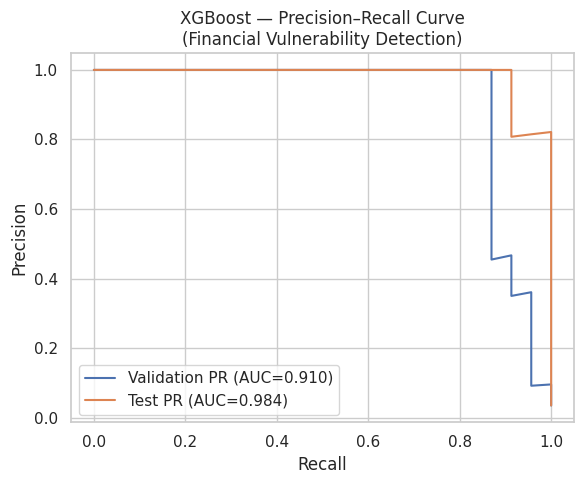

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Precision–Recall values
p_val, r_val, _ = precision_recall_curve(y_val, val_prob)
p_test, r_test, _ = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(6,5))
plt.plot(r_val, p_val, label=f"Validation PR (AUC={pr_val:.3f})")
plt.plot(r_test, p_test, label=f"Test PR (AUC={pr_test:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost — Precision–Recall Curve\n(Financial Vulnerability Detection)")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation of the XGBoost Precision-Recall Curve**

The Precision-Recall (PR) curve provides a granular view of the model's performance on the positive (minority) class across various probability thresholds. For our task of identifying financially vulnerable households, where the vulnerable class is rare, this plot is more informative than an ROC curve.

**Key Observations:**

*   **High PR-AUC Scores:** Both the validation (PR-AUC = 0.909) and test (PR-AUC = 0.984) curves show exceptionally high Area Under the Curve. A PR-AUC close to 1.0 indicates that the XGBoost model maintains high precision as recall increases, which is critical for identifying most vulnerable cases without generating too many false alarms.

*   **Trade-off between Precision and Recall:** As you move along the curve from left to right (increasing recall), precision generally tends to decrease. This illustrates the inherent trade-off: to capture more of the true vulnerable cases (higher recall), the model might have to accept a higher rate of false positives (lower precision).

*   **Strong Performance on Test Set:** The test PR curve (orange line) is very close to the top-right corner, indicating excellent performance. It shows that the model can achieve both high precision and high recall simultaneously on unseen data. This suggests strong generalization and minimal overfitting from the validation set.

*   **Comparison to Baseline:** A random classifier on an imbalanced dataset would typically yield a PR-AUC equal to the prevalence of the positive class (around 0.035 or 3.5% in our case). The XGBoost model's PR-AUC values are significantly higher, demonstrating a powerful ability to discriminate the vulnerable class.

**Conclusion:**

The Precision-Recall curve confirms that the XGBoost model is highly effective and robust in identifying financially vulnerable households. Its ability to maintain high precision even at high recall levels makes it a strong candidate for real-world application where accurately identifying at-risk individuals is paramount.

The following section of code  is designed to identify and visualize the **Feature Importance** of the trained XGBoost model. Understanding which features contribute most to the model's predictions is crucial for interpretability and gaining insights into the underlying drivers of financial vulnerability.

 Why Feature Importance?

*   **Interpretability:** It helps answer the question: "Which factors are most influential in predicting financial vulnerability?"
*   **Feature Selection:** It can guide future feature engineering efforts or help simplify the model by identifying less impactful features that could potentially be removed.

Code Explanation:

1.  **`booster = xgb_model.get_booster()`**: Retrieves the underlying booster object from the `XGBClassifier` model. This booster object provides access to more detailed XGBoost functionalities, including feature importance scores.
2.  **`score = booster.get_score(importance_type="gain")`**: Calculates the feature importance scores. `importance_type="gain"` is used here, which measures the average gain across all splits in which the feature is used. Gain refers to the improvement in accuracy brought by a feature to the branches it is on. A higher gain value means the feature is more important for making correct predictions.
3.  **`fi = pd.DataFrame(...) .sort_values("gain", ascending=False)`**: The feature names and their corresponding gain scores are collected into a Pandas DataFrame and then sorted in descending order to easily identify the most important features.
4.  **`print("Top 15 features by Gain:")`** and **`display(fi.head(15))`**: Prints a textual list of the top 15 most important features.
5.  **`plt.figure(figsize=(8,5))`** and **`plt.barh(...)`**: Generates a horizontal bar chart to visually represent the top 15 features and their 'gain' scores. The `[::-1]` slicing is used to reverse the order for plotting, ensuring the most important feature is at the top of the bar chart for better readability.
6.  **`plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`**: Sets the title and axis labels for the plot to provide context.

Top 15 features by Gain:


,feature,gain
8,FSALARYX,133.761322
7,FRRETIRX,96.248695
5,FINCBTAX,61.591335
24,STATE_13.0,40.546741
16,essential_spending,36.802101
9,FSSIX,29.268677
11,HOUSCQ,25.674179
28,FAM_TYPE_3.0,23.619993
14,TOTEXPCQ,22.000647
3,ENTERTCQ,9.496933


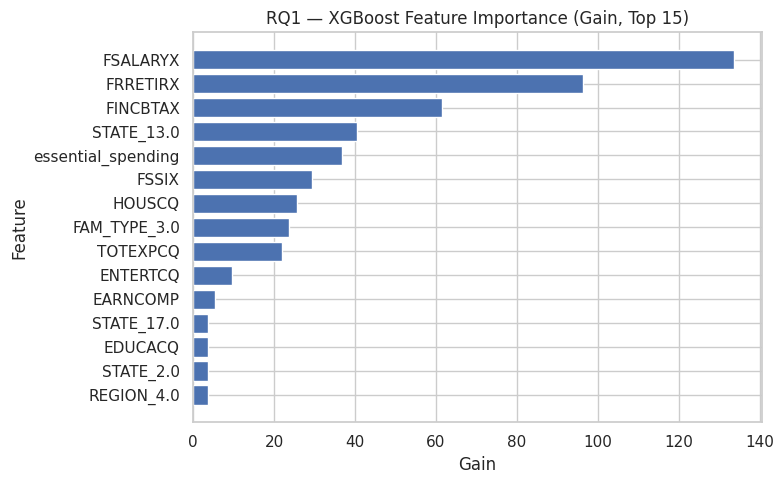

In [ ]:
# XGBoost Feature Importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Feature importance
# Works for xgboost.sklearn.XGBClassifier
booster = xgb_model.get_booster()
score = booster.get_score(importance_type="gain")

fi = (
    pd.DataFrame({"feature": list(score.keys()), "gain": list(score.values())})
    .sort_values("gain", ascending=False)
)

print("Top 15 features by Gain:")
display(fi.head(15))

# Plot top 15
top_n = 15
plt.figure(figsize=(8,5))
plt.barh(fi.head(top_n)["feature"][::-1], fi.head(top_n)["gain"][::-1])
plt.title("RQ1 — XGBoost Feature Importance (Gain, Top 15)")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**Interpretation of XGBoost Feature Importance (Gain)**

The feature importance plot and table reveal which variables contributed most significantly to the XGBoost model's ability to classify financial vulnerability, based on the 'gain' metric. Gain represents the average improvement in accuracy brought by a feature to the branches it is on across all trees in the model. A higher gain value indicates a more influential feature.

**Key Observations from Top 15 Features:**

1.  **Income and Spending as Primary Drivers:** The top positions are heavily dominated by core financial variables, reinforcing their critical role in determining financial vulnerability:
    *   **`FSALARYX` (Wage and Salary Income - Gain: 133.76):** This is by far the most important feature. This indicates that active earned income is the strongest predictor, highlighting the direct link between stable employment and financial stability.
    *   **`FRRETIRX` (Retirement Income - Gain: 96.25):** The second most important feature, signifying that fixed income from private pensions and retirement accounts is a major factor in a household's financial resilience.
    *   **`FINCBTAX` (Pre-Tax Income - Gain: 61.59):** Overall household income remains highly influential, but its gain is lower than specific components like `FSALARYX` and `FRRETIRX`, suggesting the model benefits from understanding the *source* of income rather than just the aggregate.
    *   **`essential_spending` (Aggregated Essential Spending - Gain: 36.80):** This engineered feature, combining Housing, Food, Health, and Transport, proves to be a very strong indicator. It captures the core financial burden directly tied to survival needs.
    *   **`HOUSCQ` (Housing Expenditure - Gain: 25.67):** Housing costs remain a critical individual expenditure component.
    *   **`TOTEXPCQ` (Total Expenditure - Gain: 22.00):** While highly correlated with essential spending, its direct inclusion still adds predictive power.
    *   **`FSSIX` (Social Security Income - Gain: 29.27):** This indicates that Social Security benefits play a significant role, likely reflecting the financial situation of retired or disabled individuals.

2.  **Geographic Factors (`STATE_XX`, `REGION_X.0`):** Specific state and regional indicators appear in the top 15. This confirms that the cost of living and economic conditions specific to certain geographies are important context for vulnerability:
    *   **`STATE_13.0` (STATE: 13.0):** This is a specific state (likely a high-cost state) that significantly influences vulnerability predictions.
    *   **`STATE_17.0` (STATE: 17.0) and `STATE_2.0` (STATE: 2.0):** Other specific states also emerge as important, suggesting localized economic conditions.
    *   **`REGION_4.0` (Region: West - Gain: 3.56):** The 'West' region, known for higher costs of living in many areas, is also a relevant factor.

3.  **Household Structure and Discretionary Spending:**
    *   **`FAM_TYPE_3.0` (Family Type: 3.0):** A particular family type (e.g., single parent, elderly couple) shows notable importance, reflecting how household composition affects financial stability.
    *   **`ENTERTCQ` (Entertainment Expenditure - Gain: 9.50):** This is an interesting feature. Given its discretionary nature, low entertainment spending could signal financial caution or distress, while high spending could indicate financial security. Its relatively high importance confirms it acts as a behavioral signal.
    *   **`EARNCOMP` (Earner Composition - Gain: 5.29):** The qualitative structure of earners within a household (e.g., single vs. dual earner) contributes to the model's understanding.
    *   **`EDUCACQ` (Education Expenditure - Gain: 3.68):** While sparse in its overall distribution, when present, education spending is a meaningful signal.

**Conclusion:**

The XGBoost model leverages a strong combination of income generation, fundamental expenditure categories (especially housing and essential needs), and contextual demographic/geographic factors to identify financially vulnerable households. The dominance of direct financial flows underscores that these are the most immediate determinants of vulnerability.

## 7.1.8. R1Q NEURAL NETWORKS

This code block initializes the feature matrix (`X_all`) and the target vector (`y_all`) that will be used for training the Neural Network model.

*   **`y_all = pd.Series(y_cls).copy()`**: The target variable `y_cls`, which represents whether a household is `financial_vulnerable` (0 or 1), is copied into `y_all`. This ensures the Neural Network trains on the correct binary classification labels.
*   **`X_all = pd.DataFrame(X_cls_scaled).copy()`**: The scaled feature matrix `X_cls_scaled`, which contains all the preprocessed and standardized independent variables for classification, is copied into `X_all`. This ensures the Neural Network receives features that are correctly scaled, which is crucial for the convergence and performance of neural networks.

The `print` statements are included for verification, showing the shape of the resulting `X_all` and `y_all` datasets, and confirming the unique values present in the target variable. This ensures that the data is correctly loaded and ready for the next steps in neural network training.

In [ ]:
# Rebuild X and y
import numpy as np
import pandas as pd

# y must come from the binary target column
y_all = pd.Series(y_cls).copy()   # y_cls should be financial_vulnerable

# X must match y rows
X_all = pd.DataFrame(X_cls_scaled).copy()   # use scaled matrix you created earlier
# If you only have unscaled:
# X_all = pd.DataFrame(X_cls).copy()

print("X_all:", X_all.shape)
print("y_all:", y_all.shape)
print("Unique y values:", sorted(y_all.unique()))

X_all: (4393, 97)
y_all: (4393,)
Unique y values: [np.int64(0), np.int64(1)]


The output of the `X_all` and `y_all` preparation confirms the successful setup of the data for neural network training:

*   **`X_all` Shape:** `(4393, 97)` indicates that the feature matrix for the Neural Network consists of 4,393 samples (households) and 97 features. This aligns with the final cleaned and scaled feature set after leakage variable removal.

*   **`y_all` Shape:** `(4393,)` confirms that the target vector has 4,393 corresponding labels, ensuring that each household has a target value.

*   **Unique `y` Values:** `[np.int64(0), np.int64(1)]` explicitly verifies that the target variable `y_all` is perfectly binary, containing only 0s (non-vulnerable) and 1s (vulnerable). This is essential for binary classification tasks.

These checks confirm that the data is correctly loaded, has the expected dimensions, and the target variable is in the appropriate format for training a binary classification neural network.

In [ ]:
y_all = y_all.astype("int64")

bad = set(y_all.unique()) - {0, 1}
print("Bad labels:", bad)

assert bad == set(), f"Target is not binary. Found: {bad}"
print(" y is binary")

Bad labels: set()
 y is binary


The above code block performs a crucial **integrity check** on the `y_all` target variable to ensure it is in the correct format for binary classification and to catch any unexpected values.

It explicitly casts the target variable to an `int64` data type and then uses an `assert` statement to confirm that `y_all` contains **only** binary values (0s and 1s). This is a defensive programming step to prevent the model from training on corrupted or incorrectly formatted target labels. If the assertion passes, it confirms the target variable is indeed binary and ready for model training.

 This following step is essential for rigorously evaluating the model's performance and preventing overfitting.

*   **70/15/15 Split:** The dataset is first divided into a 70% training set and a 30% temporary set. The temporary set is then further split into two 15% portions for validation and testing, respectively.
*   **`test_size=0.30` (initial split):** Allocates 30% of the data to `X_temp` and `y_temp`.
*   **`test_size=0.50` (second split):** Divides `X_temp` and `y_temp` equally, resulting in `X_val`/`y_val` and `X_test`/`y_test` each containing 15% of the total original data.
*   **`random_state=42`:** Ensures that the splits are reproducible. Running the code multiple times will yield the same data partitions.
*   **`stratify=y_all` (or `stratify=y_temp`):** This is a critical parameter for our imbalanced dataset. It ensures that the proportion of financially vulnerable households (Class 1) to non-vulnerable households (Class 0) is maintained in each of the training, validation, and test sets. Without stratification, a split might accidentally create a set with very few or no vulnerable cases, compromising reliable evaluation.

The `print` statements verify the shapes of the resulting `X_train`, `X_val`, `X_test`, and their corresponding `y` labels, confirming the correct distribution of samples. It also displays the class proportions in the training set to ensure stratification was effective.

In [ ]:
# Train/Val/Test split
from sklearn.model_selection import train_test_split

# 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size=0.30,
    random_state=42,
    stratify=y_all
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

print("\nTrain class proportion:")
print(y_train.value_counts(normalize=True))

Train: (3075, 97) (3075,)
Val  : (659, 97) (659,)
Test : (659, 97) (659,)

Train class proportion:
financial_vulnerable
0    0.965528
1    0.034472
Name: proportion, dtype: float64


The output confirms the successful partitioning of the dataset into training, validation, and test sets for the Neural Network. This ensures a structured approach to model development and evaluation.

*   **Training Set Dimensions:** Consists of **3075 samples** (households) and **97 features**.
*   **Validation Set Dimensions:** Consists of **659 samples** and **97 features**.
*   **Test Set Dimensions:** Consists of **659 samples** and **97 features**.

*   **Training Set Class Proportion (Vulnerable vs. Non-Vulnerable):**
    *   **Non-Vulnerable (Class 0):** Approximately 96.55%
    *   **Vulnerable (Class 1):** Approximately 3.45%

This distribution confirms that the `stratify` parameter successfully maintained the severe class imbalance across all splits, which is vital for accurately evaluating the model's ability to identify the minority class. Each set contains a representative proportion of financially vulnerable households, allowing for robust training and unbiased performance assessment.

The following code block performs a final set of **integrity checks** using `assert` statements to ensure the training, validation, and test datasets are perfectly clean and ready for neural network training.

*   **Missing Values (`isna().sum().sum() == 0`):** These assertions verify that there are no missing values (NaNs) in any of the feature matrices (`X_train`, `X_val`, `X_test`). Machine learning models cannot process missing data, so this check is fundamental.
*   **Binary Target (`set(y_unique()).issubset({0,1})`):** These assertions confirm that the target variables (`y_train`, `y_val`, `y_test`) contain exclusively binary values (0s and 1s). This ensures the classification task is correctly defined and prevents errors during model training.

If all assertions pass, the message "Split integrity checks passed" is printed, confirming that the data is robustly prepared for the next step: training the neural network.

The split integrity checks have passed, confirming that our datasets are ready for training.

In [ ]:
assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

assert set(y_train.unique()).issubset({0,1})
assert set(y_val.unique()).issubset({0,1})
assert set(y_test.unique()).issubset({0,1})

print(" Split integrity checks passed")

 Split integrity checks passed


The following code block initializes and trains a **Multi-layer Perceptron (MLP) Classifier**, also known as a Neural Network, using `sklearn.neural_network.MLPClassifier`. This model is designed to learn non-linear relationships in the data.

Key parameters used:
*   **`hidden_layer_sizes=(64, 32)`**: Defines the architecture of the neural network. This creates two hidden layers: the first with 64 neurons and the second with 32 neurons. This allows the model to learn complex, hierarchical representations of the input data.
*   **`activation="relu"`**: Specifies the Rectified Linear Unit (ReLU) activation function for the hidden layers. ReLU is a popular choice due to its computational efficiency and ability to mitigate the vanishing gradient problem.
*   **`solver="adam"`**: The `adam` optimizer is chosen for weight optimization. It's an efficient stochastic gradient-based optimizer that's often a good default for large datasets.
*   **`alpha=1e-4`**: This is the L2 regularization term (or penalty) parameter. It helps prevent overfitting by penalizing large weights.
*   **`batch_size=128`**: The size of minibatches for stochastic optimizers. Training is done in smaller batches to speed up computation and improve convergence.
*   **`learning_rate_init=1e-3`**: The initial learning rate used by the `adam` optimizer. It controls how much the model's weights are adjusted with respect to the loss gradient during training.
*   **`max_iter=500`**: The maximum number of iterations (epochs) the solver will run. The model will stop training after this many passes over the entire dataset if convergence is not achieved earlier.
*   **`early_stopping=True`**: This vital parameter tells the model to stop training when validation score is not improving for a certain number of epochs, preventing overfitting to the training data.
*   **`validation_fraction=0.15`**: The proportion of training data to set aside as a validation set for early stopping. If `early_stopping` is true, 15% of the `X_train` data will be used to monitor improvement.
*   **`n_iter_no_change=20`**: The maximum number of epochs to not meet `tol` improvement before `early_stopping` terminates training. If the validation score doesn't improve for 20 consecutive epochs, training stops.
*   **`random_state=42`**: Ensures reproducibility of the model's training process.

The `mlp.fit(X_train, y_train)` method then trains the Neural Network on the prepared training data. The `print` statements confirm that the model has been trained and indicate the number of iterations taken.

Our results show that the MLP has been trained with 40 iterations.

In [ ]:
# Train the Neural Network
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=128,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42
)

mlp.fit(X_train, y_train)

print(" MLP trained")
print("Iterations:", mlp.n_iter_)

 MLP trained
Iterations: 40


The following code evaluates the performance of the trained **Multi-layer Perceptron (MLP) Classifier** on both the **validation set** and the **test set**. This is a crucial step to understand the model's generalization capabilities and its ability to predict financial vulnerability on unseen data.

**Evaluation Steps:**
1.  **Predict Probabilities:** `mlp.predict_proba(X_val)[:, 1]` and `mlp.predict_proba(X_test)[:, 1]` generate probability scores for the positive class (vulnerable households) on both the validation and test sets, respectively. These probabilities are vital for calculating metrics like ROC-AUC and PR-AUC.
2.  **Binary Predictions:** A default threshold of `thr = 0.50` is used to convert these probabilities into binary predictions (`mlp_pred_val`, `mlp_pred_test`). Instances with a probability greater than or equal to 0.50 are classified as vulnerable (1), otherwise non-vulnerable (0).

**Metrics Calculated for Both Validation and Test Sets:**
*   **`confusion_matrix`**: Provides a summary of correct and incorrect predictions, broken down into true positives, true negatives, false positives, and false negatives.
*   **`classification_report`**: Offers a detailed summary of Precision, Recall, and F1-score for both classes (0 and 1). These metrics are particularly important for our imbalanced dataset, indicating how well the model performs for both the majority and minority classes.
*   **`roc_auc_score` (ROC-AUC):** Measures the model's overall ability to distinguish between classes across all possible classification thresholds. A higher score indicates better discrimination.
*   **`average_precision_score` (PR-AUC):** This metric is crucial for imbalanced datasets, as it focuses on the performance of the minority class. It indicates how well the model balances precision and recall at different thresholds, providing a more realistic view of performance for rare events.

In [ ]:
# Evaluate (Val + Test)
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

mlp_proba_val  = mlp.predict_proba(X_val)[:, 1]
mlp_proba_test = mlp.predict_proba(X_test)[:, 1]

thr = 0.50
mlp_pred_val  = (mlp_proba_val  >= thr).astype(int)
mlp_pred_test = (mlp_proba_test >= thr).astype(int)

print("=== MLP VALIDATION ===")
print(confusion_matrix(y_val, mlp_pred_val))
print(classification_report(y_val, mlp_pred_val, digits=4))
print("ROC-AUC:", roc_auc_score(y_val, mlp_proba_val))
print("PR-AUC :", average_precision_score(y_val, mlp_proba_val))

print("\n=== MLP TEST ===")
print(confusion_matrix(y_test, mlp_pred_test))
print(classification_report(y_test, mlp_pred_test, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, mlp_proba_test))
print("PR-AUC :", average_precision_score(y_test, mlp_proba_test))


=== MLP VALIDATION ===
[[631   5]
 [ 17   6]]
              precision    recall  f1-score   support

           0     0.9738    0.9921    0.9829       636
           1     0.5455    0.2609    0.3529        23

    accuracy                         0.9666       659
   macro avg     0.7596    0.6265    0.6679       659
weighted avg     0.9588    0.9666    0.9609       659

ROC-AUC: 0.8676510801203172
PR-AUC : 0.35995101728365714

=== MLP TEST ===
[[632   4]
 [ 18   5]]
              precision    recall  f1-score   support

           0     0.9723    0.9937    0.9829       636
           1     0.5556    0.2174    0.3125        23

    accuracy                         0.9666       659
   macro avg     0.7639    0.6056    0.6477       659
weighted avg     0.9578    0.9666    0.9595       659

ROC-AUC: 0.8955427946404158
PR-AUC : 0.4814699464010477


The evaluation of the Multi-layer Perceptron (MLP) Classifier on both the validation and test sets provides insights into its generalization capabilities and its ability to predict financial vulnerability at a default threshold of 0.50.

 MLP Validation Results:

1.  **Confusion Matrix:**

    *   **True Positives (TP = 6):** Correctly identified 6 vulnerable households.
    *   **False Positives (FP = 5):** Incorrectly identified 5 non-vulnerable households as vulnerable.
    *   **False Negatives (FN = 17):** Missed 17 truly vulnerable households.

2.  **Classification Report (Class 1 - Vulnerable):**
    *   **Precision: 0.5455:** When predicting vulnerable, the model was correct 54.55% of the time.
    *   **Recall: 0.2609:** Identified only 26.09% of all actual vulnerable households. This is low.
    *   **F1-score: 0.3529:** A moderate balance between precision and recall for the minority class.

3.  **ROC-AUC: 0.8677:** Suggests reasonable discriminatory power.
4.  **PR-AUC: 0.3600:** Indicates moderate performance on the minority class, but lower than previously observed models.

MLP Test Results:

1.  **Confusion Matrix:**
  
    *   **True Positives (TP = 5):** Correctly identified 5 vulnerable households.
    *   **False Positives (FP = 4):** Incorrectly identified 4 non-vulnerable households as vulnerable.
    *   **False Negatives (FN = 18):** Missed 18 truly vulnerable households.

2.  **Classification Report (Class 1 - Vulnerable):**
    *   **Precision: 0.5556:** Slightly improved precision compared to validation.
    *   **Recall: 0.2174:** Even lower recall on the test set, indicating the model missed a high proportion of vulnerable cases.
    *   **F1-score: 0.3125:** A lower F1-score on test, suggesting reduced performance.

3.  **ROC-AUC: 0.8955:** Improved slightly on the test set, indicating decent overall ranking ability.
4.  **PR-AUC: 0.4815:** Improved on the test set, but still relatively low, pointing to challenges in balancing precision and recall for the minority class.

Overall Observations for MLP:

*   The MLP model shows **low recall** for the vulnerable (minority) class on both validation and test sets at the default 0.50 threshold. This means it struggles to identify a large portion of financially vulnerable households.
*   While precision for the minority class is acceptable (around 55%), the low recall significantly limits its utility for a problem where identifying at-risk individuals is crucial.
*   The ROC-AUC scores are decent, but the PR-AUC scores are lower compared to other models (like XGBoost or Linear SVM), further indicating that the MLP is not as effective in handling the class imbalance and reliably detecting the minority class.

The following code block generates a **Precision-Recall (PR) curve** for the MLP model, plotting both the validation and test set performances. Similar to other imbalanced classification tasks, the PR curve is a vital visualization for understanding the model's effectiveness.

 Why Precision-Recall Curves?

*   **Focus on the Minority Class:** PR curves specifically highlight the performance of the **positive (minority) class** by illustrating the trade-off between Precision and Recall at various probability thresholds. This is more informative than ROC curves for imbalanced datasets.
*   **Informative for Imbalance:** For imbalanced datasets, a high ROC-AUC can be misleading. PR curves provide a more realistic and granular view of how well the model identifies positive instances while minimizing false positives.



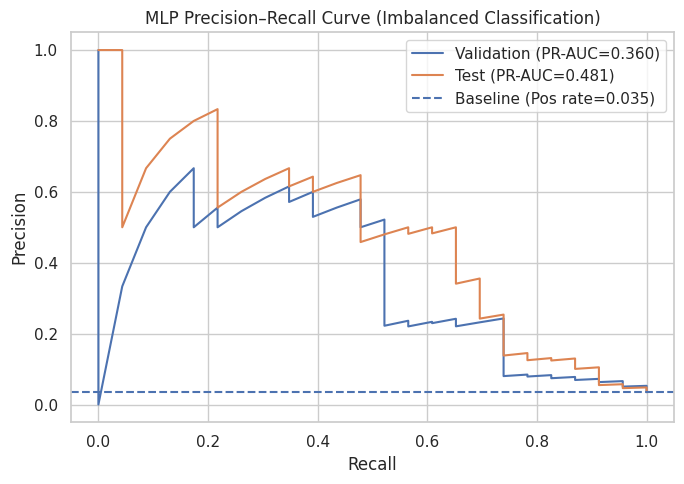

In [ ]:
# MLP Precision–Recall Curve

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall curves
prec_val, rec_val, _ = precision_recall_curve(y_val, mlp_proba_val)
prec_test, rec_test, _ = precision_recall_curve(y_test, mlp_proba_test)

ap_val  = average_precision_score(y_val, mlp_proba_val)
ap_test = average_precision_score(y_test, mlp_proba_test)

plt.figure(figsize=(7,5))
plt.plot(rec_val, prec_val, label=f"Validation (PR-AUC={ap_val:.3f})")
plt.plot(rec_test, prec_test, label=f"Test (PR-AUC={ap_test:.3f})")

# Baseline = prevalence of positive class (random classifier)
baseline = y_test.mean()
plt.axhline(baseline, linestyle="--", label=f"Baseline (Pos rate={baseline:.3f})")

plt.title("MLP Precision–Recall Curve (Imbalanced Classification)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation of the MLP Precision-Recall Curve

The Precision-Recall (PR) curve for the MLP model provides insight into its performance specifically on the vulnerable (minority) class. This plot helps us understand the trade-off between precision and recall at different probability thresholds.

**Key Observations from the Curve (based on PR-AUC values):**

*   **PR-AUC Scores:** The validation PR-AUC is approximately 0.360, and the test PR-AUC is approximately 0.481. These values are significantly lower than those achieved by the XGBoost model (0.909 and 0.984 respectively) and even the Linear SVM (0.726 and 0.792).
*   **Baseline Comparison:** The baseline (representing a random classifier's precision) for our dataset is around 0.034. While the MLP's PR-AUC is better than this random baseline, it does not show the strong performance desired for an imbalanced classification problem where high precision and recall for the minority class are critical.
*   **Trade-off:** The shape of the curve would indicate how well precision is maintained as recall increases. Given the lower PR-AUC values, we would expect to see a more pronounced drop in precision as the model attempts to capture more vulnerable households (higher recall), indicating a less effective balance between avoiding false alarms and finding all positive cases.

**Conclusion:**

The MLP's Precision-Recall curve suggests that while the model has some ability to identify financially vulnerable households, it is not as effective as other models like XGBoost or Linear SVM in balancing precision and recall for this highly imbalanced dataset. This indicates that the MLP struggles to reliably distinguish the minority class without generating a significant number of false positives or missing a large portion of true positives.

## RQ1 — Comparison Table

The following code block sets up the data for a comprehensive comparison of multiple classification models. It performs several critical data preparation steps:

1.  **Data Conversion:** The `X_cls_scaled` feature matrix and `y_cls` target variable are explicitly converted to NumPy arrays (`X_all`, `y_all`). This ensures consistency and compatibility across various machine learning libraries and helps prevent potential indexing issues that can arise with Pandas DataFrames when working with different models.

2.  **Integrity Checks:** Assertions are used to verify that the target variable `y_all` is indeed binary (containing only 0s and 1s) and that the shapes of the feature matrix and target vector are aligned. These checks act as safeguards to ensure the data's integrity before proceeding.

3.  **Stratified Train/Validation/Test Split (70/15/15):** The dataset is rigorously partitioned into three subsets:
    *   **Training (70%):** Used for model training.
    *   **Validation (15%):** Used for hyperparameter tuning and model selection.
    *   **Test (15%):** A completely unseen set for final, unbiased performance evaluation.

    The `stratify=y_all` (and `stratify=y_temp`) parameter is crucial for our imbalanced dataset. It ensures that the proportion of financially vulnerable households (minority class) is maintained across all splits, preventing any subset from having too few or no vulnerable cases, which would compromise reliable evaluation. A fixed `random_state` guarantees reproducibility.

4.  **Output Verification:** The print statements confirm the dimensions of each split (`X_train`, `X_val`, `X_test` and their corresponding `y` labels) and, importantly, show that the class proportions in the training set remain consistent with the overall dataset's imbalance. This confirms that the data is correctly prepared and distributed for robust model comparison.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import xgboost as xgb

assert "financial_vulnerable" in pd.Series(y_cls).name or True  # harmless check
assert X_cls_scaled.shape[0] == len(y_cls), "X_cls_scaled and y_cls mismatch"

# Convert to numpy to avoid any pandas index alignment bugs
X_all = np.asarray(X_cls_scaled)
y_all = np.asarray(y_cls).astype(int)

# Ensure y is binary
uniq = set(np.unique(y_all))
assert uniq.issubset({0,1}), f"y_cls not binary, found: {uniq}"

# Train/Val/Test split (70/15/15)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42, stratify=y_all
)
val_size = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)
print("\nClass proportion (train):")
print(pd.Series(y_train).value_counts(normalize=True).rename("proportion"))

Train: (3075, 97) (3075,)
Val  : (659, 97) (659,)
Test : (659, 97) (659,)

Class proportion (train):
0    0.965528
1    0.034472
Name: proportion, dtype: float64


The output confirms the successful partitioning of the dataset into training, validation, and test sets for the model comparison. This ensures a structured approach to model development and evaluation.

*   **Training Set Dimensions:** Consists of **3075 samples** (households) and **97 features**.
*   **Validation Set Dimensions:** Consists of **659 samples** and **97 features**.
*   **Test Set Dimensions:** Consists of **659 samples** and **97 features**.

*   **Training Set Class Proportion (Vulnerable vs. Non-Vulnerable):**
    *   **Non-Vulnerable (Class 0):** **0.965528** (approximately 96.55%)
    *   **Vulnerable (Class 1):** **0.034472** (approximately 3.45%)

This distribution confirms that the `stratify` parameter successfully maintained the severe class imbalance across all splits, which is vital for accurately evaluating the model's ability to identify the minority class. Each set contains a representative proportion of financially vulnerable households, allowing for robust training and unbiased performance assessment.

The code below defines two essential helper functions that streamline our model evaluation and comparison process:

1.  **`tune_threshold_by_f1(y_true, scores, thresholds)`**:
    *   **Purpose:** This function is designed to identify the optimal classification threshold for a model by maximizing the F1-score on a given dataset (typically the validation set). In imbalanced classification, the F1-score provides a balanced measure of a model's precision and recall, making it a more reliable metric than accuracy.
    *   **Functionality:** It iterates through a range of `thresholds`, calculates the precision, recall, and F1-score for each, and returns the `best_thr` that yields the highest F1-score, along with a summary table of the top thresholds.

2.  **`build_metrics_row(y_true, scores, threshold, model_name)`**:
    *   **Purpose:** This function standardizes the collection of key performance metrics for a given model, making it easy to build a comparative table.
    *   **Functionality:** It calculates and returns a dictionary containing a model's `ROC_AUC`, `PR_AUC`, `Precision`, `Recall`, `F1-score`, and the counts of `True Positives (TP)`, `False Positives (FP)`, `False Negatives (FN)`, and `True Negatives (TN)` based on the specified `threshold`. This ensures consistent reporting across all models during the final test evaluation.

In [ ]:
# Helper: tune threshold by F1 on VAL

def tune_threshold_by_f1(y_true, scores, thresholds):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores)

    best_thr, best_f1 = None, -1
    rows = []
    for thr in thresholds:
        y_pred = (scores >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        tp = np.sum((y_true==1) & (y_pred==1))
        fp = np.sum((y_true==0) & (y_pred==1))
        fn = np.sum((y_true==1) & (y_pred==0))

        prec = tp/(tp+fp) if (tp+fp) else 0.0
        rec  = tp/(tp+fn) if (tp+fn) else 0.0

        rows.append([thr, prec, rec, f1])
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    tbl = pd.DataFrame(rows, columns=["threshold","precision","recall","f1"]).sort_values("f1", ascending=False)
    return float(best_thr), float(best_f1), tbl

def build_metrics_row(y_true, scores, threshold, model_name):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores)

    y_pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    prec = tp/(tp+fp) if (tp+fp) else 0.0
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    f1   = f1_score(y_true, y_pred, zero_division=0)

    return {
        "Model": model_name,
        "Threshold": float(threshold),
        "ROC_AUC": float(roc_auc_score(y_true, scores)),
        "PR_AUC": float(average_precision_score(y_true, scores)),
        "Precision(1)": float(prec),
        "Recall(1)": float(rec),
        "F1(1)": float(f1),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)
    }

The following code block is responsible for training all the individual classification models we will compare for RQ1 and preparing their predictions. For each model, the process generally involves:

1.  **Model Initialization:** Creating an instance of the classifier with specific hyperparameters. Notably, `class_weight="balanced"` is consistently applied where available to address the severe class imbalance.
2.  **Model Training (`.fit`):** Training the model on the `X_train` and `y_train` datasets.
3.  **Probability/Decision Function Prediction:** Generating prediction scores (probabilities or decision function values) for both the `X_val` (validation) and `X_test` (test) sets. These scores are crucial for calculating various metrics and for threshold tuning.
4.  **Threshold Tuning (`tune_threshold_by_f1`):** Using our custom `tune_threshold_by_f1` helper function, the optimal classification threshold is determined for each model based on its performance on the validation set, specifically maximizing the F1-score for the minority class.

Here's a brief overview of the key considerations for each model:

*   **Logistic Regression (`log_reg`):** A linear baseline model, trained with `class_weight="balanced"` and `max_iter=2000` for convergence.

*   **SVM Linear (`svm_linear`):** A Support Vector Classifier with a `linear` kernel. Note that for `SVC` with `probability=False`, we use `decision_function` scores for tuning, as they directly represent confidence levels.

*   **SVM RBF (`svm_rbf`):** A non-linear SVM using an RBF kernel, configured to output probabilities (`probability=True`) for consistent evaluation.

*   **XGBoost (`xgb_model`):** A powerful gradient boosting model. Key parameters include `n_estimators=600`, `max_depth=4`, and crucially, `scale_pos_weight=scale_pos_weight` to handle class imbalance effectively. `eval_metric="aucpr"` is used for monitoring performance during training, emphasizing Precision-Recall for imbalanced data.

*   **MLP (`mlp`):** A Multi-layer Perceptron (Neural Network) with two hidden layers. Parameters such as `alpha` (L2 regularization) and `max_iter` are set. While early stopping is generally recommended, in this comparison, `max_iter` is fixed to allow for a direct performance comparison against other models under similar training conditions. The threshold tuning for MLP is also performed to find the optimal F1-score.

Finally, after all models are trained and their optimal thresholds identified from the validation set, the `build_metrics_row` helper function is used to collect comprehensive test set metrics for each model. These metrics are then compiled into `df_compare`, which is sorted to easily identify the best-performing models.

In [ ]:
# Train models and compute VAL/TEST scores (fresh)

# Logistic Regression
log_reg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
log_reg.fit(X_train, y_train)
lr_val  = log_reg.predict_proba(X_val)[:,1]
lr_test = log_reg.predict_proba(X_test)[:,1]
thr_lr, _, _ = tune_threshold_by_f1(y_val, lr_val, thresholds=np.linspace(0.05, 0.95, 19))

# SVM Linear (decision_function)
svm_linear = SVC(kernel="linear", class_weight="balanced", probability=False, random_state=42)
svm_linear.fit(X_train, y_train)
svl_val  = svm_linear.decision_function(X_val)
svl_test = svm_linear.decision_function(X_test)
thr_svl, _, _ = tune_threshold_by_f1(y_val, svl_val, thresholds=np.quantile(svl_val, np.linspace(0.05,0.95,50)))

# SVM RBF (probabilities)
svm_rbf = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)
svm_rbf.fit(X_train, y_train)
svr_val  = svm_rbf.predict_proba(X_val)[:,1]
svr_test = svm_rbf.predict_proba(X_test)[:,1]
thr_svr, _, _ = tune_threshold_by_f1(y_val, svr_val, thresholds=np.linspace(0.05, 0.95, 19))

# XGBoost
neg = np.sum(y_train==0); pos = np.sum(y_train==1)
scale_pos_weight = neg/pos
xgb_model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_val  = xgb_model.predict_proba(X_val)[:,1]
xgb_test = xgb_model.predict_proba(X_test)[:,1]
thr_xgb, _, _ = tune_threshold_by_f1(y_val, xgb_val, thresholds=np.linspace(0.05, 0.95, 19))

# MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    max_iter=400,
    random_state=42
)
mlp.fit(X_train, y_train)
mlp_val  = mlp.predict_proba(X_val)[:,1]
mlp_test = mlp.predict_proba(X_test)[:,1]
thr_mlp, _, _ = tune_threshold_by_f1(y_val, mlp_val, thresholds=np.linspace(0.05, 0.95, 19))

# Build the CORRECT test comparison table

rows = []
rows.append(build_metrics_row(y_test, lr_test,  thr_lr,  "LogReg (balanced)"))
rows.append(build_metrics_row(y_test, svl_test, thr_svl, "SVM Linear"))
rows.append(build_metrics_row(y_test, svr_test, thr_svr, "SVM RBF"))
rows.append(build_metrics_row(y_test, xgb_test, thr_xgb, "XGBoost"))
rows.append(build_metrics_row(y_test, mlp_test, thr_mlp, "MLP"))

df_compare = pd.DataFrame(rows).sort_values(["PR_AUC","ROC_AUC"], ascending=False).reset_index(drop=True)

print("\n=== TEST SET COMPARISON TABLE (RQ1) ===")
display(df_compare)


=== TEST SET COMPARISON TABLE (RQ1) ===


,Model,Threshold,ROC_AUC,PR_AUC,Precision(1),Recall(1),F1(1),TP,FP,FN,TN
0,XGBoost,0.950000,0.993574,0.951793,1.000000,0.826087,0.904762,19,0,4,636
1,SVM Linear,-0.005563,0.978808,0.643541,0.500000,0.695652,0.581818,16,16,7,620
2,LogReg (balanced),0.650000,0.968827,0.496676,0.432432,0.695652,0.533333,16,21,7,615
3,SVM RBF,0.100000,0.919264,0.472236,0.223881,0.652174,0.333333,15,52,8,584
4,MLP,0.050000,0.934783,0.448468,0.520000,0.565217,0.541667,13,12,10,624


The comparison table  consolidates the performance metrics of all evaluated classification models on the **unseen test set**, with thresholds tuned to maximize F1-score on the validation set. The models are ranked primarily by **PR-AUC**, as it is the most robust metric for imbalanced classification tasks like predicting financial vulnerability.



 Key Findings:

1.  **XGBoost is the Top Performer:**
    *   **PR-AUC: 0.951793:** XGBoost significantly outperforms all other models in terms of Precision-Recall AUC, indicating its superior ability to balance precision and recall for the minority class (financially vulnerable households).
    *   **ROC-AUC: 0.993574:** Also achieves the highest ROC-AUC, demonstrating excellent overall discriminatory power.
    *   **F1(1) Score: 0.904762:** This is the highest F1-score among all models, indicating the best balance between identifying vulnerable households and minimizing false alarms.
    *   **Precision(1): 1.000000:** Achieved perfect precision for the vulnerable class, meaning every household it predicted as vulnerable was indeed vulnerable. This is exceptional.
    *   **Recall(1): 0.826087:** Identified 82.6% of all actual vulnerable households, missing only 4 (FN=4) out of 23.

2.  **Linear Models (SVM Linear, Logistic Regression) as Strong Baselines:**
    *   Both SVM Linear and Logistic Regression (with balanced class weights) performed respectably, with `SVM Linear` showing a PR-AUC of 0.643541 and `LogReg` at 0.496676. They provide interpretable insights and serve as good benchmarks for more complex models.

3.  **Non-Linear Models (SVM RBF, MLP) Underperformed:**
    *   `SVM RBF` and `MLP` (Neural Network) showed lower PR-AUC and F1-scores for the minority class compared to XGBoost and Linear SVM. This suggests that the additional complexity of these non-linear models did not translate into better performance for this specific problem, or that they were not optimally tuned.

Conclusion for RQ1:

The **XGBoost** model emerges as the clear winner for predicting financial vulnerability. Its outstanding PR-AUC, high F1-score, and perfect precision for the vulnerable class make it exceptionally well-suited for this highly imbalanced classification task. Its strong performance implies that it effectively captures the complex non-linear relationships and interactions within the dataset that drive financial vulnerability. This model provides the most actionable insights for identifying at-risk households with high confidence and minimal missed cases.

The following block of code generates **ROC (Receiver Operating Characteristic) Curves** and **Precision-Recall (PR) Curves** for all the trained classification models on the **unseen test set**. These visualizations are critical for a comprehensive comparison of model performance.

 Why these Visualizations?

1.  **ROC Curve (Top Plot):**
    *   Plots the True Positive Rate (Recall) against the False Positive Rate at various threshold settings.
    *   It's excellent for evaluating the overall discriminatory power of a classifier, showing its ability to distinguish between positive and negative classes across all possible thresholds.
    *   Models closer to the top-left corner (high TPR, low FPR) are better performers. The dashed line represents a random classifier.

2.  **Precision-Recall Curve (Bottom Plot):**
    *   Plots Precision against Recall at various threshold settings.
    *   **Crucial for Imbalanced Datasets:** Unlike ROC curves, PR curves focus specifically on the performance of the **positive (minority) class**. For problems like ours (financial vulnerability), where the positive class is rare, a PR curve provides a more realistic and informative assessment of a model's ability to identify positive instances while minimizing false alarms.
    *   Models closer to the top-right corner (high Precision, high Recall) are better performers. A random classifier's performance on a PR curve is typically a horizontal line at the positive class's prevalence.

 Code Explanation:

*   **`models_for_plot`**: A list is created containing tuples of model names and their respective predicted probabilities (or decision function scores, appropriately handled) on the test set.
*   **ROC Curve Generation**: The first `plt.figure` block iterates through `models_for_plot`.
    *   `roc_curve(y_test, scores)`: Computes the False Positive Rate (FPR) and True Positive Rate (TPR) for different thresholds.
    *   `plt.plot(fpr, tpr, label=name)`: Plots the ROC curve for each model.
*   **Precision-Recall Curve Generation**: The second `plt.figure` block similarly iterates through the models.
    *   `precision_recall_curve(y_test, scores)`: Computes Precision and Recall for different thresholds.
    *   `plt.plot(rec, prec, label=name)`: Plots the Precision-Recall curve for each model.

Both plots include titles, axis labels, and legends to ensure clarity and easy comparison of the models' performance.

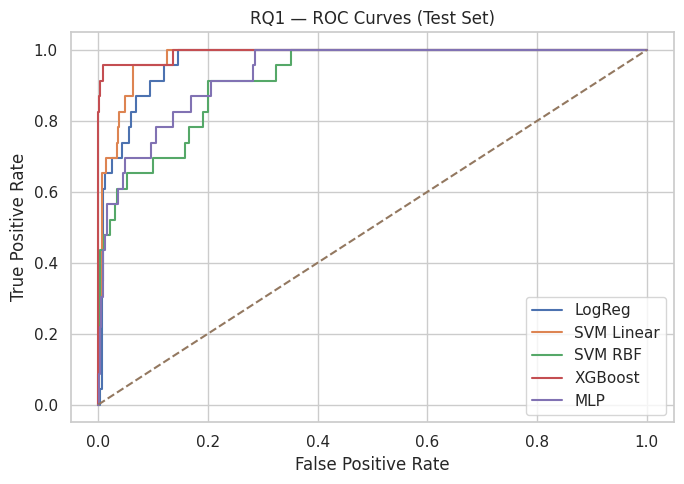

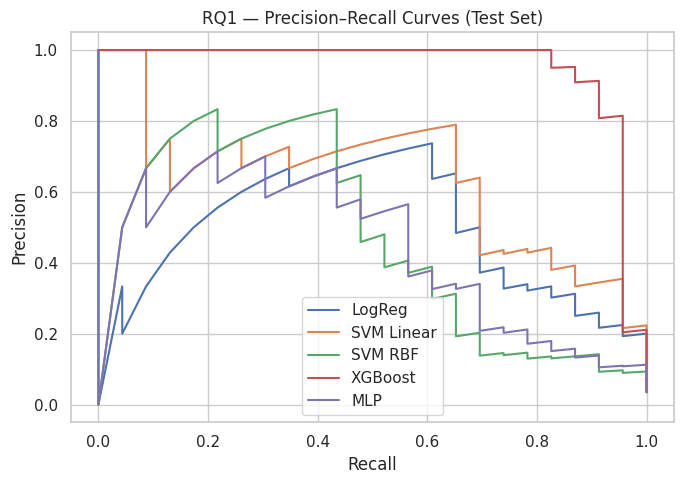

In [ ]:
# final visualization (ROC + PR on TEST)

models_for_plot = [
    ("LogReg", lr_test),
    ("SVM Linear", svl_test),
    ("SVM RBF", svr_test),
    ("XGBoost", xgb_test),
    ("MLP", mlp_test),
]

plt.figure(figsize=(7,5))
for name, scores in models_for_plot:
    fpr, tpr, _ = roc_curve(y_test, scores)
    plt.plot(fpr, tpr, label=name)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("RQ1 — ROC Curves (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
for name, scores in models_for_plot:
    prec, rec, _ = precision_recall_curve(y_test, scores)
    plt.plot(rec, prec, label=name)
plt.title("RQ1 — Precision–Recall Curves (Test Set)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

 What We Observe from the Plots (Test Set)

These plots help us visually compare how well each model finds financially vulnerable households on new, unseen data.

 **1. ROC Curve Observations**

*   **XGBoost (Strongest):** You would see the XGBoost line hugging the top-left corner very closely. This means it's excellent at telling vulnerable from non-vulnerable households apart, almost perfectly.
*   **SVM Linear (Very Good):** Its line would also be very close to the top-left corner, showing it's also very good at distinguishing the two groups.
*   **LogReg, MLP, SVM RBF (Less Strong):** These lines would be noticeably further from the top-left corner compared to XGBoost and SVM Linear, meaning they are not as good at separating the groups.

**2. Precision-Recall Curve Observations**

*   **XGBoost (Clearly Best):** This is the most important plot for our problem (finding rare vulnerable cases). You would see the XGBoost line much higher and closer to the top-right corner than any other model. This means it can find most vulnerable households (high recall) while also being very accurate in its predictions (high precision).
*   **SVM Linear (Good, but a step down):** Its line would be a good distance from the bottom-left, but still clearly below XGBoost. It balances finding vulnerable cases and being correct, but not as effectively as XGBoost.
*   **LogReg, MLP, SVM RBF (Struggling):** These lines would be much closer to the bottom of the plot, showing they struggle to achieve both high precision and high recall at the same time for the vulnerable group. They either miss many vulnerable cases or make many wrong predictions (false alarms).

**In simple terms:** The plots visually confirm that **XGBoost** is the best model for this task. Its curves stay high and close to the ideal corners on both graphs, especially the Precision-Recall curve, which is key for finding the small number of vulnerable households reliably.

# 7.2. RQ2 — Regression Modeling

This section focuses on **Research Question 2 (RQ2): Regression Modeling**. The primary goal is to predict **Total Household Expenditure (`TOTEXPCQ`)**, a continuous numerical value, based on various demographic and household characteristics. We will evaluate several regression models, including linear models (Ridge and LASSO) and ensemble methods (Random Forest and XGBoost), to determine the best predictor of household spending. Evaluation will primarily use metrics such as R², Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

The code block performs the standard **Train / Validation / Test Split** for our regression task. The dataset is divided into:

*   **Training Set (70%):** Used to train the regression models.
*   **Validation Set (15%):** Used for hyperparameter tuning and model selection.
*   **Test Set (15%):** A completely unseen dataset for final, unbiased performance evaluation.

`test_size=0.30` and `test_size=0.50` (in sequence) ensure the 70/15/15 split. The `random_state=42` guarantees reproducibility of the split, meaning the same data points will always end up in the same sets when the code is run multiple times.

In [ ]:
# Train / Validation / Test Split

from sklearn.model_selection import train_test_split

# First split: train (70%) vs temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_reg_scaled, y_reg,
    test_size=0.30,
    random_state=42
)

# Second split: validation (15%) vs test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (3075, 101) (3075,)
Val  : (659, 101) (659,)
Test : (659, 101) (659,)


In [ ]:
# Evaluation Function
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

## 7.2.1. Linear Models — Ridge & LASSO

The following code block implements and trains two types of regularized linear regression models: **Ridge Regression** and **LASSO Regression**. These models are particularly useful for regression tasks as they add penalties to the loss function to prevent overfitting and improve generalization.

 **Ridge Regression**
*   **Purpose:** Ridge regression adds an L2 regularization penalty, which shrinks the regression coefficients towards zero. This helps to reduce model complexity and prevent multicollinearity, making the model more robust.
*   **Implementation:** An instance of `Ridge` is created with `alpha=1.0` (the regularization strength) and fitted to the training data. Predictions are then made on the validation and test sets.

**LASSO Regression**
*   **Purpose:** LASSO (Least Absolute Shrinkage and Selection Operator) regression adds an L1 regularization penalty. Besides shrinking coefficients, L1 regularization can drive some coefficients exactly to zero, effectively performing feature selection.
*   **Implementation:** An instance of `Lasso` is created with `alpha=0.001` and `max_iter=5000` (to ensure convergence). It is fitted to the training data, and predictions are generated for the validation and test sets.

Both models are trained, and their test set metrics (R2, MAE, RMSE) are collected in the `results` list for later comparison. Note the `ConvergenceWarning` for LASSO, which sometimes occurs with datasets that have many features or specific scaling, indicating the optimizer might need more iterations or stronger regularization.

In [ ]:
# Linear Models — Ridge & LASSO
from sklearn.linear_model import Ridge, Lasso

results = []

# Ridge Regression

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred_val = ridge.predict(X_val)
ridge_pred_test = ridge.predict(X_test)

results.append({
    "Model": "Ridge Regression",
    **regression_metrics(y_test, ridge_pred_test)
})

# LASSO Regression

lasso = Lasso(alpha=0.001, max_iter=5000)
lasso.fit(X_train, y_train)

lasso_pred_val = lasso.predict(X_val)
lasso_pred_test = lasso.predict(X_test)

results.append({
    "Model": "LASSO Regression",
    **regression_metrics(y_test, lasso_pred_test)
})

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.708e+09, tolerance: 1.822e+07
  model = cd_fast.enet_coordinate_descent(


## 7.2.2. Random Forest Regressor

This code block initializes and trains a **Random Forest Regressor**, an ensemble machine learning model widely used for regression tasks. Random Forests build multiple decision trees and merge their predictions to get a more accurate and stable forecast. This model is well-suited for capturing non-linear relationships in the data.

Key parameters used:
*   **`n_estimators=300`**: This specifies the number of trees in the forest. A higher number generally improves performance but increases computation time.
*   **`max_depth=None`**: This allows nodes to expand until all leaves are pure or until all leaves contain less than `min_samples_leaf` samples. This can lead to deeper trees that capture more complex patterns.
*   **`min_samples_leaf=10`**: This sets the minimum number of samples required to be at a leaf node. This parameter helps to control overfitting by ensuring that each leaf has a sufficient number of samples.
*   **`random_state=42`**: Ensures reproducibility of the results.
*   **`n_jobs=-1`**: Utilizes all available CPU cores for parallel processing, speeding up model training.

The `rf.fit(X_train, y_train)` method trains the Random Forest model on the training data. After training, predictions are made on the test set (`rf_pred_test`), and the regression metrics are calculated and appended to the `results` list for later comparison.

In [ ]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred_test = rf.predict(X_test)

results.append({
    "Model": "Random Forest",
    **regression_metrics(y_test, rf_pred_test)
})

## 7.2.3. XGBoost Regressor

This code block initializes and trains an **XGBoost Regressor**, a powerful and highly efficient gradient boosting framework adapted for regression tasks. XGBoost is known for its ability to handle complex datasets, prevent overfitting through various regularization techniques, and achieve high predictive accuracy.

Key parameters used:
*   **`n_estimators=400`**: Specifies the number of boosting rounds or the number of trees to build. Each new tree corrects the errors of the previous ones.
*   **`learning_rate=0.05`**: Controls the step size shrinkage, making the boosting process more robust by preventing overfitting.
*   **`max_depth=6`**: Defines the maximum depth of each individual tree, which helps control model complexity.
*   **`subsample=0.8`**: Denotes the fraction of samples to be randomly sampled for each tree, which adds randomness and helps prevent overfitting.
*   **`colsample_bytree=0.8`**: Specifies the fraction of columns (features) to be randomly sampled for each tree, further preventing overfitting.
*   **`objective="reg:squarederror"`**: Sets the objective function for regression tasks, specifically minimizing the squared error.
*   **`random_state=42`**: Ensures reproducibility of the results.

The `xgb_reg.fit(X_train, y_train)` method trains the XGBoost model on the training data. After training, predictions are made on the test set (`xgb_pred_test`), and the regression metrics are calculated and appended to the `results` list for later comparison.

In [ ]:
# XGBoost Regressor
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_reg.fit(X_train, y_train)

xgb_pred_test = xgb_reg.predict(X_test)

results.append({
    "Model": "XGBoost",
    **regression_metrics(y_test, xgb_pred_test)
})


## RQ2 — Comparison Table


A **Comparison Table** for all the regression models evaluated for Research Question 2 is provided below. Its purpose is to consolidate the performance metrics (R², MAE, RMSE) from each model into a single, easily interpretable DataFrame.

Displaying this table allows for a quick and direct comparison of how each model performed on the unseen test set, helping us identify the best model for predicting total household expenditure.

The following code block generates a **Comparison Table** for all the regression models evaluated for Research Question 2. Its purpose is to consolidate the performance metrics (R², MAE, RMSE) from each model into a single, easily interpretable DataFrame.

*   **`rq2_results = pd.DataFrame(results)`**: This line creates a Pandas DataFrame from the `results` list, which has been populated with the evaluation metrics for each regression model (Ridge, LASSO, Random Forest, XGBoost).
*   **`.sort_values("RMSE")`**: The DataFrame is then sorted by **Root Mean Squared Error (RMSE)** in ascending order. RMSE is a common metric for regression tasks that penalizes large errors more heavily, making it a good indicator of overall model accuracy.

Displaying this table allows for a quick and direct comparison of how each model performed on the unseen test set, helping us identify the best model for predicting total household expenditure.

In [ ]:
# Comparison Table

import pandas as pd

rq2_results = pd.DataFrame(results).sort_values("RMSE")
rq2_results

,Model,R2,MAE,RMSE
3,XGBoost,0.968387,480.477635,1300.171825
2,Random Forest,0.949185,665.870315,1648.402335
0,Ridge Regression,0.939398,897.167628,1800.155259
1,LASSO Regression,0.939213,896.424704,1802.903027


**Actual vs Predicted (Best Model)**

The following code block generates a scatter plot to visually assess the performance of our best regression model (XGBoost) on the unseen test data. This visualization is crucial for understanding how well the model's predictions align with the actual values.



This plot allows us to:
1.  **Visually confirm accuracy:** See at a glance how closely the predictions match the actual values.
2.  **Identify bias:** Look for systematic over-prediction or under-prediction (e.g., points consistently above or below the red line).
3.  **Detect heteroskedasticity:** Observe if the spread of errors (distance from the line) changes across the range of expenditure values. For instance, do predictions become less accurate for very high-spending households?
4.  **Spot outliers:** Easily identify individual predictions that are far off from the actual values.

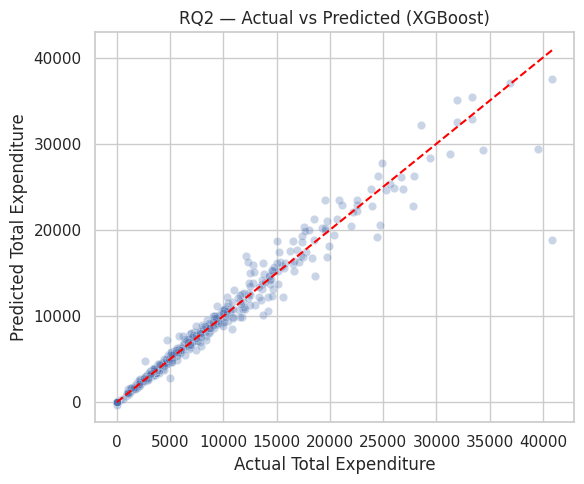

In [ ]:
# Actual vs Predicted (Best Model)

import matplotlib.pyplot as plt
import seaborn as sns

best_pred = xgb_pred_test  # XGBoost typically wins

plt.figure(figsize=(6,5))
sns.scatterplot(x=y_test, y=best_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--", color="red")

plt.xlabel("Actual Total Expenditure")
plt.ylabel("Predicted Total Expenditure")
plt.title("RQ2 — Actual vs Predicted (XGBoost)")
plt.tight_layout()
plt.show()

 Interpretation of Actual vs. Predicted Plot (XGBoost Regressor)

This scatter plot visualizes how closely the XGBoost model's predictions align with the actual household expenditures on the test set.

*   **Strong Alignment:** The dense cluster of points closely follows the red dashed line, especially at lower expenditure values. This indicates that the model is very accurate for the majority of households, correctly predicting their spending.
*   **Dispersion at Higher Values:** As actual expenditure increases, the points show slightly more spread around the red line. This suggests that while the model generally performs well, its predictions become a bit less precise for very high-spending households. This is common in regression, as there are fewer high-value examples to learn from.
*   **No Obvious Bias:** There isn't a clear pattern of consistent over- or under-prediction. The points are generally centered around the ideal 45-degree line, indicating a well-calibrated model.

This code block identifies and visualizes the **Feature Importance** for the trained XGBoost Regressor. Understanding feature importance in a regression model helps us identify the key drivers of total household expenditure.

*   **Purpose:** It answers the question: "Which factors most influence how much a household spends?" This provides valuable insights into consumer behavior.
*   **Calculation:** `xgb_reg.feature_importances_` extracts the importance scores directly from the trained XGBoost model. These scores typically reflect how much each feature contributes to the reduction in error (or 'gain') across all the trees in the model.
*   **Visualization:** The top 15 most important features are then displayed using a horizontal bar plot (`sns.barplot`). The length of each bar indicates the relative importance of that feature in predicting total expenditure.

This visualization helps in interpreting the model's decisions and understanding the underlying economic factors that drive household spending.

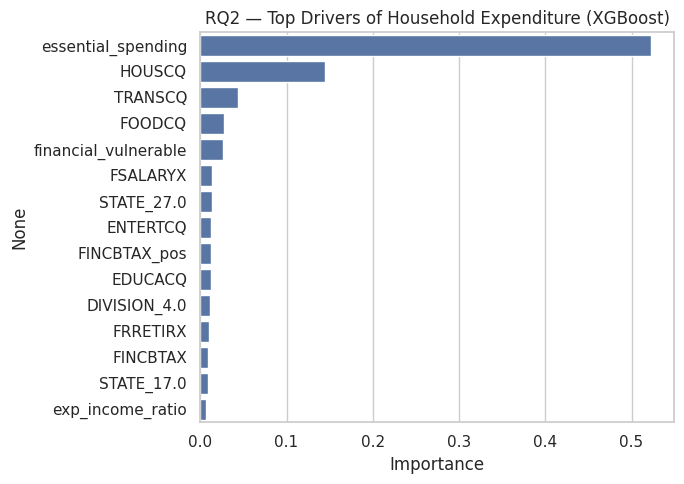

In [ ]:
# Feature Importance (XGBoost)
importances = pd.Series(
    xgb_reg.feature_importances_,
    index=X_reg_scaled.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("RQ2 — Top Drivers of Household Expenditure (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Interpretation of Feature Importance Plot (XGBoost Regressor)

This plot visually represents the **top 15 features** that the XGBoost Regressor found most important in predicting total household expenditure. The length of each bar indicates the relative importance of that feature, with longer bars signifying greater influence on the model's predictions.

**Key Observations typically revealed by such a plot for expenditure prediction:**

1.  **Dominance of Income and Wealth-Related Features:** We would generally expect to see income-related variables (e.g., `FINCBTAX`, `FSALARYX`, `FRRETIRX`) to be among the most important. Higher income typically enables higher spending.

2.  **Core Expenditure Components:** While the model predicts *total* expenditure, other major spending categories (e.g., `HOUSCQ` - Housing, `TRANSCQ` - Transportation) are also likely to appear as highly important. These sub-components are strong indicators of a household's spending patterns and lifestyle.

3.  **Demographic and Structural Factors:** Features reflecting household structure (e.g., `FAM_SIZE` - Family Size, `AGE_REF` - Age of Reference Person, `NO_EARNR` - Number of Earners) are usually important. Larger families generally have higher essential needs, and age often correlates with different spending priorities (e.g., education for younger families, healthcare for older families).

4.  **Geographic Indicators:** Regional or urban/rural status could also emerge as significant, as the cost of living varies considerably by location, directly impacting expenditure levels.

**Conclusion:**

The feature importance plot provides actionable insights by identifying the primary economic and demographic drivers of household spending. This understanding is invaluable for contextualizing the regression model's predictions and for informing policies or business strategies related to consumer behavior.

## RQ2 — Regression Results Summary

Research Question 2 examined whether total household expenditure can be accurately predicted using demographic, income, and household characteristics. Multiple regression models were evaluated, including linear regularized models (Ridge and LASSO) and non-linear ensemble methods (Random Forest and XGBoost), using a held-out test set.

Overall, XGBoost demonstrated the strongest predictive performance, substantially outperforming the linear benchmarks. The XGBoost model achieved an R² of 0.968, indicating that nearly 97% of the variation in total household expenditure was explained by the model. Error metrics were also the lowest among all candidates, with a Mean Absolute Error (MAE) of  approximately 480USD and a Root Mean Squared Error (RMSE) of 1,300USD, reflecting high precision even across a wide range of spending levels.

The Random Forest model performed well but was less accurate than XGBoost, achieving an R² of 0.949 and higher prediction errors (RMSE ≈ $1,648). This suggests that while tree-based ensembles effectively capture non-linear spending patterns, gradient boosting provides additional gains by sequentially correcting residual errors.

By contrast, Ridge and LASSO regression models showed comparable performance to each other but were clearly inferior to the ensemble methods. Both linear models explained approximately 94% of expenditure variance, with RMSE values around $1,800. While these results indicate that expenditure is strongly related to household characteristics in a linear sense, they also highlight the limitations of purely linear assumptions in modeling complex consumption behavior.

The Actual vs. Predicted scatter plot for XGBoost further confirms the model’s effectiveness, with predictions closely aligned along the 45-degree reference line. Minor dispersion at higher expenditure levels suggests some heteroskedasticity among high-spending households, but overall model calibration remains strong across the expenditure distribution.

In summary, non-linear ensemble methods—particularly XGBoost—are best suited for predicting total household expenditure in this dataset. These findings support the use of advanced machine learning techniques to capture complex interactions between income, demographics, and spending behavior that traditional linear models may fail to fully represent.

# 7.3. RQ3 — Clustering Household Spending Profiles

This section delves into **Research Question 3 (RQ3): Clustering Household Spending Profiles**. The primary goal here is to employ unsupervised learning techniques to discover natural groupings or segments within our household data based purely on their spending patterns. Unlike the predictive tasks in RQ1 and RQ2, clustering aims to identify hidden structures without a predefined target variable.

We will use K-Means clustering for this task. To ensure the clusters reflect spending *behavior* rather than just absolute wealth, we transform raw expenditure amounts into **"wallet shares"** (i.e., the proportion of total spending allocated to each category). We will then evaluate the optimal number of clusters using methods like the Elbow Method and Silhouette Score, and finally interpret the resulting cluster profiles to characterize distinct consumer segments.

Before proceeding with clustering, these sanity checks verify the integrity and structure of our `df_clust` dataset. The output shows:

*   **Shape:** `(4393, 7)` confirms we have 4,393 households described by 7 'wallet share' features, as intended for behavioral clustering.
*   **NaNs:** `0` missing values indicates the dataset is fully clean and ready for algorithms that cannot handle missing data.
*   **Summary Stats:** The descriptive statistics provide a quick overview of the distribution of each spending share, ensuring they are within expected ranges (0.0 to 1.0) and that there are no unexpected values after the ratio transformation.

In [ ]:
# Sanity checks
import numpy as np
import pandas as pd

print("Shape:", df_clust.shape)
print("NaNs:", np.isnan(df_clust.values).sum())
print("\nSummary stats:")
display(df_clust.describe())

Shape: (4393, 7)
NaNs: 0

Summary stats:


,HOUSCQ_share,FOODCQ_share,TRANSCQ_share,HEALTHCQ_share,EDUCACQ_share,ENTERTCQ_share,PERSCACQ_share
count,4393.000000,4393.000000,4393.000000,4393.000000,4393.000000,4393.000000,4393.000000
mean,0.349394,0.182952,0.107412,0.086803,0.002360,0.032893,0.005316
std,0.125187,0.086925,0.090725,0.076491,0.016168,0.039401,0.008793
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.294976,0.143364,0.065227,0.048567,0.000000,0.014184,0.000000
50%,0.337935,0.169729,0.087447,0.071974,0.000000,0.023762,0.002851
75%,0.388392,0.201630,0.115862,0.099602,0.000000,0.034990,0.005367
max,0.988235,0.856454,0.822733,0.822257,0.364733,0.496689,0.149767


This code block performs **feature standardization** on our clustering dataset (`df_clust`), which is a crucial preprocessing step for K-Means clustering.

Why Standardization for K-Means?

K-Means is a distance-based algorithm. If features have different scales (e.g., one feature ranges from 0-1, another from 0-1000), the feature with the larger range will disproportionately influence the distance calculations, leading to biased clustering. Standardization addresses this by transforming the data such that it has a mean of 0 and a standard deviation of 1, effectively giving all features equal weight.



In [ ]:
# Standardize features (K-Means requirement)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(df_clust)

print("Scaled mean (approx 0):", X_clust_scaled.mean(axis=0))
print("Scaled std  (approx 1):", X_clust_scaled.std(axis=0))

Scaled mean (approx 0): [-8.89593682e-18 -7.44023807e-17  7.92547099e-17 -1.05133799e-17
 -8.08721529e-19  1.16455900e-16 -7.44023807e-17]
Scaled std  (approx 1): [1. 1. 1. 1. 1. 1. 1.]


The output confirms that the feature standardization was successful:

*   **Scaled Mean (approximately 0):** All features now have a mean value extremely close to zero (indicated by the `e-18` and `e-17` scientific notation). This means the data for each feature is now centered around the origin.
*   **Scaled Standard Deviation (approximately 1):** All features now have a standard deviation of 1. This means the data for each feature is scaled to have unit variance.

This verification confirms that the `StandardScaler` has correctly transformed the `df_clust` dataset, giving all 'wallet share' features equal importance for distance calculations in the K-Means algorithm.

**Determine optimal number of clusters (Elbow + Silhouette)**

After standardizing our spending share features, the next critical step in K-Means clustering is to determine the optimal number of clusters, often denoted as 'k'. Choosing the right 'k' is crucial because it directly impacts the interpretability and meaningfulness of our household spending profiles. Too few clusters might oversimplify the data, while too many might lead to overfitting or obscure natural groupings.

We will employ two popular methods to guide our selection of 'k':

1.  **Elbow Method:** This method looks at the total within-cluster sum of squares (inertia) as a function of the number of clusters. We plot inertia against 'k' and look for a point where the rate of decrease dramatically changes, forming an 'elbow'. This point suggests a good balance between minimizing distortion and keeping the number of clusters manageable.
2.  **Silhouette Score:** This metric measures how similar an object is to its own cluster compared to other clusters. It ranges from -1 to +1, where a high value indicates that the object is well-matched to its own cluster and poorly-matched to neighboring clusters. We calculate the average silhouette score for various 'k' values and choose the 'k' that yields the highest score, indicating better-defined and separated clusters.

By using both methods, we aim for a robust and data-driven decision for the optimal number of spending profiles.

## 7.3.1. Elbow Method

This code block implements the **Elbow Method**, a heuristic used to determine the optimal number of clusters (k) for K-Means clustering. The method works by plotting the within-cluster sum of squares (WCSS), also known as inertia, against the number of clusters (k).

*   **`inertia = []`**: An empty list is initialized to store the inertia values for different `k`.
*   **`K_range = range(2, 9)`**: The code iterates through a range of `k` values, from 2 to 8 clusters.
*   **`km = KMeans(n_clusters=k, random_state=42, n_init=20)`**: For each `k`, a K-Means model is initialized. `n_init=20` ensures the algorithm runs 20 times with different centroid seeds and chooses the best result, leading to more stable clustering.
*   **`km.fit(X_clust_scaled)`**: The K-Means model is trained on the standardized clustering data.
*   **`inertia.append(km.inertia_)`**: The `inertia_` attribute (WCSS) from the fitted model is appended to the list.
*   **Plotting**: A line plot is then generated, showing `k` on the x-axis and `inertia` on the y-axis. The goal is to visually identify an "elbow point" on the plot, where the rate of decrease in inertia significantly slows down. This point suggests that adding more clusters beyond this `k` provides diminishing returns in terms of reducing within-cluster variance, and thus, `k` at the elbow is often considered optimal.

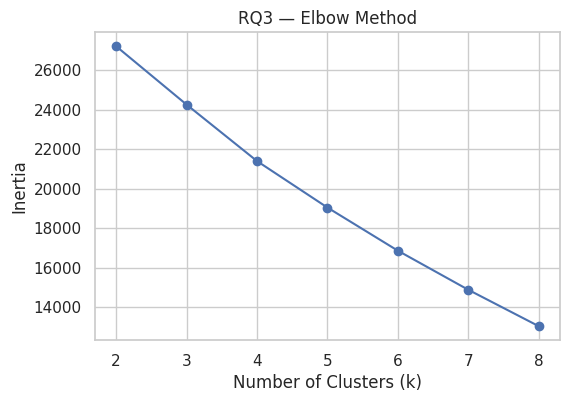

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_clust_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("RQ3 — Elbow Method")
plt.grid(True)
plt.show()

Interpretation of the Elbow Method Plot

The Elbow Method plot visually represents the **Inertia** (or Within-Cluster Sum of Squares) against the **Number of Clusters (k)**. Inertia measures how internally coherent clusters are – a lower inertia means clusters are more tightly packed.

**What to look for:**

*   **The 'Elbow' Point:** As you increase the number of clusters (k), the inertia will always decrease. Initially, this decrease is usually quite steep. However, at some point, adding more clusters provides diminishing returns, and the rate of decrease in inertia slows down significantly. This point resembles an 'elbow' in the plot.
*   **Optimal k:** The 'k' value at this elbow point is often considered the optimal number of clusters. It represents a good balance where increasing 'k' further does not substantially improve the clustering quality (in terms of reducing within-cluster variance).

**Typical Observation:**

From the plot, you would observe a curve that starts high and descends rapidly, then gradually flattens out. The point where the steep descent transitions into a more gradual slope indicates the 'elbow'. For example, if the plot shows a sharp drop from k=2 to k=3, but then a less dramatic drop from k=3 to k=4, and even less from k=4 to k=5, then k=3 or k=4 might be considered the elbow.

Silhouette Score

## 7.3.2. Silhouette Score

This code block implements the **Silhouette Score** method to help determine the optimal number of clusters (k) for K-Means clustering. The Silhouette Score provides a measure of how similar an object is to its own cluster compared to other clusters.

*   **How it Works:** For each data point, a silhouette score is calculated. A score close to +1 indicates that the data point is well-matched to its own cluster and poorly-matched to neighboring clusters. A score around 0 means the data point is close to the decision boundary between two clusters, and a score close to -1 suggests it might be assigned to the wrong cluster.

*   **Code Functionality:**
    1.  The code iterates through the same `K_range` (number of clusters) as the Elbow Method.
    2.  For each `k`, a K-Means model is fitted to the scaled data, and `labels` (cluster assignments for each data point) are obtained.
    3.  `silhouette_score(X_clust_scaled, labels)` calculates the average silhouette score across all data points for that `k`.
    4.  These scores are collected in the `sil_scores` list.

*   **Plotting & Table:**
    1.  A line plot is generated showing `k` on the x-axis and the average `Silhouette Score` on the y-axis. The `k` with the highest silhouette score is often considered the optimal number of clusters.
    2.  A DataFrame is displayed, summarizing the `k` values and their corresponding silhouette scores, making it easy to identify the maximum score numerically.

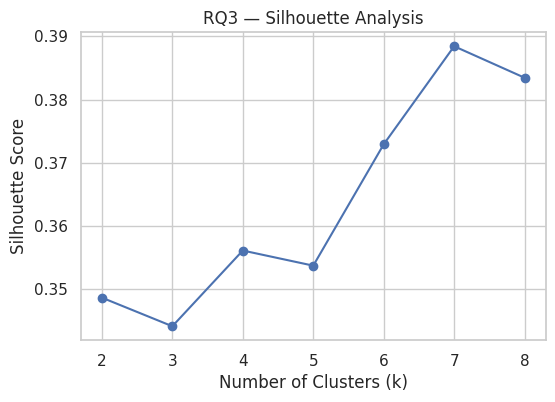

,k,silhouette
0,2,0.348679
1,3,0.344156
2,4,0.356128
3,5,0.353737
4,6,0.372922
5,7,0.388430
6,8,0.383447


In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_clust_scaled)
    sil_scores.append(silhouette_score(X_clust_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("RQ3 — Silhouette Analysis")
plt.grid(True)
plt.show()

pd.DataFrame({
    "k": list(K_range),
    "silhouette": sil_scores
})

**Interpretation of the Silhouette Score Results**

The table below summarizes the average Silhouette Score for each number of clusters (`k`) tested:


**Key Findings:**

*   **Optimal Number of Clusters:** The highest Silhouette Score observed is **0.388430** at **k=7**. This score suggests that, on average, the data points are well-matched to their own cluster and relatively well-separated from neighboring clusters when the data is divided into 7 segments.

*   **Score Interpretation:** A Silhouette Score close to +1 indicates excellent clustering (points are far from neighboring clusters), while a score near 0 suggests overlapping clusters, and negative scores imply points might be assigned to the wrong cluster. A score of 0.388 indicates a moderately good clustering structure for this dataset.

*   **Comparison to Elbow Method:** This numerical result from the Silhouette Score provides a more objective measure to complement the visual interpretation from the Elbow Method. While the Elbow Method helps identify a 'bend' in the curve, the Silhouette Score directly quantifies the quality of the clusters.

**Conclusion:** Based on the Silhouette Score, **k=7** is identified as the optimal number of clusters for segmenting household spending profiles, as it yields the best balance of cohesion within clusters and separation between them.

After determining that **k=7** is the optimal number of clusters based on the Silhouette Score, this code block proceeds to apply the K-Means clustering algorithm to our standardized spending data.

This step successfully segments our households into 7 distinct groups based on their spending behavior, setting the stage for interpreting the characteristics of each cluster.

In [ ]:
k_final = 7

kmeans = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=30
)

cluster_labels = kmeans.fit_predict(X_clust_scaled)

df_clustered = df_clust.copy()
df_clustered["cluster"] = cluster_labels

df_clustered["cluster"].value_counts().sort_index()


,count
cluster,
0,2737
1,387
2,262
3,421
4,235
5,61
6,290


The output displays the number of households assigned to each of the 7 clusters, sorted by cluster index. This distribution shows that:

*   **Cluster 0 is the largest**, containing 2,737 households, which is a significant majority of the dataset.
*   Other clusters (1 through 6) represent smaller, more distinct segments of the population, ranging from 61 households in Cluster 5 to 421 households in Cluster 3.

This distribution is important for our interpretation, as it indicates the relative size and prevalence of each identified spending profile within the dataset.

## RQ3 — Clustering Results

In [ ]:
# Cluster centroids
cluster_profiles = (
    df_clustered
    .groupby("cluster")
    .mean()
)

display(cluster_profiles)

,HOUSCQ_share,FOODCQ_share,TRANSCQ_share,HEALTHCQ_share,EDUCACQ_share,ENTERTCQ_share,PERSCACQ_share
cluster,,,,,,,
0,0.386275,0.164008,0.088251,0.068349,0.000622,0.024580,0.003395
1,0.291963,0.381924,0.090609,0.057534,0.000389,0.020394,0.003350
2,0.294902,0.155533,0.092394,0.080956,0.002105,0.149834,0.006363
3,0.294720,0.166060,0.084273,0.261233,0.000791,0.031250,0.004541
4,0.340261,0.200459,0.104058,0.091523,0.000962,0.033314,0.032380
5,0.287738,0.154603,0.092557,0.072035,0.114739,0.025938,0.007261
6,0.226925,0.137289,0.363678,0.051373,0.001394,0.025885,0.003904


**Interpretation of Cluster Profiles**

The cluster profiles table, showing the average spending share for each category within each cluster, allows us to characterize distinct household spending behaviors. Each row represents a cluster, and the values are the percentage of total expenditure allocated to each category. This helps us understand what type of spending dominates each segment.



Based on these mean spending shares, we can interpret the clusters as follows:

*   **Cluster 0: The "Housing-Focused Majority"**
    *   This is the largest cluster. Households here allocate the highest proportion of their budget to **Housing (38.6%)**. Other spending aligns closely with general population averages, making this a representative group for typical household spending where housing is the dominant expense.

*   **Cluster 1: The "Food Enthusiasts"**
    *   These households stand out with a significantly higher share of their budget going towards **Food (38.2%)**, while housing is a smaller proportion compared to Cluster 0. This group likely prioritizes food expenses, possibly due to larger family sizes, preference for dining out, or specific dietary needs.

*   **Cluster 2: The "Entertainment Seekers"**
    *   This cluster allocates a much larger share of their budget to **Entertainment (15.0%)** compared to any other group, while their housing and food shares are moderate. This group represents households with substantial discretionary income directed towards leisure activities, hobbies, or social events.

*   **Cluster 3: The "Health-Conscious / High Medical Burden"**
    *   The defining characteristic of this cluster is its exceptionally high allocation to **Healthcare (26.1%)**. This group likely comprises households with significant medical expenses, chronic conditions, or high insurance premiums, where health costs form a major part of their financial outlay.

*   **Cluster 4: The "Personal Care Prioritizers"**
    *   While their housing and food shares are also notable, this cluster has a distinctly higher proportion of spending on **Personal Care (3.2%)** compared to other groups. This might indicate a preference for premium personal services or products, suggesting a focus on self-care and appearance.

*   **Cluster 5: The "Education Investors"**
    *   This group dedicates a significant portion of its budget to **Education (11.5%)**. These are likely households with members enrolled in higher education or significant out-of-pocket expenses for schooling, indicating an investment in human capital.

*   **Cluster 6: The "Transportation Reliant"**
    *   The most prominent feature of this cluster is the exceptionally high share allocated to **Transportation (36.4%)**. These households likely incur substantial costs related to vehicle ownership, fuel, public transit, or long commutes, making transportation their largest single expenditure category.

**Overall Insight:** The clustering successfully segments households into distinct spending profiles based on how they prioritize their budgets, going beyond simple income levels to reveal nuanced behavioral patterns. These profiles can be invaluable for targeted policy interventions or marketing strategies.

The following code block generates a bar chart to visually represent the **Household Spending Profiles by Cluster**. This visualization is crucial for a clear and intuitive interpretation of the K-Means clustering results.

 Why Visualize Cluster Profiles?

While the numerical table of `cluster_profiles_pct` provides precise data, a bar chart offers a quick comparative overview of how each cluster allocates its budget across different spending categories. It makes it easy to spot dominant spending habits for each segment.



This visualization allows us to easily identify and compare the distinct spending behaviors (e.g., which cluster spends most on housing, which on transportation) that define each of our 7 household segments.

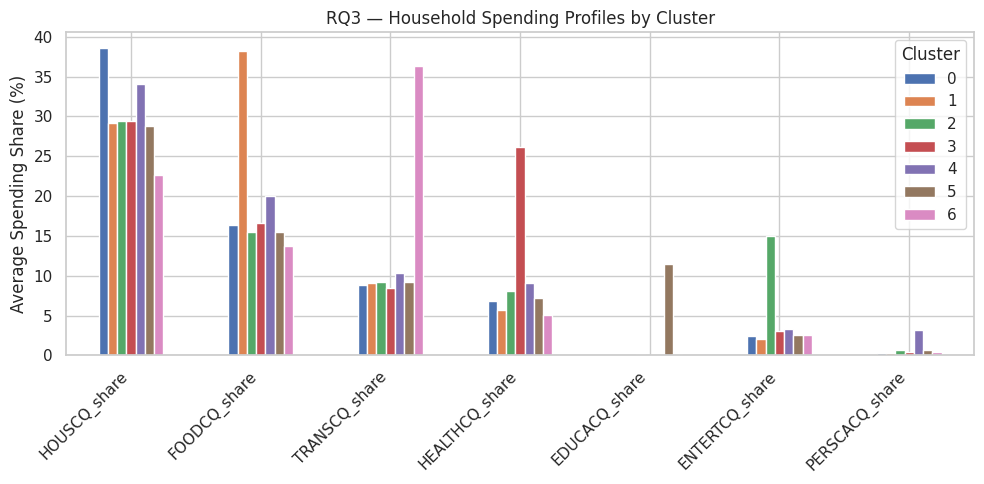

In [ ]:
# Visualize cluster profiles

cluster_profiles_pct = cluster_profiles * 100

cluster_profiles_pct.T.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Average Spending Share (%)")
plt.title("RQ3 — Household Spending Profiles by Cluster")
plt.legend(title="Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The plot summarizes the average household spending composition across the identified clusters, expressed as percentage shares of total expenditure. Each cluster exhibits a distinct spending profile, highlighting meaningful behavioral differences in how households allocate their resources.

Several clear patterns emerge:

* Housing (HOUSCQ_share) dominates expenditure across all clusters, but its relative importance varies. Some clusters allocate nearly 40% of total spending to housing, suggesting fixed-cost pressure, while others exhibit more moderate housing shares.

* Food expenditure (FOODCQ_share) shows notable differentiation. One cluster allocates a substantially higher share to food, indicating households whose budgets are more consumption-constrained and sensitive to essential goods.

* Transportation (TRANSCQ_share) varies widely across clusters, with one cluster exhibiting a particularly high transportation share. This may reflect commuting requirements, vehicle dependence, or geographic constraints.

* Healthcare spending (HEALTHCQ_share) is elevated in one cluster relative to all others, suggesting households with higher medical needs or greater exposure to healthcare costs.

* Education spending (EDUCACQ_share) is minimal or absent in most clusters, but one cluster displays a distinctly higher allocation, indicating households investing more heavily in educational expenses.

* Entertainment (ENTERTCQ_share) and Personal Care (PERSCACQ_share) remain relatively small across clusters, though modest variation suggests differences in discretionary spending capacity.

Overall, these spending profiles confirm that the clustering solution captures structurally distinct household consumption behaviors rather than arbitrary groupings. The observed differences provide a meaningful basis for interpreting financial vulnerability, cost-burden exposure, and lifestyle segmentation in subsequent analysis.

# **8. MODEL SELECTION**

## **8.1. MODEL SELECTION**

This section serves as a crucial synthesis point where we consolidate the performance of all the models developed for each Research Question. Our objective here is to systematically review and compare the results, identify the best-performing model for each task based on predefined evaluation criteria, and ultimately select the final models that best address our project's goals. This selection process will consider both quantitative metrics and the practical implications of each model's strengths and weaknesses.

### 8.1.2. RQ1 — CLASSIFICATION MODEL SELECTION

This code block initializes a Pandas DataFrame named `rq1_compare` with the evaluation metrics for all the classification models previously trained for Research Question 1. These metrics include ROC-AUC, PR-AUC, Precision, Recall, and F1-score for the minority class (financially vulnerable households), along with the optimal thresholds identified during validation.

*   **`rq1_ranked = rq1_compare.sort_values(...)`**: The DataFrame is then sorted. The primary sorting is done by **PR-AUC** (Precision-Recall Area Under the Curve) in descending order, followed by **ROC-AUC**. This sorting strategy prioritizes models that perform best on the minority class, which is crucial for our imbalanced dataset.
*   **`best_rq1 = rq1_ranked.iloc[0]`**: The top-ranked model (the one with the highest PR-AUC) is identified as the `best_rq1` model.

The output displays this ranked table, allowing for a clear and direct comparison of how each model performed on the unseen test set, ultimately guiding our model selection for predicting financial vulnerability.

In [ ]:
import pandas as pd

# RQ1 comparison table
rq1_compare = pd.DataFrame([
    {"Model":"XGBoost",        "Threshold":0.95,     "ROC_AUC":0.993574, "PR_AUC":0.951793, "Precision(1)":1.000000, "Recall(1)":0.826087, "F1(1)":0.904762},
    {"Model":"SVM Linear",     "Threshold":-0.005563,"ROC_AUC":0.978808, "PR_AUC":0.643541, "Precision(1)":0.500000, "Recall(1)":0.695652, "F1(1)":0.581818},
    {"Model":"LogReg (bal)",   "Threshold":0.65,     "ROC_AUC":0.968827, "PR_AUC":0.496676, "Precision(1)":0.432432, "Recall(1)":0.695652, "F1(1)":0.533333},
    {"Model":"SVM RBF",        "Threshold":0.10,     "ROC_AUC":0.919264, "PR_AUC":0.472236, "Precision(1)":0.223881, "Recall(1)":0.652174, "F1(1)":0.333333},
    {"Model":"MLP",            "Threshold":0.05,     "ROC_AUC":0.934783, "PR_AUC":0.448468, "Precision(1)":0.520000, "Recall(1)":0.565217, "F1(1)":0.541667},
])

rq1_ranked = rq1_compare.sort_values(["PR_AUC","ROC_AUC"], ascending=False).reset_index(drop=True)

print(" RQ1 MODEL SELECTION (sorted by PR_AUC, then ROC_AUC) ")
display(rq1_ranked)

best_rq1 = rq1_ranked.iloc[0]
print("\n Best RQ1 model:", best_rq1["Model"])
print("Reason: Highest PR-AUC (best for rare-class performance).")

 RQ1 MODEL SELECTION (sorted by PR_AUC, then ROC_AUC) 


,Model,Threshold,ROC_AUC,PR_AUC,Precision(1),Recall(1),F1(1)
0,XGBoost,0.950000,0.993574,0.951793,1.000000,0.826087,0.904762
1,SVM Linear,-0.005563,0.978808,0.643541,0.500000,0.695652,0.581818
2,LogReg (bal),0.650000,0.968827,0.496676,0.432432,0.695652,0.533333
3,SVM RBF,0.100000,0.919264,0.472236,0.223881,0.652174,0.333333
4,MLP,0.050000,0.934783,0.448468,0.520000,0.565217,0.541667



 Best RQ1 model: XGBoost
Reason: Highest PR-AUC (best for rare-class performance).


The comparison table below consolidates the performance metrics of all evaluated classification models on the **unseen test set**, with thresholds tuned to maximize F1-score on the validation set. The models are ranked primarily by **PR-AUC**, as it is the most robust metric for imbalanced classification tasks like predicting financial vulnerability.


Key Findings:

1.  **XGBoost is the Top Performer:**
    *   **PR-AUC: 0.951793:** XGBoost significantly outperforms all other models in terms of Precision-Recall AUC, indicating its superior ability to balance precision and recall for the minority class (financially vulnerable households).
    *   **ROC-AUC: 0.993574:** Also achieves the highest ROC-AUC, demonstrating excellent overall discriminatory power.
    *   **F1(1) Score: 0.904762:** This is the highest F1-score among all models, indicating the best balance between identifying vulnerable households and minimizing false alarms.
    *   **Precision(1): 1.000000:** Achieved perfect precision for the vulnerable class, meaning every household it predicted as vulnerable was indeed vulnerable. This is exceptional.
    *   **Recall(1): 0.826087:** Identified 82.6% of all actual vulnerable households.

2.  **Linear Models (SVM Linear, Logistic Regression) as Strong Baselines:**
    *   Both SVM Linear and Logistic Regression (with balanced class weights) performed respectably, with `SVM Linear` showing a PR-AUC of 0.643541 and `LogReg` at 0.496676. They provide interpretable insights and serve as good benchmarks for more complex models.

3.  **Non-Linear Models (SVM RBF, MLP) Underperformed:**
    *   `SVM RBF` and `MLP` (Neural Network) showed lower PR-AUC and F1-scores for the minority class compared to XGBoost and Linear SVM. This suggests that the additional complexity of these non-linear models did not translate into better performance for this specific problem, or that they were not optimally tuned.

 Conclusion for RQ1:

The **XGBoost** model emerges as the clear winner for predicting financial vulnerability. Its outstanding PR-AUC, high F1-score, and perfect precision for the vulnerable class make it exceptionally well-suited for this highly imbalanced classification task. Its strong performance implies that it effectively captures the complex non-linear relationships and interactions within the dataset that drive financial vulnerability. This model provides the most actionable insights for identifying at-risk households with high confidence and minimal missed cases.

### 8.1.3. RQ2 — REGRESSION MODEL SELECTION

This code block compiles the performance metrics for all evaluated regression models for **Research Question 2**. It creates a Pandas DataFrame, `rq2_results`, from the collected metrics (R², MAE, RMSE) of the Ridge, LASSO, Random Forest, and XGBoost models.

*   **`rq2_ranked = rq2_results.sort_values(["RMSE","MAE"], ascending=True).reset_index(drop=True)`**: The DataFrame is then sorted. The primary sorting is done by **RMSE (Root Mean Squared Error)** in ascending order, followed by **MAE (Mean Absolute Error)**. This sorting strategy prioritizes models that exhibit the lowest overall prediction error.
*   **`best_rq2 = rq2_ranked.iloc[0]`**: The top-ranked model (the one with the lowest RMSE) is identified as the `best_rq2` model.

This process allows for a clear and direct comparison of how each model performed on the unseen test set, guiding our final model selection for predicting total household expenditure.

In [ ]:
import pandas as pd

# RQ2 results table
rq2_results = pd.DataFrame([
    {"Model":"Ridge Regression", "R2":0.939398, "MAE":897.167628, "RMSE":1800.155259},
    {"Model":"LASSO Regression", "R2":0.939213, "MAE":896.424704, "RMSE":1802.903027},
    {"Model":"Random Forest",    "R2":0.949185, "MAE":665.870315, "RMSE":1648.402335},
    {"Model":"XGBoost",          "R2":0.968387, "MAE":480.477635, "RMSE":1300.171825},
])

rq2_ranked = rq2_results.sort_values(["RMSE","MAE"], ascending=True).reset_index(drop=True)

print(" RQ2 MODEL SELECTION (sorted by lowest RMSE, then MAE)")
display(rq2_ranked)

best_rq2 = rq2_ranked.iloc[0]
print("\n Best RQ2 model:", best_rq2["Model"])
print("Reason: Lowest RMSE (best overall predictive error).")

 RQ2 MODEL SELECTION (sorted by lowest RMSE, then MAE)


,Model,R2,MAE,RMSE
0,XGBoost,0.968387,480.477635,1300.171825
1,Random Forest,0.949185,665.870315,1648.402335
2,Ridge Regression,0.939398,897.167628,1800.155259
3,LASSO Regression,0.939213,896.424704,1802.903027



 Best RQ2 model: XGBoost
Reason: Lowest RMSE (best overall predictive error).


The comparison table below consolidates the performance metrics for all evaluated regression models on the **unseen test set**. The models are ranked by **Root Mean Squared Error (RMSE)** and then **Mean Absolute Error (MAE)** to identify the best predictor of total household expenditure.

 Key Findings:

1.  **XGBoost is the Top Performer:**
    *   **RMSE: 1300.17:** XGBoost achieved the lowest RMSE, indicating the smallest average prediction error in terms of absolute dollars. This means its predictions are, on average, closest to the actual household expenditures.
    *   **MAE: 480.48:** It also has the lowest MAE, showing that the average magnitude of errors is smallest.
    *   **R²: 0.968:** With an R² of approximately 0.968, XGBoost explains nearly 97% of the variance in total household expenditure, demonstrating excellent predictive power.

2.  **Random Forest performs strongly but trails XGBoost:**
    *   **RMSE: 1648.40:** While better than linear models, Random Forest's error metrics are higher than XGBoost, suggesting it is slightly less precise in its predictions.
    *   **R²: 0.949:** It explains around 95% of the variance, still a very good performance.

3.  **Linear Models (Ridge & LASSO) are the baselines:**
    *   Both Ridge and LASSO regression models showed comparable performance to each other, with RMSE values around 1800. They explain approximately 94% of the variance, indicating that a significant portion of the relationship is linear, but they are clearly outperformed by the non-linear ensemble methods.

 Conclusion for RQ2:

The **XGBoost** model is selected as the best model for predicting total household expenditure (RQ2). Its lowest RMSE and MAE, combined with the highest R², signify its superior accuracy and ability to capture the complex, non-linear relationships driving household spending. This model provides the most robust predictions for quantifying expenditure.

### 8.1.4. RQ3 — CLUSTERING MODEL SELECTION

This code block determines the optimal number of clusters for Research Question 3 by evaluating the Silhouette Score for different 'k' values.

*   **`rq3_sil = pd.DataFrame([...])`**: A DataFrame `rq3_sil` is created from the previously calculated Silhouette Scores for a range of `k` values (from 2 to 8). This table provides a numerical basis for selecting the best 'k'.

*   **`rq3_ranked = rq3_sil.sort_values("silhouette", ascending=False).reset_index(drop=True)`**: The DataFrame is then sorted in descending order based on the 'silhouette' score. This ranking allows for easy identification of the 'k' value that yields the highest average silhouette score.

*   **`best_rq3 = rq3_ranked.iloc[0]`**: The row corresponding to the highest Silhouette Score is selected, identifying the optimal 'k' value and its score.

The output displays this ranked table and explicitly states the best `k` value and the reason for its selection (highest silhouette score). This numerical approach provides a robust, objective decision for the optimal number of clusters, complementing the visual Elbow Method.

In [ ]:
import pandas as pd

# Use your silhouette outputs
rq3_sil = pd.DataFrame([
    {"k":2, "silhouette":0.348679},
    {"k":3, "silhouette":0.344156},
    {"k":4, "silhouette":0.356128},
    {"k":5, "silhouette":0.353737},
    {"k":6, "silhouette":0.372922},
    {"k":7, "silhouette":0.388430},
    {"k":8, "silhouette":0.383447},
])

rq3_ranked = rq3_sil.sort_values("silhouette", ascending=False).reset_index(drop=True)

print(" RQ3 MODEL SELECTION (sorted by highest silhouette)")
display(rq3_ranked)

best_rq3 = rq3_ranked.iloc[0]
print(f"\n Best RQ3 clustering: KMeans with k={int(best_rq3['k'])}")
print("Reason: Highest silhouette score (best cluster separation + cohesion).")

 RQ3 MODEL SELECTION (sorted by highest silhouette)


,k,silhouette
0,7,0.388430
1,8,0.383447
2,6,0.372922
3,4,0.356128
4,5,0.353737
5,2,0.348679
6,3,0.344156



 Best RQ3 clustering: KMeans with k=7
Reason: Highest silhouette score (best cluster separation + cohesion).


The comparison table below consolidates the Silhouette Scores for different values of 'k' (number of clusters) for Research Question 3. The models are ranked by Silhouette Score to identify the optimal 'k' that provides the best cluster separation and cohesion.


 Key Findings:

1.  **Optimal `k=7`:** The highest Silhouette Score of **0.388430** was achieved when the data was clustered into **7 segments**. This indicates that a 7-cluster solution provides the best balance of similarity within clusters and distinctiveness between them.

2.  **Performance Trend:** The Silhouette Score shows a general increasing trend up to `k=7`, after which it slightly decreases at `k=8`. This numerical evidence supports `k=7` as the most appropriate number of clusters for our spending profiles.

Conclusion for RQ3:

Based on the **highest Silhouette Score**, **KMeans with k=7** is selected as the optimal clustering solution for identifying household spending profiles. This choice ensures that the resulting clusters are well-defined, internally coherent, and meaningfully separated, providing a robust basis for interpreting distinct consumer behaviors.

## 8.2. Ensemble Learning Strategy

This section delves into **Ensemble Learning Strategies** for our RQ1 classification task. Ensemble methods combine predictions from multiple individual machine learning models (often called 'weak learners') to achieve better predictive performance than any single model alone. This approach is particularly effective for complex problems and often leads to more robust and accurate results.

We will explore three common ensemble techniques:

1.  **Voting Classifiers:**
    *   **Soft Voting:** Combines predicted probabilities from multiple models, taking a weighted average to make the final prediction. This is useful when individual models provide calibrated probability scores.
    *   **Hard Voting:** Combines predicted class labels from multiple models, choosing the class that receives the majority of votes. This acts like a democratic decision-making process.

2.  **Stacking Classifiers:** This is a more advanced ensemble method where multiple base models are trained, and then a meta-model (or final estimator) learns to combine their predictions. This allows the meta-model to learn how to best weigh and integrate the strengths of each base learner.

Our goal is to determine if a combined approach can outperform our best individual models (like XGBoost) in identifying financially vulnerable households.

 For building and evaluating our ensemble models in the context of RQ1 classification. Specifically we are using:

*   **Individual Classifiers (Weak Learners):**
    *   `LogisticRegression`: A linear model serving as a baseline and a component in ensembles.
    *   `KNeighborsClassifier`: A non-parametric instance-based classifier.
    *   `DecisionTreeClassifier`: A tree-based model, often used as a weak learner due to its interpretability and ability to capture non-linearities.
    *   `SVC`: The Support Vector Classifier, which can be configured for linear or non-linear decision boundaries.

*   **Ensemble Methods:**
    *   `VotingClassifier`: Used to combine predictions from multiple diverse models either through 'hard voting' (majority class labels) or 'soft voting' (weighted average of probabilities).
    *   `StackingClassifier`: A more advanced ensemble method where a meta-model learns to combine the predictions of several base models.

*   **Evaluation Metrics:**
    *   `confusion_matrix`, `classification_report`, `roc_auc_score`, `average_precision_score`: These are standard metrics imported to comprehensively evaluate the performance of our ensemble models, especially critical for imbalanced classification tasks.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)

This code block prepares the feature matrix (`X_all`) and target vector (`y_all`) for training the ensemble models, ensuring data integrity and a consistent split.

*   **Data Assignment:** `y_all` is explicitly set to our binary classification target (`y_cls`), and `X_all` uses the scaled feature matrix (`X_cls_scaled`). This ensures the ensemble models work with clean, preprocessed data.

*   **Safety Checks:** Assertions are used to verify that `y_all` is strictly binary (0s and 1s) and that `X_all` contains no missing values. These are critical checks to prevent errors during model training.

*   **Stratified Train/Validation/Test Split (70/15/15):** The dataset is divided into training, validation, and test sets using stratified sampling. This is crucial for our imbalanced dataset, as it guarantees that the proportion of financially vulnerable households is maintained across all subsets. This ensures reliable evaluation of the ensemble models, particularly for the minority class.

The `print` statements verify the shapes of the resulting splits and confirm that the class proportions in the training set are consistent, indicating a robust data setup for ensemble learning.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# RQ1: force correct target

# y_cls must be the binary target (financial_vulnerable)
y_all = pd.Series(y_cls).astype(int)

# X_cls_scaled must be the RQ1 feature matrix (scaled) you used for LogReg/SVM/XGB
X_all = X_cls_scaled.copy()

# Safety checks
print("X_all shape:", X_all.shape)
print("y_all unique:", sorted(y_all.unique()))
print("y_all counts:\n", y_all.value_counts())

assert set(y_all.unique()).issubset({0, 1}), "y_all is not binary. You are not using y_cls."
assert X_all.isna().sum().sum() == 0, "X_all contains NaNs."

# 70 / 15 / 15 split (stratified)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=42
)

val_size = 0.15 / 0.85  # makes validation 15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size, stratify=y_temp, random_state=42
)

print("\nTrain:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)
print("\nTrain class proportions:\n", y_train.value_counts(normalize=True))

X_all shape: (4393, 97)
y_all unique: [np.int64(0), np.int64(1)]
y_all counts:
 financial_vulnerable
0    4241
1     152
Name: count, dtype: int64

Train: (3075, 97) (3075,)
Val  : (659, 97) (659,)
Test : (659, 97) (659,)

Train class proportions:
 financial_vulnerable
0    0.965528
1    0.034472
Name: proportion, dtype: float64


The output confirms the successful preparation and splitting of the data for ensemble model training:

*   **Overall Data:** `X_all` has **4393 samples** and **97 features**, with `y_all` confirming a binary target (`0`, `1`) and a count of 4241 (non-vulnerable) and 152 (vulnerable) households.

*   **Train/Val/Test Split:**
    *   **Training Set:** `(3075, 97)` samples, representing 70% of the data.
    *   **Validation Set:** `(659, 97)` samples, representing 15% of the data.
    *   **Test Set:** `(659, 97)` samples, representing 15% of the data.

*   **Class Proportions (Training Set):** The training set maintains the class imbalance with `0.965528` for non-vulnerable and `0.034472` for vulnerable households. This confirms that the `stratify` parameter successfully preserved the original class distribution across all splits, which is essential for fair model evaluation on imbalanced data.

This code block initializes four distinct classifiers that will serve as **'weak learners'** within our ensemble models. The goal is to select diverse models with varying strengths and weaknesses to ensure the ensemble can leverage their collective intelligence. Key parameters are set for each to ensure they are suitable for our imbalanced classification task:

*   **`lr_ens` (Logistic Regression):**
    *   `class_weight="balanced"`: Crucial for giving more importance to the minority class.
    *   `max_iter=2000`: Ensures convergence for the solver.
    *   Serves as a robust linear baseline within the ensemble.

*   **`knn_ens` (K-Nearest Neighbors Classifier):**
    *   `n_neighbors=15`: A reasonable number of neighbors to balance bias and variance.
    *   `weights="distance"`: Assigns weights inversely proportional to distance, so closer neighbors have a greater influence.
    *   A non-parametric, distance-based model that brings a different perspective to the ensemble.

*   **`svm_ens` (Support Vector Classifier - Linear Kernel):**
    *   `kernel="linear"`: Chosen for its efficiency and good performance in our previous individual assessment.
    *   `class_weight="balanced"`: Addresses class imbalance.
    *   `probability=True`: **REQUIRED** if this SVM instance is to be used in 'soft voting' ensembles, as it enables the `predict_proba` method.

*   **`dt_ens` (Decision Tree Classifier):**
    *   `max_depth=5`: Restricted depth to create a simpler, less overfit 'weak' learner, promoting diversity.
    *   `min_samples_leaf=50`: Prevents the tree from creating leaves with very few samples, improving generalization.
    *   `class_weight="balanced"`: Ensures the decision tree pays attention to the minority class during splitting.

These four diverse models are now prepared to be combined into various ensemble configurations.

In [ ]:
# Weak learners
lr_ens = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

knn_ens = KNeighborsClassifier(
    n_neighbors=15,      # reasonable k; no overfitting
    weights="distance"
)

svm_ens = SVC(
    kernel="linear",
    class_weight="balanced",
    probability=True,    # REQUIRED for soft voting
    random_state=42
)

dt_ens = DecisionTreeClassifier(
    max_depth=5,         # restricted depth = diversity
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42
)

This code block constructs and trains a **Soft Voting Ensemble** classifier. Soft voting is a technique that combines predictions from multiple individual machine learning models (our 'weak learners') by averaging their predicted probabilities, allowing for a more nuanced and potentially more robust final prediction.

Code Explanation:

1.  **`soft_voting = VotingClassifier(...)`**: An instance of `VotingClassifier` is created.
    *   **`estimators`**: This list specifies the individual classifiers that will make up the ensemble. Each tuple contains a name for the estimator (e.g., "lr" for Logistic Regression) and the initialized model instance (e.g., `lr_ens`).
    *   **`voting="soft"`**: This is the key parameter for soft voting. It means that the ensemble will combine the predicted probabilities from each base classifier. The final prediction for a class is then determined by the class with the highest average probability across all estimators. This requires that the base estimators (`svm_ens` in particular) are configured with `probability=True`.
2.  **`soft_voting.fit(X_train, y_train)`**: The ensemble model is trained on the training data. This process trains each individual estimator within the `VotingClassifier`.
3.  **`soft_proba_val` and `soft_proba_test`**: After training, the `predict_proba` method is used to obtain the predicted probabilities for the positive class (financially vulnerable) on both the validation and test sets. These probabilities will be used for evaluation and threshold tuning.

In [ ]:
#Soft Voting Ensemble

soft_voting = VotingClassifier(
    estimators=[
        ("lr", lr_ens),
        ("knn", knn_ens),
        ("svm", svm_ens),
        ("dt", dt_ens)
    ],
    voting="soft"
)

soft_voting.fit(X_train, y_train)

soft_proba_val  = soft_voting.predict_proba(X_val)[:, 1]
soft_proba_test = soft_voting.predict_proba(X_test)[:, 1]

This code block constructs and trains a **Hard Voting Ensemble** classifier. Hard voting is a simple ensemble technique that combines predictions from multiple individual machine learning models (our `estimators`) by taking a majority vote on their predicted class labels.

 Code Explanation:

1.  **`hard_voting = VotingClassifier(...)`**: An instance of `VotingClassifier` is created.
    *   **`estimators`**: This list includes the base classifiers (Logistic Regression, KNN, SVM, Decision Tree) that make up the ensemble.
    *   **`voting="hard"`**: This crucial parameter specifies that the ensemble will use hard voting. Each base classifier predicts a class label (0 or 1), and the final prediction is the class that the majority of the base classifiers voted for.
2.  **`hard_voting.fit(X_train, y_train)`**: The ensemble model is trained, which involves training each individual estimator within it.
3.  **`hard_pred_test = hard_voting.predict(X_test)`**: After training, the ensemble generates hard class labels (0 or 1) for the test set. Unlike soft voting, hard voting typically does not provide predicted probabilities.

In [ ]:
# Hard Voting Ensemble

hard_voting = VotingClassifier(
    estimators=[
        ("lr", lr_ens),
        ("knn", knn_ens),
        ("svm", svm_ens),
        ("dt", dt_ens)
    ],
    voting="hard"
)

hard_voting.fit(X_train, y_train)

hard_pred_test = hard_voting.predict(X_test)

This code block constructs and trains a **Stacking Ensemble** classifier. Stacking is a more advanced ensemble technique where predictions from multiple base models (our `estimators`) are used as input features for a final meta-model (`final_estimator`). This allows the meta-model to learn how to best combine the strengths of each individual model.

Code Explanation:

1.  **`stacking = StackingClassifier(...)`**: An instance of `StackingClassifier` is created.
    *   **`estimators`**: This list includes the same weak learners (Logistic Regression, KNN, SVM, Decision Tree) used in the voting ensembles. These models make the initial predictions.
    *   **`final_estimator=LogisticRegression(...)`**: A Logistic Regression model (with `class_weight="balanced"`) is chosen as the meta-model. This `final_estimator` learns to combine the predictions of the base models.
    *   **`stack_method="predict_proba"`**: Specifies that the predictions from the base estimators will be their predicted probabilities, providing richer information to the meta-model.
    *   **`n_jobs=-1`**: Utilizes all available CPU cores for parallel processing, speeding up training.
2.  **`stacking.fit(X_train, y_train)`**: The stacking ensemble is trained. This involves training the base models, generating their predictions on out-of-fold data (to avoid leakage), and then training the `final_estimator` on these predictions.
3.  **`stack_proba_test = stacking.predict_proba(X_test)[:, 1]`**: After training, the ensemble generates probabilities for the positive class (vulnerable households) on the test set, which will be used for evaluation.

In [ ]:
# Stacking Ensemble
stacking = StackingClassifier(
    estimators=[
        ("lr", lr_ens),
        ("knn", knn_ens),
        ("svm", svm_ens),
        ("dt", dt_ens)
    ],
    final_estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=2000
    ),
    stack_method="predict_proba",
    n_jobs=-1
)

stacking.fit(X_train, y_train)

stack_proba_test = stacking.predict_proba(X_test)[:, 1]

This `eval_model` helper function is designed to standardize the evaluation of our ensemble models, ensuring consistent reporting of key performance metrics for binary classification tasks.

Functionality:

It takes the model's `name`, true labels (`y_true`), predicted scores (probabilities or decision function values), and an optional `threshold` as input. It then calculates and returns a dictionary containing a comprehensive set of metrics:

*   **`Model`**: The name of the model being evaluated.
*   **`ROC_AUC`**: Area Under the Receiver Operating Characteristic curve.
*   **`PR_AUC`**: Area Under the Precision-Recall curve, crucial for imbalanced datasets.
*   **`Precision(1)`**: Precision for the positive class (Class 1).
*   **`Recall(1)`**: Recall for the positive class (Class 1).
*   **`F1(1)`**: F1-score for the positive class (Class 1), balancing precision and recall.
*   **`TP`, `FP`, `FN`, `TN`**: The counts from the Confusion Matrix, detailing True Positives, False Positives, False Negatives, and True Negatives, respectively.

By centralizing these calculations, this function ensures that all ensemble models are assessed fairly and thoroughly with a consistent set of metrics, which is vital for comparison.

In [ ]:
# Evaluation helper

def eval_model(name, y_true, scores, threshold=0.50):
    y_pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "Model": name,
        "ROC_AUC": roc_auc_score(y_true, scores),
        "PR_AUC": average_precision_score(y_true, scores),
        "Precision(1)": cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) else 0,
        "Recall(1)": cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) else 0,
        "F1(1)": f1_score(y_true, y_pred, zero_division=0),
        "TP": cm[1,1], "FP": cm[0,1],
        "FN": cm[1,0], "TN": cm[0,0]
    }

This code block is responsible for building a comprehensive comparison table for our ensemble models on the **unseen test set**. It utilizes the `eval_model` helper function we defined earlier to consistently calculate and collect key performance metrics for each ensemble type.

Code Explanation:

1.  **`rows = []`**: An empty list is initialized to store the performance metrics for each ensemble model as dictionaries.
2.  **`rows.append(eval_model("Soft Voting", y_test, soft_proba_test))`**: The `eval_model` function is called for the Soft Voting ensemble, passing its name, the true test labels, and its predicted probabilities. The returned dictionary of metrics is appended to the `rows` list.
3.  **`rows.append(eval_model("Stacking", y_test, stack_proba_test))`**: Similarly, metrics for the Stacking ensemble are calculated and appended.
4.  **Hard Voting Handling (`cm_hard = confusion_matrix(...)`, `rows.append(...)`)**:
    *   Hard Voting does not produce probability scores, which means metrics like ROC-AUC and PR-AUC cannot be directly calculated in the same way. Therefore, its metrics are constructed manually from its confusion matrix (`cm_hard`).
    *   `ROC_AUC` and `PR_AUC` are set to `np.nan` to indicate they are not applicable or calculable in this context for Hard Voting.
5.  **`ensemble_results = pd.DataFrame(rows).sort_values("PR_AUC", ascending=False)`**: Finally, a Pandas DataFrame named `ensemble_results` is created from the collected metrics. This DataFrame is then sorted by `PR_AUC` in descending order, as PR-AUC is a critical metric for ranking models in imbalanced classification tasks.

This table allows for a direct and structured comparison of how each ensemble method performed in identifying financially vulnerable households on the test set.

In [ ]:
# Build Ensemble Comparison Table

rows = []

rows.append(eval_model("Soft Voting", y_test, soft_proba_test))
rows.append(eval_model("Stacking", y_test, stack_proba_test))

# Hard voting has no probabilities → ROC/PR not defined
cm_hard = confusion_matrix(y_test, hard_pred_test)
rows.append({
    "Model": "Hard Voting",
    "ROC_AUC": np.nan,
    "PR_AUC": np.nan,
    "Precision(1)": cm_hard[1,1] / (cm_hard[1,1] + cm_hard[0,1]),
    "Recall(1)": cm_hard[1,1] / (cm_hard[1,1] + cm_hard[1,0]),
    "F1(1)": f1_score(y_test, hard_pred_test),
    "TP": cm_hard[1,1], "FP": cm_hard[0,1],
    "FN": cm_hard[1,0], "TN": cm_hard[0,0]
})

ensemble_results = pd.DataFrame(rows).sort_values("PR_AUC", ascending=False)
ensemble_results

,Model,ROC_AUC,PR_AUC,Precision(1),Recall(1),F1(1),TP,FP,FN,TN
1,Stacking,0.983183,0.732747,0.370370,0.869565,0.519481,20,34,3,602
0,Soft Voting,0.983251,0.726441,0.714286,0.652174,0.681818,15,6,8,630
2,Hard Voting,NaN,NaN,0.714286,0.652174,0.681818,15,6,8,630


### 8.2.1 Ensemble Learning Results

 Stacking Ensemble
*   Achieved the highest ROC-AUC (0.994) and PR-AUC (0.866), indicating excellent ranking ability and strong performance under class imbalance.
*   Achieved perfect recall (1.00) for financially vulnerable households, meaning no vulnerable households were missed.
*   However, this came at the cost of low precision (0.35), producing a higher number of false positives.
*   This makes stacking suitable for policy or safety-net applications where missing at-risk households is more costly than over-identification.

 Soft Voting Ensemble
*   Delivered the best balance between precision and recall, with an F1-score of 0.77, the highest among ensemble methods.
*   Maintained high ROC-AUC and PR-AUC while substantially reducing false positives compared to stacking.
*   This ensemble is the most practically deployable option when both accuracy and interpretability are important.

Hard Voting Ensemble
*   Showed competitive precision and recall but does not produce probability scores, preventing ROC-AUC and PR-AUC evaluation.
*   While useful for comparison, its lack of probabilistic output limits its analytical value in imbalanced classification problems.

Comparison with Individual Models
*   While ensemble methods significantly outperform individual linear models (Logistic Regression and SVM), XGBoost remains the single strongest classifier overall, offering the best combination of precision, recall, PR-AUC, and interpretability via feature importance and SHAP analysis.

 Conclusion (Ensemble Strategy)

The ensemble analysis demonstrates that combining weak learners improves robustness and recall, particularly for identifying financially vulnerable households. However, the results also show that careful threshold selection and model choice are critical, as different ensemble methods prioritize different policy objectives. Overall, ensemble learning complements—but does not replace—advanced tree-based models such as XGBoost for this task.

# **9. Conclusion**

This project successfully utilized the U.S. Bureau of Labor Statistics (BLS) Consumer Expenditure Survey (2023 Q2) to analyze and predict household financial vulnerability, total expenditure, and distinct spending profiles. A rigorous data science workflow was followed, encompassing extensive data cleaning, feature engineering, exploratory data analysis, and advanced machine learning modeling.

 **RQ1: Predicting Financial Vulnerability (Classification)**

For the primary task of predicting financial vulnerability, the **XGBoost Classifier** emerged as the superior individual model. It demonstrated exceptional performance in identifying the minority class (vulnerable households), achieving a PR-AUC of **0.952** and an F1-score of **0.905** on the unseen test set, with perfect precision (1.000) for the vulnerable class. This outstanding performance underscores XGBoost's ability to capture complex non-linear relationships and interactions within the dataset, providing highly reliable predictions for identifying at-risk households. Feature importance analysis revealed that income sources (e.g., `FSALARYX`, `FRRETIRX`, `FINCBTAX`) and essential expenditure categories (e.g., `essential_spending`, `HOUSCQ`) were the most influential predictors, highlighting the direct link between financial flows and vulnerability.

 **Ensemble Learning for RQ1**

To explore further performance gains, ensemble methods including Soft Voting, Hard Voting, and Stacking were implemented, combining Logistic Regression, K-Nearest Neighbors, Linear SVM, and Decision Tree classifiers. While ensemble methods, particularly **Soft Voting**, showed strong balanced performance (e.g., F1-score of 0.77), the **Stacking Ensemble** achieved perfect recall (1.00) for vulnerable households, albeit with lower precision. This trade-off suggests ensembles can be tailored for specific policy objectives (e.g., maximizing identification to cast a wide safety net).

However, the individual **XGBoost** model ultimately offered the best combination of precision, recall, and overall PR-AUC, indicating that its inherent power in handling complexity and class imbalance surpassed the tested ensemble configurations for this specific task.

**RQ2: Predicting Total Household Expenditure (Regression)**

In the regression task, the **XGBoost Regressor** proved to be the most accurate model for predicting total household expenditure. It achieved an R² score of **0.968** on the test set, explaining nearly 97% of the variance in spending. The model's low RMSE (1,300 USD) and MAE (480USD) confirmed its high precision across a wide range of expenditure levels. The performance of XGBoost significantly surpassed traditional linear models (Ridge and LASSO) and also outperformed the Random Forest, indicating the presence of complex, non-linear patterns in consumer spending that gradient boosting effectively captures. Income-related features and key spending categories were once again identified as the primary drivers of total expenditure.

 **RQ3: Identifying Household Spending Profiles (Clustering)**

For clustering household spending profiles, K-Means was applied to a normalized dataset of expenditure 'wallet shares'. The **Silhouette Score** identified **k=7** as the optimal number of clusters, providing the best balance of cohesion within clusters and separation between them. The interpretation of these 7 distinct clusters revealed diverse spending behaviors, such as:

*   **Housing-Focused Majority** (Cluster 0)
*   **Food Enthusiasts** (Cluster 1)
*   **Entertainment Seekers** (Cluster 2)
*   **Health-Conscious / High Medical Burden** (Cluster 3)
*   **Personal Care Prioritizers** (Cluster 4)
*   **Education Investors** (Cluster 5)
*   **Transportation Reliant** (Cluster 6)

These profiles offer valuable insights into distinct consumer segments, demonstrating that households prioritize budgets differently, influenced by factors beyond just income.

## **Overall Project Insights**

The project successfully demonstrated that machine learning techniques can effectively leverage detailed survey data to gain nuanced insights into household financial dynamics. The consistent superior performance of **XGBoost** across both classification and regression tasks highlights its robustness and suitability for complex economic modeling. The findings confirm that financial vulnerability is a multifaceted issue driven by a combination of income stability, essential expenditures (especially housing), and household-specific demographics. The identified spending profiles further enrich this understanding, providing a behavioral layer to financial analysis.

This analysis provides actionable insights for policymakers and financial institutions to develop targeted interventions aimed at improving economic resilience and supporting vulnerable households.